# Southern California Solar Energy Generation Project (Abbreviated copy)
#### *Note - Additional annotations and commentary have been added to aide the reader. I hope you enjoy and maybe learn something new!

### Brief Background and Motivation

This is a personal project that was inspired by the following personal goals:
1. Conduct an analysis on subject matter outside of my usual focus, but one that is of interest for potential professional opportunities. 
2. Give myself an opportunity to improve my skills with various tools, techniques, and methodologies, such as API interactions, time-series forecasting, and XGBoost model building and evaluation.
3. Find a balance between showcasing what I already know and demonstrating how I approach and work through a project using tools and techniques I've yet to master, within a new subject area.

With this in mind, the notebook will include some steps, comments, and minor redundancies that are meant to give a window into how I approach a semi-foreign task and deal with minor issues in real time. 

Project goal: Use High-Resolution Rapid Refresh (HRRR) weather forecasts at geographically significant locations to predict hourly solar energy generation in the SP15 region of Southern California. The California Independent System Operator (CAISO) provides hourly values for both actual and forecasted solar energy generation within the SP15 region and I will try to predict these values while outperforming their existing benchmark.

In [1]:
# Imports 
import pandas as pd # For data on Black & White bears native to Central China. Kidding - For data manipulation, cleaning, and merging.
from shapely.geometry import Point, Polygon # Used to define and work with the geographic boundaries of the SP15 region and check if solar sites fall within those boundaries.
import folium # To create interactive maps that visualize solar farm locations and SP15 boundaries of CA.
import numpy as np # Numerical operations, array manipulation, and basic mathematical calculations across datasets.
from sklearn.cluster import KMeans # Used to group solar farms into clusters.
import pytz # Timezone-aware datetime handling, specifically for aligning forecast data (UTC) with Pacific Time for modeling.
import matplotlib.pyplot as plt # Visualizations like time series plots and feature importance charts.
import seaborn as sns # For data on all ocean-dwelling creatures. Kidding again - used for visualizations, especially heatmaps and regression plots for exploratory data analysis.
import requests # Simplifies and helps with HTTPS requests. Working with CAISO API here.
import zipfile # See below
import io # Used with zipfile to download and extract ZIP files in-memory. This one exclusively for the USPVDB dataset.
import time # Used to control timing during iterative data fetching or for performance tracking.
from datetime import datetime, timedelta # Timestamp parsing, range creation, and aligning time series data.
from sklearn.preprocessing import StandardScaler # Used to scale input features for PCA as primary reason.
from sklearn.decomposition import PCA # For principal component analysis
from sklearn.ensemble import RandomForestRegressor # For random forest!
from sklearn.metrics import mean_absolute_error, mean_squared_error # Error metrics I chose to focus on in my analysis.
from sklearn.preprocessing import LabelEncoder # Convert categorical variables into numerical format for modeling.
from xgboost import XGBRegressor # Shocker - XGBoost!
from sklearn.model_selection import TimeSeriesSplit # Used to split time series data into training and testing folds without leakage.
import glob # Used to batch load files from a directory. HRRR files from my drive in particular.
from IPython.display import display # This was used for improving visuals of certain outputs. I believe it was a table towards the end.
from sklearn.model_selection import GridSearchCV # This was for hyperparameter tuning. 
from tabulate import tabulate # For outputting tables in a nice way.

### Data Collection

Objective one is find geographically significant locations for solar energy generation. This means using a dataset that has information on solar farm locations and capacity. To accomplish this I will download data from the United States Large-Scale Solar Photovoltaic Database (USPVDB) using the following link: (https://energy.usgs.gov/uspvdb/assets/data/uspvdbCSV.zip). This will give me info on solar farms in the entire United States. This project will only focus on the SP15 region of Southern California, and I will therefore isolate that data shortly.

In [72]:
# Read in solar farms dataset
farms = pd.read_csv(r"/Users/lukemutz/Desktop/SolarProj/uspvdbCSV/uspvdb_v2_0_20240801.csv")
farms.head()

,case_id,multi_poly,eia_id,p_state,p_county,ylat,xlong,p_area,p_img_date,p_dig_conf,...,p_tech_sec,p_axis,p_azimuth,p_tilt,p_battery,p_cap_ac,p_cap_dc,p_type,p_agrivolt,p_zscore
0,401476,multi,60058,AL,Lauderdale,34.833813,-87.838258,1735134,20210221,4,...,c-si,single-axis,180,0.0,NaN,75.0,100.2,greenfield,non-agrivoltaic,-0.255342
1,401865,multi,60679,AL,Dale,31.332202,-85.730144,187820,20211023,4,...,thin-film,single-axis,180,20.0,NaN,10.6,12.7,greenfield,non-agrivoltaic,-0.046230
2,401866,multi,60680,AL,Calhoun,33.626383,-85.939984,39717,20210415,4,...,thin-film,fixed-tilt,180,20.0,NaN,7.4,9.7,greenfield,non-agrivoltaic,3.695493
3,402674,multi,61901,AL,Madison,34.611222,-86.624293,194595,20201209,4,...,c-si,single-axis,180,0.0,batteries,10.0,12.5,superfund,non-agrivoltaic,-0.117882
4,401807,multi,60583,AL,Chambers,32.871904,-85.397060,1881927,20210307,4,...,c-si,single-axis,180,0.0,NaN,79.2,116.9,greenfield,non-agrivoltaic,-0.162774


In [73]:
farms.columns

Index(['case_id', 'multi_poly', 'eia_id', 'p_state', 'p_county', 'ylat',
       'xlong', 'p_area', 'p_img_date', 'p_dig_conf', 'p_name', 'p_year',
       'p_pwr_reg', 'p_tech_pri', 'p_tech_sec', 'p_axis', 'p_azimuth',
       'p_tilt', 'p_battery', 'p_cap_ac', 'p_cap_dc', 'p_type', 'p_agrivolt',
       'p_zscore'],
      dtype='object')

Below is an image of the three trading hub regions of California taken from the CAISO website (https://oasis.caiso.com/mrioasis/logon.do). Rigorious definitions of these regions and their borders are not publicly available, so I had to use images such as the one below to create a rough estimate. Latitude / Longitude coordinates were used to create a shapely polygon that outlines this area.

Note: I chose to only investigate one of the three regions for this project. Data was available at the regional level making this easy to accomplish, and analyzing a single region instead of the entire state of CA helped keep the data reasonably sized. Region SP15 was chosed because of the prevelance of solar farms in Southern California.

![SP15 Region](images/SP15Region.png)

In [74]:
# Let's define the SP15 boundary below using coordinates (lon, lat)
new_coords = [
    [-117.12507, 32.52371],
    [-114.65659, 32.67427],
    [-114.41086, 33.04956],
    [-114.66776, 33.33931],
    [-114.10928, 34.25820],
    [-114.63425, 35.06666],
    [-116.85700, 36.74031],
    [-118.48776, 37.94793],
    [-119.42600, 37.59476],
    [-119.37016, 37.07078],
    [-119.27000, 37.09000],   # Shaver Lake area
    [-117.90000, 35.72000],   # Ridgecrest area
    [-120.56000, 34.55000],   # coast point
    [-119.38132, 34.29512],
    [-118.66647, 33.95300],
    [-117.10273, 32.50488],
    [-117.12507, 32.52371]    # close the polygon
]

# Convert to Shapely Polygon
polygon = Polygon(new_coords)

# Sample DataFrame with solar farm points
farms = pd.read_csv(r"/Users/lukemutz/Desktop/SolarProj/uspvdbCSV/uspvdb_v2_0_20240801.csv")

# Only keep farms in Cali
farms = farms[farms['p_state'] == 'CA']

# Check if each point in the DataFrame is within the polygon
farms['point'] = [Point(x, y) for x, y in zip(farms['xlong'], farms['ylat'])]
farms['in_polygon'] = [polygon.contains(point) for point in farms['point']]
filtered_farms = farms[farms['in_polygon']]
print(filtered_farms)

# Make the map centered on CA
map = folium.Map(location=[35.5, -118.5], zoom_start=7)

# Add the polygon region as a filled shape
folium.Polygon(
    locations=[(lat, lon) for lon, lat in new_coords],  # folium expects (lat, lon)
    color='blue',
    fill=True,
    fill_color='blue',
    fill_opacity=0.2,
    weight=2
).add_to(map)

# Let's see it
map


     case_id multi_poly  eia_id p_state        p_county       ylat  \
95    400339     single   57959      CA       San Diego  33.265240   
96    400403      multi   58149      CA     Los Angeles  34.707428   
97    400537     single   58452      CA     Los Angeles  34.708588   
99    400564     single   58499      CA            Kern  34.903488   
101   400586     single   58527      CA        Imperial  32.967109   
..       ...        ...     ...     ...             ...        ...   
628   402578      multi   61750      CA        Imperial  32.661415   
629   400527      multi   58430      CA        Imperial  32.690795   
630   400180      multi   57490      CA        Imperial  32.658612   
631   404596      multi   63127      CA        Imperial  32.690980   
633   401016     single   59360      CA  San Bernardino  34.471409   

          xlong   p_area  p_img_date  p_dig_conf  ... p_azimuth  p_tilt  \
95  -116.327979   162688    20210523           4  ...       180     NaN   
96  -118.

![SP15 Polygon](images/SP15Polygon.png)

Thoughts: I want to use several locations within SP15, along with their weather forecasts, to predict hourly solar energy generation for the entire region. Let's start with 3 locations. First, I'll use KMeans to divide SP15 solar farms into 3 clusters. Then, I'll use 'p_cap_ac' to shift the center of these clusters towards solar farms with the highest solar generation capacity.

In [75]:
# Load the DataFrame
filtered_farms['p_cap_ac'] = pd.to_numeric(filtered_farms['p_cap_ac'], errors='coerce')

# Extract lat, long, and weights (p_cap_ac)
coords = filtered_farms[['ylat', 'xlong']].values
weights = filtered_farms['p_cap_ac'].values

# KMeans to find 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
filtered_farms['cluster'] = kmeans.fit_predict(coords)

# Compute weighted cluster centroids using p_cap_ac
cluster_centroids = []
for cluster_id in range(3):
    cluster_data = filtered_farms[filtered_farms['cluster'] == cluster_id]
    weighted_lat = np.average(cluster_data['ylat'], weights=cluster_data['p_cap_ac'])
    weighted_lon = np.average(cluster_data['xlong'], weights=cluster_data['p_cap_ac'])
    cluster_centroids.append((weighted_lat, weighted_lon))

cluster_df = pd.DataFrame(cluster_centroids, columns=['latitude', 'longitude'])
cluster_df

/var/folders/70/9yy_lf2j0fz2b3bn_9btzxj80000gn/T/ipykernel_16638/1667724014.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_farms['p_cap_ac'] = pd.to_numeric(filtered_farms['p_cap_ac'], errors='coerce')
/var/folders/70/9yy_lf2j0fz2b3bn_9btzxj80000gn/T/ipykernel_16638/1667724014.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_farms['cluster'] = kmeans.fit_predict(coords)


,latitude,longitude
0,34.902543,-118.320018
1,33.336405,-115.331822
2,34.851471,-116.634665


In [76]:
# Visualize these locations on the map

# Bounds
new_coords = [
    [-117.12507, 32.52371],
    [-114.65659, 32.67427],
    [-114.41086, 33.04956],
    [-114.66776, 33.33931],
    [-114.10928, 34.25820],
    [-114.63425, 35.06666],
    [-116.85700, 36.74031],
    [-118.48776, 37.94793],
    [-119.42600, 37.59476],
    [-119.37016, 37.07078],
    [-119.27000, 37.09000],
    [-117.90000, 35.72000],
    [-120.56000, 34.55000],
    [-119.38132, 34.29512],
    [-118.66647, 33.95300],
    [-117.10273, 32.50488],
    [-117.12507, 32.52371]  
]

polygon = Polygon(new_coords)

# Map center based on cluster centers
map_center = [cluster_df['latitude'].mean(), cluster_df['longitude'].mean()]

# Create map
solar_map = folium.Map(location=map_center, zoom_start=7)

# Add the SP15 region
folium.Polygon(
    locations=[(lat, lon) for lon, lat in new_coords], 
    color='blue',
    fill=True,
    fill_color='blue',
    fill_opacity=0.2,
    weight=2
).add_to(solar_map)

# Add cluster center markers
for _, row in cluster_df.iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=f"Cluster Center\nLat: {row['latitude']:.4f}, Lon: {row['longitude']:.4f}",
        icon=folium.Icon(color="blue", icon="info-sign")
    ).add_to(solar_map)

# Add legend / label
legend_html = '''
     <div style="position: fixed; 
                 bottom: 30px; left: 30px; width: 120px; height: 55px; 
                 background-color: rgba(255, 255, 255, 0.85);
                 border:2px solid grey; z-index:9999; font-size:14px;
                 padding: 5px;">
     <b>Shaded Region:</b><br>SP15
     </div>
     '''
solar_map.get_root().html.add_child(folium.Element(legend_html))

# Show map
solar_map


![SP15 Polygon](images/SP15PolygonWithClusters.png)

Thoughts: Nice! These locations looked reasonable based on the USPVDB user interface. Now let's find our gridpoints closest to these locations.

Context: The High Resolution Rapid Refresh (HRRR) data gives weather forecasts at many gridpoints across the US. The internet says the dataset has "1799 x 1059 gridpoints" across the lower 48, and the internet never lies. Kidding, but rest assured that the resolution is granular enough for these locations to be many gridpoints from one another.

Approach for finding gridpoints closest to these cluster centers: Load in a single HRRR csv file to locate the closest gridpoint to each of our three centroids. HRRR data was downloaded using the Herbie package in Python and saved in csv files for each day that a forecast originated. We know the lat/long for each centroid center and have lat/long data for each gridpoint in the HRRR dataset. So we will find the shortest straight line distance from each centroid to the nearest gridpoint. 

In [77]:
example = pd.read_csv("/Volumes/USB DISK/Weather/hrrr_20201205.csv")
example.head()

,Unnamed: 0,step,point,time,surface,latitude,longitude,valid_time,metpy_crs,unknown,...,cfnsf,vbdsf,vddsf,lai,vgtyp,gribfile_projection,y,x,point_latitude,point_longitude
0,28,0 days 16:00:00,28,2020-12-05 12:00:00,0.0,36.148012,238.384150,2020-12-06 04:00:00,Projection: lambert_conformal_conic,0.0,...,0.0,0.0,0.0,2.250,5.0,NaN,20693.847443,-2.142520e+06,36.155258,-121.628310
1,36,0 days 16:00:00,36,2020-12-05 12:00:00,0.0,41.848526,238.131130,2020-12-06 04:00:00,Projection: lambert_conformal_conic,0.0,...,0.0,0.0,0.0,0.375,10.0,NaN,638693.847443,-1.998520e+06,41.841575,-121.872063
2,37,0 days 16:00:00,37,2020-12-05 12:00:00,0.0,36.123839,245.851258,2020-12-06 04:00:00,Projection: lambert_conformal_conic,0.0,...,0.0,0.0,0.0,0.125,7.0,NaN,-129306.152557,-1.488520e+06,36.123404,-114.143935
3,48,0 days 16:00:00,48,2020-12-05 12:00:00,0.0,37.038818,242.815352,2020-12-06 04:00:00,Projection: lambert_conformal_conic,0.0,...,0.0,0.0,0.0,0.125,7.0,NaN,23693.847443,-1.734520e+06,37.041692,-117.173532
4,64,0 days 16:00:00,64,2020-12-05 12:00:00,0.0,41.936274,241.570753,2020-12-06 04:00:00,Projection: lambert_conformal_conic,0.0,...,0.0,0.0,0.0,0.250,10.0,NaN,578693.847443,-1.719520e+06,41.926313,-118.424979


In [78]:
# POINT ONE

# Target latitude and longitude
target_lat = 34.902543
target_lon = -118.320018

# Compute the Euclidean distance for each row
example["distance"] = np.sqrt((example["point_latitude"] - target_lat)**2 + (example["point_longitude"] - target_lon)**2)

# Find the row with the minimum distance
closest_row = example.loc[example["distance"].idxmin()]

# Extract the closest latitude and longitude
closest_lat = closest_row["point_latitude"]
closest_lon = closest_row["point_longitude"]

print(f"Closest grid point to ({target_lat}, {target_lon}): ({closest_lat}, {closest_lon})")


Closest grid point to (34.902543, -118.320018): (34.829286, -118.299435)


In [79]:
# POINT TWO

# Target latitude and longitude
target_lat = 33.336405
target_lon = -115.331822

# Compute the Euclidean distance for each row
example["distance"] = np.sqrt((example["point_latitude"] - target_lat)**2 + (example["point_longitude"] - target_lon)**2)

# Find the row with the minimum distance
closest_row = example.loc[example["distance"].idxmin()]

# Extract the closest latitude and longitude
closest_lat = closest_row["point_latitude"]
closest_lon = closest_row["point_longitude"]

print(f"Closest grid point to ({target_lat}, {target_lon}): ({closest_lat}, {closest_lon})")


Closest grid point to (33.336405, -115.331822): (33.220794, -115.283758)


In [80]:
# POINT THREE

# Target latitude and longitude
target_lat = 34.851471
target_lon = -116.634665

# Compute the Euclidean distance for each row
example["distance"] = np.sqrt((example["point_latitude"] - target_lat)**2 + (example["point_longitude"] - target_lon)**2)

# Find the row with the minimum distance
closest_row = example.loc[example["distance"].idxmin()]

# Extract the closest latitude and longitude
closest_lat = closest_row["point_latitude"]
closest_lon = closest_row["point_longitude"]

print(f"Closest grid point to ({target_lat}, {target_lon}): ({closest_lat}, {closest_lon})")


Closest grid point to (34.851471, -116.634665): (34.870479, -116.796785)


Thoughts: Sweet. Now that I have the three closest gridpoints, I'll pull the data for all of these locations from the individual HRRR csv files and create a dataframe with just this information. This will save lots of space on my computer!

In [81]:
# Define file path pattern and get all matching CSV files
folder_path = "/Volumes/USB DISK/Weather/"
csv_files = sorted(glob.glob(folder_path + "hrrr_*.csv")) # Using glob here to loop through a bunch of files in the same folder that are named similarly. 

# Target gridpoints
target_coords = [
    (34.829286, -118.299435),   # Gridpoint 1
    (33.220794, -115.283758),    # Gridpoint 2
    (34.870479, -116.796785)      # Gridpoint 3
]
tol = 1e-6  # Tolerance for floating-point precision. Code was not working before this addition.

# Initialize list
filtered_dfs = []

# Loop through files
for file in csv_files:
    df = pd.read_csv(file)
    
    # Filter for any of the three coordinates
    mask = pd.Series(False, index=df.index)
    for lat, lon in target_coords:
        mask |= (
            (df["point_latitude"].sub(lat).abs() < tol) & 
            (df["point_longitude"].sub(lon).abs() < tol)
        )

    filtered_df = df[mask]

    if not filtered_df.empty:
        filtered_dfs.append(filtered_df)

# Combine all filtered rows into one DataFrame
full_df = pd.concat(filtered_dfs, ignore_index=True) if filtered_dfs else pd.DataFrame()

# Take a peak!
print(full_df.head())
print(f"Total rows in final dataset: {len(full_df)}")


   Unnamed: 0             step  point                 time  surface  \
0      4239.0  0 days 16:00:00   4239  2020-12-05 12:00:00      0.0   
1      5000.0  0 days 16:00:00   5000  2020-12-05 12:00:00      0.0   
2      6081.0  0 days 16:00:00   6081  2020-12-05 12:00:00      0.0   
3     18471.0  0 days 17:00:00   4239  2020-12-05 12:00:00      0.0   
4     19232.0  0 days 17:00:00   5000  2020-12-05 12:00:00      0.0   

    latitude   longitude           valid_time  \
0  33.208817  244.723222  2020-12-06 04:00:00   
1  34.870602  243.187135  2020-12-06 04:00:00   
2  34.818891  241.688987  2020-12-06 04:00:00   
3  33.208817  244.723222  2020-12-06 05:00:00   
4  34.870602  243.187135  2020-12-06 05:00:00   

                             metpy_crs  unknown  ...   lai  vgtyp  \
0  Projection: lambert_conformal_conic      0.0  ...  0.00   16.0   
1  Projection: lambert_conformal_conic      0.0  ...  0.25    7.0   
2  Projection: lambert_conformal_conic      0.0  ...  0.50    7.0   
3 

In [ ]:
# Save to USB
full_df.to_csv("/Volumes/USB DISK/NewSP15/AllCentroids/hrrr_allcentroids.csv", index=False)

#### Data Cleaning & EDA

In [ ]:
# Starting to mess around with the data a bit
working_data = pd.read_csv("/Volumes/USB DISK/NewSP15/AllCentroids/hrrr_allcentroids.csv")
working_data.head()

,Unnamed: 0,step,point,time,surface,latitude,longitude,valid_time,metpy_crs,unknown,...,lai,vgtyp,gribfile_projection,y,x,point_latitude,point_longitude,Unnamed: 0.1,gppbfas,Unnamed: 0.2
0,4239.0,0 days 16:00:00,4239,2020-12-05 12:00:00,0.0,33.208817,244.723222,2020-12-06 04:00:00,Projection: lambert_conformal_conic,0.0,...,0.00,16.0,NaN,-429306.152557,-1.650520e+06,33.220794,-115.283758,NaN,NaN,NaN
1,5000.0,0 days 16:00:00,5000,2020-12-05 12:00:00,0.0,34.870602,243.187135,2020-12-06 04:00:00,Projection: lambert_conformal_conic,0.0,...,0.25,7.0,NaN,-219306.152557,-1.752520e+06,34.870479,-116.796785,NaN,NaN,NaN
2,6081.0,0 days 16:00:00,6081,2020-12-05 12:00:00,0.0,34.818891,241.688987,2020-12-06 04:00:00,Projection: lambert_conformal_conic,0.0,...,0.50,7.0,NaN,-195306.152557,-1.887520e+06,34.829286,-118.299435,NaN,NaN,NaN
3,18471.0,0 days 17:00:00,4239,2020-12-05 12:00:00,0.0,33.208817,244.723222,2020-12-06 05:00:00,Projection: lambert_conformal_conic,0.0,...,0.00,16.0,NaN,-429306.152557,-1.650520e+06,33.220794,-115.283758,NaN,NaN,NaN
4,19232.0,0 days 17:00:00,5000,2020-12-05 12:00:00,0.0,34.870602,243.187135,2020-12-06 05:00:00,Projection: lambert_conformal_conic,0.0,...,0.25,7.0,NaN,-219306.152557,-1.752520e+06,34.870479,-116.796785,NaN,NaN,NaN


In [83]:
# Initial look at missing data. Given the nature of HRRR data, I don't expect much.
missing_percent = working_data.isnull().mean() * 100
print(missing_percent)

Unnamed: 0              13.972527
step                     0.000000
point                    0.000000
time                     0.000000
surface                  0.000000
latitude                 0.000000
longitude                0.000000
valid_time               0.000000
metpy_crs                0.000000
unknown                  0.000000
siconc                   0.005531
cape                     0.002766
t                        0.000000
sp                       0.000000
blh                      0.005531
lsm                      0.005531
ishf                     0.000000
fsr                      0.000000
vis                      0.000000
prate                    0.000000
sde                      0.002766
cin                      0.002766
orog                     0.000000
tp                       0.000000
lhtfl                    0.000000
hail                     0.002766
crain                    0.000000
cfrzr                    0.000000
cicep                    0.000000
csnow         

Thoughts: Most variables with more than .01% missing are not potential features and will eventually be dropped. I will investigate how to deal with the rest of these missing values and variables in the data engineering stage.

HRRR data works in UTC, but our area of concern is on the west coast of California and uses PT. I will make that conversion now. 

In [84]:
# Take a look at the valid time var
working_data["valid_time"].tail(205).head(10)

108265    2024-05-03 22:00:00
108266    2024-05-03 23:00:00
108267    2024-05-03 23:00:00
108268    2024-05-03 23:00:00
108269             2024-05-04
108270             2024-05-04
108271    2024-05-04 00:00:00
108272    2024-05-04 01:00:00
108273    2024-05-04 01:00:00
108274    2024-05-04 01:00:00
Name: valid_time, dtype: object

Thoughts: Looks like midnight is handled inconsistently. I'll make sure it's recorded the same as all other times before making the time zone change.

In [85]:
# Convert to string to check which values are missing time
working_data["valid_time"] = working_data["valid_time"].astype(str)

# Add " 00:00:00" only to date-only values. These are for the midnight values seen in the ouput above
working_data.loc[~working_data["valid_time"].str.contains(" "), "valid_time"] += " 00:00:00"

# Back to datetime
working_data["valid_time"] = pd.to_datetime(working_data["valid_time"])

In [86]:
# Define UTC and Pacific Time zones
utc_zone = pytz.utc
pt_zone = pytz.timezone("America/Los_Angeles")

# Convert 'valid_time' from UTC to Pacific Time
working_data["valid_time_PT"] = working_data["valid_time"].dt.tz_localize(utc_zone).dt.tz_convert(pt_zone)

print(working_data["valid_time_PT"].dtype)  # Check data type
working_data["valid_time_PT"].tail(205).head(10)  # View the same values as before

datetime64[ns, America/Los_Angeles]


108265   2024-05-03 15:00:00-07:00
108266   2024-05-03 16:00:00-07:00
108267   2024-05-03 16:00:00-07:00
108268   2024-05-03 16:00:00-07:00
108269   2024-05-03 17:00:00-07:00
108270   2024-05-03 17:00:00-07:00
108271   2024-05-03 17:00:00-07:00
108272   2024-05-03 18:00:00-07:00
108273   2024-05-03 18:00:00-07:00
108274   2024-05-03 18:00:00-07:00
Name: valid_time_PT, dtype: datetime64[ns, America/Los_Angeles]

Thoughts: Nice. Everything looks good here. Nice sanity check to see three observations per hour, but this will be investigated further later.

In [278]:
# I believe pytz handles time changes appropriately, but let's take a look under the hood to confirm.

# Ensure datetime format
working_data["valid_time_PT"] = pd.to_datetime(working_data["valid_time_PT"])

# Create a unique identifier for each point
working_data["point_id"] = working_data["point_latitude"].astype(str) + "_" + working_data["point_longitude"].astype(str)

# Define two known DST transition dates in Pacific Time. Just looked these up.
spring_forward_day = "2023-03-12"
fall_back_day = "2023-11-05"

# Filter around each transition
spring_df = working_data[
    (working_data["valid_time_PT"] >= spring_forward_day) &
    (working_data["valid_time_PT"] < "2023-03-13")
].copy()

fall_df = working_data[
    (working_data["valid_time_PT"] >= fall_back_day) &
    (working_data["valid_time_PT"] < "2023-11-06")
].copy()

# Sort and preview first 30 rows per point for each
print("🌱 SPRING FORWARD — First 30 rows by point:")
for point in spring_df["point_id"].unique():
    print(f"\nPoint: {point}")
    display(spring_df[spring_df["point_id"] == point].sort_values("valid_time_PT").head(30))

print("🍂 FALL BACK — First 30 rows by point:")
for point in fall_df["point_id"].unique():
    print(f"\nPoint: {point}")
    display(fall_df[fall_df["point_id"] == point].sort_values("valid_time_PT").head(30))


/var/folders/70/9yy_lf2j0fz2b3bn_9btzxj80000gn/T/ipykernel_16638/1206267483.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  working_data["valid_time_PT"] = pd.to_datetime(working_data["valid_time_PT"])


🌱 SPRING FORWARD — First 30 rows by point:

Point: 33.220794_-115.283758


/var/folders/70/9yy_lf2j0fz2b3bn_9btzxj80000gn/T/ipykernel_16638/1206267483.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  working_data["point_id"] = working_data["point_latitude"].astype(str) + "_" + working_data["point_longitude"].astype(str)


,Unnamed: 0,step,point,time,surface,latitude,longitude,valid_time,metpy_crs,unknown,...,gribfile_projection,y,x,point_latitude,point_longitude,Unnamed: 0.1,gppbfas,Unnamed: 0.2,valid_time_PT,point_id
71840,NaN,1 days 20:00:00,4239,2023-03-10 12:00:00,0.0,33.208817,244.723222,2023-03-12 08:00:00,Projection: lambert_conformal_conic,0.0,...,NaN,-429306.152557,-1.650520e+06,33.220794,-115.283758,203487.0,16.0,NaN,2023-03-12 00:00:00-08:00,33.220794_-115.283758
71855,61167.0,0 days 20:00:00,4239,2023-03-11 12:00:00,0.0,33.208817,244.723222,2023-03-12 08:00:00,Projection: lambert_conformal_conic,0.0,...,NaN,-429306.152557,-1.650520e+06,33.220794,-115.283758,32703.0,16.0,NaN,2023-03-12 00:00:00-08:00,33.220794_-115.283758
71858,75399.0,0 days 21:00:00,4239,2023-03-11 12:00:00,0.0,33.208817,244.723222,2023-03-12 09:00:00,Projection: lambert_conformal_conic,0.0,...,NaN,-429306.152557,-1.650520e+06,33.220794,-115.283758,39819.0,16.0,NaN,2023-03-12 01:00:00-08:00,33.220794_-115.283758
71861,89631.0,0 days 22:00:00,4239,2023-03-11 12:00:00,0.0,33.208817,244.723222,2023-03-12 10:00:00,Projection: lambert_conformal_conic,0.0,...,NaN,-429306.152557,-1.650520e+06,33.220794,-115.283758,46935.0,16.0,NaN,2023-03-12 03:00:00-07:00,33.220794_-115.283758
71864,103863.0,0 days 23:00:00,4239,2023-03-11 12:00:00,0.0,33.208817,244.723222,2023-03-12 11:00:00,Projection: lambert_conformal_conic,0.0,...,NaN,-429306.152557,-1.650520e+06,33.220794,-115.283758,54051.0,16.0,NaN,2023-03-12 04:00:00-07:00,33.220794_-115.283758
71867,118095.0,1 days 00:00:00,4239,2023-03-11 12:00:00,0.0,33.208817,244.723222,2023-03-12 12:00:00,Projection: lambert_conformal_conic,0.0,...,NaN,-429306.152557,-1.650520e+06,33.220794,-115.283758,61167.0,16.0,NaN,2023-03-12 05:00:00-07:00,33.220794_-115.283758
71870,132327.0,1 days 01:00:00,4239,2023-03-11 12:00:00,0.0,33.208817,244.723222,2023-03-12 13:00:00,Projection: lambert_conformal_conic,0.0,...,NaN,-429306.152557,-1.650520e+06,33.220794,-115.283758,68283.0,16.0,NaN,2023-03-12 06:00:00-07:00,33.220794_-115.283758
71873,146559.0,1 days 02:00:00,4239,2023-03-11 12:00:00,0.0,33.208817,244.723222,2023-03-12 14:00:00,Projection: lambert_conformal_conic,0.0,...,NaN,-429306.152557,-1.650520e+06,33.220794,-115.283758,75399.0,16.0,NaN,2023-03-12 07:00:00-07:00,33.220794_-115.283758
71876,160791.0,1 days 03:00:00,4239,2023-03-11 12:00:00,0.0,33.208817,244.723222,2023-03-12 15:00:00,Projection: lambert_conformal_conic,0.0,...,NaN,-429306.152557,-1.650520e+06,33.220794,-115.283758,82515.0,16.0,NaN,2023-03-12 08:00:00-07:00,33.220794_-115.283758
71879,175023.0,1 days 04:00:00,4239,2023-03-11 12:00:00,0.0,33.208817,244.723222,2023-03-12 16:00:00,Projection: lambert_conformal_conic,0.0,...,NaN,-429306.152557,-1.650520e+06,33.220794,-115.283758,89631.0,16.0,NaN,2023-03-12 09:00:00-07:00,33.220794_-115.283758



Point: 34.870479_-116.796785


...

,Unnamed: 0,step,point,time,surface,latitude,longitude,valid_time,metpy_crs,unknown,...,gribfile_projection,y,x,point_latitude,point_longitude,Unnamed: 0.1,gppbfas,Unnamed: 0.2,valid_time_PT,point_id
92543,NaN,1 days 19:00:00,4239,2023-11-03 12:00:00,0.0,33.208817,244.723222,2023-11-05 07:00:00,Projection: lambert_conformal_conic,0.0,...,NaN,-429306.152557,-1.650520e+06,33.220794,-115.283758,196371.0,NaN,NaN,2023-11-05 00:00:00-07:00,33.220794_-115.283758
92558,46935.0,0 days 19:00:00,4239,2023-11-04 12:00:00,0.0,33.208817,244.723222,2023-11-05 07:00:00,Projection: lambert_conformal_conic,0.0,...,NaN,-429306.152557,-1.650520e+06,33.220794,-115.283758,25587.0,16.0,NaN,2023-11-05 00:00:00-07:00,33.220794_-115.283758
92546,NaN,1 days 20:00:00,4239,2023-11-03 12:00:00,0.0,33.208817,244.723222,2023-11-05 08:00:00,Projection: lambert_conformal_conic,0.0,...,NaN,-429306.152557,-1.650520e+06,33.220794,-115.283758,203487.0,NaN,NaN,2023-11-05 01:00:00-07:00,33.220794_-115.283758
92561,61167.0,0 days 20:00:00,4239,2023-11-04 12:00:00,0.0,33.208817,244.723222,2023-11-05 08:00:00,Projection: lambert_conformal_conic,0.0,...,NaN,-429306.152557,-1.650520e+06,33.220794,-115.283758,32703.0,16.0,NaN,2023-11-05 01:00:00-07:00,33.220794_-115.283758
92564,75399.0,0 days 21:00:00,4239,2023-11-04 12:00:00,0.0,33.208817,244.723222,2023-11-05 09:00:00,Projection: lambert_conformal_conic,0.0,...,NaN,-429306.152557,-1.650520e+06,33.220794,-115.283758,39819.0,16.0,NaN,2023-11-05 01:00:00-08:00,33.220794_-115.283758
92567,89631.0,0 days 22:00:00,4239,2023-11-04 12:00:00,0.0,33.208817,244.723222,2023-11-05 10:00:00,Projection: lambert_conformal_conic,0.0,...,NaN,-429306.152557,-1.650520e+06,33.220794,-115.283758,46935.0,16.0,NaN,2023-11-05 02:00:00-08:00,33.220794_-115.283758
92570,103863.0,0 days 23:00:00,4239,2023-11-04 12:00:00,0.0,33.208817,244.723222,2023-11-05 11:00:00,Projection: lambert_conformal_conic,0.0,...,NaN,-429306.152557,-1.650520e+06,33.220794,-115.283758,54051.0,16.0,NaN,2023-11-05 03:00:00-08:00,33.220794_-115.283758
92573,118095.0,1 days 00:00:00,4239,2023-11-04 12:00:00,0.0,33.208817,244.723222,2023-11-05 12:00:00,Projection: lambert_conformal_conic,0.0,...,NaN,-429306.152557,-1.650520e+06,33.220794,-115.283758,61167.0,16.0,NaN,2023-11-05 04:00:00-08:00,33.220794_-115.283758
92576,132327.0,1 days 01:00:00,4239,2023-11-04 12:00:00,0.0,33.208817,244.723222,2023-11-05 13:00:00,Projection: lambert_conformal_conic,0.0,...,NaN,-429306.152557,-1.650520e+06,33.220794,-115.283758,68283.0,16.0,NaN,2023-11-05 05:00:00-08:00,33.220794_-115.283758
92579,146559.0,1 days 02:00:00,4239,2023-11-04 12:00:00,0.0,33.208817,244.723222,2023-11-05 14:00:00,Projection: lambert_conformal_conic,0.0,...,NaN,-429306.152557,-1.650520e+06,33.220794,-115.283758,75399.0,16.0,NaN,2023-11-05 06:00:00-08:00,33.220794_-115.283758



Point: 34.870479_-116.796785


,Unnamed: 0,step,point,time,surface,latitude,longitude,valid_time,metpy_crs,unknown,...,gribfile_projection,y,x,point_latitude,point_longitude,Unnamed: 0.1,gppbfas,Unnamed: 0.2,valid_time_PT,point_id
92544,NaN,1 days 19:00:00,5000,2023-11-03 12:00:00,0.0,34.870602,243.187135,2023-11-05 07:00:00,Projection: lambert_conformal_conic,0.0,...,NaN,-219306.152557,-1.752520e+06,34.870479,-116.796785,197132.0,NaN,NaN,2023-11-05 00:00:00-07:00,34.870479_-116.796785
92559,47696.0,0 days 19:00:00,5000,2023-11-04 12:00:00,0.0,34.870602,243.187135,2023-11-05 07:00:00,Projection: lambert_conformal_conic,0.0,...,NaN,-219306.152557,-1.752520e+06,34.870479,-116.796785,26348.0,7.0,NaN,2023-11-05 00:00:00-07:00,34.870479_-116.796785
92547,NaN,1 days 20:00:00,5000,2023-11-03 12:00:00,0.0,34.870602,243.187135,2023-11-05 08:00:00,Projection: lambert_conformal_conic,0.0,...,NaN,-219306.152557,-1.752520e+06,34.870479,-116.796785,204248.0,NaN,NaN,2023-11-05 01:00:00-07:00,34.870479_-116.796785
92562,61928.0,0 days 20:00:00,5000,2023-11-04 12:00:00,0.0,34.870602,243.187135,2023-11-05 08:00:00,Projection: lambert_conformal_conic,0.0,...,NaN,-219306.152557,-1.752520e+06,34.870479,-116.796785,33464.0,7.0,NaN,2023-11-05 01:00:00-07:00,34.870479_-116.796785
92565,76160.0,0 days 21:00:00,5000,2023-11-04 12:00:00,0.0,34.870602,243.187135,2023-11-05 09:00:00,Projection: lambert_conformal_conic,0.0,...,NaN,-219306.152557,-1.752520e+06,34.870479,-116.796785,40580.0,7.0,NaN,2023-11-05 01:00:00-08:00,34.870479_-116.796785
92568,90392.0,0 days 22:00:00,5000,2023-11-04 12:00:00,0.0,34.870602,243.187135,2023-11-05 10:00:00,Projection: lambert_conformal_conic,0.0,...,NaN,-219306.152557,-1.752520e+06,34.870479,-116.796785,47696.0,7.0,NaN,2023-11-05 02:00:00-08:00,34.870479_-116.796785
92571,104624.0,0 days 23:00:00,5000,2023-11-04 12:00:00,0.0,34.870602,243.187135,2023-11-05 11:00:00,Projection: lambert_conformal_conic,0.0,...,NaN,-219306.152557,-1.752520e+06,34.870479,-116.796785,54812.0,7.0,NaN,2023-11-05 03:00:00-08:00,34.870479_-116.796785
92574,118856.0,1 days 00:00:00,5000,2023-11-04 12:00:00,0.0,34.870602,243.187135,2023-11-05 12:00:00,Projection: lambert_conformal_conic,0.0,...,NaN,-219306.152557,-1.752520e+06,34.870479,-116.796785,61928.0,7.0,NaN,2023-11-05 04:00:00-08:00,34.870479_-116.796785
92577,133088.0,1 days 01:00:00,5000,2023-11-04 12:00:00,0.0,34.870602,243.187135,2023-11-05 13:00:00,Projection: lambert_conformal_conic,0.0,...,NaN,-219306.152557,-1.752520e+06,34.870479,-116.796785,69044.0,7.0,NaN,2023-11-05 05:00:00-08:00,34.870479_-116.796785
92580,147320.0,1 days 02:00:00,5000,2023-11-04 12:00:00,0.0,34.870602,243.187135,2023-11-05 14:00:00,Projection: lambert_conformal_conic,0.0,...,NaN,-219306.152557,-1.752520e+06,34.870479,-116.796785,76160.0,7.0,NaN,2023-11-05 06:00:00-08:00,34.870479_-116.796785



Point: 34.829286_-118.299435


,Unnamed: 0,step,point,time,surface,latitude,longitude,valid_time,metpy_crs,unknown,...,gribfile_projection,y,x,point_latitude,point_longitude,Unnamed: 0.1,gppbfas,Unnamed: 0.2,valid_time_PT,point_id
92545,NaN,1 days 19:00:00,6081,2023-11-03 12:00:00,0.0,34.818891,241.688987,2023-11-05 07:00:00,Projection: lambert_conformal_conic,0.0,...,NaN,-195306.152557,-1.887520e+06,34.829286,-118.299435,198213.0,NaN,NaN,2023-11-05 00:00:00-07:00,34.829286_-118.299435
92560,48777.0,0 days 19:00:00,6081,2023-11-04 12:00:00,0.0,34.818891,241.688987,2023-11-05 07:00:00,Projection: lambert_conformal_conic,0.0,...,NaN,-195306.152557,-1.887520e+06,34.829286,-118.299435,27429.0,7.0,NaN,2023-11-05 00:00:00-07:00,34.829286_-118.299435
92548,NaN,1 days 20:00:00,6081,2023-11-03 12:00:00,0.0,34.818891,241.688987,2023-11-05 08:00:00,Projection: lambert_conformal_conic,0.0,...,NaN,-195306.152557,-1.887520e+06,34.829286,-118.299435,205329.0,NaN,NaN,2023-11-05 01:00:00-07:00,34.829286_-118.299435
92563,63009.0,0 days 20:00:00,6081,2023-11-04 12:00:00,0.0,34.818891,241.688987,2023-11-05 08:00:00,Projection: lambert_conformal_conic,0.0,...,NaN,-195306.152557,-1.887520e+06,34.829286,-118.299435,34545.0,7.0,NaN,2023-11-05 01:00:00-07:00,34.829286_-118.299435
92566,77241.0,0 days 21:00:00,6081,2023-11-04 12:00:00,0.0,34.818891,241.688987,2023-11-05 09:00:00,Projection: lambert_conformal_conic,0.0,...,NaN,-195306.152557,-1.887520e+06,34.829286,-118.299435,41661.0,7.0,NaN,2023-11-05 01:00:00-08:00,34.829286_-118.299435
92569,91473.0,0 days 22:00:00,6081,2023-11-04 12:00:00,0.0,34.818891,241.688987,2023-11-05 10:00:00,Projection: lambert_conformal_conic,0.0,...,NaN,-195306.152557,-1.887520e+06,34.829286,-118.299435,48777.0,7.0,NaN,2023-11-05 02:00:00-08:00,34.829286_-118.299435
92572,105705.0,0 days 23:00:00,6081,2023-11-04 12:00:00,0.0,34.818891,241.688987,2023-11-05 11:00:00,Projection: lambert_conformal_conic,0.0,...,NaN,-195306.152557,-1.887520e+06,34.829286,-118.299435,55893.0,7.0,NaN,2023-11-05 03:00:00-08:00,34.829286_-118.299435
92575,119937.0,1 days 00:00:00,6081,2023-11-04 12:00:00,0.0,34.818891,241.688987,2023-11-05 12:00:00,Projection: lambert_conformal_conic,0.0,...,NaN,-195306.152557,-1.887520e+06,34.829286,-118.299435,63009.0,7.0,NaN,2023-11-05 04:00:00-08:00,34.829286_-118.299435
92578,134169.0,1 days 01:00:00,6081,2023-11-04 12:00:00,0.0,34.818891,241.688987,2023-11-05 13:00:00,Projection: lambert_conformal_conic,0.0,...,NaN,-195306.152557,-1.887520e+06,34.829286,-118.299435,70125.0,7.0,NaN,2023-11-05 05:00:00-08:00,34.829286_-118.299435
92581,148401.0,1 days 02:00:00,6081,2023-11-04 12:00:00,0.0,34.818891,241.688987,2023-11-05 14:00:00,Projection: lambert_conformal_conic,0.0,...,NaN,-195306.152557,-1.887520e+06,34.829286,-118.299435,77241.0,7.0,NaN,2023-11-05 06:00:00-08:00,34.829286_-118.299435


Thoughts: Everything seems to line up as expected here. Following "Valid_time_PT" variable during the change to confirm.

In [88]:
# There is no need for three of the first hours in the forecasts data, as they don't forecast into the next day at any point during the year. I will trim further shortly,
# but this is an easy initial trim to make.
unwanted_steps = ["0 days 16:00:00", "0 days 17:00:00", "0 days 18:00:00"]
working_data = working_data[~working_data["step"].astype(str).isin(unwanted_steps)]

Thoughts: There are still currently several duplicate timestamps. This occurs from the end of one day's forecast overlapping with the start of the next day's forecast, so you have two forecasts for the same hour. If I was forecasting something like wind energy gen, it would be very important to keep only the day-ahead valid timestamps so that I'm not using "today's predictions" to predict today's energy generation. However, given the nature of solar energy generation, and where these overlaps occur (during the night), I don't have to worry about this other than removing the duplicates. Overnight solar gen will be zero for all of these overlapping times and I will likely even omit these hours from my analysis entirely.

In [89]:
# Ensure 'step' is a timedelta if it's not already
if not pd.api.types.is_timedelta64_dtype(working_data['step']):
    working_data.loc[:, 'step'] = pd.to_timedelta(working_data['step'])

# Create "point" column based on lat/lon
if 'point' not in working_data.columns:
    working_data['point'] = (
        working_data['point_latitude'].astype(str) + "," + 
        working_data['point_longitude'].astype(str)
    )

# Sort and group, removing duplicates
cleaned_data = (
    working_data
    .sort_values("step")  
    .drop_duplicates(subset=["valid_time_PT", "point"], keep="first")
    .reset_index(drop=True)
)

print(f"Original row count: {len(working_data)}")
print(f"Cleaned row count: {len(cleaned_data)}")


Original row count: 97247
Cleaned row count: 89765


In [90]:
# Double checking the time change on the trimmed data. Spring should have 213 rows during this period. There is a day of 24 hours, followed by a day with 23 hours
# (when we "spring forward") followed by a day of 24 hours. I should see this pattern for all three points and expect 213 rows total.
(24+23+24) * 3

213

In [91]:
# Let's take a slightly deeper look at these times.
spring_check = cleaned_data[
    (cleaned_data["valid_time_PT"].dt.date >= pd.to_datetime("2023-03-11").date()) &
    (cleaned_data["valid_time_PT"].dt.date <= pd.to_datetime("2023-03-13").date())
].sort_values(["point", "valid_time_PT"])

spring_check[["point", "valid_time_PT", "step"]]


,point,valid_time_PT,step
6715,4239,2023-03-11 00:00:00-08:00,0 days 20:00:00
8664,4239,2023-03-11 01:00:00-08:00,0 days 21:00:00
14810,4239,2023-03-11 02:00:00-08:00,0 days 22:00:00
18201,4239,2023-03-11 03:00:00-08:00,0 days 23:00:00
20642,4239,2023-03-11 04:00:00-08:00,1 days 00:00:00
...,...,...,...
72627,6081,2023-03-13 19:00:00-07:00,1 days 14:00:00
77064,6081,2023-03-13 20:00:00-07:00,1 days 15:00:00
81234,6081,2023-03-13 21:00:00-07:00,1 days 16:00:00
85808,6081,2023-03-13 22:00:00-07:00,1 days 17:00:00


Thoughts: Nice. I see 213 rows and everything looks good.

In [92]:
# Fall should have 219 rows during this period. There is a day of 24 hours, followed by a day with 25 hours (when we "fall back") followed by a day of 24 hours. I should
# see this pattern for all three points and expect 219 rows
(24+25+24) * 3

219

In [93]:
# Similar check as with the spring
fall_check = cleaned_data[
    (cleaned_data["valid_time_PT"].dt.date >= pd.to_datetime("2023-11-04").date()) &
    (cleaned_data["valid_time_PT"].dt.date <= pd.to_datetime("2023-11-06").date())
].sort_values(["point", "valid_time_PT"])

fall_check[["point", "valid_time_PT", "step"]]


,point,valid_time_PT,step
2923,4239,2023-11-04 00:00:00-07:00,0 days 19:00:00
5820,4239,2023-11-04 01:00:00-07:00,0 days 20:00:00
9178,4239,2023-11-04 02:00:00-07:00,0 days 21:00:00
12814,4239,2023-11-04 03:00:00-07:00,0 days 22:00:00
18219,4239,2023-11-04 04:00:00-07:00,0 days 23:00:00
...,...,...,...
75324,6081,2023-11-06 19:00:00-08:00,1 days 15:00:00
79071,6081,2023-11-06 20:00:00-08:00,1 days 16:00:00
85889,6081,2023-11-06 21:00:00-08:00,1 days 17:00:00
87936,6081,2023-11-06 22:00:00-08:00,1 days 18:00:00


Thoughts: Nice. I see 219 rows and everything checks out.

In [94]:
# Renaming data
working_checkpoint = cleaned_data

In [95]:
# Convert temperature to F from K. Interpretability!
working_checkpoint["t_F"] = (working_checkpoint["t"] - 273.15) * 9/5 + 32

In [96]:
# Give points actual names based on nearby towns that I looked up
point_labels = {
    (33.220794, -115.283758): "Blythe",
    (34.870479, -116.796785): "Barstow",
    (34.829286, -118.299435): "Rosamond"
}

# Apply
def label_point(row):
    coords = (round(row["point_latitude"], 6), round(row["point_longitude"], 6))
    return point_labels.get(coords, "Unknown")

working_checkpoint["point_name"] = working_checkpoint.apply(label_point, axis=1)

In [97]:
# Sort by time
working_checkpoint = working_checkpoint.sort_values("valid_time_PT")
working_checkpoint.head()

,Unnamed: 0,step,point,time,surface,latitude,longitude,valid_time,metpy_crs,unknown,...,x,point_latitude,point_longitude,Unnamed: 0.1,gppbfas,Unnamed: 0.2,valid_time_PT,point_id,t_F,point_name
0,46935.0,0 days 19:00:00,4239,2020-12-05 12:00:00,0.0,33.208817,244.723222,2020-12-06 07:00:00,Projection: lambert_conformal_conic,0.0,...,-1.650520e+06,33.220794,-115.283758,NaN,NaN,NaN,2020-12-05 23:00:00-08:00,33.220794_-115.283758,49.77851,Blythe
3622,48777.0,0 days 19:00:00,6081,2020-12-05 12:00:00,0.0,34.818891,241.688987,2020-12-06 07:00:00,Projection: lambert_conformal_conic,0.0,...,-1.887520e+06,34.829286,-118.299435,NaN,NaN,NaN,2020-12-05 23:00:00-08:00,34.829286_-118.299435,28.17851,Rosamond
3623,47696.0,0 days 19:00:00,5000,2020-12-05 12:00:00,0.0,34.870602,243.187135,2020-12-06 07:00:00,Projection: lambert_conformal_conic,0.0,...,-1.752520e+06,34.870479,-116.796785,NaN,NaN,NaN,2020-12-05 23:00:00-08:00,34.870479_-116.796785,26.82851,Barstow
7295,61167.0,0 days 20:00:00,4239,2020-12-05 12:00:00,0.0,33.208817,244.723222,2020-12-06 08:00:00,Projection: lambert_conformal_conic,0.0,...,-1.650520e+06,33.220794,-115.283758,NaN,NaN,NaN,2020-12-06 00:00:00-08:00,33.220794_-115.283758,50.37611,Blythe
7296,61928.0,0 days 20:00:00,5000,2020-12-05 12:00:00,0.0,34.870602,243.187135,2020-12-06 08:00:00,Projection: lambert_conformal_conic,0.0,...,-1.752520e+06,34.870479,-116.796785,NaN,NaN,NaN,2020-12-06 00:00:00-08:00,34.870479_-116.796785,26.52611,Barstow


Thoughts: Things look good right now. Let's take a brief pitstop to make sure data looks reasonable to proceed. This might seem a bit premature, but lots of dataset manipulation has been done so far, and I think it is a good sanity check to make sure things at least look reasonable to keep going. Looking at a temperature profile for each location is a great way to do this. I know what a general temperature profile should look like throughout the day, and I can also easily identify if the temperature range looks too high or low for any one location based on historical averages found online.

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


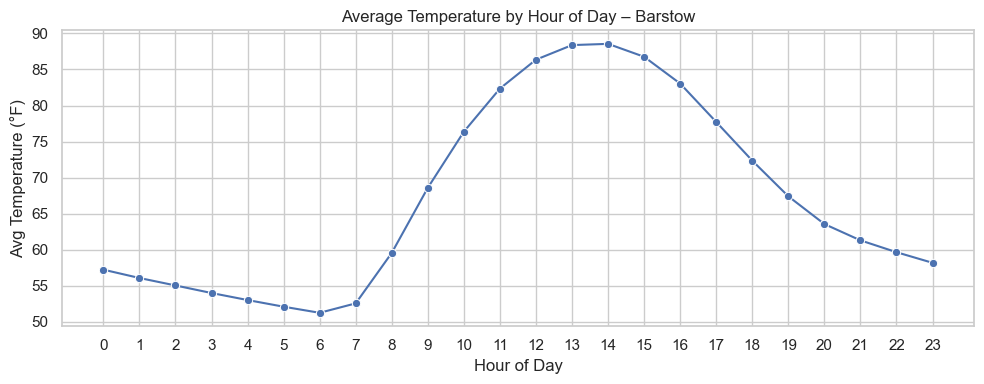

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


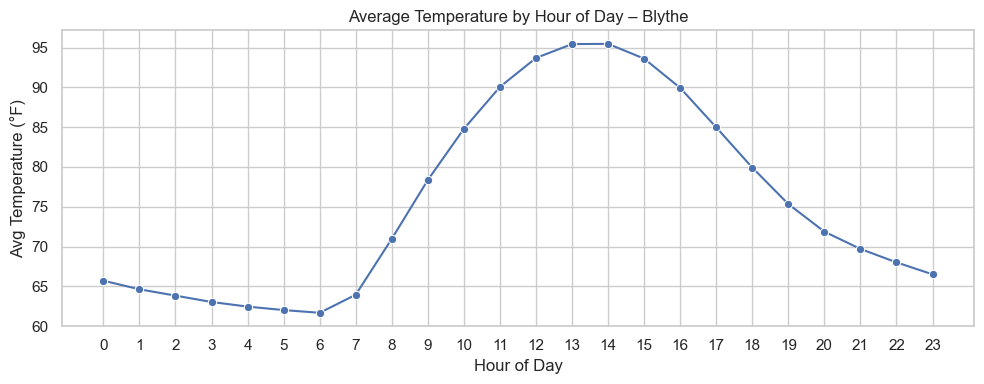

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


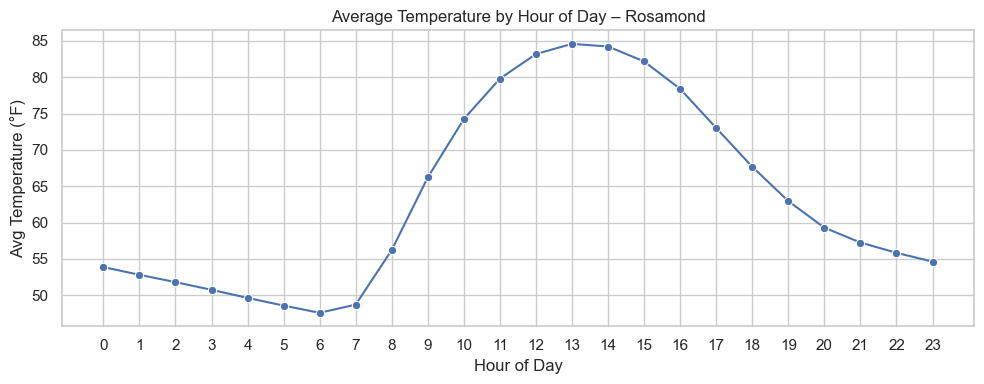

In [98]:
# Extract hour from the Pacific Time datetime
working_checkpoint["hour"] = working_checkpoint["valid_time_PT"].dt.hour

# Group by hour and location to get average temperature
avg_temp_by_hour = (
    working_checkpoint
    .groupby(["point_name", "hour"])["t_F"]
    .mean()
    .reset_index()
)

# Plot one figure per location
sns.set(style="whitegrid")
locations = avg_temp_by_hour["point_name"].unique()

for loc in locations:
    plt.figure(figsize=(10, 4))
    sns.lineplot(
        data=avg_temp_by_hour[avg_temp_by_hour["point_name"] == loc],
        x="hour", y="t_F", marker="o"
    )
    plt.title(f"Average Temperature by Hour of Day – {loc}")
    plt.xlabel("Hour of Day")
    plt.ylabel("Avg Temperature (°F)")
    plt.xticks(range(0, 24))
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Thoughts: First visualization looks good. Temperature behaving how I'd expect with its cyclical nature, rising and falling at reasonable hours of the day and peaking at a reasonable value.

In [99]:
# Just thought of one last way to check time change. Instead of checking surrounding days, I want one glimpse at the amount of hours on the single day of the time change.

# Extract date from valid_time_PT
working_checkpoint['valid_date_PT'] = working_checkpoint['valid_time_PT'].dt.date
working_checkpoint['valid_hour_PT'] = working_checkpoint['valid_time_PT'].dt.hour

# Choose specific dates for spring forward and fall back in the dataset's range
spring_forward_date = pd.to_datetime("2021-03-14").date()  
fall_back_date = pd.to_datetime("2021-11-07").date()        

spring_total = working_checkpoint[working_checkpoint['valid_date_PT'] == spring_forward_date].shape[0]
fall_total = working_checkpoint[working_checkpoint['valid_date_PT'] == fall_back_date].shape[0]

print(f"Spring Forward ({spring_forward_date}) - Total Forecasted Hours: {spring_total}")
print(f"Fall Back ({fall_back_date}) - Total Forecasted Hours: {fall_total}")


Spring Forward (2021-03-14) - Total Forecasted Hours: 69
Fall Back (2021-11-07) - Total Forecasted Hours: 75


Context on the above cell: Based on conversations that I've had with current coworkers and friends of mine, I've learned that the importance of modeling a timechange smoothly can't be overstated. To me this seems like a small confirmation that pays dividends. I thought that it couldn't hurt to double check this data in a different way, especially if it's not computationally intensive.

In [100]:
working_checkpoint.shape

(89765, 65)

Thoughts: Based on some calculations, it looks like I could be missing a small amount of hours in our dataset given how many rows we have vs how many hours (multiplied by 3) there are in this window of time. Let's take a deeper look at this.

In [101]:
# Generate all hourly timestamps using naive datetimes, then localize
all_hours = pd.date_range(
    start="2020-12-05 23:00:00",
    end="2024-05-06 01:00:00",
    freq="H",
    tz="America/Los_Angeles"
)

# Get unique points from the data
points = working_checkpoint['point_name'].drop_duplicates()

# Create full expected combinations of point and hourly timestamps
full_index = pd.MultiIndex.from_product(
    [points, all_hours],
    names=['point_name', 'valid_time_PT']
).to_frame(index=False)

# Merge with actual data
actual = working_checkpoint[['point_name', 'valid_time_PT']]
merged = full_index.merge(actual, on=['point_name', 'valid_time_PT'], how='left', indicator=True)

# Filter to find missing combinations
missing = merged[merged['_merge'] == 'left_only'].drop(columns=['_merge'])

# Show results
print(f"Total missing (point_name, timestamp) combinations: {len(missing)}")
missing.head(25)


Total missing (point_name, timestamp) combinations: 25


/var/folders/70/9yy_lf2j0fz2b3bn_9btzxj80000gn/T/ipykernel_16638/3337735239.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  all_hours = pd.date_range(


,point_name,valid_time_PT
136,Blythe,2020-12-11 15:00:00-08:00
137,Blythe,2020-12-11 16:00:00-08:00
138,Blythe,2020-12-11 17:00:00-08:00
139,Blythe,2020-12-11 18:00:00-08:00
140,Blythe,2020-12-11 19:00:00-08:00
141,Blythe,2020-12-11 20:00:00-08:00
142,Blythe,2020-12-11 21:00:00-08:00
143,Blythe,2020-12-11 22:00:00-08:00
30065,Rosamond,2020-12-11 14:00:00-08:00
30066,Rosamond,2020-12-11 15:00:00-08:00


Thoughts: This makes sense and my intuition was right. This data is coming from my 12-10 csv file which is noticeably smaller in size than the rest. Since this is so close to the beginning of the dataset (and will actually be lost once I merge with solar gen actuals, which don't go that far back), I can drop up to this date now or later when I merge. Other than that, this data looks good for now. Let's move on to the regional solar actuals and predicted data from CAISO.

### Bringing in the solar actuals and DAM data

In [ ]:
# ACTUALS

def get_solar_generation_from_OASIS(start_date, end_date, increment_days=30, max_retries=5, retry_delay=30):
    base_url = "http://oasis.caiso.com/oasisapi/SingleZip"
    start_date = datetime.strptime(start_date, "%Y-%m-%d")
    end_date = datetime.strptime(end_date, "%Y-%m-%d")
    all_data = []
    
    current_start_date = start_date
    while current_start_date < end_date:
        current_end_date = current_start_date + timedelta(days=increment_days)
        if current_end_date > end_date:
            current_end_date = end_date
        
        start_str = current_start_date.strftime("%Y%m%dT07:00-0000")
        end_str = current_end_date.strftime("%Y%m%dT07:00-0000")

        params = {
            "queryname": "SLD_REN_FCST",
            "market_run_id": "ACTUAL",  
            "resultformat": 6,  
            "startdatetime": start_str,
            "enddatetime": end_str,
            "version": 1
        }
        
        retries = 0
        success = False
        while retries < max_retries and not success:
            response = requests.get(base_url, params=params)
            if response.status_code == 200:
                if response.headers['Content-Type'] == 'application/x-zip-compressed': 
                    with zipfile.ZipFile(io.BytesIO(response.content)) as thezip:
                        for zipinfo in thezip.infolist():
                            with thezip.open(zipinfo) as thefile:
                                filename = zipinfo.filename
                                if filename.endswith('.xml'):
                                    try:
                                        data = pd.read_xml(thefile)
                                        all_data.append(data)
                                    except Exception as e:
                                        print(f"Error parsing XML file {filename}: {e}")
                                elif filename.endswith('.csv'):
                                    try:
                                        data = pd.read_csv(thefile, encoding="ISO-8859-1")
                                        all_data.append(data)
                                    except Exception as e:
                                        print(f"Error parsing CSV file {filename}: {e}")
                                else:
                                    print(f"Unrecognized file format: {filename}")
                    success = True
                    time.sleep(0.5)
                else:
                    print(f"Unexpected content type: {response.headers['Content-Type']}")
                    print(response.text)
                    break
            elif response.status_code == 429:
                print(f"Rate limit exceeded. Retrying in {retry_delay} seconds...")
                time.sleep(retry_delay)
                retries += 1
            else:
                print(f"Failed to retrieve data for {start_str} to {end_str}: HTTP {response.status_code}")
                break
        if not success:
            print(f"Failed to retrieve data after {max_retries} retries.")
        current_start_date = current_end_date + timedelta(days=1)

    # Ensure a DataFrame is returned
    if all_data:
        combined_data = pd.concat(all_data, ignore_index=True)
        print(combined_data.head())  # debug print
        return combined_data  # ✅ FIX: Returning the DataFrame
    else:
        print('No data dummy')
        return pd.DataFrame()  # ✅ FIX: Returning an empty DataFrame instead of None

# Try
start_date = "2020-12-05"
end_date = "2024-05-04"

df_solar = get_solar_generation_from_OASIS(start_date, end_date)

# Debugging check
print(type(df_solar)) 
print(df_solar.head()) 


Rate limit exceeded. Retrying in 30 seconds...
Rate limit exceeded. Retrying in 30 seconds...
Rate limit exceeded. Retrying in 30 seconds...
Rate limit exceeded. Retrying in 30 seconds...
Rate limit exceeded. Retrying in 30 seconds...
Rate limit exceeded. Retrying in 30 seconds...
Rate limit exceeded. Retrying in 30 seconds...
Rate limit exceeded. Retrying in 30 seconds...
Rate limit exceeded. Retrying in 30 seconds...
Rate limit exceeded. Retrying in 30 seconds...
Rate limit exceeded. Retrying in 30 seconds...
Rate limit exceeded. Retrying in 30 seconds...
Rate limit exceeded. Retrying in 30 seconds...
Rate limit exceeded. Retrying in 30 seconds...
Rate limit exceeded. Retrying in 30 seconds...
Rate limit exceeded. Retrying in 30 seconds...
Rate limit exceeded. Retrying in 30 seconds...
Rate limit exceeded. Retrying in 30 seconds...
Rate limit exceeded. Retrying in 30 seconds...
Rate limit exceeded. Retrying in 30 seconds...
Rate limit exceeded. Retrying in 30 seconds...
Rate limit ex

In [ ]:
# Making sure I only take the Solar energy actuals from the SP15 region
df_solar_sp15 = df_solar[(df_solar["RENEWABLE_TYPE"] == "Solar") & (df_solar["TRADING_HUB"] == "SP15")]
df_solar_sp15.head()

,TimeDate,Source,Version,RTO,OPR_DT,OPR_HR,OPR_INTERVAL,INTERVALSTARTTIME_GMT,INTERVALENDTIME_GMT,TRADING_HUB,RENEWABLE_TYPE,LABEL,XML_DATA_ITEM,MARKET_RUN_ID_POS,RENEW_POS,MW,MARKET_RUN_ID,GROUP
70,NaN,NaN,NaN,NaN,2021-12-01,13.0,0.0,2021-12-01T20:00:00-00:00,2021-12-01T21:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,5978.69191,ACTUAL,3.0
71,NaN,NaN,NaN,NaN,2021-12-01,15.0,0.0,2021-12-01T22:00:00-00:00,2021-12-01T23:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,5152.40179,ACTUAL,3.0
72,NaN,NaN,NaN,NaN,2021-12-01,12.0,0.0,2021-12-01T19:00:00-00:00,2021-12-01T20:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,5970.23315,ACTUAL,3.0
73,NaN,NaN,NaN,NaN,2021-12-01,19.0,0.0,2021-12-02T02:00:00-00:00,2021-12-02T03:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,-13.66388,ACTUAL,3.0
74,NaN,NaN,NaN,NaN,2021-12-01,11.0,0.0,2021-12-01T18:00:00-00:00,2021-12-01T19:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,5848.59531,ACTUAL,3.0


In [ ]:
# Sorting data by date and hour
df_solar_sp15_sorted = df_solar_sp15.sort_values(by=["OPR_DT", "OPR_HR"])
df_solar_sp15_sorted.tail(10)

,TimeDate,Source,Version,RTO,OPR_DT,OPR_HR,OPR_INTERVAL,INTERVALSTARTTIME_GMT,INTERVALENDTIME_GMT,TRADING_HUB,RENEWABLE_TYPE,LABEL,XML_DATA_ITEM,MARKET_RUN_ID_POS,RENEW_POS,MW,MARKET_RUN_ID,GROUP
104527,NaN,NaN,NaN,NaN,2024-05-03,15.0,0.0,2024-05-03T21:00:00-00:00,2024-05-03T22:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,10361.87978,ACTUAL,33.0
104523,NaN,NaN,NaN,NaN,2024-05-03,16.0,0.0,2024-05-03T22:00:00-00:00,2024-05-03T23:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,10014.89937,ACTUAL,33.0
104534,NaN,NaN,NaN,NaN,2024-05-03,17.0,0.0,2024-05-03T23:00:00-00:00,2024-05-04T00:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,9178.37782,ACTUAL,33.0
104532,NaN,NaN,NaN,NaN,2024-05-03,18.0,0.0,2024-05-04T00:00:00-00:00,2024-05-04T01:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,7805.43780,ACTUAL,33.0
104530,NaN,NaN,NaN,NaN,2024-05-03,19.0,0.0,2024-05-04T01:00:00-00:00,2024-05-04T02:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,3604.79214,ACTUAL,33.0
104528,NaN,NaN,NaN,NaN,2024-05-03,20.0,0.0,2024-05-04T02:00:00-00:00,2024-05-04T03:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,198.53636,ACTUAL,33.0
104526,NaN,NaN,NaN,NaN,2024-05-03,21.0,0.0,2024-05-04T03:00:00-00:00,2024-05-04T04:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,-38.96138,ACTUAL,33.0
104524,NaN,NaN,NaN,NaN,2024-05-03,22.0,0.0,2024-05-04T04:00:00-00:00,2024-05-04T05:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,-35.67349,ACTUAL,33.0
104522,NaN,NaN,NaN,NaN,2024-05-03,23.0,0.0,2024-05-04T05:00:00-00:00,2024-05-04T06:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,-35.22847,ACTUAL,33.0
104520,NaN,NaN,NaN,NaN,2024-05-03,24.0,0.0,2024-05-04T06:00:00-00:00,2024-05-04T07:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,-39.58521,ACTUAL,33.0


In [ ]:
# Rename data
df_solar_actual = df_solar_sp15_sorted

In [ ]:
# Save to drive
df_solar_actual.to_csv("/Volumes/USB DISK/Solar_Gen_Actuals/df_solar_sp15_actual.csv", index=False)

Thoughts: Now that I've retrieved our actuals, I'll pull the predicted solar gen values for the Day-Ahead Market. Actuals only date back to 2021-12-01, so I will make that the start date for this pull.

In [ ]:
def get_solar_generation_from_OASIS(start_date, end_date, increment_days=30, max_retries=5, retry_delay=30):
    base_url = "http://oasis.caiso.com/oasisapi/SingleZip"
    start_date = datetime.strptime(start_date, "%Y-%m-%d")
    end_date = datetime.strptime(end_date, "%Y-%m-%d")
    all_data = []
    
    current_start_date = start_date
    while current_start_date < end_date:
        current_end_date = current_start_date + timedelta(days=increment_days)
        if current_end_date > end_date:
            current_end_date = end_date
        
        start_str = current_start_date.strftime("%Y%m%dT07:00-0000")
        end_str = current_end_date.strftime("%Y%m%dT07:00-0000")

        params = {
            "queryname": "SLD_REN_FCST",
            "market_run_id": "DAM",  # This is what indicates predicteds (day ahead market)
            "resultformat": 6,  
            "startdatetime": start_str,
            "enddatetime": end_str,
            "version": 1
        }
        
        retries = 0
        success = False
        while retries < max_retries and not success:
            response = requests.get(base_url, params=params)
            if response.status_code == 200:
                if response.headers['Content-Type'] == 'application/x-zip-compressed': 
                    with zipfile.ZipFile(io.BytesIO(response.content)) as thezip:
                        for zipinfo in thezip.infolist():
                            with thezip.open(zipinfo) as thefile:
                                filename = zipinfo.filename
                                if filename.endswith('.xml'):
                                    try:
                                        data = pd.read_xml(thefile)
                                        all_data.append(data)
                                    except Exception as e:
                                        print(f"Error parsing XML file {filename}: {e}")
                                elif filename.endswith('.csv'):
                                    try:
                                        data = pd.read_csv(thefile, encoding="ISO-8859-1")
                                        all_data.append(data)
                                    except Exception as e:
                                        print(f"Error parsing CSV file {filename}: {e}")
                                else:
                                    print(f"Unrecognized file format: {filename}")
                    success = True
                    time.sleep(0.5)
                else:
                    print(f"Unexpected content type: {response.headers['Content-Type']}")
                    print(response.text)
                    break
            elif response.status_code == 429:
                print(f"Rate limit exceeded. Retrying in {retry_delay} seconds...")
                time.sleep(retry_delay)
                retries += 1
            else:
                print(f"Failed to retrieve data for {start_str} to {end_str}: HTTP {response.status_code}")
                break
        if not success:
            print(f"Failed to retrieve data after {max_retries} retries.")
        current_start_date = current_end_date + timedelta(days=1)

    # Ensure a DataFrame is returned
    if all_data:
        combined_data = pd.concat(all_data, ignore_index=True)
        print(combined_data.head())  # debug print
        return combined_data  # ✅ FIX: Returning the DataFrame
    else:
        print('No data dummy')
        return pd.DataFrame()  # ✅ FIX: Returning an empty DataFrame instead of None

# Date range
start_date = "2021-12-01"
end_date = "2024-05-04"

df_solar_pred = get_solar_generation_from_OASIS(start_date, end_date)

# Debugging check
print(type(df_solar_pred))  
print(df_solar_pred.head())  


Rate limit exceeded. Retrying in 30 seconds...
Rate limit exceeded. Retrying in 30 seconds...
Rate limit exceeded. Retrying in 30 seconds...
Rate limit exceeded. Retrying in 30 seconds...
Rate limit exceeded. Retrying in 30 seconds...
Rate limit exceeded. Retrying in 30 seconds...
Rate limit exceeded. Retrying in 30 seconds...
Rate limit exceeded. Retrying in 30 seconds...
Rate limit exceeded. Retrying in 30 seconds...
Rate limit exceeded. Retrying in 30 seconds...
Rate limit exceeded. Retrying in 30 seconds...
Rate limit exceeded. Retrying in 30 seconds...
Rate limit exceeded. Retrying in 30 seconds...
Rate limit exceeded. Retrying in 30 seconds...
Rate limit exceeded. Retrying in 30 seconds...
Rate limit exceeded. Retrying in 30 seconds...
Rate limit exceeded. Retrying in 30 seconds...
Rate limit exceeded. Retrying in 30 seconds...
Rate limit exceeded. Retrying in 30 seconds...
Rate limit exceeded. Retrying in 30 seconds...
Rate limit exceeded. Retrying in 30 seconds...
Rate limit ex

In [ ]:
# Only keep solar from the SP15 region
df_solar_sp15_pred = df_solar_pred[(df_solar_pred["RENEWABLE_TYPE"] == "Solar") & (df_solar_pred["TRADING_HUB"] == "SP15")]
df_solar_sp15_pred.head()

,OPR_DT,OPR_HR,OPR_INTERVAL,INTERVALSTARTTIME_GMT,INTERVALENDTIME_GMT,TRADING_HUB,RENEWABLE_TYPE,LABEL,XML_DATA_ITEM,MARKET_RUN_ID_POS,RENEW_POS,MW,MARKET_RUN_ID,GROUP
48,2021-12-01,13,0,2021-12-01T20:00:00-00:00,2021-12-01T21:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1,2,6443.80,DAM,3
49,2021-12-01,15,0,2021-12-01T22:00:00-00:00,2021-12-01T23:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1,2,5470.53,DAM,3
50,2021-12-01,12,0,2021-12-01T19:00:00-00:00,2021-12-01T20:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1,2,6448.45,DAM,3
51,2021-12-01,19,0,2021-12-02T02:00:00-00:00,2021-12-02T03:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1,2,0.00,DAM,3
52,2021-12-01,11,0,2021-12-01T18:00:00-00:00,2021-12-01T19:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1,2,6467.29,DAM,3


In [ ]:
# Sort by date and hour
df_solar_sp15_pred_sorted = df_solar_sp15_pred.sort_values(by=["OPR_DT", "OPR_HR"])
df_solar_sp15_pred_sorted.head(10)

,OPR_DT,OPR_HR,OPR_INTERVAL,INTERVALSTARTTIME_GMT,INTERVALENDTIME_GMT,TRADING_HUB,RENEWABLE_TYPE,LABEL,XML_DATA_ITEM,MARKET_RUN_ID_POS,RENEW_POS,MW,MARKET_RUN_ID,GROUP
71,2021-12-01,1,0,2021-12-01T08:00:00-00:00,2021-12-01T09:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1,2,0.00,DAM,3
70,2021-12-01,2,0,2021-12-01T09:00:00-00:00,2021-12-01T10:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1,2,0.00,DAM,3
68,2021-12-01,3,0,2021-12-01T10:00:00-00:00,2021-12-01T11:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1,2,0.00,DAM,3
66,2021-12-01,4,0,2021-12-01T11:00:00-00:00,2021-12-01T12:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1,2,0.00,DAM,3
64,2021-12-01,5,0,2021-12-01T12:00:00-00:00,2021-12-01T13:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1,2,0.00,DAM,3
62,2021-12-01,6,0,2021-12-01T13:00:00-00:00,2021-12-01T14:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1,2,0.00,DAM,3
60,2021-12-01,7,0,2021-12-01T14:00:00-00:00,2021-12-01T15:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1,2,151.69,DAM,3
58,2021-12-01,8,0,2021-12-01T15:00:00-00:00,2021-12-01T16:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1,2,2438.99,DAM,3
56,2021-12-01,9,0,2021-12-01T16:00:00-00:00,2021-12-01T17:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1,2,5427.53,DAM,3
54,2021-12-01,10,0,2021-12-01T17:00:00-00:00,2021-12-01T18:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1,2,6361.96,DAM,3


In [ ]:
# Save this to drive
df_solar_pred.to_csv("/Volumes/USB DISK/Solar_Gen_Pred/df_solar_sp15_pred.csv", index=False)

Thoughts: Now I'll read the actuals and predicteds in, look at them a bit under the hood, and then do some merging.

NOTE: In all likelihood, you are screaming at your screen right now and saying those API pulls weren't done flawlessly. However, this is part of why I chose this project to show. Among the many other "new" areas of exploration in this project, API interactions was one of them. I wasn't super comfortable with them before, but wanted to challenge myself with that material here. As you will see in the forthcoming cells, I end up making this discovery on my own and figuring out how to deal with it. I feel like making mistakes like these and having to suffer real consequences (time spent troubleshooting and having to retrace my steps) is the best way to learn, and I know I'm a better MLE for it. It is something that I am proud of.

In [102]:
# Let's read these back in
actuals = pd.read_csv("/Volumes/USB DISK/Solar_Gen_Actuals/df_solar_sp15_actual.csv")
actuals.head()

,TimeDate,Source,Version,RTO,OPR_DT,OPR_HR,OPR_INTERVAL,INTERVALSTARTTIME_GMT,INTERVALENDTIME_GMT,TRADING_HUB,RENEWABLE_TYPE,LABEL,XML_DATA_ITEM,MARKET_RUN_ID_POS,RENEW_POS,MW,MARKET_RUN_ID,GROUP
0,NaN,NaN,NaN,NaN,2021-12-01,1.0,0.0,2021-12-01T08:00:00-00:00,2021-12-01T09:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,2.50251,ACTUAL,3.0
1,NaN,NaN,NaN,NaN,2021-12-01,2.0,0.0,2021-12-01T09:00:00-00:00,2021-12-01T10:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,1.58447,ACTUAL,3.0
2,NaN,NaN,NaN,NaN,2021-12-01,3.0,0.0,2021-12-01T10:00:00-00:00,2021-12-01T11:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,2.47010,ACTUAL,3.0
3,NaN,NaN,NaN,NaN,2021-12-01,4.0,0.0,2021-12-01T11:00:00-00:00,2021-12-01T12:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,2.27596,ACTUAL,3.0
4,NaN,NaN,NaN,NaN,2021-12-01,5.0,0.0,2021-12-01T12:00:00-00:00,2021-12-01T13:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,2.04619,ACTUAL,3.0


In [103]:
# Read back in
preds = pd.read_csv("/Volumes/USB DISK/Solar_Gen_Pred/df_solar_sp15_pred.csv")
preds.head()

,OPR_DT,OPR_HR,OPR_INTERVAL,INTERVALSTARTTIME_GMT,INTERVALENDTIME_GMT,TRADING_HUB,RENEWABLE_TYPE,LABEL,XML_DATA_ITEM,MARKET_RUN_ID_POS,RENEW_POS,MW,MARKET_RUN_ID,GROUP
0,2021-12-01,1,0,2021-12-01T08:00:00-00:00,2021-12-01T09:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1,2,0.0,DAM,3
1,2021-12-01,2,0,2021-12-01T09:00:00-00:00,2021-12-01T10:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1,2,0.0,DAM,3
2,2021-12-01,3,0,2021-12-01T10:00:00-00:00,2021-12-01T11:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1,2,0.0,DAM,3
3,2021-12-01,4,0,2021-12-01T11:00:00-00:00,2021-12-01T12:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1,2,0.0,DAM,3
4,2021-12-01,5,0,2021-12-01T12:00:00-00:00,2021-12-01T13:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1,2,0.0,DAM,3


In [104]:
# Take a look at column headers
actuals.columns

Index(['TimeDate', 'Source', 'Version', 'RTO', 'OPR_DT', 'OPR_HR',
       'OPR_INTERVAL', 'INTERVALSTARTTIME_GMT', 'INTERVALENDTIME_GMT',
       'TRADING_HUB', 'RENEWABLE_TYPE', 'LABEL', 'XML_DATA_ITEM',
       'MARKET_RUN_ID_POS', 'RENEW_POS', 'MW', 'MARKET_RUN_ID', 'GROUP'],
      dtype='object')

In [105]:
# Same thing
preds.columns

Index(['OPR_DT', 'OPR_HR', 'OPR_INTERVAL', 'INTERVALSTARTTIME_GMT',
       'INTERVALENDTIME_GMT', 'TRADING_HUB', 'RENEWABLE_TYPE', 'LABEL',
       'XML_DATA_ITEM', 'MARKET_RUN_ID_POS', 'RENEW_POS', 'MW',
       'MARKET_RUN_ID', 'GROUP'],
      dtype='object')

In [106]:
# Check out the shape
actuals.shape

(20522, 18)

In [107]:
# Same thing
preds.shape

(20567, 14)

Thoughts: It looks like I have fewer hours than expected for this interval of time, so I'll run some code to find out where this is coming from.

In [108]:
# Ensure datetime format
actuals['INTERVALSTARTTIME_GMT'] = pd.to_datetime(actuals['INTERVALSTARTTIME_GMT'])

# Sort just in case
actuals = actuals.sort_values('INTERVALSTARTTIME_GMT')

# Generate expected full range of hourly timestamps
expected_hours = pd.date_range(
    start='2021-12-01T08:00:00Z', 
    end='2024-05-04T06:00:00Z', 
    freq='H'
)

# Find missing timestamps
actual_hours = actuals['INTERVALSTARTTIME_GMT'].drop_duplicates()
missing_hours = expected_hours.difference(actual_hours)

# Let's see
missing_df = pd.DataFrame({'missing_hour_UTC': missing_hours})
print(f"Number of missing hours: {len(missing_df)}")
missing_df.head()


Number of missing hours: 717


/var/folders/70/9yy_lf2j0fz2b3bn_9btzxj80000gn/T/ipykernel_16638/1781375161.py:8: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  expected_hours = pd.date_range(


,missing_hour_UTC
0,2021-12-11 07:00:00+00:00
1,2021-12-11 08:00:00+00:00
2,2021-12-11 09:00:00+00:00
3,2021-12-11 10:00:00+00:00
4,2021-12-11 11:00:00+00:00


In [109]:
# Extract just the date from each missing timestamp
missing_df['missing_date_GMT'] = missing_df['missing_hour_UTC'].dt.date

# Count the number of unique dates
num_unique_days = missing_df['missing_date_GMT'].nunique()

print(f"Number of unique days with at least one missing hour: {num_unique_days}")


Number of unique days with at least one missing hour: 76


In [110]:
# Extract just the date portion
missing_df['missing_date_UTC'] = missing_df['missing_hour_UTC'].dt.date

# Count number of unique dates
num_unique_days = missing_df['missing_date_UTC'].nunique()
print(f"Number of unique days with at least one missing hour: {num_unique_days}")

# List of those dates
unique_dates = missing_df['missing_date_UTC'].unique()
print("\nDates with missing hours:")
print(sorted(unique_dates))

# Count how many missing hours per date
hours_per_day = missing_df['missing_date_UTC'].value_counts().sort_values(ascending=False)
print("\nNumber of missing hours per date:")
print(hours_per_day)


Number of unique days with at least one missing hour: 76

Dates with missing hours:
[datetime.date(2021, 12, 11), datetime.date(2021, 12, 12), datetime.date(2022, 1, 11), datetime.date(2022, 1, 12), datetime.date(2022, 2, 11), datetime.date(2022, 2, 12), datetime.date(2022, 3, 14), datetime.date(2022, 3, 15), datetime.date(2022, 4, 14), datetime.date(2022, 4, 15), datetime.date(2022, 5, 15), datetime.date(2022, 5, 16), datetime.date(2022, 6, 15), datetime.date(2022, 6, 16), datetime.date(2022, 7, 16), datetime.date(2022, 7, 17), datetime.date(2022, 8, 16), datetime.date(2022, 8, 17), datetime.date(2022, 9, 16), datetime.date(2022, 9, 17), datetime.date(2022, 10, 17), datetime.date(2022, 10, 18), datetime.date(2022, 11, 17), datetime.date(2022, 11, 18), datetime.date(2022, 12, 18), datetime.date(2022, 12, 19), datetime.date(2023, 1, 18), datetime.date(2023, 1, 19), datetime.date(2023, 2, 18), datetime.date(2023, 2, 19), datetime.date(2023, 3, 21), datetime.date(2023, 3, 22), datetime.da

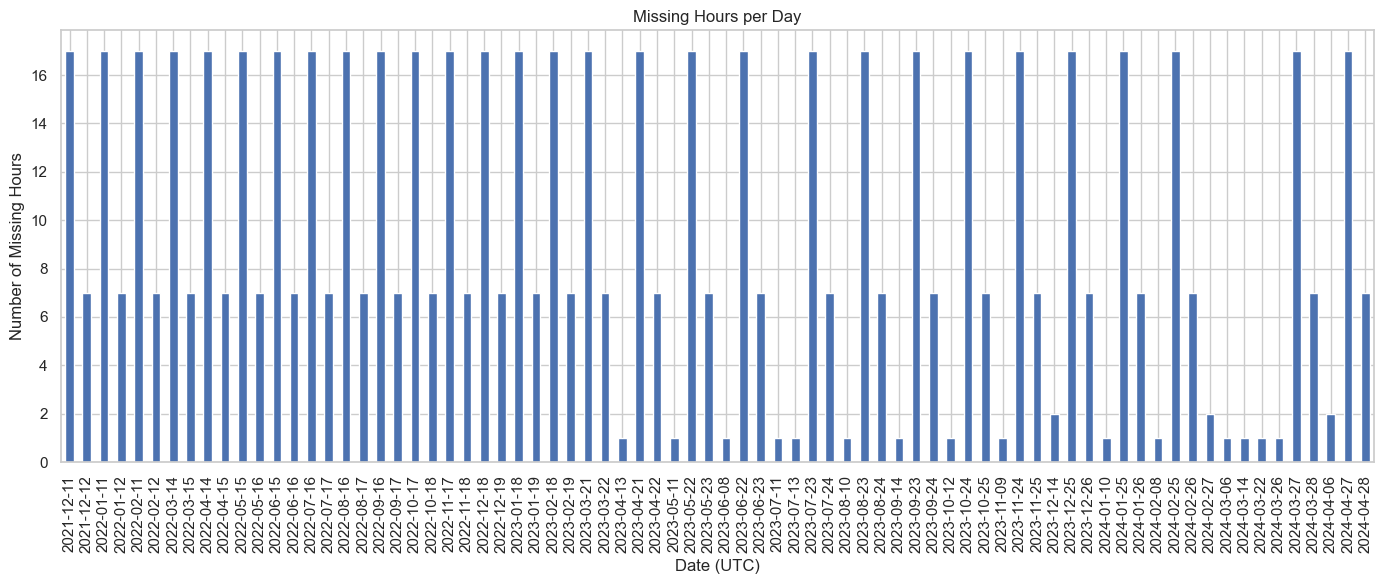

In [111]:
# Sort by date instead of frequency
hours_per_day_sorted = hours_per_day.sort_index()

# Plotting the bar chart
plt.figure(figsize=(14, 6))
hours_per_day_sorted.plot(kind='bar')

plt.title("Missing Hours per Day")
plt.xlabel("Date (UTC)")
plt.ylabel("Number of Missing Hours")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


Thoughts: There is noticeably a pattern in the missing data here. I see the 11th and 12th missing for a few months in a row, then the 14th and 15th for a few, then 15th and 16th for a few, then 16th 17th for a few etc. They also look to be 24 hour increments of missing data. I'll do a similar investigation with the preds before taking any action.

In [112]:
# Predicted Data - same code from above just changing the dataset

# Convert INTERVALSTARTTIME_GMT to datetime if not already in datetime format
preds['INTERVALSTARTTIME_GMT'] = pd.to_datetime(preds['INTERVALSTARTTIME_GMT'], errors='coerce')

# Generate all expected hourly timestamps in the range from 2021-12-01T08:00:00 to 2024-05-04T06:00:00
all_hours_preds = pd.date_range(
    start="2021-12-01 08:00:00+00:00",  
    end="2024-05-04 06:00:00+00:00",  
    freq="H"
)

# Check which hours in the all_hours_preds are missing in preds dataset
# Check for any timestamps that are not in the preds['INTERVALSTARTTIME_GMT'] list
missing_hours_preds = set(all_hours_preds) - set(preds['INTERVALSTARTTIME_GMT'])

# Convert the missing hours set back into a DataFrame for analysis
missing_hours_df_preds = pd.DataFrame(list(missing_hours_preds), columns=["missing_time"])
missing_hours_df_preds.sort_values("missing_time", inplace=True)

# Count the number of missing hours and find out which unique days these missing hours fall on
missing_days_preds = missing_hours_df_preds['missing_time'].dt.date.value_counts().sort_index()

print(f"Number of missing hours: {len(missing_hours_df_preds)}")
print(f"Missing hours by day:\n{missing_days_preds}")



Number of missing hours: 672
Missing hours by day:
missing_time
2021-12-31    17
2022-01-01     7
2022-01-31    17
2022-02-01     7
2022-03-03    17
2022-03-04     7
2022-04-03    17
2022-04-04     7
2022-05-04    17
2022-05-05     7
2022-06-04    17
2022-06-05     7
2022-07-05    17
2022-07-06     7
2022-08-05    17
2022-08-06     7
2022-09-05    17
2022-09-06     7
2022-10-06    17
2022-10-07     7
2022-11-06    17
2022-11-07     7
2022-12-07    17
2022-12-08     7
2023-01-07    17
2023-01-08     7
2023-02-07    17
2023-02-08     7
2023-03-10    17
2023-03-11     7
2023-04-10    17
2023-04-11     7
2023-05-11    17
2023-05-12     7
2023-06-11    17
2023-06-12     7
2023-07-12    17
2023-07-13     7
2023-08-12    17
2023-08-13     7
2023-09-12    17
2023-09-13     7
2023-10-13    17
2023-10-14     7
2023-11-13    17
2023-11-14     7
2023-12-14    17
2023-12-15     7
2024-01-14    17
2024-01-15     7
2024-02-14    17
2024-02-15     7
2024-03-16    17
2024-03-17     7
2024-04-16    17
2

/var/folders/70/9yy_lf2j0fz2b3bn_9btzxj80000gn/T/ipykernel_16638/2182531470.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  all_hours_preds = pd.date_range(


In [113]:
# Extract just the date from each missing timestamp in the preds dataset
missing_hours_df_preds['missing_date_GMT'] = missing_hours_df_preds['missing_time'].dt.date

# Count the number of unique dates
num_unique_days_preds = missing_hours_df_preds['missing_date_GMT'].nunique()

print(f"Number of unique days with at least one missing hour in preds dataset: {num_unique_days_preds}")


Number of unique days with at least one missing hour in preds dataset: 56


In [114]:
missing_hours_df_preds['missing_time'] = pd.to_datetime(missing_hours_df_preds['missing_time'])
# Extract just the date from each missing timestamp in the preds dataset
missing_hours_df_preds['missing_date_GMT'] = missing_hours_df_preds['missing_time'].dt.date

# Count the number of unique dates
num_unique_days_preds = missing_hours_df_preds['missing_date_GMT'].nunique()
print(f"Number of unique days with at least one missing hour in preds dataset: {num_unique_days_preds}")

# Count how many missing hours per date
hours_per_day_preds = missing_hours_df_preds['missing_date_GMT'].value_counts().sort_index()
print(f"Missing hours by day:\n{hours_per_day_preds}")


Number of unique days with at least one missing hour in preds dataset: 56
Missing hours by day:
missing_date_GMT
2021-12-31    17
2022-01-01     7
2022-01-31    17
2022-02-01     7
2022-03-03    17
2022-03-04     7
2022-04-03    17
2022-04-04     7
2022-05-04    17
2022-05-05     7
2022-06-04    17
2022-06-05     7
2022-07-05    17
2022-07-06     7
2022-08-05    17
2022-08-06     7
2022-09-05    17
2022-09-06     7
2022-10-06    17
2022-10-07     7
2022-11-06    17
2022-11-07     7
2022-12-07    17
2022-12-08     7
2023-01-07    17
2023-01-08     7
2023-02-07    17
2023-02-08     7
2023-03-10    17
2023-03-11     7
2023-04-10    17
2023-04-11     7
2023-05-11    17
2023-05-12     7
2023-06-11    17
2023-06-12     7
2023-07-12    17
2023-07-13     7
2023-08-12    17
2023-08-13     7
2023-09-12    17
2023-09-13     7
2023-10-13    17
2023-10-14     7
2023-11-13    17
2023-11-14     7
2023-12-14    17
2023-12-15     7
2024-01-14    17
2024-01-15     7
2024-02-14    17
2024-02-15     7
202

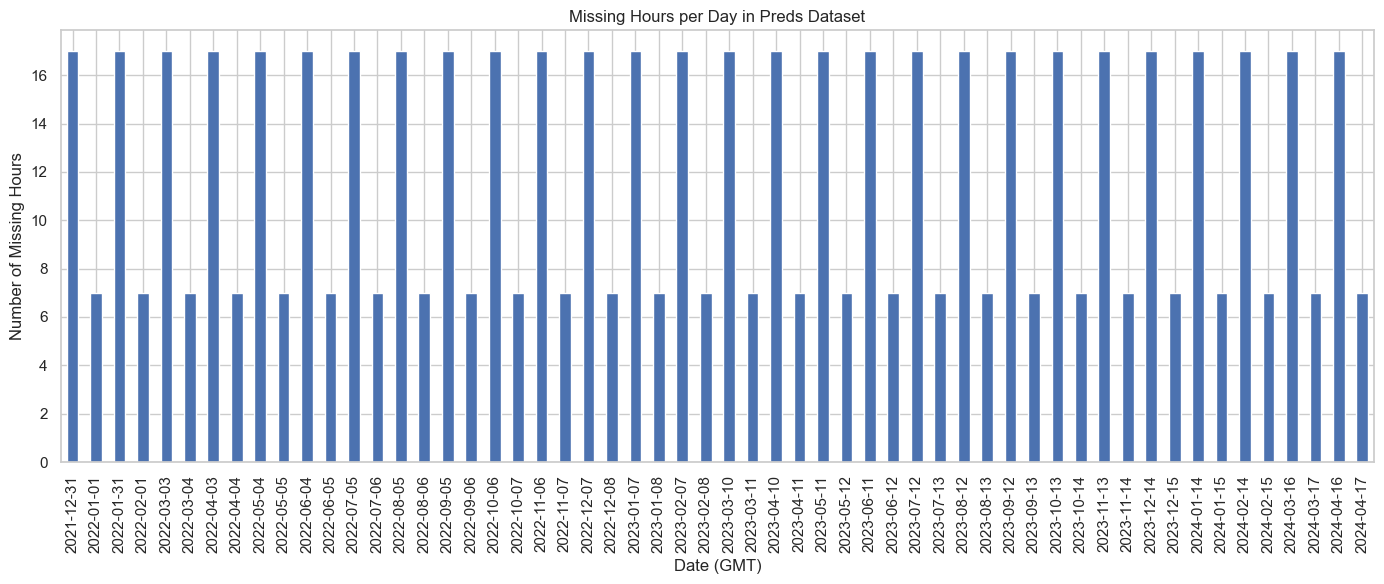

In [115]:
# Sort by date to make sure x-axis is in order
hours_per_day_preds_sorted = hours_per_day_preds.sort_index()

# Plot bar chart
plt.figure(figsize=(14, 6))
hours_per_day_preds_sorted.plot(kind='bar')

plt.title("Missing Hours per Day in Preds Dataset")
plt.xlabel("Date (GMT)")
plt.ylabel("Number of Missing Hours")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


Thoughts: I again see a pattern in the missing dates here. I see 31st and 1st for a few months, then 3rd and 4th, then 4th and 5th for a few, then 5th and 6th for a few, etc. Seeing patterns like this in both datasets suggests something systematic. Possibly on their end? Doesn't seem to be super sporadic and the similarity in the pattern is promising. 

*** I know, I know. My eureka moment is coming. I find out this is a throttling issue on my end soon. I will address shortly. ***

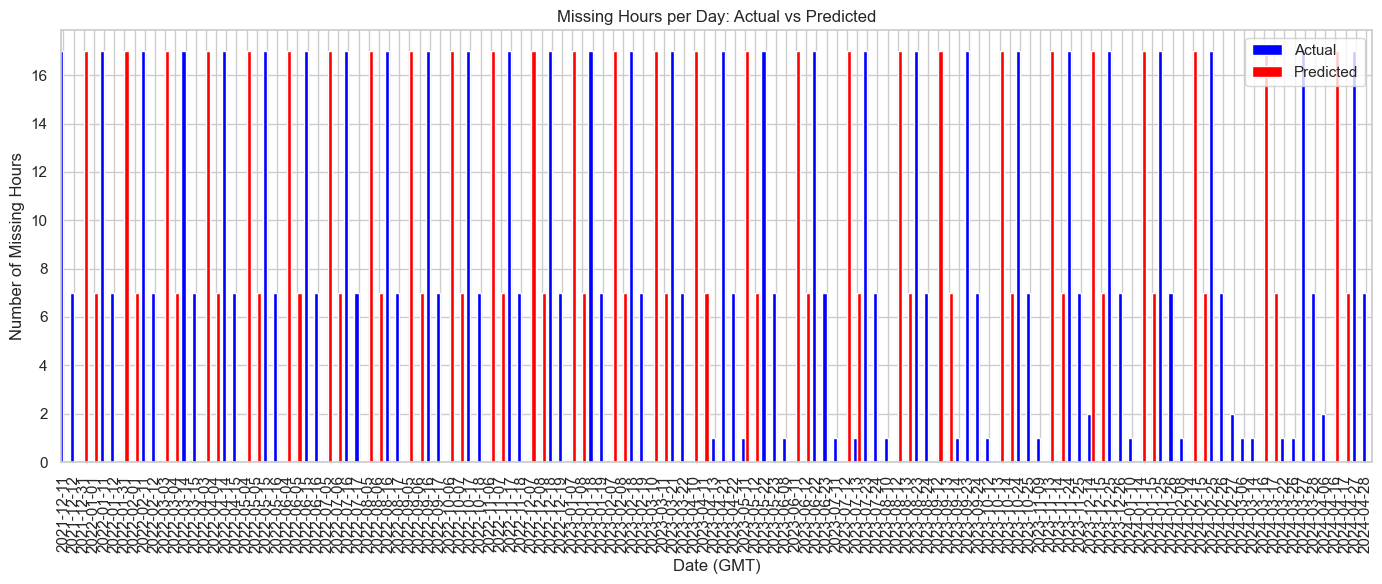

In [116]:
# Sort both series by date to align them
hours_per_day_sorted_actual = hours_per_day.sort_index()  # Actual data
hours_per_day_sorted_preds = hours_per_day_preds.sort_index()  # Predicted data

# Merge both missing hour counts on the same date index
merged_missing_hours = pd.DataFrame({
    'actual': hours_per_day_sorted_actual,
    'predicted': hours_per_day_sorted_preds
}).fillna(0)  # Fill missing values with 0

plt.figure(figsize=(14, 6))

merged_missing_hours['actual'].plot(kind='bar', color='blue', width=0.4, position=1, label='Actual')
merged_missing_hours['predicted'].plot(kind='bar', color='red', width=0.4, position=0, label='Predicted')

plt.title("Missing Hours per Day: Actual vs Predicted")
plt.xlabel("Date (GMT)")
plt.ylabel("Number of Missing Hours")
plt.xticks(rotation=90)
plt.tight_layout()
plt.legend()
plt.show()


Thoughts: Alright, semi-painful learning moment here. The gaps in my data shown above are (mostly) not missing when cross-checking with the CAISO API dashboard online (https://oasis.caiso.com/mrioasis/logon.do). It looks like my pulls from the API were throttling and resulting in small amounts of missing data each time. I'll now try to target smaller chunks of time and be a bit more conservative with the wait times to fill in these gaps.

Fell free to fast forward through this part!!!

In [ ]:
# Actuals

def get_solar_generation_from_OASIS(start_date, end_date, increment_days=14, max_retries=10, retry_delay=40):
    base_url = "http://oasis.caiso.com/oasisapi/SingleZip"
    start_date = datetime.strptime(start_date, "%Y-%m-%d")
    end_date = datetime.strptime(end_date, "%Y-%m-%d")
    all_data = []
    failed_chunks = []

    current_start_date = start_date
    while current_start_date < end_date:
        current_end_date = current_start_date + timedelta(days=increment_days)
        if current_end_date > end_date:
            current_end_date = end_date
        
        start_str = current_start_date.strftime("%Y%m%dT07:00-0000")
        end_str = current_end_date.strftime("%Y%m%dT07:00-0000")

        params = {
            "queryname": "SLD_REN_FCST",
            "market_run_id": "ACTUAL",
            "resultformat": 6,
            "startdatetime": start_str,
            "enddatetime": end_str,
            "version": 1
        }
        
        retries = 0
        success = False
        while retries < max_retries and not success:
            response = requests.get(base_url, params=params)
            if response.status_code == 200:
                if response.headers['Content-Type'] == 'application/x-zip-compressed': 
                    with zipfile.ZipFile(io.BytesIO(response.content)) as thezip:
                        for zipinfo in thezip.infolist():
                            with thezip.open(zipinfo) as thefile:
                                filename = zipinfo.filename
                                try:
                                    if filename.endswith('.xml'):
                                        data = pd.read_xml(thefile)
                                    elif filename.endswith('.csv'):
                                        data = pd.read_csv(thefile, encoding="ISO-8859-1")
                                    else:
                                        print(f"Unrecognized file format: {filename}")
                                        continue
                                    all_data.append(data)
                                except Exception as e:
                                    print(f"Error parsing {filename}: {e}")
                    success = True
                    time.sleep(5)
                else:
                    print(f"Unexpected content type: {response.headers['Content-Type']}")
                    break
            elif response.status_code == 429:
                wait = retry_delay * (2 ** retries)  # exponential backoff
                print(f"Rate limit exceeded. Retrying in {wait} seconds...")
                time.sleep(wait)
                retries += 1
            else:
                print(f"Failed to retrieve data for {start_str} to {end_str}: HTTP {response.status_code}")
                break
        if not success:
            print(f"❌ Failed to retrieve data for {start_str} to {end_str} after {max_retries} retries.")
            failed_chunks.append((start_str, end_str))
        current_start_date = current_end_date + timedelta(days=1)

    if failed_chunks:
        print("\n⚠️ The following date chunks failed and may have missing data:")
        for chunk in failed_chunks:
            print(f" - {chunk[0]} to {chunk[1]}")

    return pd.concat(all_data, ignore_index=True) if all_data else pd.DataFrame()

start_date = "2021-12-01"
end_date = "2024-05-04"

df_solar_actual_new = get_solar_generation_from_OASIS(start_date, end_date)

print(type(df_solar_actual_new))
df_solar_actual_new.head()  


<class 'pandas.core.frame.DataFrame'>


,TimeDate,Source,Version,RTO,OPR_DT,OPR_HR,OPR_INTERVAL,INTERVALSTARTTIME_GMT,INTERVALENDTIME_GMT,TRADING_HUB,RENEWABLE_TYPE,LABEL,XML_DATA_ITEM,MARKET_RUN_ID_POS,RENEW_POS,MW,MARKET_RUN_ID,GROUP
0,2025-04-23T14:00:18.628Z,OASIS,v20131201,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,None,None,None,\n,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-04-23T14:00:25.927Z,OASIS,v20131201,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,None,None,None,\n,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,2022-01-01,13.0,0.0,2022-01-01T20:00:00-00:00,2022-01-01T21:00:00-00:00,NP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,1088.83371,ACTUAL,1.0


In [ ]:
df_solar_actual_new.tail()

,TimeDate,Source,Version,RTO,OPR_DT,OPR_HR,OPR_INTERVAL,INTERVALSTARTTIME_GMT,INTERVALENDTIME_GMT,TRADING_HUB,RENEWABLE_TYPE,LABEL,XML_DATA_ITEM,MARKET_RUN_ID_POS,RENEW_POS,MW,MARKET_RUN_ID,GROUP
97440,NaN,NaN,NaN,NaN,2024-05-02,14.0,0.0,2024-05-02T20:00:00-00:00,2024-05-02T21:00:00-00:00,ZP26,Wind,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,1.0,41.86093,ACTUAL,84.0
97441,NaN,NaN,NaN,NaN,2024-05-02,8.0,0.0,2024-05-02T14:00:00-00:00,2024-05-02T15:00:00-00:00,ZP26,Wind,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,1.0,76.47235,ACTUAL,84.0
97442,NaN,NaN,NaN,NaN,2024-05-02,7.0,0.0,2024-05-02T13:00:00-00:00,2024-05-02T14:00:00-00:00,ZP26,Wind,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,1.0,79.62578,ACTUAL,84.0
97443,NaN,NaN,NaN,NaN,2024-05-02,13.0,0.0,2024-05-02T19:00:00-00:00,2024-05-02T20:00:00-00:00,ZP26,Wind,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,1.0,40.07307,ACTUAL,84.0
97444,NaN,NaN,NaN,NaN,2024-05-02,6.0,0.0,2024-05-02T12:00:00-00:00,2024-05-02T13:00:00-00:00,ZP26,Wind,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,1.0,86.74313,ACTUAL,84.0


In [ ]:
# Only keep solar from SP15 like before
df_solar_sp15_new = df_solar_actual_new[(df_solar_actual_new["RENEWABLE_TYPE"] == "Solar") & (df_solar_actual_new["TRADING_HUB"] == "SP15")]
df_solar_sp15_new.head()

,TimeDate,Source,Version,RTO,OPR_DT,OPR_HR,OPR_INTERVAL,INTERVALSTARTTIME_GMT,INTERVALENDTIME_GMT,TRADING_HUB,RENEWABLE_TYPE,LABEL,XML_DATA_ITEM,MARKET_RUN_ID_POS,RENEW_POS,MW,MARKET_RUN_ID,GROUP
52,NaN,NaN,NaN,NaN,2022-01-01,13.0,0.0,2022-01-01T20:00:00-00:00,2022-01-01T21:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,6071.62653,ACTUAL,3.0
53,NaN,NaN,NaN,NaN,2022-01-01,15.0,0.0,2022-01-01T22:00:00-00:00,2022-01-01T23:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,5298.12336,ACTUAL,3.0
54,NaN,NaN,NaN,NaN,2022-01-01,12.0,0.0,2022-01-01T19:00:00-00:00,2022-01-01T20:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,6102.93060,ACTUAL,3.0
55,NaN,NaN,NaN,NaN,2022-01-01,19.0,0.0,2022-01-02T02:00:00-00:00,2022-01-02T03:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,-33.63134,ACTUAL,3.0
56,NaN,NaN,NaN,NaN,2022-01-01,11.0,0.0,2022-01-01T18:00:00-00:00,2022-01-01T19:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,6165.55810,ACTUAL,3.0


In [ ]:
# Sorting data by date and hour
df_solar_sp15_new = df_solar_sp15_new.sort_values(by=["OPR_DT", "OPR_HR"])
df_solar_sp15_new.tail(10)

,TimeDate,Source,Version,RTO,OPR_DT,OPR_HR,OPR_INTERVAL,INTERVALSTARTTIME_GMT,INTERVALENDTIME_GMT,TRADING_HUB,RENEWABLE_TYPE,LABEL,XML_DATA_ITEM,MARKET_RUN_ID_POS,RENEW_POS,MW,MARKET_RUN_ID,GROUP
97353,NaN,NaN,NaN,NaN,2024-05-02,15.0,0.0,2024-05-02T21:00:00-00:00,2024-05-02T22:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,11288.36046,ACTUAL,81.0
97354,NaN,NaN,NaN,NaN,2024-05-02,16.0,0.0,2024-05-02T22:00:00-00:00,2024-05-02T23:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,11001.40134,ACTUAL,81.0
97355,NaN,NaN,NaN,NaN,2024-05-02,17.0,0.0,2024-05-02T23:00:00-00:00,2024-05-03T00:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,9973.47538,ACTUAL,81.0
97356,NaN,NaN,NaN,NaN,2024-05-02,18.0,0.0,2024-05-03T00:00:00-00:00,2024-05-03T01:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,8402.94339,ACTUAL,81.0
97357,NaN,NaN,NaN,NaN,2024-05-02,19.0,0.0,2024-05-03T01:00:00-00:00,2024-05-03T02:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,3420.25934,ACTUAL,81.0
97363,NaN,NaN,NaN,NaN,2024-05-02,20.0,0.0,2024-05-03T02:00:00-00:00,2024-05-03T03:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,185.29904,ACTUAL,81.0
97364,NaN,NaN,NaN,NaN,2024-05-02,21.0,0.0,2024-05-03T03:00:00-00:00,2024-05-03T04:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,-40.25716,ACTUAL,81.0
97365,NaN,NaN,NaN,NaN,2024-05-02,22.0,0.0,2024-05-03T04:00:00-00:00,2024-05-03T05:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,-36.87664,ACTUAL,81.0
97366,NaN,NaN,NaN,NaN,2024-05-02,23.0,0.0,2024-05-03T05:00:00-00:00,2024-05-03T06:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,-36.28338,ACTUAL,81.0
97367,NaN,NaN,NaN,NaN,2024-05-02,24.0,0.0,2024-05-03T06:00:00-00:00,2024-05-03T07:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,-36.30694,ACTUAL,81.0


In [ ]:
df_solar_sp15_new.shape

(19107, 18)

In [ ]:
# Check missing hours info on most recent pull

df_solar_sp15_new['INTERVALSTARTTIME_GMT'] = pd.to_datetime(df_solar_sp15_new['INTERVALSTARTTIME_GMT'])

# Sort just in case
df_solar_sp15_new = df_solar_sp15_new.sort_values('INTERVALSTARTTIME_GMT')

# Generate expected full range of hourly timestamps
expected_hours = pd.date_range(
    start='2022-01-01T08:00:00Z', 
    end='2024-05-03T06:00:00Z', 
    freq='H'
)

# Find missing timestamps
actual_hours = df_solar_sp15_new['INTERVALSTARTTIME_GMT'].drop_duplicates()
missing_hours = expected_hours.difference(actual_hours)

missing_df = pd.DataFrame({'missing_hour_UTC': missing_hours})
print(f"Number of missing hours: {len(missing_df)}")
missing_df.head()


Number of missing hours: 1364


/var/folders/70/9yy_lf2j0fz2b3bn_9btzxj80000gn/T/ipykernel_84475/4281386275.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  expected_hours = pd.date_range(


,missing_hour_UTC
0,2022-01-14 07:00:00+00:00
1,2022-01-14 08:00:00+00:00
2,2022-01-14 09:00:00+00:00
3,2022-01-14 10:00:00+00:00
4,2022-01-14 11:00:00+00:00


Thoughts: It looks like the gaps I'm  missing in the solar data are due to errors in the API pulling process. When I ran an amended script with increased sleep times and smaller chunk pulls, I somehow saw marginally more missing data BUT at different times. I manually cross checked that a few random times that were present in both datasets had matching MW values, but will double check this again in the code as well. The objective here is to confirm matching MW values when both times are present, and then add values from the new pull to the original dataset to fill in the gaps.

Step 1

In [ ]:
# Make a copy
actuals_clean = actuals.copy()
new_clean = df_solar_sp15_new.copy()

# Convert datetime columns to naive datetime (remove timezone info)
actuals_clean['INTERVALSTARTTIME_GMT'] = pd.to_datetime(actuals_clean['INTERVALSTARTTIME_GMT']).dt.tz_localize(None)
new_clean['INTERVALSTARTTIME_GMT'] = pd.to_datetime(new_clean['INTERVALSTARTTIME_GMT']).dt.tz_convert(None)

Step 2

In [ ]:
# Merge on datetime to find overlaps
merged = pd.merge(
    actuals_clean[['INTERVALSTARTTIME_GMT', 'MW_actual']],
    new_clean[['INTERVALSTARTTIME_GMT', 'MW']],
    on='INTERVALSTARTTIME_GMT'
)

# Find mismatches
mismatches = merged[merged['MW_actual'] != merged['MW']]
print(f"Number of mismatched MW values: {len(mismatches)}")

Number of mismatched MW values: 0


Step 3

In [ ]:
# Identify missing timestamps
old_times = set(actuals_clean['INTERVALSTARTTIME_GMT'])
new_times = set(new_clean['INTERVALSTARTTIME_GMT'])

missing_times = new_times - old_times

# Filter new rows that are truly missing from the original
new_rows = new_clean[new_clean['INTERVALSTARTTIME_GMT'].isin(missing_times)]
print(f"Number of new rows to append: {len(new_rows)}")

Number of new rows to append: 624


In [ ]:
# Combine
updated_actuals = pd.concat([actuals_clean, new_rows], ignore_index=True)

# Sort
updated_actuals = updated_actuals.sort_values('INTERVALSTARTTIME_GMT').reset_index(drop=True)

In [ ]:
updated_actuals.tail(700).head()

,TimeDate,Source,Version,RTO,OPR_DT,OPR_HR,OPR_INTERVAL,INTERVALSTARTTIME_GMT,INTERVALENDTIME_GMT,TRADING_HUB,RENEWABLE_TYPE,LABEL,XML_DATA_ITEM,MARKET_RUN_ID_POS,RENEW_POS,MW_actual,MARKET_RUN_ID,GROUP,MW
20446,NaN,NaN,NaN,NaN,2024-04-04,19.0,0.0,2024-04-05 01:00:00,2024-04-05T02:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,1413.20455,ACTUAL,45.0,NaN
20447,NaN,NaN,NaN,NaN,2024-04-04,20.0,0.0,2024-04-05 02:00:00,2024-04-05T03:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,-26.33485,ACTUAL,45.0,NaN
20448,NaN,NaN,NaN,NaN,2024-04-04,21.0,0.0,2024-04-05 03:00:00,2024-04-05T04:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,-41.46994,ACTUAL,45.0,NaN
20449,NaN,NaN,NaN,NaN,2024-04-04,22.0,0.0,2024-04-05 04:00:00,2024-04-05T05:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,-39.72184,ACTUAL,45.0,NaN
20450,NaN,NaN,NaN,NaN,2024-04-04,23.0,0.0,2024-04-05 05:00:00,2024-04-05T06:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,-39.95782,ACTUAL,45.0,NaN


In [ ]:
# Check for duplicates
dupes = updated_actuals[updated_actuals.duplicated('INTERVALSTARTTIME_GMT', keep=False)]
print(f"Number of duplicate timestamps: {len(dupes)}")

Number of duplicate timestamps: 0


In [ ]:
# Check for missing hours in the updated dataset

# Ensure INTERVALSTARTTIME_GMT is timezone-naive
updated_actuals['INTERVALSTARTTIME_GMT'] = pd.to_datetime(updated_actuals['INTERVALSTARTTIME_GMT']).dt.tz_localize(None)

# Set date range
start = pd.to_datetime("2022-01-01")
end = pd.to_datetime("2024-05-03")

# Generate expected hourly timestamps
expected_hours = pd.date_range(start=start, end=end, freq='h')  # Use lowercase 'h' instead of deprecated 'H'

# Extract just the timestamps in that range from data
actual_hours = updated_actuals[
    (updated_actuals['INTERVALSTARTTIME_GMT'] >= start) &
    (updated_actuals['INTERVALSTARTTIME_GMT'] <= end)
]['INTERVALSTARTTIME_GMT']

# Identify missing ones
missing_hours = set(expected_hours) - set(actual_hours)
print(f"Number of missing hours: {len(missing_hours)}")


Number of missing hours: 69


Thoughts: Nice, this is much lower than before. Now I'll inspect the days and hours for this missing data and manually pull those times from the API again.

In [ ]:
# Set the date range
start = pd.to_datetime("2022-01-01")
end = pd.to_datetime("2024-05-03")

# Generate expected hourly timestamps
expected_hours = pd.date_range(start=start, end=end, freq='h')

# Filter dataset to include only timestamps in the specified range
actual_hours = updated_actuals[
    (updated_actuals['INTERVALSTARTTIME_GMT'] >= start) &
    (updated_actuals['INTERVALSTARTTIME_GMT'] <= end)
]['INTERVALSTARTTIME_GMT']

# Identify missing hours
missing_hours = sorted(set(expected_hours) - set(actual_hours))

# Convert to DataFrame for analysis
missing_df = pd.DataFrame(missing_hours, columns=["missing_time"])
missing_df["date"] = missing_df["missing_time"].dt.date
missing_df["hour"] = missing_df["missing_time"].dt.hour

# Count missing hours per day
missing_by_day = missing_df["date"].value_counts().sort_index()

print(f"Number of missing hours: {len(missing_df)}")
print("\nMissing hours by day:")
print(missing_by_day)

# show missing timestamps
print("\nSample of missing timestamps:")
print(missing_df.head(20))


Number of missing hours: 69

Missing hours by day:
date
2022-04-14    17
2022-04-15     7
2023-04-13     1
2023-05-11     1
2023-06-08     1
2023-07-11     1
2023-07-13     1
2023-07-23    17
2023-07-24     7
2023-08-10     1
2023-09-14     1
2023-10-12     1
2023-11-09     1
2023-12-14     2
2024-01-10     1
2024-02-08     1
2024-02-27     2
2024-03-06     1
2024-03-14     1
2024-03-22     1
2024-03-26     1
2024-04-06     2
Name: count, dtype: int64

Sample of missing timestamps:
          missing_time        date  hour
0  2022-04-14 07:00:00  2022-04-14     7
1  2022-04-14 08:00:00  2022-04-14     8
2  2022-04-14 09:00:00  2022-04-14     9
3  2022-04-14 10:00:00  2022-04-14    10
4  2022-04-14 11:00:00  2022-04-14    11
5  2022-04-14 12:00:00  2022-04-14    12
6  2022-04-14 13:00:00  2022-04-14    13
7  2022-04-14 14:00:00  2022-04-14    14
8  2022-04-14 15:00:00  2022-04-14    15
9  2022-04-14 16:00:00  2022-04-14    16
10 2022-04-14 17:00:00  2022-04-14    17
11 2022-04-14 18:00:0

Thoughts: The following dates are confirmed to have a missing hour or two on CAISO's end. This was done by checking the API dashboard online. 

4/06

3/26

3/22

3/14

3/06

2/27

2/08

1/10

12/14

11/09

10/12

9/14

8/10

7/13

7/11

6/08

5/11

4/13

NOT 7/23 & 7/24 OR 4/14 & 4/15 

As expected, the 17,7 pattern on consecutive days is likely an API pull issue and not missing on the dashboard. I will manually pull these dates again and rejoin them to the dataset.

In [ ]:
# See below OPR_HR = 12 is missing. This is an example of a singular hour that is missing on CAISO's end and not a result of my API calls.
updated_actuals.tail(940).head(24)

,TimeDate,Source,Version,RTO,OPR_DT,OPR_HR,OPR_INTERVAL,INTERVALSTARTTIME_GMT,INTERVALENDTIME_GMT,TRADING_HUB,RENEWABLE_TYPE,LABEL,XML_DATA_ITEM,MARKET_RUN_ID_POS,RENEW_POS,MW_actual,MARKET_RUN_ID,GROUP,MW
20206,NaN,NaN,NaN,NaN,2024-03-25,18.0,0.0,2024-03-26 00:00:00,2024-03-26T01:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,4555.36028,ACTUAL,177.0,NaN
20207,NaN,NaN,NaN,NaN,2024-03-25,19.0,0.0,2024-03-26 01:00:00,2024-03-26T02:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,1014.33447,ACTUAL,177.0,NaN
20208,NaN,NaN,NaN,NaN,2024-03-25,20.0,0.0,2024-03-26 02:00:00,2024-03-26T03:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,-30.50148,ACTUAL,177.0,NaN
20209,NaN,NaN,NaN,NaN,2024-03-25,21.0,0.0,2024-03-26 03:00:00,2024-03-26T04:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,-39.56726,ACTUAL,177.0,NaN
20210,NaN,NaN,NaN,NaN,2024-03-25,22.0,0.0,2024-03-26 04:00:00,2024-03-26T05:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,-39.17092,ACTUAL,177.0,NaN
20211,NaN,NaN,NaN,NaN,2024-03-25,23.0,0.0,2024-03-26 05:00:00,2024-03-26T06:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,-38.96536,ACTUAL,177.0,NaN
20212,NaN,NaN,NaN,NaN,2024-03-25,24.0,0.0,2024-03-26 06:00:00,2024-03-26T07:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,-39.48181,ACTUAL,177.0,NaN
20213,NaN,NaN,NaN,NaN,2024-03-26,1.0,0.0,2024-03-26 07:00:00,2024-03-26T08:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,-40.31492,ACTUAL,183.0,NaN
20214,NaN,NaN,NaN,NaN,2024-03-26,2.0,0.0,2024-03-26 08:00:00,2024-03-26T09:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,-40.09073,ACTUAL,183.0,NaN
20215,NaN,NaN,NaN,NaN,2024-03-26,3.0,0.0,2024-03-26 09:00:00,2024-03-26T10:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,-40.28892,ACTUAL,183.0,NaN


In [ ]:
# Re-pull the missing data for those two days

def get_solar_generation_from_OASIS(start_date, end_date, increment_days=14, max_retries=10, retry_delay=40):
    base_url = "http://oasis.caiso.com/oasisapi/SingleZip"
    start_date = datetime.strptime(start_date, "%Y-%m-%d")
    end_date = datetime.strptime(end_date, "%Y-%m-%d")
    all_data = []
    failed_chunks = []

    current_start_date = start_date
    while current_start_date < end_date:
        current_end_date = current_start_date + timedelta(days=increment_days)
        if current_end_date > end_date:
            current_end_date = end_date
        
        start_str = current_start_date.strftime("%Y%m%dT07:00-0000")
        end_str = current_end_date.strftime("%Y%m%dT07:00-0000")

        params = {
            "queryname": "SLD_REN_FCST",
            "market_run_id": "ACTUAL",
            "resultformat": 6,
            "startdatetime": start_str,
            "enddatetime": end_str,
            "version": 1
        }
        
        retries = 0
        success = False
        while retries < max_retries and not success:
            response = requests.get(base_url, params=params)
            if response.status_code == 200:
                if response.headers['Content-Type'] == 'application/x-zip-compressed': 
                    with zipfile.ZipFile(io.BytesIO(response.content)) as thezip:
                        for zipinfo in thezip.infolist():
                            with thezip.open(zipinfo) as thefile:
                                filename = zipinfo.filename
                                try:
                                    if filename.endswith('.xml'):
                                        data = pd.read_xml(thefile)
                                    elif filename.endswith('.csv'):
                                        data = pd.read_csv(thefile, encoding="ISO-8859-1")
                                    else:
                                        print(f"Unrecognized file format: {filename}")
                                        continue
                                    all_data.append(data)
                                except Exception as e:
                                    print(f"Error parsing {filename}: {e}")
                    success = True
                    time.sleep(5)
                else:
                    print(f"Unexpected content type: {response.headers['Content-Type']}")
                    break
            elif response.status_code == 429:
                wait = retry_delay * (2 ** retries)  # exponential backoff
                print(f"Rate limit exceeded. Retrying in {wait} seconds...")
                time.sleep(wait)
                retries += 1
            else:
                print(f"Failed to retrieve data for {start_str} to {end_str}: HTTP {response.status_code}")
                break
        if not success:
            print(f"❌ Failed to retrieve data for {start_str} to {end_str} after {max_retries} retries.")
            failed_chunks.append((start_str, end_str))
        current_start_date = current_end_date + timedelta(days=1)

    if failed_chunks:
        print("\n⚠️ The following date chunks failed and may have missing data:")
        for chunk in failed_chunks:
            print(f" - {chunk[0]} to {chunk[1]}")

    return pd.concat(all_data, ignore_index=True) if all_data else pd.DataFrame()

start_date = "2022-04-13"
end_date = "2022-04-16"

April22 = get_solar_generation_from_OASIS(start_date, end_date)

print(type(April22))  
April22.head()  


<class 'pandas.core.frame.DataFrame'>


,OPR_DT,OPR_HR,OPR_INTERVAL,INTERVALSTARTTIME_GMT,INTERVALENDTIME_GMT,TRADING_HUB,RENEWABLE_TYPE,LABEL,XML_DATA_ITEM,MARKET_RUN_ID_POS,RENEW_POS,MW,MARKET_RUN_ID,GROUP
0,2022-04-13,13,0,2022-04-13T19:00:00-00:00,2022-04-13T20:00:00-00:00,NP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3,3,891.82931,ACTUAL,1
1,2022-04-13,15,0,2022-04-13T21:00:00-00:00,2022-04-13T22:00:00-00:00,NP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3,3,1001.47606,ACTUAL,1
2,2022-04-13,12,0,2022-04-13T18:00:00-00:00,2022-04-13T19:00:00-00:00,NP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3,3,697.87023,ACTUAL,1
3,2022-04-13,19,0,2022-04-14T01:00:00-00:00,2022-04-14T02:00:00-00:00,NP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3,3,677.80204,ACTUAL,1
4,2022-04-13,11,0,2022-04-13T17:00:00-00:00,2022-04-13T18:00:00-00:00,NP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3,3,650.30597,ACTUAL,1


In [ ]:
# Only keep solar from the SP15 region
April22 = April22[(April22["RENEWABLE_TYPE"] == "Solar") & (April22["TRADING_HUB"] == "SP15")]
April22.head()

,OPR_DT,OPR_HR,OPR_INTERVAL,INTERVALSTARTTIME_GMT,INTERVALENDTIME_GMT,TRADING_HUB,RENEWABLE_TYPE,LABEL,XML_DATA_ITEM,MARKET_RUN_ID_POS,RENEW_POS,MW,MARKET_RUN_ID,GROUP
48,2022-04-13,13,0,2022-04-13T19:00:00-00:00,2022-04-13T20:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3,3,6610.09416,ACTUAL,3
49,2022-04-13,15,0,2022-04-13T21:00:00-00:00,2022-04-13T22:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3,3,6793.17909,ACTUAL,3
50,2022-04-13,12,0,2022-04-13T18:00:00-00:00,2022-04-13T19:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3,3,6868.74170,ACTUAL,3
51,2022-04-13,19,0,2022-04-14T01:00:00-00:00,2022-04-14T02:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3,3,1953.47635,ACTUAL,3
52,2022-04-13,11,0,2022-04-13T17:00:00-00:00,2022-04-13T18:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3,3,6699.69305,ACTUAL,3


In [ ]:
# Sorting data by date and hour
April22 = April22.sort_values(by=["OPR_DT", "OPR_HR"])
April22.tail(10)

,OPR_DT,OPR_HR,OPR_INTERVAL,INTERVALSTARTTIME_GMT,INTERVALENDTIME_GMT,TRADING_HUB,RENEWABLE_TYPE,LABEL,XML_DATA_ITEM,MARKET_RUN_ID_POS,RENEW_POS,MW,MARKET_RUN_ID,GROUP
289,2022-04-15,15,0,2022-04-15T21:00:00-00:00,2022-04-15T22:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3,3,6893.44336,ACTUAL,13
295,2022-04-15,16,0,2022-04-15T22:00:00-00:00,2022-04-15T23:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3,3,7068.10070,ACTUAL,13
307,2022-04-15,17,0,2022-04-15T23:00:00-00:00,2022-04-16T00:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3,3,7193.36096,ACTUAL,13
299,2022-04-15,18,0,2022-04-16T00:00:00-00:00,2022-04-16T01:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3,3,5937.01740,ACTUAL,13
291,2022-04-15,19,0,2022-04-16T01:00:00-00:00,2022-04-16T02:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3,3,1888.60935,ACTUAL,13
309,2022-04-15,20,0,2022-04-16T02:00:00-00:00,2022-04-16T03:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3,3,118.06488,ACTUAL,13
305,2022-04-15,21,0,2022-04-16T03:00:00-00:00,2022-04-16T04:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3,3,-21.55182,ACTUAL,13
301,2022-04-15,22,0,2022-04-16T04:00:00-00:00,2022-04-16T05:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3,3,-20.59411,ACTUAL,13
297,2022-04-15,23,0,2022-04-16T05:00:00-00:00,2022-04-16T06:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3,3,-19.79662,ACTUAL,13
293,2022-04-15,24,0,2022-04-16T06:00:00-00:00,2022-04-16T07:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3,3,-19.78566,ACTUAL,13


In [ ]:
# Standardize timestamp format
April22['INTERVALSTARTTIME_GMT'] = pd.to_datetime(April22['INTERVALSTARTTIME_GMT']).dt.tz_localize(None)
updated_actuals['INTERVALSTARTTIME_GMT'] = pd.to_datetime(updated_actuals['INTERVALSTARTTIME_GMT']).dt.tz_localize(None)

# Merge on INTERVALSTARTTIME_GMT to compare overlapping rows
overlap_check = pd.merge(
    updated_actuals[['INTERVALSTARTTIME_GMT', 'MW_actual']],
    April22[['INTERVALSTARTTIME_GMT', 'MW']],
    on='INTERVALSTARTTIME_GMT',
    how='inner'
)

# Check if overlapping MW values match
mismatch = overlap_check[overlap_check['MW_actual'] != overlap_check['MW']]
print(f"Number of mismatches on overlapping times: {len(mismatch)}")
if len(mismatch) > 0:
    print("Sample mismatches:")
    print(mismatch.head())

# Identify missing times in updated_actuals that are present in April22
missing_times = April22[~April22['INTERVALSTARTTIME_GMT'].isin(updated_actuals['INTERVALSTARTTIME_GMT'])].copy()

# Rename 'MW' to 'MW_actual'
missing_times.rename(columns={'MW': 'MW_actual'}, inplace=True)

# Append missing rows to updated_actuals
updated_actuals = pd.concat([updated_actuals, missing_times], ignore_index=True)
print(f"Updated dataset now has {len(updated_actuals)} rows.")


Number of mismatches on overlapping times: 0
Updated dataset now has 21170 rows.


In [ ]:
len(updated_actuals)

21146

In [ ]:
# Length after minus length before should give 24 remaining hours missing
21170-21146

24

Thoughts: Nice. Everything checks out.

In [ ]:
# Repeat this with the last day of missing values.

def get_solar_generation_from_OASIS(start_date, end_date, increment_days=14, max_retries=10, retry_delay=40):
    base_url = "http://oasis.caiso.com/oasisapi/SingleZip"
    start_date = datetime.strptime(start_date, "%Y-%m-%d")
    end_date = datetime.strptime(end_date, "%Y-%m-%d")
    all_data = []
    failed_chunks = []

    current_start_date = start_date
    while current_start_date < end_date:
        current_end_date = current_start_date + timedelta(days=increment_days)
        if current_end_date > end_date:
            current_end_date = end_date
        
        start_str = current_start_date.strftime("%Y%m%dT07:00-0000")
        end_str = current_end_date.strftime("%Y%m%dT07:00-0000")

        params = {
            "queryname": "SLD_REN_FCST",
            "market_run_id": "ACTUAL",
            "resultformat": 6,
            "startdatetime": start_str,
            "enddatetime": end_str,
            "version": 1
        }
        
        retries = 0
        success = False
        while retries < max_retries and not success:
            response = requests.get(base_url, params=params)
            if response.status_code == 200:
                if response.headers['Content-Type'] == 'application/x-zip-compressed': 
                    with zipfile.ZipFile(io.BytesIO(response.content)) as thezip:
                        for zipinfo in thezip.infolist():
                            with thezip.open(zipinfo) as thefile:
                                filename = zipinfo.filename
                                try:
                                    if filename.endswith('.xml'):
                                        data = pd.read_xml(thefile)
                                    elif filename.endswith('.csv'):
                                        data = pd.read_csv(thefile, encoding="ISO-8859-1")
                                    else:
                                        print(f"Unrecognized file format: {filename}")
                                        continue
                                    all_data.append(data)
                                except Exception as e:
                                    print(f"Error parsing {filename}: {e}")
                    success = True
                    time.sleep(5)
                else:
                    print(f"Unexpected content type: {response.headers['Content-Type']}")
                    break
            elif response.status_code == 429:
                wait = retry_delay * (2 ** retries)  # exponential backoff
                print(f"Rate limit exceeded. Retrying in {wait} seconds...")
                time.sleep(wait)
                retries += 1
            else:
                print(f"Failed to retrieve data for {start_str} to {end_str}: HTTP {response.status_code}")
                break
        if not success:
            print(f"❌ Failed to retrieve data for {start_str} to {end_str} after {max_retries} retries.")
            failed_chunks.append((start_str, end_str))
        current_start_date = current_end_date + timedelta(days=1)

    if failed_chunks:
        print("\n⚠️ The following date chunks failed and may have missing data:")
        for chunk in failed_chunks:
            print(f" - {chunk[0]} to {chunk[1]}")

    return pd.concat(all_data, ignore_index=True) if all_data else pd.DataFrame()

start_date = "2023-07-22"
end_date = "2023-07-25"

July23 = get_solar_generation_from_OASIS(start_date, end_date)

print(type(July23)) 
July23.head()  


<class 'pandas.core.frame.DataFrame'>


,OPR_DT,OPR_HR,OPR_INTERVAL,INTERVALSTARTTIME_GMT,INTERVALENDTIME_GMT,TRADING_HUB,RENEWABLE_TYPE,LABEL,XML_DATA_ITEM,MARKET_RUN_ID_POS,RENEW_POS,MW,MARKET_RUN_ID,GROUP
0,2023-07-22,13,0,2023-07-22T19:00:00-00:00,2023-07-22T20:00:00-00:00,NP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3,3,1705.03401,ACTUAL,1
1,2023-07-22,15,0,2023-07-22T21:00:00-00:00,2023-07-22T22:00:00-00:00,NP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3,3,1694.28523,ACTUAL,1
2,2023-07-22,12,0,2023-07-22T18:00:00-00:00,2023-07-22T19:00:00-00:00,NP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3,3,1696.86296,ACTUAL,1
3,2023-07-22,19,0,2023-07-23T01:00:00-00:00,2023-07-23T02:00:00-00:00,NP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3,3,1110.82768,ACTUAL,1
4,2023-07-22,11,0,2023-07-22T17:00:00-00:00,2023-07-22T18:00:00-00:00,NP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3,3,1685.90371,ACTUAL,1


In [ ]:
# Only keep Solar from the SP15 region
July23 = July23[(July23["RENEWABLE_TYPE"] == "Solar") & (July23["TRADING_HUB"] == "SP15")]
July23.head()

,OPR_DT,OPR_HR,OPR_INTERVAL,INTERVALSTARTTIME_GMT,INTERVALENDTIME_GMT,TRADING_HUB,RENEWABLE_TYPE,LABEL,XML_DATA_ITEM,MARKET_RUN_ID_POS,RENEW_POS,MW,MARKET_RUN_ID,GROUP
48,2023-07-22,13,0,2023-07-22T19:00:00-00:00,2023-07-22T20:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3,3,7843.35351,ACTUAL,3
49,2023-07-22,15,0,2023-07-22T21:00:00-00:00,2023-07-22T22:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3,3,7706.22196,ACTUAL,3
50,2023-07-22,12,0,2023-07-22T18:00:00-00:00,2023-07-22T19:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3,3,8129.15081,ACTUAL,3
51,2023-07-22,19,0,2023-07-23T01:00:00-00:00,2023-07-23T02:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3,3,3051.73965,ACTUAL,3
52,2023-07-22,11,0,2023-07-22T17:00:00-00:00,2023-07-22T18:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3,3,8101.19348,ACTUAL,3


In [ ]:
# Sorting data by date and hour
July23 = July23.sort_values(by=["OPR_DT", "OPR_HR"])
July23.tail(10)

,OPR_DT,OPR_HR,OPR_INTERVAL,INTERVALSTARTTIME_GMT,INTERVALENDTIME_GMT,TRADING_HUB,RENEWABLE_TYPE,LABEL,XML_DATA_ITEM,MARKET_RUN_ID_POS,RENEW_POS,MW,MARKET_RUN_ID,GROUP
289,2023-07-24,15,0,2023-07-24T21:00:00-00:00,2023-07-24T22:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3,3,9251.67083,ACTUAL,13
295,2023-07-24,16,0,2023-07-24T22:00:00-00:00,2023-07-24T23:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3,3,8624.61221,ACTUAL,13
307,2023-07-24,17,0,2023-07-24T23:00:00-00:00,2023-07-25T00:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3,3,7372.42142,ACTUAL,13
299,2023-07-24,18,0,2023-07-25T00:00:00-00:00,2023-07-25T01:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3,3,5771.42977,ACTUAL,13
291,2023-07-24,19,0,2023-07-25T01:00:00-00:00,2023-07-25T02:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3,3,3277.64867,ACTUAL,13
309,2023-07-24,20,0,2023-07-25T02:00:00-00:00,2023-07-25T03:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3,3,618.93914,ACTUAL,13
305,2023-07-24,21,0,2023-07-25T03:00:00-00:00,2023-07-25T04:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3,3,65.48704,ACTUAL,13
301,2023-07-24,22,0,2023-07-25T04:00:00-00:00,2023-07-25T05:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3,3,1.50817,ACTUAL,13
297,2023-07-24,23,0,2023-07-25T05:00:00-00:00,2023-07-25T06:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3,3,-38.20003,ACTUAL,13
293,2023-07-24,24,0,2023-07-25T06:00:00-00:00,2023-07-25T07:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3,3,-38.25459,ACTUAL,13


In [ ]:
# Standardize timestamp format
July23['INTERVALSTARTTIME_GMT'] = pd.to_datetime(July23['INTERVALSTARTTIME_GMT']).dt.tz_localize(None)
updated_actuals['INTERVALSTARTTIME_GMT'] = pd.to_datetime(updated_actuals['INTERVALSTARTTIME_GMT']).dt.tz_localize(None)

# Merge on INTERVALSTARTTIME_GMT to compare overlapping rows
overlap_check = pd.merge(
    updated_actuals[['INTERVALSTARTTIME_GMT', 'MW_actual']],
    July23[['INTERVALSTARTTIME_GMT', 'MW']],
    on='INTERVALSTARTTIME_GMT',
    how='inner'
)

# Check if overlapping MW values match
mismatch = overlap_check[overlap_check['MW_actual'] != overlap_check['MW']]
print(f"Number of mismatches on overlapping times: {len(mismatch)}")
if len(mismatch) > 0:
    print("Sample mismatches:")
    print(mismatch.head())

# Identify missing times in updated_actuals that are present in July23
missing_times = July23[~July23['INTERVALSTARTTIME_GMT'].isin(updated_actuals['INTERVALSTARTTIME_GMT'])].copy()

# Rename 'MW' to 'MW_actual'
missing_times.rename(columns={'MW': 'MW_actual'}, inplace=True)

# Append missing rows to updated_actuals
updated_actuals = pd.concat([updated_actuals, missing_times], ignore_index=True)
print(f"Updated dataset now has {len(updated_actuals)} rows.")

Number of mismatches on overlapping times: 0
Updated dataset now has 21194 rows.


In [ ]:
# This code was run before the above block and gives length of dataset before merge
len(updated_actuals)

21170

In [ ]:
# See how many rows were added
21194-21170

24

Thoughts: Perfect. Now double check how many missing rows are in this dataset. It should be the 21 identified on the API dashboard. Then ship this out to a csv.

In [ ]:
# Ensure INTERVALSTARTTIME_GMT is timezone-naive
updated_actuals['INTERVALSTARTTIME_GMT'] = pd.to_datetime(updated_actuals['INTERVALSTARTTIME_GMT']).dt.tz_localize(None)

# Date range
start = pd.to_datetime("2022-01-01")
end = pd.to_datetime("2024-05-03")

# Generate expected hourly timestamps
expected_hours = pd.date_range(start=start, end=end, freq='h')

# Filter dataset to include only timestamps in the specified range
actual_hours = updated_actuals[
    (updated_actuals['INTERVALSTARTTIME_GMT'] >= start) &
    (updated_actuals['INTERVALSTARTTIME_GMT'] <= end)
]['INTERVALSTARTTIME_GMT']

# Identify missing hours
missing_hours = sorted(set(expected_hours) - set(actual_hours))

# Convert to DataFrame for analysis
missing_df = pd.DataFrame(missing_hours, columns=["missing_time"])
missing_df["date"] = missing_df["missing_time"].dt.date
missing_df["hour"] = missing_df["missing_time"].dt.hour

# Count missing hours per day
missing_by_day = missing_df["date"].value_counts().sort_index()
print(f"Number of missing hours: {len(missing_df)}")
print("\nMissing hours by day:")
print(missing_by_day)
print("\nSample of missing timestamps:")
print(missing_df.head(20))


Number of missing hours: 21

Missing hours by day:
date
2023-04-13    1
2023-05-11    1
2023-06-08    1
2023-07-11    1
2023-07-13    1
2023-08-10    1
2023-09-14    1
2023-10-12    1
2023-11-09    1
2023-12-14    2
2024-01-10    1
2024-02-08    1
2024-02-27    2
2024-03-06    1
2024-03-14    1
2024-03-22    1
2024-03-26    1
2024-04-06    2
Name: count, dtype: int64

Sample of missing timestamps:
          missing_time        date  hour
0  2023-04-13 16:00:00  2023-04-13    16
1  2023-05-11 16:00:00  2023-05-11    16
2  2023-06-08 16:00:00  2023-06-08    16
3  2023-07-11 17:00:00  2023-07-11    17
4  2023-07-13 16:00:00  2023-07-13    16
5  2023-08-10 16:00:00  2023-08-10    16
6  2023-09-14 16:00:00  2023-09-14    16
7  2023-10-12 16:00:00  2023-10-12    16
8  2023-11-09 17:00:00  2023-11-09    17
9  2023-12-14 02:00:00  2023-12-14     2
10 2023-12-14 17:00:00  2023-12-14    17
11 2024-01-10 02:00:00  2024-01-10     2
12 2024-02-08 17:00:00  2024-02-08    17
13 2024-02-27 18:00:00  2

In [ ]:
# Lfg now sort and save this on the drive
updated_actuals = updated_actuals.sort_values(by=["OPR_DT", "OPR_HR"])
updated_actuals.to_csv("/Volumes/USB DISK/NewSP15/Actuals/actuals.csv", index=False)

Thoughts: Now I have to repeat this process for the predicted MW values to fill in those gaps.

In [ ]:
# Predicted

# Re-pull
def get_solar_generation_from_OASIS(start_date, end_date, increment_days=14, max_retries=10, retry_delay=40):
    base_url = "http://oasis.caiso.com/oasisapi/SingleZip"
    start_date = datetime.strptime(start_date, "%Y-%m-%d")
    end_date = datetime.strptime(end_date, "%Y-%m-%d")
    all_data = []
    failed_chunks = []

    current_start_date = start_date
    while current_start_date < end_date:
        current_end_date = current_start_date + timedelta(days=increment_days)
        if current_end_date > end_date:
            current_end_date = end_date
        
        start_str = current_start_date.strftime("%Y%m%dT07:00-0000")
        end_str = current_end_date.strftime("%Y%m%dT07:00-0000")

        params = {
            "queryname": "SLD_REN_FCST",
            "market_run_id": "DAM", # indicates predicted values
            "resultformat": 6,
            "startdatetime": start_str,
            "enddatetime": end_str,
            "version": 1
        }
        
        retries = 0
        success = False
        while retries < max_retries and not success:
            response = requests.get(base_url, params=params)
            if response.status_code == 200:
                if response.headers['Content-Type'] == 'application/x-zip-compressed': 
                    with zipfile.ZipFile(io.BytesIO(response.content)) as thezip:
                        for zipinfo in thezip.infolist():
                            with thezip.open(zipinfo) as thefile:
                                filename = zipinfo.filename
                                try:
                                    if filename.endswith('.xml'):
                                        data = pd.read_xml(thefile)
                                    elif filename.endswith('.csv'):
                                        data = pd.read_csv(thefile, encoding="ISO-8859-1")
                                    else:
                                        print(f"Unrecognized file format: {filename}")
                                        continue
                                    all_data.append(data)
                                except Exception as e:
                                    print(f"Error parsing {filename}: {e}")
                    success = True
                    time.sleep(5)
                else:
                    print(f"Unexpected content type: {response.headers['Content-Type']}")
                    break
            elif response.status_code == 429:
                wait = retry_delay * (2 ** retries)  # exponential backoff
                print(f"Rate limit exceeded. Retrying in {wait} seconds...")
                time.sleep(wait)
                retries += 1
            else:
                print(f"Failed to retrieve data for {start_str} to {end_str}: HTTP {response.status_code}")
                break
        if not success:
            print(f"❌ Failed to retrieve data for {start_str} to {end_str} after {max_retries} retries.")
            failed_chunks.append((start_str, end_str))
        current_start_date = current_end_date + timedelta(days=1)

    if failed_chunks:
        print("\n⚠️ The following date chunks failed and may have missing data:")
        for chunk in failed_chunks:
            print(f" - {chunk[0]} to {chunk[1]}")

    return pd.concat(all_data, ignore_index=True) if all_data else pd.DataFrame()

start_date = "2021-12-01"
end_date = "2024-05-04"

df_solar_pred_new = get_solar_generation_from_OASIS(start_date, end_date)

print(type(df_solar_pred_new))  
df_solar_pred_new.head()  


<class 'pandas.core.frame.DataFrame'>


,TimeDate,Source,Version,RTO,OPR_DT,OPR_HR,OPR_INTERVAL,INTERVALSTARTTIME_GMT,INTERVALENDTIME_GMT,TRADING_HUB,RENEWABLE_TYPE,LABEL,XML_DATA_ITEM,MARKET_RUN_ID_POS,RENEW_POS,MW,MARKET_RUN_ID,GROUP
0,2025-04-23T17:37:12.548Z,OASIS,v20131201,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,None,None,None,\n,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-04-23T17:37:18.556Z,OASIS,v20131201,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,None,None,None,\n,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,2022-01-01,13.0,0.0,2022-01-01T20:00:00-00:00,2022-01-01T21:00:00-00:00,NP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1.0,2.0,856.9,DAM,1.0


In [ ]:
# Keep only solar from the SP15 region
df_solarpred_sp15_new = df_solar_pred_new[(df_solar_pred_new["RENEWABLE_TYPE"] == "Solar") & (df_solar_pred_new["TRADING_HUB"] == "SP15")]
df_solarpred_sp15_new.head()

,TimeDate,Source,Version,RTO,OPR_DT,OPR_HR,OPR_INTERVAL,INTERVALSTARTTIME_GMT,INTERVALENDTIME_GMT,TRADING_HUB,RENEWABLE_TYPE,LABEL,XML_DATA_ITEM,MARKET_RUN_ID_POS,RENEW_POS,MW,MARKET_RUN_ID,GROUP
52,NaN,NaN,NaN,NaN,2022-01-01,13.0,0.0,2022-01-01T20:00:00-00:00,2022-01-01T21:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1.0,2.0,6820.29,DAM,3.0
53,NaN,NaN,NaN,NaN,2022-01-01,15.0,0.0,2022-01-01T22:00:00-00:00,2022-01-01T23:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1.0,2.0,6039.73,DAM,3.0
54,NaN,NaN,NaN,NaN,2022-01-01,12.0,0.0,2022-01-01T19:00:00-00:00,2022-01-01T20:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1.0,2.0,6593.85,DAM,3.0
55,NaN,NaN,NaN,NaN,2022-01-01,19.0,0.0,2022-01-02T02:00:00-00:00,2022-01-02T03:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1.0,2.0,0.00,DAM,3.0
56,NaN,NaN,NaN,NaN,2022-01-01,11.0,0.0,2022-01-01T18:00:00-00:00,2022-01-01T19:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1.0,2.0,6504.60,DAM,3.0


In [ ]:
# Sort by date and hour
df_solarpred_sp15_new = df_solarpred_sp15_new.sort_values(by=["OPR_DT", "OPR_HR"])
df_solarpred_sp15_new.tail(10)

,TimeDate,Source,Version,RTO,OPR_DT,OPR_HR,OPR_INTERVAL,INTERVALSTARTTIME_GMT,INTERVALENDTIME_GMT,TRADING_HUB,RENEWABLE_TYPE,LABEL,XML_DATA_ITEM,MARKET_RUN_ID_POS,RENEW_POS,MW,MARKET_RUN_ID,GROUP
97466,NaN,NaN,NaN,NaN,2024-05-02,15.0,0.0,2024-05-02T21:00:00-00:00,2024-05-02T22:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1.0,2.0,12206.95,DAM,81.0
97467,NaN,NaN,NaN,NaN,2024-05-02,16.0,0.0,2024-05-02T22:00:00-00:00,2024-05-02T23:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1.0,2.0,11823.74,DAM,81.0
97468,NaN,NaN,NaN,NaN,2024-05-02,17.0,0.0,2024-05-02T23:00:00-00:00,2024-05-03T00:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1.0,2.0,11134.90,DAM,81.0
97469,NaN,NaN,NaN,NaN,2024-05-02,18.0,0.0,2024-05-03T00:00:00-00:00,2024-05-03T01:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1.0,2.0,8823.36,DAM,81.0
97470,NaN,NaN,NaN,NaN,2024-05-02,19.0,0.0,2024-05-03T01:00:00-00:00,2024-05-03T02:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1.0,2.0,3804.62,DAM,81.0
97476,NaN,NaN,NaN,NaN,2024-05-02,20.0,0.0,2024-05-03T02:00:00-00:00,2024-05-03T03:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1.0,2.0,339.66,DAM,81.0
97477,NaN,NaN,NaN,NaN,2024-05-02,21.0,0.0,2024-05-03T03:00:00-00:00,2024-05-03T04:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1.0,2.0,0.00,DAM,81.0
97478,NaN,NaN,NaN,NaN,2024-05-02,22.0,0.0,2024-05-03T04:00:00-00:00,2024-05-03T05:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1.0,2.0,0.00,DAM,81.0
97479,NaN,NaN,NaN,NaN,2024-05-02,23.0,0.0,2024-05-03T05:00:00-00:00,2024-05-03T06:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1.0,2.0,0.00,DAM,81.0
97480,NaN,NaN,NaN,NaN,2024-05-02,24.0,0.0,2024-05-03T06:00:00-00:00,2024-05-03T07:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1.0,2.0,0.00,DAM,81.0


In [ ]:
df_solarpred_sp15_new.shape

(19127, 18)

Thoughts: Compare the data I have in this pull to the data I have from the earlier pull, just like I did for the actual data. 

Step 1

In [ ]:
# Make a copy
pred_clean = preds.copy()
new_clean_pred = df_solarpred_sp15_new.copy()

# Convert datetime columns to naive datetime (remove timezone info)
pred_clean['INTERVALSTARTTIME_GMT'] = pd.to_datetime(pred_clean['INTERVALSTARTTIME_GMT']).dt.tz_localize(None)
new_clean_pred['INTERVALSTARTTIME_GMT'] = pd.to_datetime(new_clean_pred['INTERVALSTARTTIME_GMT']).dt.tz_convert(None)

Step 2

In [ ]:
# Merge on datetime to find overlaps
merged = pd.merge(
    pred_clean[['INTERVALSTARTTIME_GMT', 'MW_predicted']],
    new_clean_pred[['INTERVALSTARTTIME_GMT', 'MW']],
    on='INTERVALSTARTTIME_GMT'
)

# Find mismatches
mismatches = merged[merged['MW_predicted'] != merged['MW']]
print(f"Number of mismatched MW values: {len(mismatches)}")

Number of mismatched MW values: 0


Step 3

In [ ]:
# Identify missing timestamps
old_times = set(pred_clean['INTERVALSTARTTIME_GMT'])
new_times = set(new_clean_pred['INTERVALSTARTTIME_GMT'])

missing_times = new_times - old_times

# Filter new rows that are truly missing from the original
new_rows = new_clean_pred[new_clean_pred['INTERVALSTARTTIME_GMT'].isin(missing_times)]
print(f"Number of new rows to append: {len(new_rows)}")

Number of new rows to append: 624


Step 4

In [ ]:
# Combine
updated_pred = pd.concat([pred_clean, new_rows], ignore_index=True)

# Sort
updated_pred = updated_pred.sort_values('INTERVALSTARTTIME_GMT').reset_index(drop=True)

In [ ]:
# Check for duplicates
dupes = updated_pred[updated_pred.duplicated('INTERVALSTARTTIME_GMT', keep=False)]
print(f"Number of duplicate timestamps: {len(dupes)}")

Number of duplicate timestamps: 0


In [ ]:
# Check for missing hours in updated dataset

updated_pred['INTERVALSTARTTIME_GMT'] = pd.to_datetime(updated_pred['INTERVALSTARTTIME_GMT']).dt.tz_localize(None)
start = pd.to_datetime("2022-01-01")
end = pd.to_datetime("2024-05-03")

# Generate expected hourly timestamps
expected_hours = pd.date_range(start=start, end=end, freq='h')  

# Extract just the timestamps in that range from data
actual_hours = updated_pred[
    (updated_pred['INTERVALSTARTTIME_GMT'] >= start) &
    (updated_pred['INTERVALSTARTTIME_GMT'] <= end)
]['INTERVALSTARTTIME_GMT']

# Identify missing ones
missing_hours = set(expected_hours) - set(actual_hours)
print(f"Number of missing hours: {len(missing_hours)}")


Number of missing hours: 31


In [ ]:
# See which days and hours are missing

updated_pred['INTERVALSTARTTIME_GMT'] = pd.to_datetime(updated_pred['INTERVALSTARTTIME_GMT']).dt.tz_localize(None)
start = pd.to_datetime("2022-01-01")
end = pd.to_datetime("2024-05-03")

# Generate expected hourly timestamps
expected_hours = pd.date_range(start=start, end=end, freq='h')

# Filter dataset to include only timestamps in the specified range
actual_hours = updated_pred[
    (updated_pred['INTERVALSTARTTIME_GMT'] >= start) &
    (updated_pred['INTERVALSTARTTIME_GMT'] <= end)
]['INTERVALSTARTTIME_GMT']

# Identify missing hours
missing_hours = sorted(set(expected_hours) - set(actual_hours))

# Convert to DataFrame
missing_df = pd.DataFrame(missing_hours, columns=["missing_time"])
missing_df["date"] = missing_df["missing_time"].dt.date
missing_df["hour"] = missing_df["missing_time"].dt.hour

# Count missing hours per day
missing_by_day = missing_df["date"].value_counts().sort_index()
print(f"Number of missing hours: {len(missing_df)}")
print("\nMissing hours by day:")
print(missing_by_day)

print("\nSample of missing timestamps:")
print(missing_df.head(20))


Number of missing hours: 31

Missing hours by day:
date
2022-01-01     7
2023-03-10    17
2023-03-11     7
Name: count, dtype: int64

Sample of missing timestamps:
          missing_time        date  hour
0  2022-01-01 00:00:00  2022-01-01     0
1  2022-01-01 01:00:00  2022-01-01     1
2  2022-01-01 02:00:00  2022-01-01     2
3  2022-01-01 03:00:00  2022-01-01     3
4  2022-01-01 04:00:00  2022-01-01     4
5  2022-01-01 05:00:00  2022-01-01     5
6  2022-01-01 06:00:00  2022-01-01     6
7  2023-03-10 07:00:00  2023-03-10     7
8  2023-03-10 08:00:00  2023-03-10     8
9  2023-03-10 09:00:00  2023-03-10     9
10 2023-03-10 10:00:00  2023-03-10    10
11 2023-03-10 11:00:00  2023-03-10    11
12 2023-03-10 12:00:00  2023-03-10    12
13 2023-03-10 13:00:00  2023-03-10    13
14 2023-03-10 14:00:00  2023-03-10    14
15 2023-03-10 15:00:00  2023-03-10    15
16 2023-03-10 16:00:00  2023-03-10    16
17 2023-03-10 17:00:00  2023-03-10    17
18 2023-03-10 18:00:00  2023-03-10    18
19 2023-03-10 19

In [ ]:
# Confirm sorted by day and hour
updated_pred = updated_pred.sort_values(by=["OPR_DT", "OPR_HR"])

Thoughts:
This one is interesting but also makes sense. First, I don't need to worry about the 7 missing hours on 01-01-2022. This code is using the "INTERVALSTARTTIME_GMT" variable to measure missing hours but midnight on the west coast of california didn't come until it was already 0800 in GMT. We have all of the data for this day.

If the same logic follows that I applied for the missing "actuals" data, then I'd expect to be able to recover the remaining 24 hours that are missing. This makes sense - it's reasonable to think that collection of actual observed data could be lost for any number of reasons (maintenance, hardware malfunctions, etc.). However, running a model to predict solar energy generation can be done regardless of those issues. It can also be done ex-post as I am doing in this project. 

I'll grab these last few hours, merge, and then save as a csv.

In [ ]:
# Pull around the specific date in March

def get_solar_generation_from_OASIS(start_date, end_date, increment_days=14, max_retries=10, retry_delay=40):
    base_url = "http://oasis.caiso.com/oasisapi/SingleZip"
    start_date = datetime.strptime(start_date, "%Y-%m-%d")
    end_date = datetime.strptime(end_date, "%Y-%m-%d")
    all_data = []
    failed_chunks = []

    current_start_date = start_date
    while current_start_date < end_date:
        current_end_date = current_start_date + timedelta(days=increment_days)
        if current_end_date > end_date:
            current_end_date = end_date
        
        start_str = current_start_date.strftime("%Y%m%dT07:00-0000")
        end_str = current_end_date.strftime("%Y%m%dT07:00-0000")

        params = {
            "queryname": "SLD_REN_FCST",
            "market_run_id": "DAM", # indicates predicted values
            "resultformat": 6,
            "startdatetime": start_str,
            "enddatetime": end_str,
            "version": 1
        }
        
        retries = 0
        success = False
        while retries < max_retries and not success:
            response = requests.get(base_url, params=params)
            if response.status_code == 200:
                if response.headers['Content-Type'] == 'application/x-zip-compressed': 
                    with zipfile.ZipFile(io.BytesIO(response.content)) as thezip:
                        for zipinfo in thezip.infolist():
                            with thezip.open(zipinfo) as thefile:
                                filename = zipinfo.filename
                                try:
                                    if filename.endswith('.xml'):
                                        data = pd.read_xml(thefile)
                                    elif filename.endswith('.csv'):
                                        data = pd.read_csv(thefile, encoding="ISO-8859-1")
                                    else:
                                        print(f"Unrecognized file format: {filename}")
                                        continue
                                    all_data.append(data)
                                except Exception as e:
                                    print(f"Error parsing {filename}: {e}")
                    success = True
                    time.sleep(5)
                else:
                    print(f"Unexpected content type: {response.headers['Content-Type']}")
                    break
            elif response.status_code == 429:
                wait = retry_delay * (2 ** retries)  # exponential backoff
                print(f"Rate limit exceeded. Retrying in {wait} seconds...")
                time.sleep(wait)
                retries += 1
            else:
                print(f"Failed to retrieve data for {start_str} to {end_str}: HTTP {response.status_code}")
                break
        if not success:
            print(f"❌ Failed to retrieve data for {start_str} to {end_str} after {max_retries} retries.")
            failed_chunks.append((start_str, end_str))
        current_start_date = current_end_date + timedelta(days=1)

    if failed_chunks:
        print("\n⚠️ The following date chunks failed and may have missing data:")
        for chunk in failed_chunks:
            print(f" - {chunk[0]} to {chunk[1]}")

    return pd.concat(all_data, ignore_index=True) if all_data else pd.DataFrame()

start_date = "2023-03-09"
end_date = "2023-03-12"

March23 = get_solar_generation_from_OASIS(start_date, end_date)

print(type(March23))  
March23.head()  


<class 'pandas.core.frame.DataFrame'>


,OPR_DT,OPR_HR,OPR_INTERVAL,INTERVALSTARTTIME_GMT,INTERVALENDTIME_GMT,TRADING_HUB,RENEWABLE_TYPE,LABEL,XML_DATA_ITEM,MARKET_RUN_ID_POS,RENEW_POS,MW,MARKET_RUN_ID,GROUP
0,2023-03-08,24,0,2023-03-09T07:00:00-00:00,2023-03-09T08:00:00-00:00,NP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1,2,0.00,DAM,1
1,2023-03-08,24,0,2023-03-09T07:00:00-00:00,2023-03-09T08:00:00-00:00,NP15,Wind,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1,1,103.41,DAM,2
2,2023-03-08,24,0,2023-03-09T07:00:00-00:00,2023-03-09T08:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1,2,0.00,DAM,3
3,2023-03-08,24,0,2023-03-09T07:00:00-00:00,2023-03-09T08:00:00-00:00,SP15,Wind,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1,1,1489.48,DAM,4
4,2023-03-08,24,0,2023-03-09T07:00:00-00:00,2023-03-09T08:00:00-00:00,ZP26,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1,2,0.00,DAM,5


In [ ]:
# Only keep solar from the SP15 region
March23 = March23[(March23["RENEWABLE_TYPE"] == "Solar") & (March23["TRADING_HUB"] == "SP15")]
March23.head()

,OPR_DT,OPR_HR,OPR_INTERVAL,INTERVALSTARTTIME_GMT,INTERVALENDTIME_GMT,TRADING_HUB,RENEWABLE_TYPE,LABEL,XML_DATA_ITEM,MARKET_RUN_ID_POS,RENEW_POS,MW,MARKET_RUN_ID,GROUP
2,2023-03-08,24,0,2023-03-09T07:00:00-00:00,2023-03-09T08:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1,2,0.00,DAM,3
53,2023-03-09,13,0,2023-03-09T20:00:00-00:00,2023-03-09T21:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1,2,8151.33,DAM,8
54,2023-03-09,15,0,2023-03-09T22:00:00-00:00,2023-03-09T23:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1,2,7823.57,DAM,8
55,2023-03-09,12,0,2023-03-09T19:00:00-00:00,2023-03-09T20:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1,2,8063.02,DAM,8
56,2023-03-09,19,0,2023-03-10T02:00:00-00:00,2023-03-10T03:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1,2,11.85,DAM,8


In [ ]:
# Sorting data by date and hour
March23 = March23.sort_values(by=["OPR_DT", "OPR_HR"])
March23.tail()

,OPR_DT,OPR_HR,OPR_INTERVAL,INTERVALSTARTTIME_GMT,INTERVALENDTIME_GMT,TRADING_HUB,RENEWABLE_TYPE,LABEL,XML_DATA_ITEM,MARKET_RUN_ID_POS,RENEW_POS,MW,MARKET_RUN_ID,GROUP
296,2023-03-11,19,0,2023-03-12T02:00:00-00:00,2023-03-12T03:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1,2,4.75,DAM,18
297,2023-03-11,20,0,2023-03-12T03:00:00-00:00,2023-03-12T04:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1,2,0.00,DAM,18
298,2023-03-11,21,0,2023-03-12T04:00:00-00:00,2023-03-12T05:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1,2,0.00,DAM,18
299,2023-03-11,22,0,2023-03-12T05:00:00-00:00,2023-03-12T06:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1,2,0.00,DAM,18
300,2023-03-11,23,0,2023-03-12T06:00:00-00:00,2023-03-12T07:00:00-00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1,2,0.00,DAM,18


In [ ]:
# Check length before
len(updated_pred)

21191

In [ ]:
March23['INTERVALSTARTTIME_GMT'] = pd.to_datetime(March23['INTERVALSTARTTIME_GMT']).dt.tz_localize(None)
updated_pred['INTERVALSTARTTIME_GMT'] = pd.to_datetime(updated_pred['INTERVALSTARTTIME_GMT']).dt.tz_localize(None)

# Merge on INTERVALSTARTTIME_GMT to compare overlapping rows
overlap_check = pd.merge(
    updated_pred[['INTERVALSTARTTIME_GMT', 'MW_predicted']],
    March23[['INTERVALSTARTTIME_GMT', 'MW']],
    on='INTERVALSTARTTIME_GMT',
    how='inner'
)

# Check if overlapping MW values match
mismatch = overlap_check[overlap_check['MW_predicted'] != overlap_check['MW']]
print(f"Number of mismatches on overlapping times: {len(mismatch)}")
if len(mismatch) > 0:
    print("Sample mismatches:")
    print(mismatch.head())

# Identify missing times in updated_pred that are present in March23
missing_times = March23[~March23['INTERVALSTARTTIME_GMT'].isin(updated_pred['INTERVALSTARTTIME_GMT'])].copy()

# Rename 'MW' to 'MW_predicted'
missing_times.rename(columns={'MW': 'MW_predicted'}, inplace=True)
updated_pred = pd.concat([updated_pred, missing_times], ignore_index=True)
print(f"Updated dataset now has {len(updated_pred)} rows.")


Number of mismatches on overlapping times: 0
Updated dataset now has 21215 rows.


In [ ]:
# Check difference in lengths to see what was added
21215-21191

24

Thoughts: Nice! Now I'll double check how many missing rows are in this dataset. It should be the 7 I identified that aren't actually missing.

In [ ]:
updated_pred['INTERVALSTARTTIME_GMT'] = pd.to_datetime(updated_pred['INTERVALSTARTTIME_GMT']).dt.tz_localize(None)
start = pd.to_datetime("2022-01-01")
end = pd.to_datetime("2024-05-03")

# Generate expected hourly timestamps
expected_hours = pd.date_range(start=start, end=end, freq='h')

# Filter dataset to include only timestamps in the specified range
actual_hours = updated_pred[
    (updated_pred['INTERVALSTARTTIME_GMT'] >= start) &
    (updated_pred['INTERVALSTARTTIME_GMT'] <= end)
]['INTERVALSTARTTIME_GMT']

# Identify missing hours
missing_hours = sorted(set(expected_hours) - set(actual_hours))

# Convert to DataFrame
missing_df = pd.DataFrame(missing_hours, columns=["missing_time"])
missing_df["date"] = missing_df["missing_time"].dt.date
missing_df["hour"] = missing_df["missing_time"].dt.hour

# Count missing hours per day
missing_by_day = missing_df["date"].value_counts().sort_index()
print(f"Number of missing hours: {len(missing_df)}")
print("\nMissing hours by day:")
print(missing_by_day)

print("\nSample of missing timestamps:")
print(missing_df.head(20))


Number of missing hours: 7

Missing hours by day:
date
2022-01-01    7
Name: count, dtype: int64

Sample of missing timestamps:
         missing_time        date  hour
0 2022-01-01 00:00:00  2022-01-01     0
1 2022-01-01 01:00:00  2022-01-01     1
2 2022-01-01 02:00:00  2022-01-01     2
3 2022-01-01 03:00:00  2022-01-01     3
4 2022-01-01 04:00:00  2022-01-01     4
5 2022-01-01 05:00:00  2022-01-01     5
6 2022-01-01 06:00:00  2022-01-01     6


In [ ]:
# GREAT! Let's save this on the drive
updated_pred = updated_pred.sort_values(by=["OPR_DT", "OPR_HR"])
updated_pred.to_csv("/Volumes/USB DISK/NewSP15/Predicteds/predicted.csv", index=False)

In [117]:
updated_actuals = pd.read_csv("/Volumes/USB DISK/NewSP15/Actuals/actuals.csv")
updated_pred = pd.read_csv("/Volumes/USB DISK/NewSP15/Predicteds/predicted.csv")

### Overnight Observations Investigation

Thoughts: Throughout the data collection process, I've noticed some odd (non-zero) values occurring during some of the nights. I'll investigate further below.

In [118]:
# Actuals data

# Filter for the relevant hours (1 AM to 5 AM and 9 PM to 12 AM)
overnight_hours = [0, 1, 2, 3, 4, 22, 23]

# Get the min and max values of MW_actual for these periods
min_max_overnight_values = updated_actuals.loc[updated_actuals['OPR_HR'].isin(overnight_hours), 'MW_actual'].agg(['min', 'max'])

print(min_max_overnight_values)


min    -88.23478
max    386.38344
Name: MW_actual, dtype: float64


Thoughts: I'll take a deeper dive into these hours soon, but these are conservative estimates of nighttime hours where we know that solar gen should be zero.

In [120]:
# Get some hourly info
hourly_median = updated_actuals.groupby("OPR_HR")["MW_actual"].median()
hourly_max = updated_actuals.groupby("OPR_HR")["MW_actual"].max()

print("Median by hour:\n", hourly_median)
print("Max by hour:\n", hourly_max)


Median by hour:
 OPR_HR
1.0      -32.068295
2.0      -31.897810
3.0      -32.353000
4.0      -32.670400
5.0      -33.116060
6.0      -31.667675
7.0      154.820830
8.0     2679.238010
9.0     6100.292875
10.0    7429.432930
11.0    7737.754380
12.0    7810.434580
13.0    7759.603465
14.0    7582.099580
15.0    7281.548840
16.0    6547.922560
17.0    5271.699740
18.0    2757.880530
19.0     330.063700
20.0     -11.298205
21.0     -30.429200
22.0     -31.826410
23.0     -31.955220
24.0     -31.983765
25.0       0.000000
Name: MW_actual, dtype: float64
Max by hour:
 OPR_HR
1.0       386.25377
2.0       386.38344
3.0       385.35929
4.0       384.97838
5.0       384.00819
6.0       432.84262
7.0      2691.62144
8.0      6931.18972
9.0     10074.22267
10.0    11284.42121
11.0    11611.65436
12.0    11850.57646
13.0    11872.13137
14.0    11687.05635
15.0    11515.09556
16.0    11001.40134
17.0    10322.91986
18.0     8402.94339
19.0     5059.56307
20.0     1207.39047
21.0      385.58098
22.

Thoughts: Visualize some hourly profiles below.

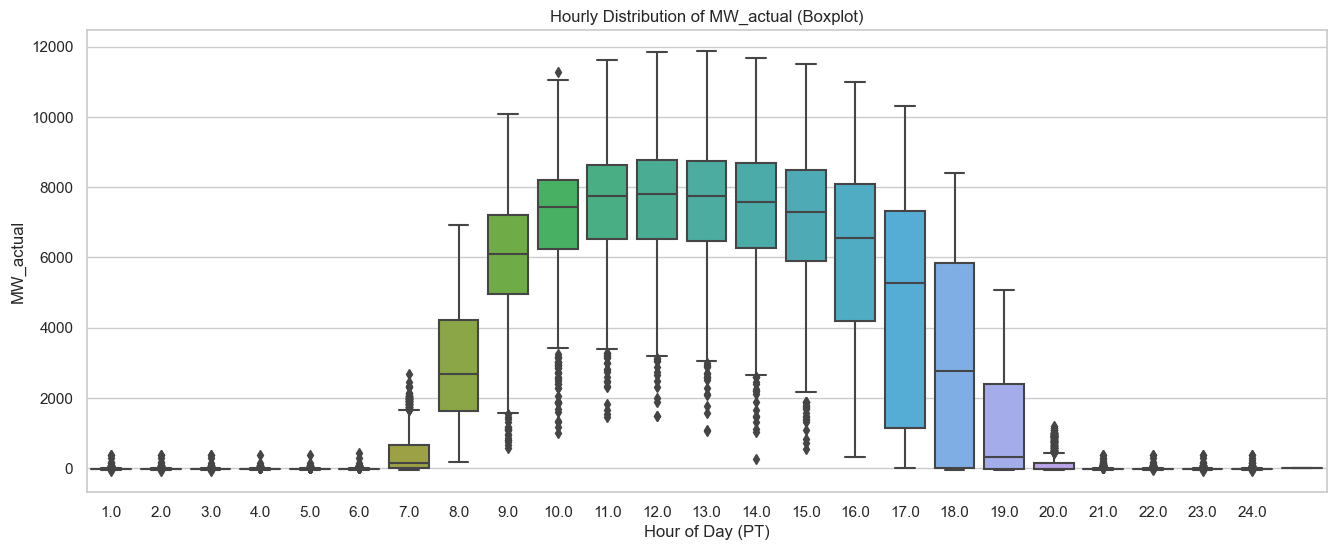

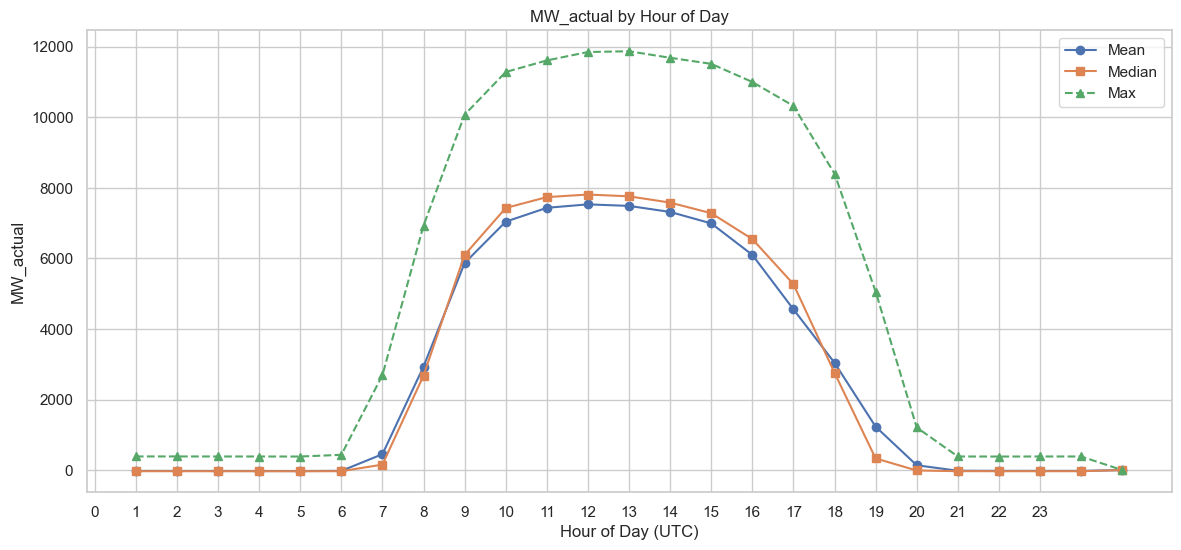

In [121]:
# Style
sns.set(style="whitegrid")

# BOXPLOT: Distribution of MW_actual for each hour
plt.figure(figsize=(16, 6))
sns.boxplot(data=updated_actuals, x="OPR_HR", y="MW_actual", showfliers=True)
plt.title("Hourly Distribution of MW_actual (Boxplot)")
plt.xlabel("Hour of Day (PT)")
plt.ylabel("MW_actual")
plt.xticks(range(24))
plt.show()

# LINE PLOTS: Median, Mean, Max by Hour
hourly_stats = updated_actuals.groupby("OPR_HR")["MW_actual"].agg(["mean", "median", "max"]).reset_index()

plt.figure(figsize=(14, 6))
plt.plot(hourly_stats["OPR_HR"], hourly_stats["mean"], label="Mean", marker="o")
plt.plot(hourly_stats["OPR_HR"], hourly_stats["median"], label="Median", marker="s")
plt.plot(hourly_stats["OPR_HR"], hourly_stats["max"], label="Max", marker="^", linestyle="--")
plt.title("MW_actual by Hour of Day")
plt.xlabel("Hour of Day (UTC)")
plt.ylabel("MW_actual")
plt.legend()
plt.grid(True)
plt.xticks(range(24))
plt.show()


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_ol

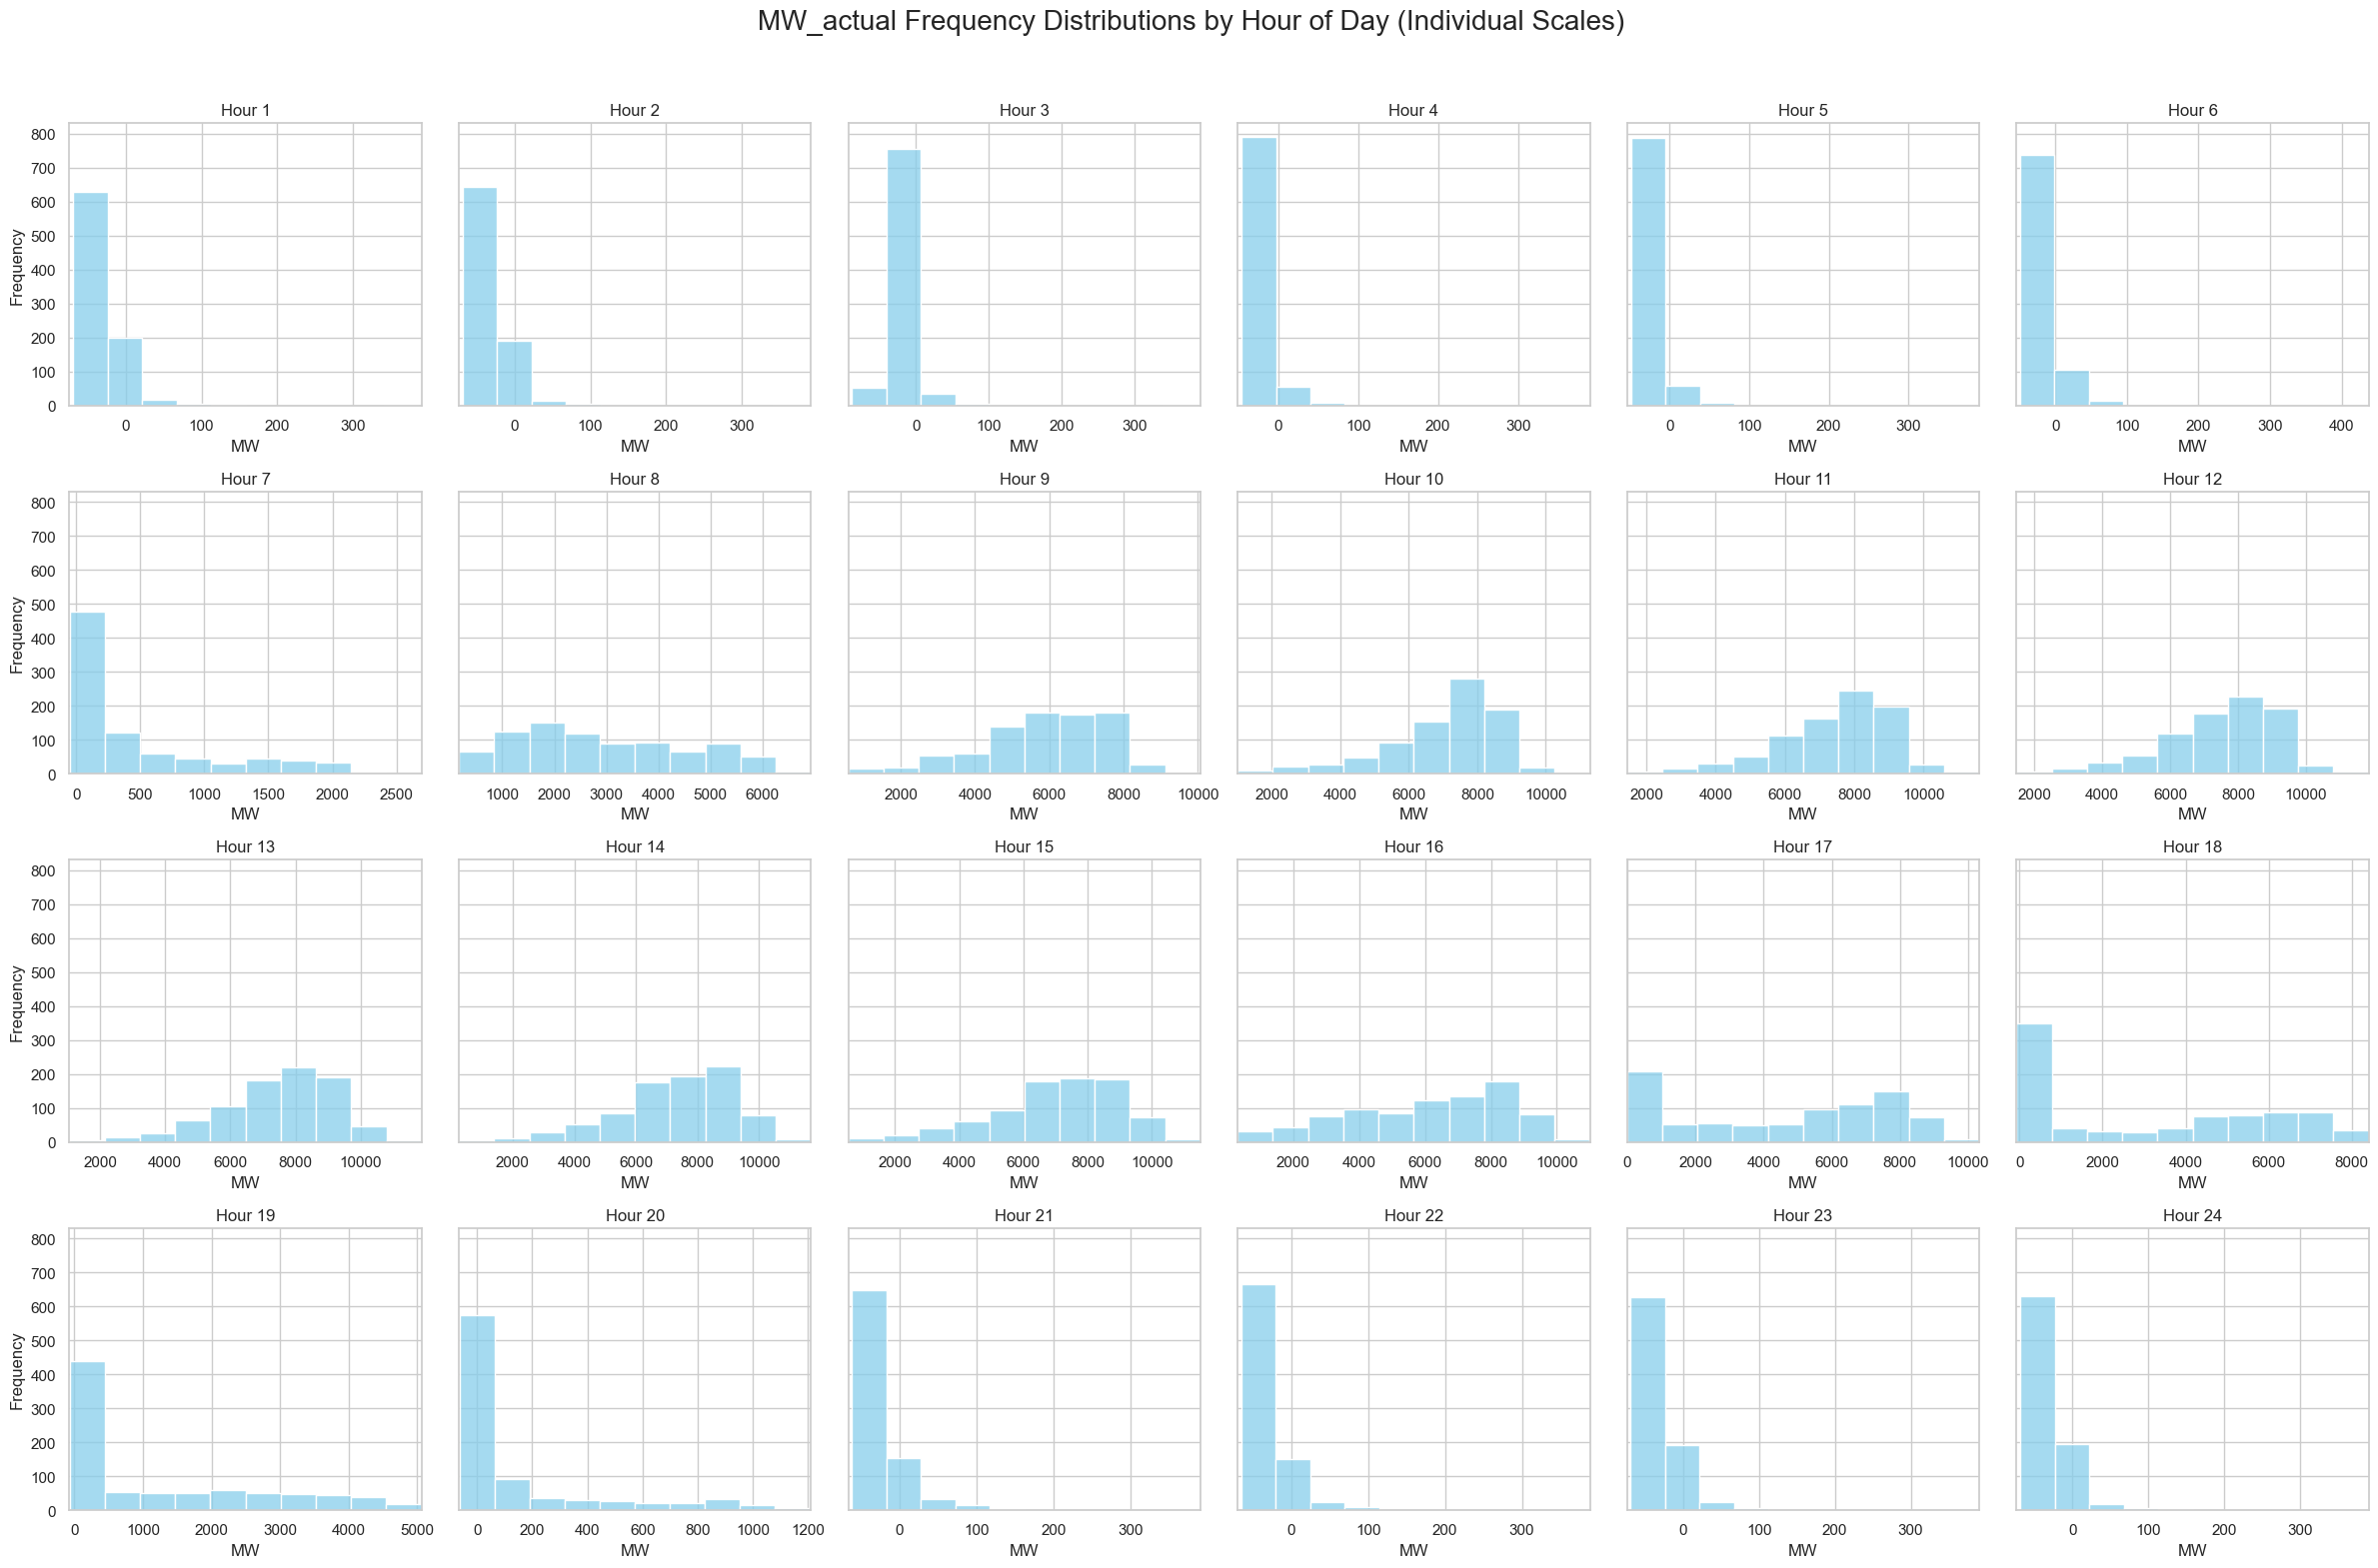

In [123]:
# FREQUENCY DISTRIBUTIONS: Histogram per hour with individual x-axis limits

# Create 24 subplots (4 rows x 6 cols)
fig, axes = plt.subplots(4, 6, figsize=(24, 16), sharey=True)
axes = axes.flatten()

# Loop through each hour and plot histogram with individual x-limits
for hour in range(1, 25):  
    ax = axes[hour - 1]    
    subset = updated_actuals[updated_actuals["OPR_HR"] == hour]

    if not subset.empty:
        sns.histplot(subset["MW_actual"], bins=10, kde=False, ax=ax, color="skyblue")
        ax.set_title(f"Hour {hour}")
        ax.set_xlabel("MW")
        ax.set_ylabel("Frequency")

        # Set dynamic x-axis based on the distribution for that hour
        hour_min = subset["MW_actual"].min()
        hour_max = subset["MW_actual"].max()
        ax.set_xlim(hour_min - 5, hour_max + 5) 

fig.suptitle("MW_actual Frequency Distributions by Hour of Day (Individual Scales)", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [124]:
# Filter for the overnight hours
overnight_hours = [1, 2, 3, 4, 5, 22, 23, 24]
overnight_data = updated_actuals[updated_actuals['OPR_HR'].isin(overnight_hours)] # OPR_HR is hour end, so 9pm-5am

# Define target ranges ±10 MW
min_target = -30 #-88.23478
max_target =  386.38344
tolerance = 10

# Count values near the min
min_near_values = overnight_data[np.abs(overnight_data['MW_actual'] - min_target) <= tolerance]

# Count values near the max
max_near_values = overnight_data[np.abs(overnight_data['MW_actual'] - max_target) <= tolerance]

# Output the counts
print(f"Occurrences within ±10 MW of min value ({min_target:.2f}): {len(min_near_values)}")
print(f"Occurrences within ±10 MW of max value ({max_target:.2f}): {len(max_near_values)}")


Occurrences within ±10 MW of min value (-30.00): 4923
Occurrences within ±10 MW of max value (386.38): 14


Thoughts: Here is what I will do for the questionable non-zero overnight hours. I found that the earliest sunrise in southern California throughout the year is some time between 5am and 6am. The latest that the sun sets in southern California throughout the year is some time between 8pm and 9pm. I will manually zero all MW values between these times. I will also manually zero any/all negative MW values as I know that this isn't possible. Aside from knowing that these values can't be correct, the predicted overnight values indicate the same thing. The predicted values are overwhelmingly zero during these hours, with occasional small positive values for some hours (I suspect this is also an error). Important to note here is that OPR_HR is the PT equivalent to hour end.

In [125]:
# Rename dataset
cleaned_actuals = updated_actuals.copy()

# Create a cleaned MW column starting from the original values
cleaned_actuals['MW_actual_cleaned'] = cleaned_actuals['MW_actual']

# Define overnight hours (hour ending)
overnight_hours = [1, 2, 3, 4, 5, 22, 23, 24]

cleaned_actuals.loc[cleaned_actuals['OPR_HR'].isin(overnight_hours), 'MW_actual_cleaned'] = 0
cleaned_actuals.loc[cleaned_actuals['MW_actual_cleaned'] < 0, 'MW_actual_cleaned'] = 0
cleaned_actuals.head()

,TimeDate,Source,Version,RTO,OPR_DT,OPR_HR,OPR_INTERVAL,INTERVALSTARTTIME_GMT,INTERVALENDTIME_GMT,TRADING_HUB,RENEWABLE_TYPE,LABEL,XML_DATA_ITEM,MARKET_RUN_ID_POS,RENEW_POS,MW_actual,MARKET_RUN_ID,GROUP,MW,MW_actual_cleaned
0,NaN,NaN,NaN,NaN,2021-12-01,1.0,0.0,2021-12-01 08:00:00,2021-12-01T09:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,2.50251,ACTUAL,3.0,NaN,0.0
1,NaN,NaN,NaN,NaN,2021-12-01,2.0,0.0,2021-12-01 09:00:00,2021-12-01T10:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,1.58447,ACTUAL,3.0,NaN,0.0
2,NaN,NaN,NaN,NaN,2021-12-01,3.0,0.0,2021-12-01 10:00:00,2021-12-01T11:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,2.47010,ACTUAL,3.0,NaN,0.0
3,NaN,NaN,NaN,NaN,2021-12-01,4.0,0.0,2021-12-01 11:00:00,2021-12-01T12:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,2.27596,ACTUAL,3.0,NaN,0.0
4,NaN,NaN,NaN,NaN,2021-12-01,5.0,0.0,2021-12-01 12:00:00,2021-12-01T13:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,2.04619,ACTUAL,3.0,NaN,0.0


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_ol

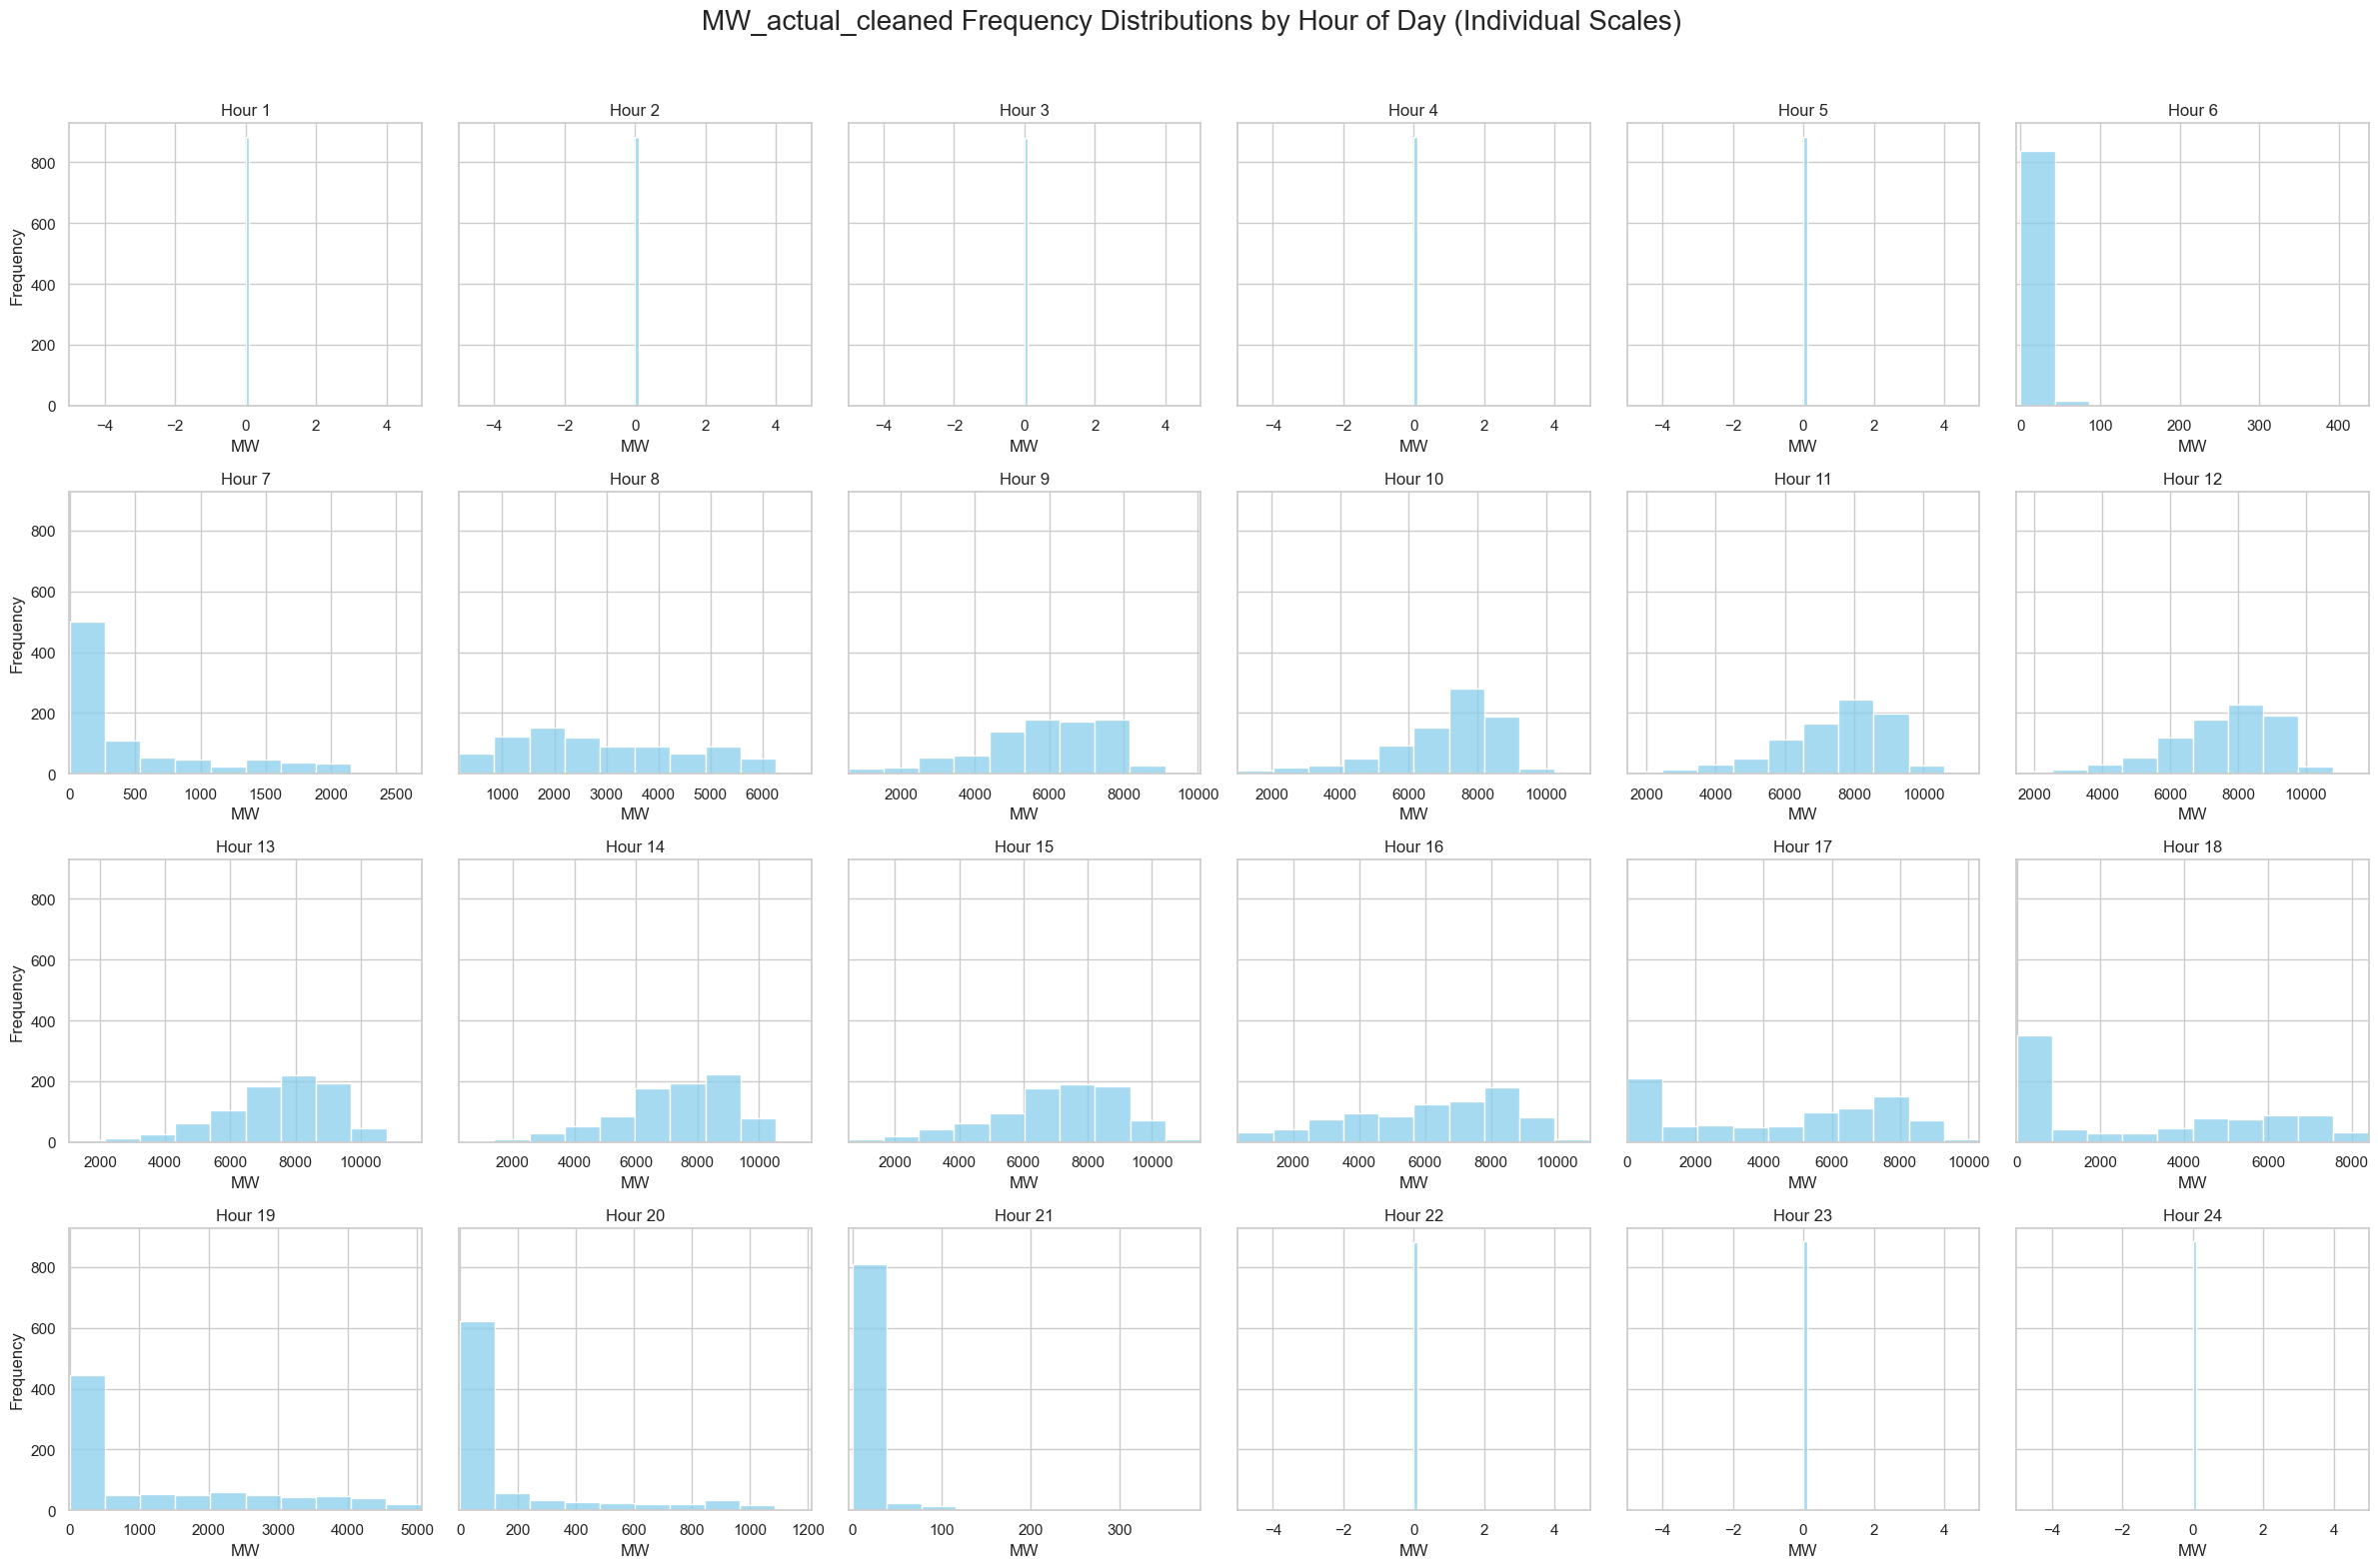

In [126]:
# FREQUENCY DISTRIBUTIONS: Histogram per hour with individual x-axis limits

# Create 24 subplots
fig, axes = plt.subplots(4, 6, figsize=(24, 16), sharey=True)
axes = axes.flatten()

# Loop through each hour and plot histogram with individual x-limits
for hour in range(1, 25):  
    ax = axes[hour - 1]    
    subset = cleaned_actuals[cleaned_actuals["OPR_HR"] == hour]

    if not subset.empty:
        sns.histplot(subset["MW_actual_cleaned"], bins=10, kde=False, ax=ax, color="skyblue")
        ax.set_title(f"Hour {hour}")
        ax.set_xlabel("MW")
        ax.set_ylabel("Frequency")

        # Set dynamic x-axis based on the distribution for that hour
        hour_min = subset["MW_actual_cleaned"].min()
        hour_max = subset["MW_actual_cleaned"].max()
        ax.set_xlim(hour_min - 5, hour_max + 5)  

fig.suptitle("MW_actual_cleaned Frequency Distributions by Hour of Day (Individual Scales)", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
# Save this on the drive
cleaned_actuals.to_csv("/Volumes/USB DISK/NewSP15/Actuals/CleanedActuals/cleanedactuals.csv", index=False)

Thoughts: Now I'll have a look at the predicted values.

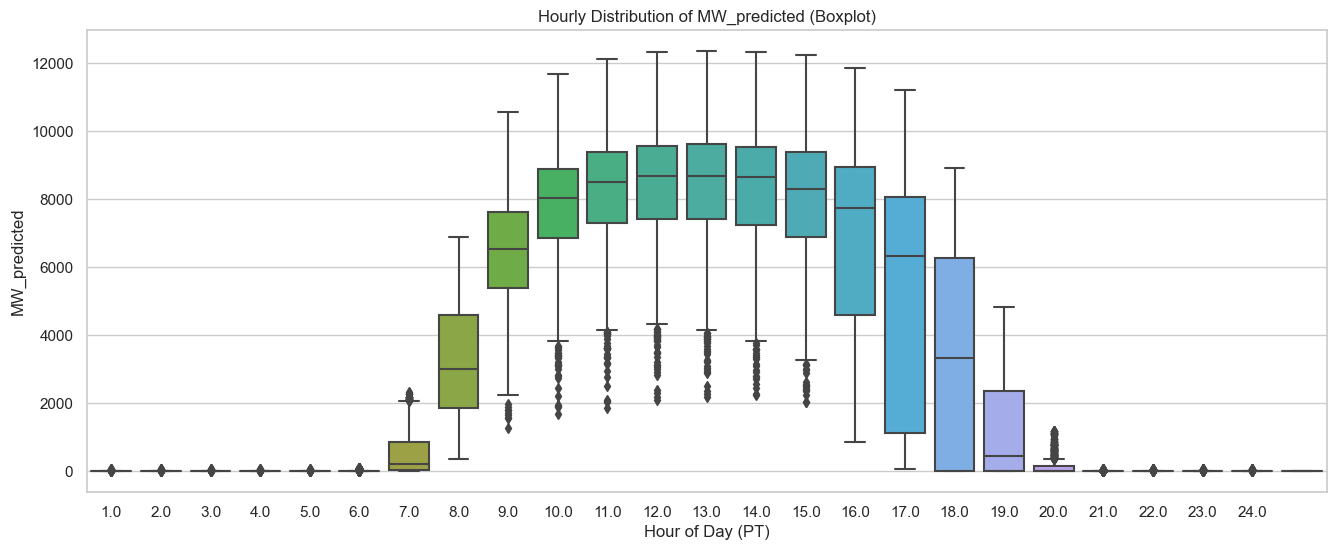

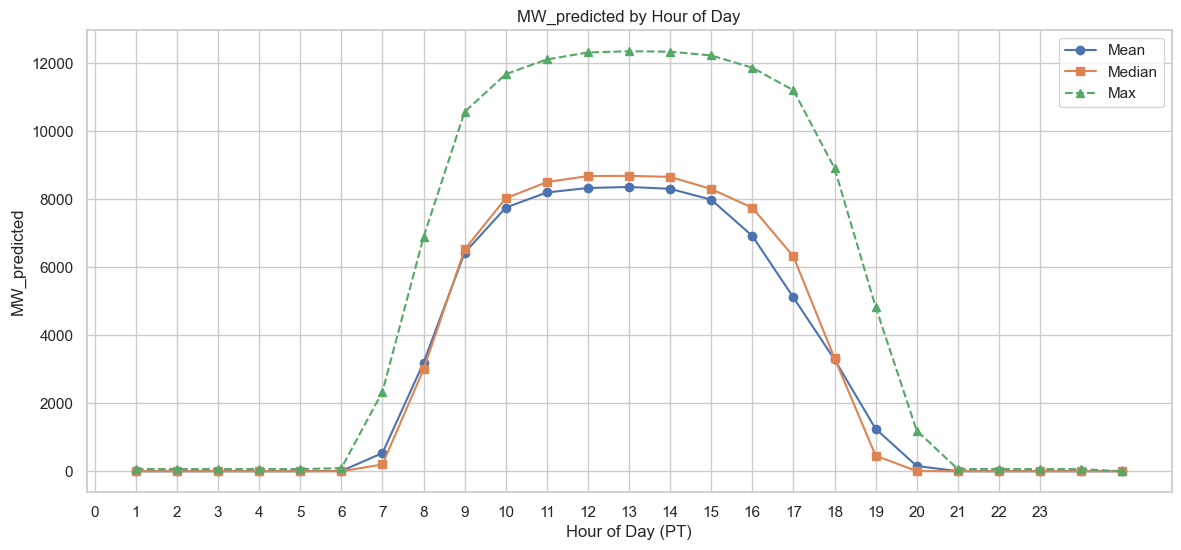

In [127]:
# Style
sns.set(style="whitegrid")

# BOXPLOT: Distribution of MW_actual for each hour
plt.figure(figsize=(16, 6))
sns.boxplot(data=updated_pred, x="OPR_HR", y="MW_predicted", showfliers=True)
plt.title("Hourly Distribution of MW_predicted (Boxplot)")
plt.xlabel("Hour of Day (PT)")
plt.ylabel("MW_predicted")
plt.xticks(range(24))
plt.show()

# LINE PLOTS: Median, Mean, Max by Hour
hourly_stats = updated_pred.groupby("OPR_HR")["MW_predicted"].agg(["mean", "median", "max"]).reset_index()

plt.figure(figsize=(14, 6))
plt.plot(hourly_stats["OPR_HR"], hourly_stats["mean"], label="Mean", marker="o")
plt.plot(hourly_stats["OPR_HR"], hourly_stats["median"], label="Median", marker="s")
plt.plot(hourly_stats["OPR_HR"], hourly_stats["max"], label="Max", marker="^", linestyle="--")
plt.title("MW_predicted by Hour of Day")
plt.xlabel("Hour of Day (PT)")
plt.ylabel("MW_predicted")
plt.legend()
plt.grid(True)
plt.xticks(range(24))
plt.show()


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_ol

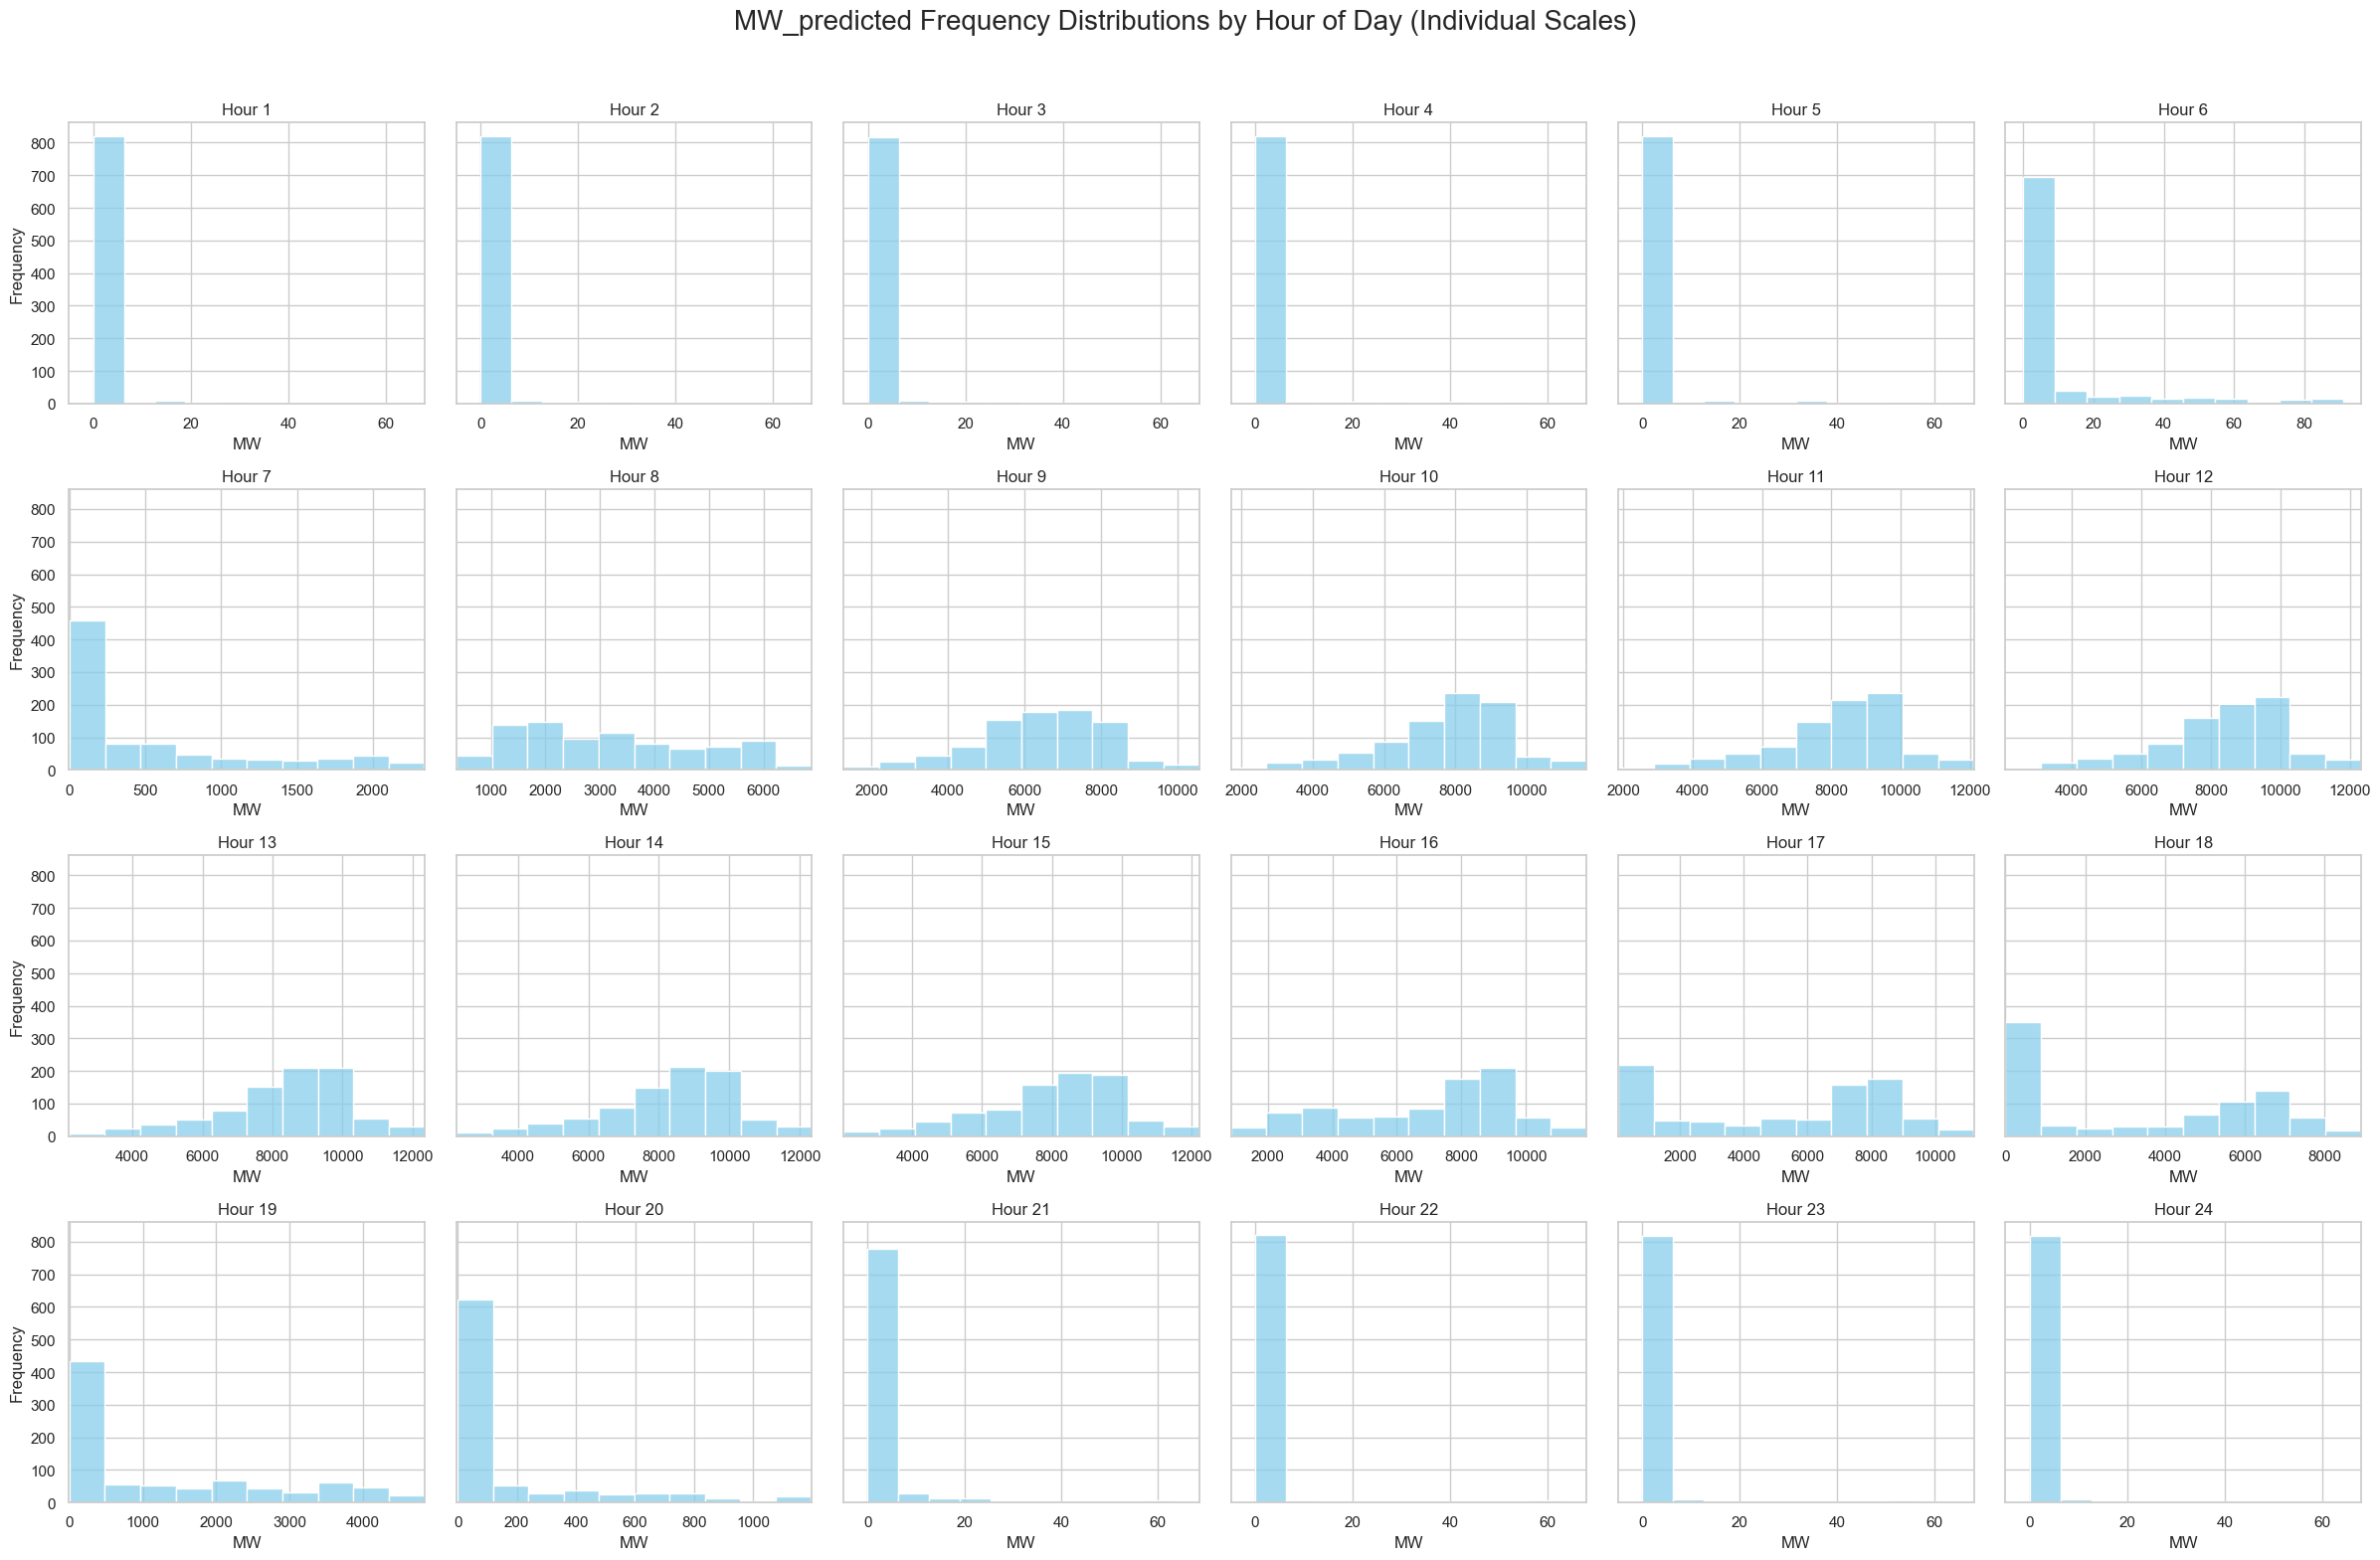

In [128]:
# FREQUENCY DISTRIBUTIONS: Histogram per hour with individual x-axis limits

# Create 24 subplots
fig, axes = plt.subplots(4, 6, figsize=(24, 16), sharey=True)
axes = axes.flatten()

# Loop through each hour and plot histogram with individual x-limits
for hour in range(1, 25):  
    ax = axes[hour - 1]    
    subset = updated_pred[updated_pred["OPR_HR"] == hour]

    if not subset.empty:
        sns.histplot(subset["MW_predicted"], bins=10, kde=False, ax=ax, color="skyblue")
        ax.set_title(f"Hour {hour}")
        ax.set_xlabel("MW")
        ax.set_ylabel("Frequency")

        # Set dynamic x-axis based on the distribution for that hour
        hour_min = subset["MW_predicted"].min()
        hour_max = subset["MW_predicted"].max()
        ax.set_xlim(hour_min - 5, hour_max + 5)  

fig.suptitle("MW_predicted Frequency Distributions by Hour of Day (Individual Scales)", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [129]:
# Take a look at these overnight values

# Filter for the relevant hours (1 AM to 5 AM and 10 PM to 12 AM)
overnight_hours = [0, 1, 2, 3, 4, 21, 22, 23]

# Get the min and max values of MW_actual for these periods
min_max_overnight_values = updated_pred.loc[updated_pred['OPR_HR'].isin(overnight_hours), 'MW_predicted'].agg(['min', 'max'])

print(min_max_overnight_values)


min     0.00
max    63.58
Name: MW_predicted, dtype: float64


In [130]:
# Filter rows where 'MW_predicted' is equal to 63.0
filtered_data = updated_pred[updated_pred['MW_predicted'] == 63.0]

# Take a look
print(filtered_data)

           OPR_DT  OPR_HR  OPR_INTERVAL INTERVALSTARTTIME_GMT  \
15812  2023-09-21    22.0           0.0   2023-09-22 04:00:00   
15813  2023-09-21    23.0           0.0   2023-09-22 05:00:00   
15814  2023-09-21    24.0           0.0   2023-09-22 06:00:00   
16243  2023-10-09    21.0           0.0   2023-10-10 03:00:00   
16244  2023-10-09    22.0           0.0   2023-10-10 04:00:00   
16245  2023-10-09    23.0           0.0   2023-10-10 05:00:00   
16246  2023-10-09    24.0           0.0   2023-10-10 06:00:00   
16266  2023-10-10    20.0           0.0   2023-10-11 02:00:00   
16267  2023-10-10    21.0           0.0   2023-10-11 03:00:00   
16268  2023-10-10    22.0           0.0   2023-10-11 04:00:00   
16269  2023-10-10    23.0           0.0   2023-10-11 05:00:00   
16271  2023-10-11     1.0           0.0   2023-10-11 07:00:00   
16272  2023-10-11     2.0           0.0   2023-10-11 08:00:00   
16273  2023-10-11     3.0           0.0   2023-10-11 09:00:00   
16274  2023-10-11     4.0

Thoughts: There is definitely less of an issue here, but there are still a handful of times overnight that have non-zero values. I will not impute these as they are the predictions that I am trying to beat. NOTE: I made the decision to impute overnight predicted MW values in earlier analysis, but don't think it is the best decision for the final product. However, I will need to rename the dataset and MW value to use that same code.

In [131]:
# Rename the dataset
cleaned_pred = updated_pred.copy()

# Rename the column
cleaned_pred = cleaned_pred.rename(columns={'MW_predicted': 'MW_pred_cleaned'})

In [132]:
cleaned_actuals.head()

,TimeDate,Source,Version,RTO,OPR_DT,OPR_HR,OPR_INTERVAL,INTERVALSTARTTIME_GMT,INTERVALENDTIME_GMT,TRADING_HUB,RENEWABLE_TYPE,LABEL,XML_DATA_ITEM,MARKET_RUN_ID_POS,RENEW_POS,MW_actual,MARKET_RUN_ID,GROUP,MW,MW_actual_cleaned
0,NaN,NaN,NaN,NaN,2021-12-01,1.0,0.0,2021-12-01 08:00:00,2021-12-01T09:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,2.50251,ACTUAL,3.0,NaN,0.0
1,NaN,NaN,NaN,NaN,2021-12-01,2.0,0.0,2021-12-01 09:00:00,2021-12-01T10:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,1.58447,ACTUAL,3.0,NaN,0.0
2,NaN,NaN,NaN,NaN,2021-12-01,3.0,0.0,2021-12-01 10:00:00,2021-12-01T11:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,2.47010,ACTUAL,3.0,NaN,0.0
3,NaN,NaN,NaN,NaN,2021-12-01,4.0,0.0,2021-12-01 11:00:00,2021-12-01T12:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,2.27596,ACTUAL,3.0,NaN,0.0
4,NaN,NaN,NaN,NaN,2021-12-01,5.0,0.0,2021-12-01 12:00:00,2021-12-01T13:00:00-00:00,SP15,Solar,Renewable Forecast Actual Generation,RENEW_FCST_ACT_MW,3.0,3.0,2.04619,ACTUAL,3.0,NaN,0.0


Thoughts: Merge the actuals and predicteds

In [133]:
cleaned_actuals['INTERVALENDTIME_GMT'] = pd.to_datetime(cleaned_actuals['INTERVALENDTIME_GMT'])
cleaned_pred['INTERVALENDTIME_GMT'] = pd.to_datetime(cleaned_pred['INTERVALENDTIME_GMT'])

# Merge datasets on INTERVALENDTIME_GMT
merged_MW = pd.merge(
    cleaned_pred,
    cleaned_actuals[['INTERVALENDTIME_GMT', 'MW_actual_cleaned', 'MW_actual']],
    on='INTERVALENDTIME_GMT',
    how='left'  # use left join to keep all rows from predictions
)

# Check if merge went well
print(f"Resulting dataset has {len(merged_MW)} rows.")
merged_MW[['INTERVALENDTIME_GMT', 'MW_actual_cleaned']].tail()


Resulting dataset has 21215 rows.


,INTERVALENDTIME_GMT,MW_actual_cleaned
21210,2024-05-04 03:00:00+00:00,198.53636
21211,2024-05-04 04:00:00+00:00,0.00000
21212,2024-05-04 05:00:00+00:00,0.00000
21213,2024-05-04 06:00:00+00:00,0.00000
21214,2024-05-04 07:00:00+00:00,0.00000


In [134]:
# Confirm length is correct
len(cleaned_pred)

21215

In [135]:
merged_MW.head()

,OPR_DT,OPR_HR,OPR_INTERVAL,INTERVALSTARTTIME_GMT,INTERVALENDTIME_GMT,TRADING_HUB,RENEWABLE_TYPE,LABEL,XML_DATA_ITEM,MARKET_RUN_ID_POS,...,MW_pred_cleaned,MARKET_RUN_ID,GROUP,TimeDate,Source,Version,RTO,MW,MW_actual_cleaned,MW_actual
0,2021-12-01,1.0,0.0,2021-12-01 08:00:00,2021-12-01 09:00:00+00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1.0,...,0.0,DAM,3.0,NaN,NaN,NaN,NaN,NaN,0.0,2.50251
1,2021-12-01,2.0,0.0,2021-12-01 09:00:00,2021-12-01 10:00:00+00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1.0,...,0.0,DAM,3.0,NaN,NaN,NaN,NaN,NaN,0.0,1.58447
2,2021-12-01,3.0,0.0,2021-12-01 10:00:00,2021-12-01 11:00:00+00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1.0,...,0.0,DAM,3.0,NaN,NaN,NaN,NaN,NaN,0.0,2.47010
3,2021-12-01,4.0,0.0,2021-12-01 11:00:00,2021-12-01 12:00:00+00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1.0,...,0.0,DAM,3.0,NaN,NaN,NaN,NaN,NaN,0.0,2.27596
4,2021-12-01,5.0,0.0,2021-12-01 12:00:00,2021-12-01 13:00:00+00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1.0,...,0.0,DAM,3.0,NaN,NaN,NaN,NaN,NaN,0.0,2.04619


In [136]:
merged_MW.tail()

,OPR_DT,OPR_HR,OPR_INTERVAL,INTERVALSTARTTIME_GMT,INTERVALENDTIME_GMT,TRADING_HUB,RENEWABLE_TYPE,LABEL,XML_DATA_ITEM,MARKET_RUN_ID_POS,...,MW_pred_cleaned,MARKET_RUN_ID,GROUP,TimeDate,Source,Version,RTO,MW,MW_actual_cleaned,MW_actual
21210,2024-05-03,20.0,0.0,2024-05-04 02:00:00,2024-05-04 03:00:00+00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1.0,...,340.29,DAM,99.0,NaN,NaN,NaN,NaN,NaN,198.53636,198.53636
21211,2024-05-03,21.0,0.0,2024-05-04 03:00:00,2024-05-04 04:00:00+00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1.0,...,0.00,DAM,99.0,NaN,NaN,NaN,NaN,NaN,0.00000,-38.96138
21212,2024-05-03,22.0,0.0,2024-05-04 04:00:00,2024-05-04 05:00:00+00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1.0,...,0.00,DAM,99.0,NaN,NaN,NaN,NaN,NaN,0.00000,-35.67349
21213,2024-05-03,23.0,0.0,2024-05-04 05:00:00,2024-05-04 06:00:00+00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1.0,...,0.00,DAM,99.0,NaN,NaN,NaN,NaN,NaN,0.00000,-35.22847
21214,2024-05-03,24.0,0.0,2024-05-04 06:00:00,2024-05-04 07:00:00+00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,1.0,...,0.00,DAM,99.0,NaN,NaN,NaN,NaN,NaN,0.00000,-39.58521


Thoughts: I confirmed on the API dashboard that these predicted and actual values are aligned correctly.

In [ ]:
# Let's save this on the drive
merged_MW.to_csv("/Volumes/USB DISK/NewSP15/MergedMW/merged_MW.csv", index=False)

#### Merging With Weather Data

In [137]:
# Merge with HRRR data

# Convert INTERVALSTARTTIME_GMT to UTC
merged_MW['INTERVALSTARTTIME_GMT'] = pd.to_datetime(merged_MW['INTERVALSTARTTIME_GMT'], utc=True)
merged_MW['INTERVALSTARTTIME_GMT'] = merged_MW['INTERVALSTARTTIME_GMT'].dt.tz_convert('UTC').dt.tz_localize(None)

working_checkpoint['valid_time'] = pd.to_datetime(working_checkpoint['valid_time'])  # Already UTC naive

# Select only columns I want
cols_to_merge = [
    'INTERVALSTARTTIME_GMT', 'MW_actual_cleaned', 'MW_pred_cleaned',
    'OPR_DT', 'OPR_HR', 'INTERVALENDTIME_GMT',
    'TRADING_HUB', 'RENEWABLE_TYPE', 'LABEL', 'XML_DATA_ITEM'
]
merged_subset = merged_MW[cols_to_merge].copy()

# Rename columns
merged_subset = merged_subset.rename(columns={
    col: f"{col}_CAISO" for col in cols_to_merge if col != 'INTERVALSTARTTIME_GMT'
})

# Merge!
final_merged = pd.merge(
    working_checkpoint,
    merged_subset,
    left_on='valid_time',
    right_on='INTERVALSTARTTIME_GMT',
    how='left'
)

# Confirm
print(f"Merged dataset shape: {final_merged.shape}")
final_merged.head()


Merged dataset shape: (89765, 75)


,Unnamed: 0,step,point,time,surface,latitude,longitude,valid_time,metpy_crs,unknown,...,INTERVALSTARTTIME_GMT,MW_actual_cleaned_CAISO,MW_pred_cleaned_CAISO,OPR_DT_CAISO,OPR_HR_CAISO,INTERVALENDTIME_GMT_CAISO,TRADING_HUB_CAISO,RENEWABLE_TYPE_CAISO,LABEL_CAISO,XML_DATA_ITEM_CAISO
0,46935.0,0 days 19:00:00,4239,2020-12-05 12:00:00,0.0,33.208817,244.723222,2020-12-06 07:00:00,Projection: lambert_conformal_conic,0.0,...,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN
1,48777.0,0 days 19:00:00,6081,2020-12-05 12:00:00,0.0,34.818891,241.688987,2020-12-06 07:00:00,Projection: lambert_conformal_conic,0.0,...,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN
2,47696.0,0 days 19:00:00,5000,2020-12-05 12:00:00,0.0,34.870602,243.187135,2020-12-06 07:00:00,Projection: lambert_conformal_conic,0.0,...,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN
3,61167.0,0 days 20:00:00,4239,2020-12-05 12:00:00,0.0,33.208817,244.723222,2020-12-06 08:00:00,Projection: lambert_conformal_conic,0.0,...,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN
4,61928.0,0 days 20:00:00,5000,2020-12-05 12:00:00,0.0,34.870602,243.187135,2020-12-06 08:00:00,Projection: lambert_conformal_conic,0.0,...,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN


In [138]:
final_merged.head(30000).tail()

,Unnamed: 0,step,point,time,surface,latitude,longitude,valid_time,metpy_crs,unknown,...,INTERVALSTARTTIME_GMT,MW_actual_cleaned_CAISO,MW_pred_cleaned_CAISO,OPR_DT_CAISO,OPR_HR_CAISO,INTERVALENDTIME_GMT_CAISO,TRADING_HUB_CAISO,RENEWABLE_TYPE_CAISO,LABEL_CAISO,XML_DATA_ITEM_CAISO
29995,NaN,1 days 17:00:00,6081,2022-01-25 12:00:00,0.0,34.818891,241.688987,2022-01-27 05:00:00,Projection: lambert_conformal_conic,0.0,...,2022-01-27 05:00:00,0.0,0.0,2022-01-26,22.0,2022-01-27 06:00:00+00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW
29996,NaN,1 days 18:00:00,5000,2022-01-25 12:00:00,0.0,34.870602,243.187135,2022-01-27 06:00:00,Projection: lambert_conformal_conic,0.0,...,2022-01-27 06:00:00,0.0,0.0,2022-01-26,23.0,2022-01-27 07:00:00+00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW
29997,NaN,1 days 18:00:00,6081,2022-01-25 12:00:00,0.0,34.818891,241.688987,2022-01-27 06:00:00,Projection: lambert_conformal_conic,0.0,...,2022-01-27 06:00:00,0.0,0.0,2022-01-26,23.0,2022-01-27 07:00:00+00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW
29998,NaN,1 days 18:00:00,4239,2022-01-25 12:00:00,0.0,33.208817,244.723222,2022-01-27 06:00:00,Projection: lambert_conformal_conic,0.0,...,2022-01-27 06:00:00,0.0,0.0,2022-01-26,23.0,2022-01-27 07:00:00+00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW
29999,48777.0,0 days 19:00:00,6081,2022-01-26 12:00:00,0.0,34.818891,241.688987,2022-01-27 07:00:00,Projection: lambert_conformal_conic,0.0,...,2022-01-27 07:00:00,0.0,0.0,2022-01-26,24.0,2022-01-27 08:00:00+00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW


In [139]:
final_merged.columns

Index(['Unnamed: 0', 'step', 'point', 'time', 'surface', 'latitude',
       'longitude', 'valid_time', 'metpy_crs', 'unknown', 'siconc', 'cape',
       't', 'sp', 'blh', 'lsm', 'ishf', 'fsr', 'vis', 'prate', 'sde', 'cin',
       'orog', 'tp', 'lhtfl', 'hail', 'crain', 'cfrzr', 'cicep', 'csnow',
       'cpofp', 'snowc', 'sdwe', 'gust', 'fricv', 'dswrf', 'uswrf', 'dlwrf',
       'ulwrf', 'bgrun', 'ssrun', 'veg', 'gflux', 'cnwat', 'frzr', 'cfnsf',
       'vbdsf', 'vddsf', 'lai', 'vgtyp', 'gribfile_projection', 'y', 'x',
       'point_latitude', 'point_longitude', 'Unnamed: 0.1', 'gppbfas',
       'Unnamed: 0.2', 'valid_time_PT', 'point_id', 't_F', 'point_name',
       'hour', 'valid_date_PT', 'valid_hour_PT', 'INTERVALSTARTTIME_GMT',
       'MW_actual_cleaned_CAISO', 'MW_pred_cleaned_CAISO', 'OPR_DT_CAISO',
       'OPR_HR_CAISO', 'INTERVALENDTIME_GMT_CAISO', 'TRADING_HUB_CAISO',
       'RENEWABLE_TYPE_CAISO', 'LABEL_CAISO', 'XML_DATA_ITEM_CAISO'],
      dtype='object')

In [140]:
# Take a look at a spot in the middle of the dataset
final_merged[['valid_date_PT', 'valid_hour_PT', 'INTERVALSTARTTIME_GMT', 'INTERVALENDTIME_GMT_CAISO', 'MW_actual_cleaned_CAISO', 'MW_pred_cleaned_CAISO']].head(35230).tail()

,valid_date_PT,valid_hour_PT,INTERVALSTARTTIME_GMT,INTERVALENDTIME_GMT_CAISO,MW_actual_cleaned_CAISO,MW_pred_cleaned_CAISO
35225,2022-04-09,14,2022-04-09 21:00:00,2022-04-09 22:00:00+00:00,6319.15125,8925.25
35226,2022-04-09,14,2022-04-09 21:00:00,2022-04-09 22:00:00+00:00,6319.15125,8925.25
35227,2022-04-09,14,2022-04-09 21:00:00,2022-04-09 22:00:00+00:00,6319.15125,8925.25
35228,2022-04-09,15,2022-04-09 22:00:00,2022-04-09 23:00:00+00:00,6722.09368,8614.59
35229,2022-04-09,15,2022-04-09 22:00:00,2022-04-09 23:00:00+00:00,6722.09368,8614.59


Thoughts: Great. Again, I cross checked this with several dates & times on the API dashboard and the merge looks correct and consistent in terms of dates, times, and MW actual and predicted values. However, this data is still limited by what I have in the merged_MW data in terms of dates. I'll trim things to only keep rows that have both predicted and actual MW values as that is the target.

In [145]:
# Only keep rows where both actuals and predicteds are present
complete_df = final_merged[
    final_merged["MW_actual_cleaned_CAISO"].notna() & final_merged["MW_pred_cleaned_CAISO"].notna()
].reset_index(drop=True)
print(complete_df.shape)
complete_df.head()

(60396, 75)


,Unnamed: 0,step,point,time,surface,latitude,longitude,valid_time,metpy_crs,unknown,...,INTERVALSTARTTIME_GMT,MW_actual_cleaned_CAISO,MW_pred_cleaned_CAISO,OPR_DT_CAISO,OPR_HR_CAISO,INTERVALENDTIME_GMT_CAISO,TRADING_HUB_CAISO,RENEWABLE_TYPE_CAISO,LABEL_CAISO,XML_DATA_ITEM_CAISO
0,61928.0,0 days 20:00:00,5000,2021-11-30 12:00:00,0.0,34.870602,243.187135,2021-12-01 08:00:00,Projection: lambert_conformal_conic,0.0,...,2021-12-01 08:00:00,0.0,0.0,2021-12-01,1.0,2021-12-01 09:00:00+00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW
1,63009.0,0 days 20:00:00,6081,2021-11-30 12:00:00,0.0,34.818891,241.688987,2021-12-01 08:00:00,Projection: lambert_conformal_conic,0.0,...,2021-12-01 08:00:00,0.0,0.0,2021-12-01,1.0,2021-12-01 09:00:00+00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW
2,61167.0,0 days 20:00:00,4239,2021-11-30 12:00:00,0.0,33.208817,244.723222,2021-12-01 08:00:00,Projection: lambert_conformal_conic,0.0,...,2021-12-01 08:00:00,0.0,0.0,2021-12-01,1.0,2021-12-01 09:00:00+00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW
3,76160.0,0 days 21:00:00,5000,2021-11-30 12:00:00,0.0,34.870602,243.187135,2021-12-01 09:00:00,Projection: lambert_conformal_conic,0.0,...,2021-12-01 09:00:00,0.0,0.0,2021-12-01,2.0,2021-12-01 10:00:00+00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW
4,77241.0,0 days 21:00:00,6081,2021-11-30 12:00:00,0.0,34.818891,241.688987,2021-12-01 09:00:00,Projection: lambert_conformal_conic,0.0,...,2021-12-01 09:00:00,0.0,0.0,2021-12-01,2.0,2021-12-01 10:00:00+00:00,SP15,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW


In [146]:
# Take a look
complete_df[['point_name','valid_date_PT', 'valid_hour_PT', 'INTERVALSTARTTIME_GMT', 'INTERVALENDTIME_GMT_CAISO', 'MW_actual_cleaned_CAISO', 'MW_pred_cleaned_CAISO']].head()

,point_name,valid_date_PT,valid_hour_PT,INTERVALSTARTTIME_GMT,INTERVALENDTIME_GMT_CAISO,MW_actual_cleaned_CAISO,MW_pred_cleaned_CAISO
0,Barstow,2021-12-01,0,2021-12-01 08:00:00,2021-12-01 09:00:00+00:00,0.0,0.0
1,Rosamond,2021-12-01,0,2021-12-01 08:00:00,2021-12-01 09:00:00+00:00,0.0,0.0
2,Blythe,2021-12-01,0,2021-12-01 08:00:00,2021-12-01 09:00:00+00:00,0.0,0.0
3,Barstow,2021-12-01,1,2021-12-01 09:00:00,2021-12-01 10:00:00+00:00,0.0,0.0
4,Rosamond,2021-12-01,1,2021-12-01 09:00:00,2021-12-01 10:00:00+00:00,0.0,0.0


In [147]:
# Create an error variable
complete_df.loc[:, "MW_error"] = complete_df["MW_actual_cleaned_CAISO"] - complete_df['MW_pred_cleaned_CAISO']

In [148]:
# Let's save this on the drive
complete_df.to_csv("/Volumes/USB DISK/NewSP15/AllMergedNew/AllCleanedv2.csv", index=False)

In [149]:
complete_df = pd.read_csv("/Volumes/USB DISK/NewSP15/AllMergedNew/AllCleanedv2.csv")

### Continued EDA / Feature Engineering

In [ ]:
# Create a 'season' variable in the event that I want to remove month
def assign_season(month):
    if month in [12, 1, 2]:
        return 'winter'
    elif month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    else:  # months 9, 10, 11
        return 'fall'

complete_df['valid_date_PT'] = pd.to_datetime(complete_df['valid_date_PT'])
complete_df['season'] = complete_df['valid_date_PT'].dt.month.apply(assign_season)

# Encode the season
season_dummies = pd.get_dummies(complete_df['season'], prefix='season')
complete_df = pd.concat([complete_df, season_dummies], axis=1)

# Check dis out
complete_df[['valid_date_PT', 'season']].head()

,valid_date_PT,season
0,2021-12-01,winter
1,2021-12-01,winter
2,2021-12-01,winter
3,2021-12-01,winter
4,2021-12-01,winter


In [151]:
complete_df[['season_winter']].head()

,season_winter
0,True
1,True
2,True
3,True
4,True


Thoughts: In a perfect world, I could manipulate time to add a 1-day lag of actual MW generated for each hour. However, the HRRR forecasts are released daily at 12 UTC (~4am PT) of the day prior to the forecast. This means I won't have "today's" values at the time that I am forecasting for tomorrow. However, it looks like actual hourly MW gen values are released almost in real time, so I can add a two day lag for actual MW gen. (predicting tomorrow 2 pm at 4am today. So I don't have 2pm data from today yet)

In [152]:
# Sort by valid_time_PT 
complete_df = complete_df.sort_values(['valid_time_PT', 'point']).reset_index(drop=True)

# Drop duplicate CAISO-level MW_actual values
# (Only want one MW_actual_cleaned_CAISO value per timestamp)
caiso_actuals = complete_df[['valid_time_PT', 'MW_actual_cleaned_CAISO']].drop_duplicates()

# Shift by 48 hours (2 days)
# Because valid_time_PT has timezone info, shifting works correctly across DST changes
caiso_actuals['MW_actual_cleaned_CAISO_lag2days'] = caiso_actuals['MW_actual_cleaned_CAISO'].shift(48)

# Merge back into full dataset
complete_df = complete_df.merge(
    caiso_actuals[['valid_time_PT', 'MW_actual_cleaned_CAISO_lag2days']],
    on='valid_time_PT',
    how='left'
)
caiso_actuals[['valid_time_PT', 'MW_actual_cleaned_CAISO', 'MW_actual_cleaned_CAISO_lag2days']].head(100)
complete_df.head(100)

,Unnamed: 0,step,point,time,surface,latitude,longitude,valid_time,metpy_crs,unknown,...,RENEWABLE_TYPE_CAISO,LABEL_CAISO,XML_DATA_ITEM_CAISO,MW_error,season,season_fall,season_spring,season_summer,season_winter,MW_actual_cleaned_CAISO_lag2days
0,61167.0,0 days 20:00:00,4239,2021-11-30 12:00:00,0.0,33.208817,244.723222,2021-12-01 08:00:00,Projection: lambert_conformal_conic,0.0,...,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,0.00000,winter,False,False,False,True,NaN
1,61928.0,0 days 20:00:00,5000,2021-11-30 12:00:00,0.0,34.870602,243.187135,2021-12-01 08:00:00,Projection: lambert_conformal_conic,0.0,...,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,0.00000,winter,False,False,False,True,NaN
2,63009.0,0 days 20:00:00,6081,2021-11-30 12:00:00,0.0,34.818891,241.688987,2021-12-01 08:00:00,Projection: lambert_conformal_conic,0.0,...,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,0.00000,winter,False,False,False,True,NaN
3,75399.0,0 days 21:00:00,4239,2021-11-30 12:00:00,0.0,33.208817,244.723222,2021-12-01 09:00:00,Projection: lambert_conformal_conic,0.0,...,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,0.00000,winter,False,False,False,True,NaN
4,76160.0,0 days 21:00:00,5000,2021-11-30 12:00:00,0.0,34.870602,243.187135,2021-12-01 09:00:00,Projection: lambert_conformal_conic,0.0,...,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,0.00000,winter,False,False,False,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,162633.0,1 days 03:00:00,6081,2021-12-01 12:00:00,0.0,34.818891,241.688987,2021-12-02 15:00:00,Projection: lambert_conformal_conic,0.0,...,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,-292.92318,winter,False,False,False,True,NaN
96,175023.0,1 days 04:00:00,4239,2021-12-01 12:00:00,0.0,33.208817,244.723222,2021-12-02 16:00:00,Projection: lambert_conformal_conic,0.0,...,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,-161.30868,winter,False,False,False,True,NaN
97,175784.0,1 days 04:00:00,5000,2021-12-01 12:00:00,0.0,34.870602,243.187135,2021-12-02 16:00:00,Projection: lambert_conformal_conic,0.0,...,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,-161.30868,winter,False,False,False,True,NaN
98,176865.0,1 days 04:00:00,6081,2021-12-01 12:00:00,0.0,34.818891,241.688987,2021-12-02 16:00:00,Projection: lambert_conformal_conic,0.0,...,Solar,Renewable Forecast Day Ahead,RENEW_FCST_DA_MW,-161.30868,winter,False,False,False,True,NaN


In [153]:
# I'm an idiot, the first two days don't have a 2 day lag so I won't be able to see the data in .head()
caiso_actuals[['valid_time_PT', 'MW_actual_cleaned_CAISO', 'MW_actual_cleaned_CAISO_lag2days']].tail(60)

,valid_time_PT,MW_actual_cleaned_CAISO,MW_actual_cleaned_CAISO_lag2days
60216,2024-05-01 12:00:00-07:00,10784.43245,10231.73835
60219,2024-05-01 13:00:00-07:00,10633.56842,10145.85967
60222,2024-05-01 14:00:00-07:00,10533.44989,9838.09176
60225,2024-05-01 15:00:00-07:00,9902.26576,9682.17573
60228,2024-05-01 16:00:00-07:00,9160.59697,9312.00097
60231,2024-05-01 17:00:00-07:00,8202.97595,8211.06092
60234,2024-05-01 18:00:00-07:00,3557.54333,3449.73432
60237,2024-05-01 19:00:00-07:00,176.47347,166.82088
60240,2024-05-01 20:00:00-07:00,0.00000,0.00000
60243,2024-05-01 21:00:00-07:00,0.00000,0.00000


Thoughts: The above print output is just confirming that the two day lag was set up correctly and aligned as intended. Looks good.

In [154]:
# Awesome. The merging set looks accurate, let's make sure things still look good here. Will need two .head calls given we replicate these values for each point for each hour
complete_df[['valid_time_PT', 'valid_hour_PT', 'point_name', 'MW_actual_cleaned_CAISO', 'MW_actual_cleaned_CAISO_lag2days']].tail(60).head(10)

,valid_time_PT,valid_hour_PT,point_name,MW_actual_cleaned_CAISO,MW_actual_cleaned_CAISO_lag2days
60336,2024-05-03 04:00:00-07:00,4,Blythe,0.00000,0.00000
60337,2024-05-03 04:00:00-07:00,4,Barstow,0.00000,0.00000
60338,2024-05-03 04:00:00-07:00,4,Rosamond,0.00000,0.00000
60339,2024-05-03 05:00:00-07:00,5,Blythe,0.00000,0.00000
60340,2024-05-03 05:00:00-07:00,5,Barstow,0.00000,0.00000
60341,2024-05-03 05:00:00-07:00,5,Rosamond,0.00000,0.00000
60342,2024-05-03 06:00:00-07:00,6,Blythe,1424.41811,1526.83535
60343,2024-05-03 06:00:00-07:00,6,Barstow,1424.41811,1526.83535
60344,2024-05-03 06:00:00-07:00,6,Rosamond,1424.41811,1526.83535
60345,2024-05-03 07:00:00-07:00,7,Blythe,6682.41047,6931.18972


In [155]:
complete_df[['valid_time_PT', 'valid_hour_PT', 'point_name', 'MW_actual_cleaned_CAISO', 'MW_actual_cleaned_CAISO_lag2days']].tail(204).head(10)

,valid_time_PT,valid_hour_PT,point_name,MW_actual_cleaned_CAISO,MW_actual_cleaned_CAISO_lag2days
60192,2024-05-01 04:00:00-07:00,4,Blythe,0.00000,0.00000
60193,2024-05-01 04:00:00-07:00,4,Barstow,0.00000,0.00000
60194,2024-05-01 04:00:00-07:00,4,Rosamond,0.00000,0.00000
60195,2024-05-01 05:00:00-07:00,5,Blythe,0.00000,0.00000
60196,2024-05-01 05:00:00-07:00,5,Barstow,0.00000,0.00000
60197,2024-05-01 05:00:00-07:00,5,Rosamond,0.00000,0.00000
60198,2024-05-01 06:00:00-07:00,6,Blythe,1526.83535,1351.57383
60199,2024-05-01 06:00:00-07:00,6,Barstow,1526.83535,1351.57383
60200,2024-05-01 06:00:00-07:00,6,Rosamond,1526.83535,1351.57383
60201,2024-05-01 07:00:00-07:00,7,Blythe,6931.18972,6585.51511


Thoughts: Awesome. This works.

More Thoughts: Another big thing to consider is how data was recorded from the two main sources (HRRR weather & CAISO API).

HRRR - Hourly forecasted weather values AT a specific point in time for a given location.

CAISO - Actual and forecasted solar energy generation for an INTERVAL of time for the SP15 region of California.

Given this difference, I'd like to create a list of new HRRR variables that represent the average value (quantitative vars only) between start hour and end hour for each hourly interval. My thinking is that this would be a marginally better representation of the weather for a given location for the INTERVAL of time that this solar energy is collected across. I will do this for all of the numeric variables in the dataset and then decide which version to use when I create my feature matrix. Important to note that this is not an appropriate transformation for all numeric variables, but this will just give me the option, and allow me to make that decision once I get to feature selection.

In [156]:
# Only include numeric float64 or int32 columns from 'siconc' to 'lai'
start_col = 'siconc'
end_col = 'lai' # These are basically just our bounds for the potential HRRR weather features
cols_range = complete_df.columns.tolist()
start_idx = cols_range.index(start_col)
end_idx = cols_range.index(end_col) + 1
weather_cols = cols_range[start_idx:end_idx]

# Filter only float64 or int32 columns
numeric_weather_cols = [col for col in weather_cols if complete_df[col].dtype in ['float64', 'int32']]

# Sort and group
w_avgs_sorted = complete_df.sort_values(['point', 'valid_time']).copy()
w_avgs_sorted['valid_time'] = pd.to_datetime(w_avgs_sorted['valid_time'])

# Compute average with next hour if available and same location
for col in numeric_weather_cols:
    next_valid_time = w_avgs_sorted.groupby("point")["valid_time"].shift(-1)
    next_val = w_avgs_sorted.groupby("point")[col].shift(-1)
    next_valid_time = pd.to_datetime(next_valid_time)
    time_diff = (next_valid_time - w_avgs_sorted["valid_time"]).dt.total_seconds() / 3600
    same_hour = (time_diff == 1)
    w_avgs_sorted[f"{col}_avg"] = w_avgs_sorted[col].where(~same_hour, (w_avgs_sorted[col] + next_val) / 2)

w_avgs_sorted[['point', 'point_name', 'valid_date_PT', 'valid_hour_PT', 't', 't_avg', 'sp', 'sp_avg']].head(10)

,point,point_name,valid_date_PT,valid_hour_PT,t,t_avg,sp,sp_avg
0,4239,Blythe,2021-12-01,0,289.66907,291.312715,98640.0,98655.0
3,4239,Blythe,2021-12-01,1,292.95636,292.921690,98670.0,98690.0
6,4239,Blythe,2021-12-01,2,292.88702,292.948210,98710.0,98715.0
9,4239,Blythe,2021-12-01,3,293.00940,293.220400,98720.0,98720.0
12,4239,Blythe,2021-12-01,4,293.43140,293.208315,98720.0,98735.0
15,4239,Blythe,2021-12-01,5,292.98523,292.782075,98750.0,98790.0
18,4239,Blythe,2021-12-01,6,292.57892,292.704195,98830.0,98845.0
21,4239,Blythe,2021-12-01,7,292.82947,294.212335,98860.0,98875.0
24,4239,Blythe,2021-12-01,8,295.59520,297.249140,98890.0,98945.0
27,4239,Blythe,2021-12-01,9,298.90308,300.351670,99000.0,99005.0


Thoughts: Let's manually confirm a few edge cases.

In [157]:
# Cross checking to make sure values turned out as intended
print("t examples")
print((289.66907+292.95636)/2)
print((292.95636+292.88702)/2)
print((292.88702+293.00940)/2)
print("sp examples")
print((98640.0+98670.0)/2)
print((98670.0+98710.0)/2)
print((98710.0+98720.0)/2)

t examples
291.312715
292.92169
292.94821
sp examples
98655.0
98690.0
98715.0


In [158]:
# Getting shape and dividing by three to find where location changes so I can check that I'm not averaging last observation at one location with first observation of new location
w_avgs_sorted.shape

(60396, 121)

In [159]:
60396/3

20132.0

In [162]:
# Look at variables when 'point_name' changes
w_avgs_sorted[['point', 'point_name', 'valid_date_PT', 'valid_hour_PT', 't', 't_avg', 'sp', 'sp_avg']].head(20137).tail(10)

,point,point_name,valid_date_PT,valid_hour_PT,t,t_avg,sp,sp_avg
60381,4239,Blythe,2024-05-03,19,302.977360,301.522845,97610.0,97625.0
60384,4239,Blythe,2024-05-03,20,300.068330,299.244950,97640.0,97685.0
60387,4239,Blythe,2024-05-03,21,298.421570,297.590698,97730.0,97740.0
60390,4239,Blythe,2024-05-03,22,296.759827,296.043152,97750.0,97745.0
60393,4239,Blythe,2024-05-03,23,295.326477,295.326477,97740.0,97740.0
1,5000,Barstow,2021-12-01,0,278.794070,278.343965,95190.0,95220.0
4,5000,Barstow,2021-12-01,1,277.893860,277.577940,95250.0,95270.0
7,5000,Barstow,2021-12-01,2,277.262020,277.010710,95290.0,95280.0
10,5000,Barstow,2021-12-01,3,276.759400,276.595400,95270.0,95255.0
13,5000,Barstow,2021-12-01,4,276.431400,276.177065,95240.0,95255.0


In [163]:
print("t examples")
print((302.977360+300.068330)/2)
print((300.068330+298.421570)/2)
print((298.421570+296.759827)/2)
print((278.794070+277.893860)/2)
print("sp examples")
print((97610.0+97640.0)/2)
print((97640.0+97730.0)/2)
print((97730.0+97750.0)/2)
print((95190.0+95250.0)/2)

t examples
301.52284499999996
299.24495
297.5906985
278.343965
sp examples
97625.0
97685.0
97740.0
95220.0


Thoughts: Great. These values are doing exactly what I wanted them to do. Edge cases look correct, including last value for a region being equivalent to the base variable as there is no next hour to avg with.

### Continued Feature Engineering & Feature Selection

In [164]:
# Going to take a top-down approach and start with everything, and then trim
features = w_avgs_sorted

Thoughts: As it stands, I have a bunch of different variables that represent some combination of date and time. I'll remove some of those and keep only a necessary subset.

Include (for now):
1. Year - Perhaps capture longer term changes in solar energy generation that could reflect a growing or shrinking amount of solar farms in SP15 region.
2. Month - Help capture changes in solar angle and seasonality. After some thought, I won't include the season dummies that I created earlier, but instead include month.
3. Hour - Hour of the day has obvious implications of solar angle and sunlight intensity.
4. DST Indicator - Help smooth predictions close to time changes.

In [165]:
# Create a daylight savings indicator. 'valid_time_PT' is a timezone-aware datetime
features['valid_time_PT'] = pd.to_datetime(features['valid_time_PT'], utc=True)
features['valid_time_PT'] = features['valid_time_PT'].dt.tz_convert('America/Los_Angeles')
features['is_dst'] = features['valid_time_PT'].apply(lambda x: x.dst() != timedelta(0))
features['is_dst'].head()

0     False
3     False
6     False
9     False
12    False
Name: is_dst, dtype: bool

In [166]:
features[['is_dst']].tail()

,is_dst
60383,True
60386,True
60389,True
60392,True
60395,True


In [167]:
# Create a month variable
features['valid_month_PT'] = features['valid_time_PT'].dt.month
features[['valid_time_PT', 'valid_month_PT', 'valid_hour_PT']].head()

,valid_time_PT,valid_month_PT,valid_hour_PT
0,2021-12-01 00:00:00-08:00,12,0
3,2021-12-01 01:00:00-08:00,12,1
6,2021-12-01 02:00:00-08:00,12,2
9,2021-12-01 03:00:00-08:00,12,3
12,2021-12-01 04:00:00-08:00,12,4


In [168]:
# Make sure these are aligned correctly
features[['valid_time_PT', 'valid_month_PT', 'valid_hour_PT']].tail()

,valid_time_PT,valid_month_PT,valid_hour_PT
60383,2024-05-03 19:00:00-07:00,5,19
60386,2024-05-03 20:00:00-07:00,5,20
60389,2024-05-03 21:00:00-07:00,5,21
60392,2024-05-03 22:00:00-07:00,5,22
60395,2024-05-03 23:00:00-07:00,5,23


In [169]:
# Create a year variable
features['valid_year_PT'] = features['valid_time_PT'].dt.year
features[['valid_time_PT', 'valid_month_PT', 'valid_hour_PT', 'valid_year_PT', 'INTERVALSTARTTIME_GMT']].head()

,valid_time_PT,valid_month_PT,valid_hour_PT,valid_year_PT,INTERVALSTARTTIME_GMT
0,2021-12-01 00:00:00-08:00,12,0,2021,2021-12-01 08:00:00
3,2021-12-01 01:00:00-08:00,12,1,2021,2021-12-01 09:00:00
6,2021-12-01 02:00:00-08:00,12,2,2021,2021-12-01 10:00:00
9,2021-12-01 03:00:00-08:00,12,3,2021,2021-12-01 11:00:00
12,2021-12-01 04:00:00-08:00,12,4,2021,2021-12-01 12:00:00


In [170]:
# Look at all variables in a table
columns = features.columns
col_df = pd.DataFrame(columns.values.reshape(-1, 4))  # Adjust the number of columns per row

display(col_df)

,0,1,2,3
0,Unnamed: 0,step,point,time
1,surface,latitude,longitude,valid_time
2,metpy_crs,unknown,siconc,cape
3,t,sp,blh,lsm
4,ishf,fsr,vis,prate
5,sde,cin,orog,tp
6,lhtfl,hail,crain,cfrzr
7,cicep,csnow,cpofp,snowc
8,sdwe,gust,fricv,dswrf
9,uswrf,dlwrf,ulwrf,bgrun


In [171]:
# Okay, let's remove some time related variables that won't be needed
features = features.drop(columns = ['valid_date_PT', 'season', 'season_fall', 'season_spring', 'season_summer', 'season_winter', 'INTERVALSTARTTIME_GMT', 'INTERVALENDTIME_GMT_CAISO',
                                    'hour', 'time', 'valid_time', 'step', 'OPR_DT_CAISO', 'OPR_HR_CAISO'])

Thoughts: Good. Now I'll trim off some of the descriptive variables that were included from the data downloads. Data that either doesn't change at all or data that doesn't relate to the target variable. Will also only keep one representation of location.

In [172]:
features[['XML_DATA_ITEM_CAISO']].describe()

,XML_DATA_ITEM_CAISO
count,60396
unique,1
top,RENEW_FCST_DA_MW
freq,60396


In [173]:
features = features.drop(columns = ['Unnamed: 0', 'point', 'surface', 'latitude', 'longitude', 'metpy_crs', 'unknown', 'gribfile_projection', 'y', 'x', 'point_latitude', 'point_longitude',
                                     'Unnamed: 0.1', 'gppbfas', 'Unnamed: 0.2', 'point_id', 'TRADING_HUB_CAISO', 'RENEWABLE_TYPE_CAISO', 'LABEL_CAISO',
                                      'XML_DATA_ITEM_CAISO'])
features.columns

Index(['siconc', 'cape', 't', 'sp', 'blh', 'lsm', 'ishf', 'fsr', 'vis',
       'prate', 'sde', 'cin', 'orog', 'tp', 'lhtfl', 'hail', 'crain', 'cfrzr',
       'cicep', 'csnow', 'cpofp', 'snowc', 'sdwe', 'gust', 'fricv', 'dswrf',
       'uswrf', 'dlwrf', 'ulwrf', 'bgrun', 'ssrun', 'veg', 'gflux', 'cnwat',
       'frzr', 'cfnsf', 'vbdsf', 'vddsf', 'lai', 'vgtyp', 'valid_time_PT',
       't_F', 'point_name', 'valid_hour_PT', 'MW_actual_cleaned_CAISO',
       'MW_pred_cleaned_CAISO', 'MW_error', 'MW_actual_cleaned_CAISO_lag2days',
       'siconc_avg', 'cape_avg', 't_avg', 'sp_avg', 'blh_avg', 'lsm_avg',
       'ishf_avg', 'fsr_avg', 'vis_avg', 'prate_avg', 'sde_avg', 'cin_avg',
       'orog_avg', 'tp_avg', 'lhtfl_avg', 'hail_avg', 'crain_avg', 'cfrzr_avg',
       'cicep_avg', 'csnow_avg', 'cpofp_avg', 'snowc_avg', 'sdwe_avg',
       'gust_avg', 'fricv_avg', 'dswrf_avg', 'uswrf_avg', 'dlwrf_avg',
       'ulwrf_avg', 'bgrun_avg', 'ssrun_avg', 'veg_avg', 'gflux_avg',
       'cnwat_avg', 'frzr_

Thoughts: Now that I've removed a handful of variables, I will investigate missing values for potential features.

In [174]:
# Filter the columns between 'siconc' and 'vgtyp'
cols_of_interest = w_avgs_sorted.loc[:, 'siconc':'vgtyp']

# Calculate percentage of missing values for each column
missing_percentages = cols_of_interest.isna().mean() * 100

# Print the results
print(missing_percentages)


siconc     0.004967
cape       0.000000
t          0.000000
sp         0.000000
blh        0.004967
lsm        0.004967
ishf       0.000000
fsr        0.000000
vis        0.000000
prate      0.000000
sde        0.004967
cin        0.000000
orog       0.000000
tp         0.000000
lhtfl      0.000000
hail       0.004967
crain      0.000000
cfrzr      0.000000
cicep      0.000000
csnow      0.000000
cpofp      0.000000
snowc      0.004967
sdwe       0.000000
gust       0.000000
fricv      0.000000
dswrf      0.000000
uswrf      0.000000
dlwrf      0.000000
ulwrf      0.000000
bgrun      0.000000
ssrun      0.000000
veg        0.000000
gflux      0.000000
cnwat      0.004967
frzr       0.000000
cfnsf      0.000000
vbdsf      0.000000
vddsf      0.000000
lai        0.000000
vgtyp     48.653884
dtype: float64


In [175]:
# List of variables I'm interested in looking at further
variables = [
    'siconc', 'lsm', 'cfrzr', 'cicep', 'bgrun', 'frzr', 'cfnsf',
    'blh', 'sde', 'hail', 'snowc', 'cnwat', 'vgtyp'
]

selected = w_avgs_sorted[variables]

# Calculate min, max, and standard deviation
summary_stats = selected.agg(['min', 'max', 'std'])
print(summary_stats.T)


              min         max         std
siconc   0.000000     0.00000    0.000000
lsm      1.000000     1.00000    0.000000
cfrzr    0.000000     1.00000    0.008138
cicep    0.000000     0.00000    0.000000
bgrun    0.000000     0.00000    0.000000
frzr     0.000000     0.07520    0.001284
cfnsf    0.000000     0.00000    0.000000
blh     18.644878  5666.02830  757.087948
sde      0.000000     0.05100    0.000827
hail     0.000000     0.00874    0.000069
snowc    0.000000   100.00000    3.568442
cnwat    0.000000     0.50000    0.020042
vgtyp    7.000000    16.00000    4.242709


Thoughts: Exclude all vars with a std of 0 - they have no predictive value.

In [176]:
features = features.drop(columns = ['siconc', 'cicep', 'bgrun', 'cfnsf', 'lsm'])

Thoughts: Something that I've picked up from this data is that certain features can be constant for each location. Things like elevation, and physical descriptors about each location. However, these things are functionally just an additional identifier of each gridpoint. I'll write a short block of code below to see how many unique observations each remaining variable has (excluding the _avg variables - I will likely choose to include a few of those later during model building). I'm looking for (and concerned about) variables other than point_name and valid_year_PT that have very few unique vals. 

In [177]:
# Check remaining columns
features.columns

Index(['cape', 't', 'sp', 'blh', 'ishf', 'fsr', 'vis', 'prate', 'sde', 'cin',
       'orog', 'tp', 'lhtfl', 'hail', 'crain', 'cfrzr', 'csnow', 'cpofp',
       'snowc', 'sdwe', 'gust', 'fricv', 'dswrf', 'uswrf', 'dlwrf', 'ulwrf',
       'ssrun', 'veg', 'gflux', 'cnwat', 'frzr', 'vbdsf', 'vddsf', 'lai',
       'vgtyp', 'valid_time_PT', 't_F', 'point_name', 'valid_hour_PT',
       'MW_actual_cleaned_CAISO', 'MW_pred_cleaned_CAISO', 'MW_error',
       'MW_actual_cleaned_CAISO_lag2days', 'siconc_avg', 'cape_avg', 't_avg',
       'sp_avg', 'blh_avg', 'lsm_avg', 'ishf_avg', 'fsr_avg', 'vis_avg',
       'prate_avg', 'sde_avg', 'cin_avg', 'orog_avg', 'tp_avg', 'lhtfl_avg',
       'hail_avg', 'crain_avg', 'cfrzr_avg', 'cicep_avg', 'csnow_avg',
       'cpofp_avg', 'snowc_avg', 'sdwe_avg', 'gust_avg', 'fricv_avg',
       'dswrf_avg', 'uswrf_avg', 'dlwrf_avg', 'ulwrf_avg', 'bgrun_avg',
       'ssrun_avg', 'veg_avg', 'gflux_avg', 'cnwat_avg', 'frzr_avg',
       'cfnsf_avg', 'vbdsf_avg', 'vddsf_avg',

In [178]:
# Define columns to analyze
cols_to_check = features.loc[:, "cape":"point_name"].columns

# Loop through and print the number of unique values
for col in cols_to_check:
    num_unique = features[col].nunique()
    print(f"{col}: {num_unique} unique values")


cape: 372 unique values
t: 57032 unique values
sp: 858 unique values
blh: 60341 unique values
ishf: 831 unique values
fsr: 332 unique values
vis: 893 unique values
prate: 51 unique values
sde: 38 unique values
cin: 538 unique values
orog: 6 unique values
tp: 1440 unique values
lhtfl: 384 unique values
hail: 5 unique values
crain: 2 unique values
cfrzr: 2 unique values
csnow: 2 unique values
cpofp: 50 unique values
snowc: 2 unique values
sdwe: 58 unique values
gust: 59963 unique values
fricv: 465 unique values
dswrf: 8368 unique values
uswrf: 17977 unique values
dlwrf: 3936 unique values
ulwrf: 58631 unique values
ssrun: 4 unique values
veg: 376 unique values
gflux: 569 unique values
cnwat: 10 unique values
frzr: 9 unique values
vbdsf: 2597 unique values
vddsf: 4228 unique values
lai: 7 unique values
vgtyp: 2 unique values
valid_time_PT: 20132 unique values
t_F: 57032 unique values
point_name: 3 unique values


Thoughts: This looks okay. A handful of binary variables here. Combing through the other variables with minimal amounts of unique observations. 

orog - Analysis below. I will remove this.

hail - Analysis below. I will remove this.

ssrun - Analysis below. I will remove this.

cnwat - Analysis below. I will remove this.

frzr - Analysis below. I will remove this.

lai -  Analysis below. I will remove this.

vgtyp - Analysis below. I will remove this.


Using common sense, I'll also investigate variables related to frozen rain or snow and expect to drop them given the location being SoCal.

cfrzr - Analysis below. I will remove this.

csnow - Analysis below. I will remove this.

cpofp - Analysis below. I will remove this.




##### Variable Investigating: orog

In [179]:
# See unique orog values
print("Unique OROG values:", features['orog'].unique())

# Check orog by location
orog_by_point = features.groupby('point_name')['orog'].unique()
print("\nOROG values by location:\n", orog_by_point)


Unique OROG values: [254.3884     254.38839722 588.6071     588.6071167  751.32587
 751.3258667 ]

OROG values by location:
 point_name
Barstow      [588.6071, 588.6071166992188]
Blythe      [254.3884, 254.38839721679688]
Rosamond    [751.32587, 751.3258666992188]
Name: orog, dtype: object


Thoughts: This is just a rounding error. This is functionally equivalent to "point_name". I will remove this variable.

##### Variable Investigating: hail

In [181]:
# See unique hail values
print("Unique hail values:", features['hail'].unique())

# Check hail by location
hail_by_point = features.groupby('point_name')['hail'].unique()
print("\hail values by location:\n", hail_by_point)

Unique hail values: [0.          nan 0.00845 0.00809 0.00859 0.00874]
\hail values by location:
 point_name
Barstow     [0.0, nan, 0.00845, 0.00809, 0.00859, 0.00874]
Blythe                                          [0.0, nan]
Rosamond                                        [0.0, nan]
Name: hail, dtype: object


In [182]:
print(features['hail'].describe())
print(features['hail'].value_counts())

count    6.039300e+04
mean     5.608266e-07
std      6.893770e-05
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      8.740000e-03
Name: hail, dtype: float64
hail
0.00000    60389
0.00845        1
0.00809        1
0.00859        1
0.00874        1
Name: count, dtype: int64


Thoughts: Not enough variation to justify keeping these values. I'll drop hail.

##### Variable Investigating: ssrun

In [183]:
# See unique ssrun values
print("Unique ssrun values:", features['ssrun'].unique())

# Check ssrun by location
ssrun_by_point = features.groupby('point_name')['ssrun'].unique()
print("\ssrun values by location:\n", ssrun_by_point)

Unique ssrun values: [0.    0.125 0.25  0.375]
\ssrun values by location:
 point_name
Barstow     [0.0, 0.25, 0.125, 0.375]
Blythe                   [0.0, 0.125]
Rosamond          [0.0, 0.125, 0.375]
Name: ssrun, dtype: object


In [184]:
print(features['ssrun'].describe())
print(features['ssrun'].value_counts())

count    60396.000000
mean         0.000060
std          0.003772
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.375000
Name: ssrun, dtype: float64
ssrun
0.000    60377
0.125       12
0.250        4
0.375        3
Name: count, dtype: int64


Thoughts: Again, data is too sparse. Drop it.

##### Variable Investigating: cnwat

In [185]:
# See unique cnwat values
print("Unique cnwat values:", features['cnwat'].unique())

# Check cnwat by location
cnwat_by_point = features.groupby('point_name')['cnwat'].unique()
print("\cnwat values by location:\n", cnwat_by_point)

Unique cnwat values: [0.                nan 0.1        0.2        0.2        0.1
 0.3        0.30000001 0.4        0.40000001 0.5       ]
\cnwat values by location:
 point_name
Barstow     [0.0, nan, 0.1, 0.2, 0.2000000029802322, 0.100...
Blythe                                             [0.0, nan]
Rosamond    [0.0, 0.1, 0.1000000014901161, nan, 0.20000000...
Name: cnwat, dtype: object


In [186]:
print(features['cnwat'].describe())
print(features['cnwat'].value_counts())

count    60393.000000
mean         0.001681
std          0.020042
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.500000
Name: cnwat, dtype: float64
cnwat
0.0    59768
0.1      378
0.2      111
0.1       42
0.5       42
0.3       29
0.4       11
0.2        6
0.3        4
0.4        2
Name: count, dtype: int64


In [187]:
# Check for nulls in either column first
subset = w_avgs_sorted[['cnwat', 'MW_actual_cleaned_CAISO']].dropna()

# Calculate cc
correlation = subset['cnwat'].corr(subset['MW_actual_cleaned_CAISO'])

print(f"Pearson correlation between cnwat and MW_actual_cleaned_CAISO: {correlation:.4f}")

Pearson correlation between cnwat and MW_actual_cleaned_CAISO: -0.0286


Thoughts: Again, too sparse and not enough linear correlation to justify keeping.

##### Variable Investigating: frzr

In [188]:
# See unique frzr values
print("Unique frzr values:", features['frzr'].unique())

# Check frzr by location
frzr_by_point = features.groupby('point_name')['frzr'].unique()
print("\frzr values by location:\n", frzr_by_point)

Unique frzr values: [0.     0.0044 0.06   0.0712 0.0728 0.0752 0.0752 0.0056 0.0056]
rzr values by location:
 point_name
Barstow                                                 [0.0]
Blythe                                                  [0.0]
Rosamond    [0.0, 0.0044, 0.06, 0.0712, 0.0728, 0.0752, 0....
Name: frzr, dtype: object


In [189]:
print(features['frzr'].describe())
print(features['frzr'].value_counts())

count    60396.000000
mean         0.000024
std          0.001284
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.075200
Name: frzr, dtype: float64
frzr
0.0000    60353
0.0056       22
0.0752       13
0.0752        2
0.0056        2
0.0044        1
0.0600        1
0.0712        1
0.0728        1
Name: count, dtype: int64


In [190]:
# Check for nulls in either column first
subset = w_avgs_sorted[['frzr', 'MW_actual_cleaned_CAISO']].dropna()

# Calculate cc
correlation = subset['frzr'].corr(subset['MW_actual_cleaned_CAISO'])

print(f"Pearson correlation between frzr and MW_actual_cleaned_CAISO: {correlation:.4f}")

Pearson correlation between frzr and MW_actual_cleaned_CAISO: 0.0007


Thoughts: Drop this one too. And the categorical indicator too.

##### Variable Investigating: lai

In [191]:
# See unique lai values
print("Unique lai values:", features['lai'].unique())

# Check lai by location
lai_by_point = features.groupby('point_name')['lai'].unique()
print("\lai values by location:\n", lai_by_point)

Unique lai values: [0.    0.25  0.375 0.5   0.625 0.75  0.875]
\lai values by location:
 point_name
Barstow      [0.25, 0.375, 0.5, 0.625, 0.75]
Blythe                                 [0.0]
Rosamond    [0.5, 0.625, 0.75, 0.875, 0.375]
Name: lai, dtype: object


In [192]:
print(features['lai'].describe())
print(features['lai'].value_counts())

count    60396.000000
mean         0.320882
std          0.262074
min          0.000000
25%          0.000000
50%          0.375000
75%          0.500000
max          0.875000
Name: lai, dtype: float64
lai
0.000    20132
0.500    12165
0.375    11703
0.250     5748
0.625     5328
0.750     4105
0.875     1215
Name: count, dtype: int64


In [193]:
# Check for nulls in either column first
subset = w_avgs_sorted[['lai', 'MW_actual_cleaned_CAISO']].dropna()

# Calculate cc
correlation = subset['lai'].corr(subset['MW_actual_cleaned_CAISO'])

print(f"Pearson correlation between lai and MW_actual_cleaned_CAISO: {correlation:.4f}")

Pearson correlation between lai and MW_actual_cleaned_CAISO: 0.0264


Thoughts: This is at best just a proxy for seasonality which I am already capturing. LAI represents Leaf Area Index. I think a higher correlation value could have convinced me to keep.

##### Variable Investigating: vgtyp

In [194]:
# See unique vgtyp values
print("Unique vgtyp values:", features['vgtyp'].unique())

# Check vgtyp by location
vgtyp_by_point = features.groupby('point_name')['vgtyp'].unique()
print("\vgtyp values by location:\n", vgtyp_by_point)

Unique vgtyp values: [nan 16.  7.]
gtyp values by location:
 point_name
Barstow      [nan, 7.0]
Blythe      [nan, 16.0]
Rosamond     [nan, 7.0]
Name: vgtyp, dtype: object


Thoughts: Already seen enough here. Drop this one too.

##### Variable Investigating: cfrzr

In [195]:
print(features['cfrzr'].describe())
print(features['cfrzr'].value_counts())

count    60396.000000
mean         0.000066
std          0.008138
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: cfrzr, dtype: float64
cfrzr
0.0    60392
1.0        4
Name: count, dtype: int64


Thoughts: Drop.

##### Variable Investigating: csnow

In [196]:
print(features['csnow'].describe())
print(features['csnow'].value_counts())

count    60396.000000
mean         0.000778
std          0.027886
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: csnow, dtype: float64
csnow
0.0    60349
1.0       47
Name: count, dtype: int64


Thoughts: SHOCKER - categorical snow is infrequent in SoCal! Too infrequent. Drop.

##### Variable Investigating: cpofp

In [197]:
print(features['cpofp'].describe())
print(features['cpofp'].value_counts())

count    60396.000000
mean       -49.388666
std          5.835595
min        -50.000000
25%        -50.000000
50%        -50.000000
75%        -50.000000
max        100.000000
Name: cpofp, dtype: float64
cpofp
-50.0000     59695
 0.0000        646
 0.2500          4
 0.0625          3
 100.0000        2
 0.3750          2
 8.8125          1
 71.8125         1
 9.9375          1
 17.1875         1
 38.8125         1
 48.8750         1
 33.5000         1
 46.5625         1
 49.5000         1
 87.0000         1
 24.6875         1
 1.4375          1
 89.4375         1
 88.2500         1
 71.8750         1
 40.3750         1
 15.0000         1
 10.2500         1
 0.3125          1
 98.6250         1
 20.7500         1
 11.4375         1
 10.9375         1
 9.3750          1
 0.1250          1
 1.0625          1
 9.1250          1
 22.5625         1
 4.5000          1
 11.0000         1
 99.4375         1
 0.1875          1
 19.6875         1
 63.3750         1
 21.9375         1
 6.1875    

In [198]:
# Check for nulls in either column first
subset = w_avgs_sorted[['cpofp', 'MW_actual_cleaned_CAISO']].dropna()

# Calculate cc
correlation = subset['cpofp'].corr(subset['MW_actual_cleaned_CAISO'])

print(f"Pearson correlation between cpofp and MW_actual_cleaned_CAISO: {correlation:.4f}")

Pearson correlation between cpofp and MW_actual_cleaned_CAISO: -0.0449


Thoughts: Same thing. Drop this one.

In [199]:
# Drop the above vars
features = features.drop(columns = ['orog', 'hail', 'ssrun', 'cnwat', 'frzr', 'lai', 'vgtyp', 'cfrzr', 'csnow', 'cpofp'])
features.columns

Index(['cape', 't', 'sp', 'blh', 'ishf', 'fsr', 'vis', 'prate', 'sde', 'cin',
       'tp', 'lhtfl', 'crain', 'snowc', 'sdwe', 'gust', 'fricv', 'dswrf',
       'uswrf', 'dlwrf', 'ulwrf', 'veg', 'gflux', 'vbdsf', 'vddsf',
       'valid_time_PT', 't_F', 'point_name', 'valid_hour_PT',
       'MW_actual_cleaned_CAISO', 'MW_pred_cleaned_CAISO', 'MW_error',
       'MW_actual_cleaned_CAISO_lag2days', 'siconc_avg', 'cape_avg', 't_avg',
       'sp_avg', 'blh_avg', 'lsm_avg', 'ishf_avg', 'fsr_avg', 'vis_avg',
       'prate_avg', 'sde_avg', 'cin_avg', 'orog_avg', 'tp_avg', 'lhtfl_avg',
       'hail_avg', 'crain_avg', 'cfrzr_avg', 'cicep_avg', 'csnow_avg',
       'cpofp_avg', 'snowc_avg', 'sdwe_avg', 'gust_avg', 'fricv_avg',
       'dswrf_avg', 'uswrf_avg', 'dlwrf_avg', 'ulwrf_avg', 'bgrun_avg',
       'ssrun_avg', 'veg_avg', 'gflux_avg', 'cnwat_avg', 'frzr_avg',
       'cfnsf_avg', 'vbdsf_avg', 'vddsf_avg', 'lai_avg', 'is_dst',
       'valid_month_PT', 'valid_year_PT'],
      dtype='object')

In [200]:
# Remove t because I converted temperature to Fahrenheit already with t_F
features = features.drop(columns = ['t'])

In [201]:
# Also remove snowc because of how infrequent snow is in SoCal
features = features.drop(columns = ['snowc'])

In [202]:
print(features['sde'].describe())
print(features['sde'].value_counts())

count    60393.000000
mean         0.000023
std          0.000827
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.051000
Name: sde, dtype: float64
sde
0.000    60320
0.003       11
0.018        5
0.017        5
0.025        3
0.002        3
0.020        3
0.026        3
0.051        2
0.009        2
0.012        2
0.004        2
0.043        2
0.043        2
0.019        2
0.001        2
0.028        2
0.027        2
0.048        1
0.039        1
0.003        1
0.002        1
0.034        1
0.006        1
0.029        1
0.031        1
0.036        1
0.049        1
0.001        1
0.015        1
0.046        1
0.022        1
0.010        1
0.024        1
0.030        1
0.032        1
0.008        1
0.016        1
Name: count, dtype: int64


In [203]:
print(features['sdwe'].describe())
print(features['sdwe'].value_counts())

count    60396.000000
mean         0.003517
std          0.123365
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          7.031250
Name: sdwe, dtype: float64
sdwe
0.00000    60319
0.37500        4
2.96875        3
0.53125        3
0.03125        3
2.90625        3
0.40625        3
3.53125        2
3.96875        2
0.50000        2
2.81250        2
2.84375        2
6.12500        2
0.43750        2
2.78125        1
0.15625        1
1.96875        1
0.06250        1
7.00000        1
0.12500        1
5.28125        1
5.78125        1
7.03125        1
6.53125        1
1.90625        1
5.31250        1
3.84375        1
3.50000        1
2.03125        1
1.25000        1
0.59375        1
3.03125        1
3.00000        1
0.62500        1
4.43750        1
2.06250        1
3.46875        1
0.56250        1
4.81250        1
4.37500        1
4.25000        1
4.06250        1
4.00000        1
3.87500        1
3.78125        1
3.65625        1
1.50000   

In [204]:
features = features.drop(columns = ['sde', 'sdwe'])

Thoughts: Now I'll create a heatmap of the features I have left. I will create a map for each location.

In [205]:
features.columns

Index(['cape', 'sp', 'blh', 'ishf', 'fsr', 'vis', 'prate', 'cin', 'tp',
       'lhtfl', 'crain', 'gust', 'fricv', 'dswrf', 'uswrf', 'dlwrf', 'ulwrf',
       'veg', 'gflux', 'vbdsf', 'vddsf', 'valid_time_PT', 't_F', 'point_name',
       'valid_hour_PT', 'MW_actual_cleaned_CAISO', 'MW_pred_cleaned_CAISO',
       'MW_error', 'MW_actual_cleaned_CAISO_lag2days', 'siconc_avg',
       'cape_avg', 't_avg', 'sp_avg', 'blh_avg', 'lsm_avg', 'ishf_avg',
       'fsr_avg', 'vis_avg', 'prate_avg', 'sde_avg', 'cin_avg', 'orog_avg',
       'tp_avg', 'lhtfl_avg', 'hail_avg', 'crain_avg', 'cfrzr_avg',
       'cicep_avg', 'csnow_avg', 'cpofp_avg', 'snowc_avg', 'sdwe_avg',
       'gust_avg', 'fricv_avg', 'dswrf_avg', 'uswrf_avg', 'dlwrf_avg',
       'ulwrf_avg', 'bgrun_avg', 'ssrun_avg', 'veg_avg', 'gflux_avg',
       'cnwat_avg', 'frzr_avg', 'cfnsf_avg', 'vbdsf_avg', 'vddsf_avg',
       'lai_avg', 'is_dst', 'valid_month_PT', 'valid_year_PT'],
      dtype='object')

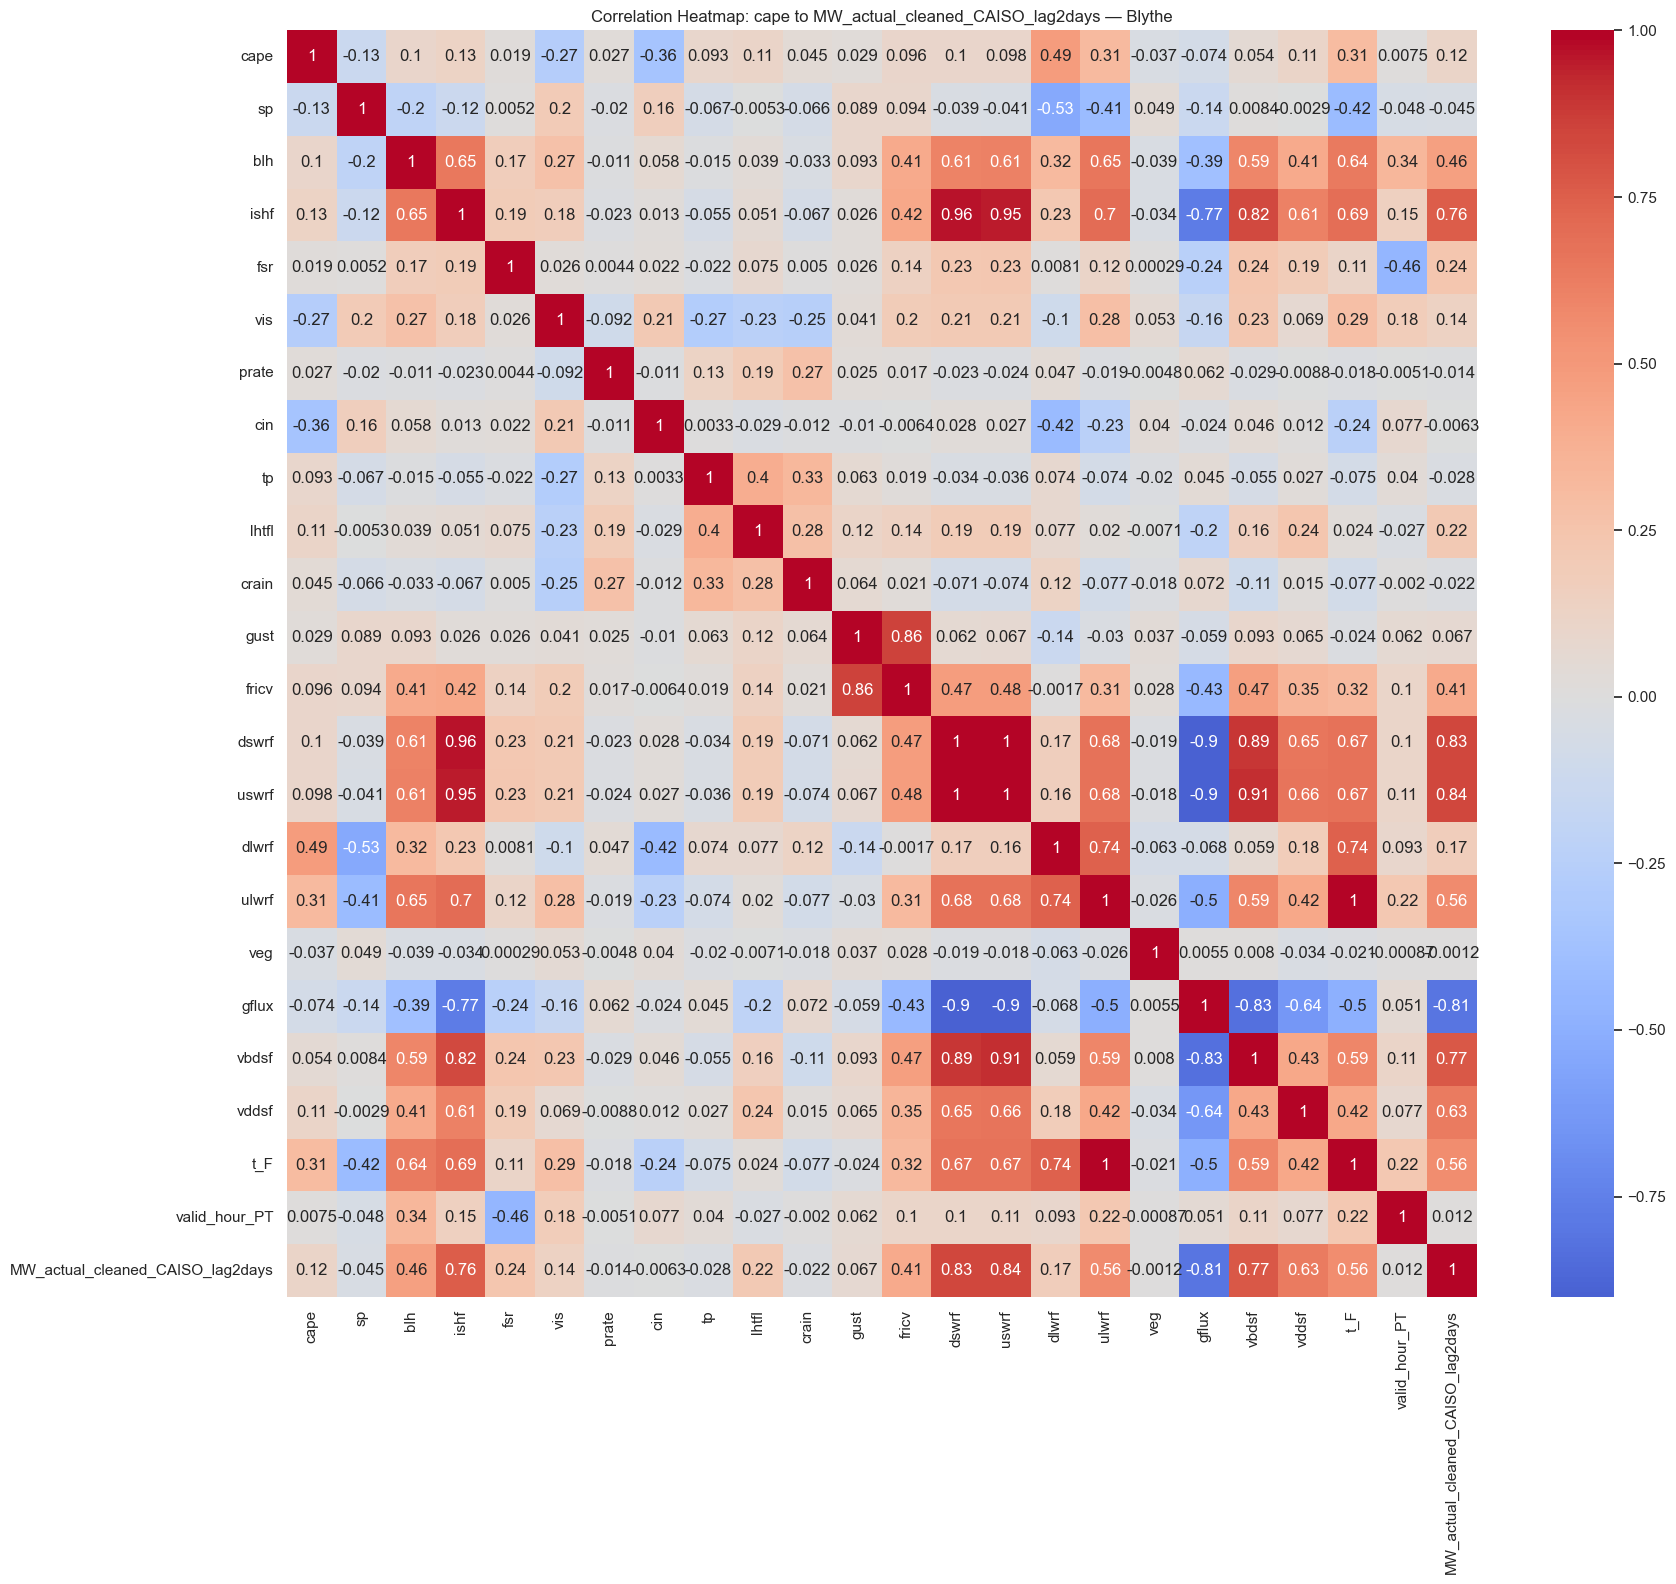

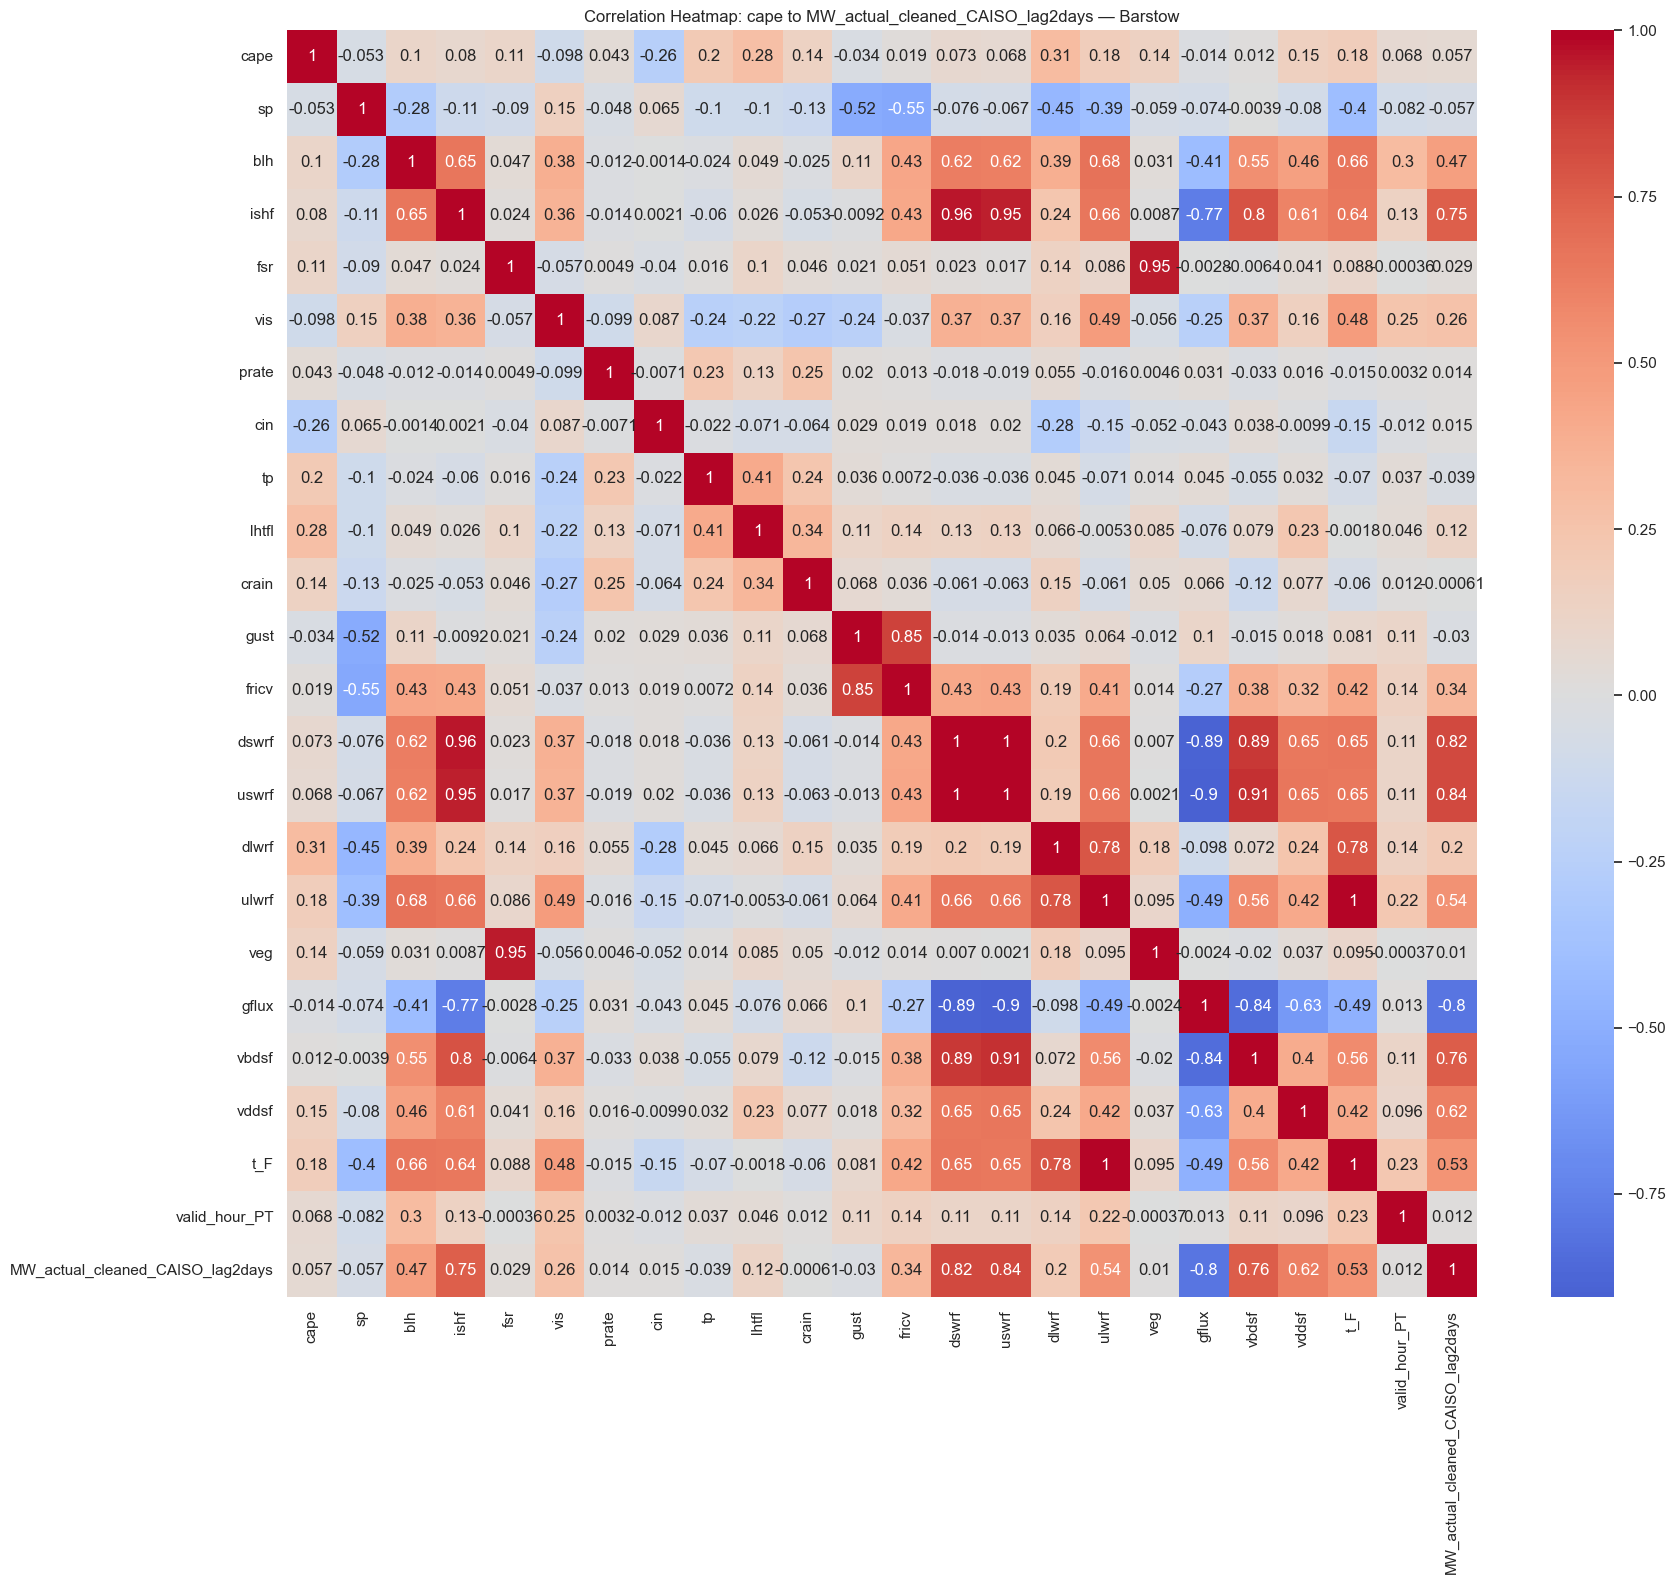

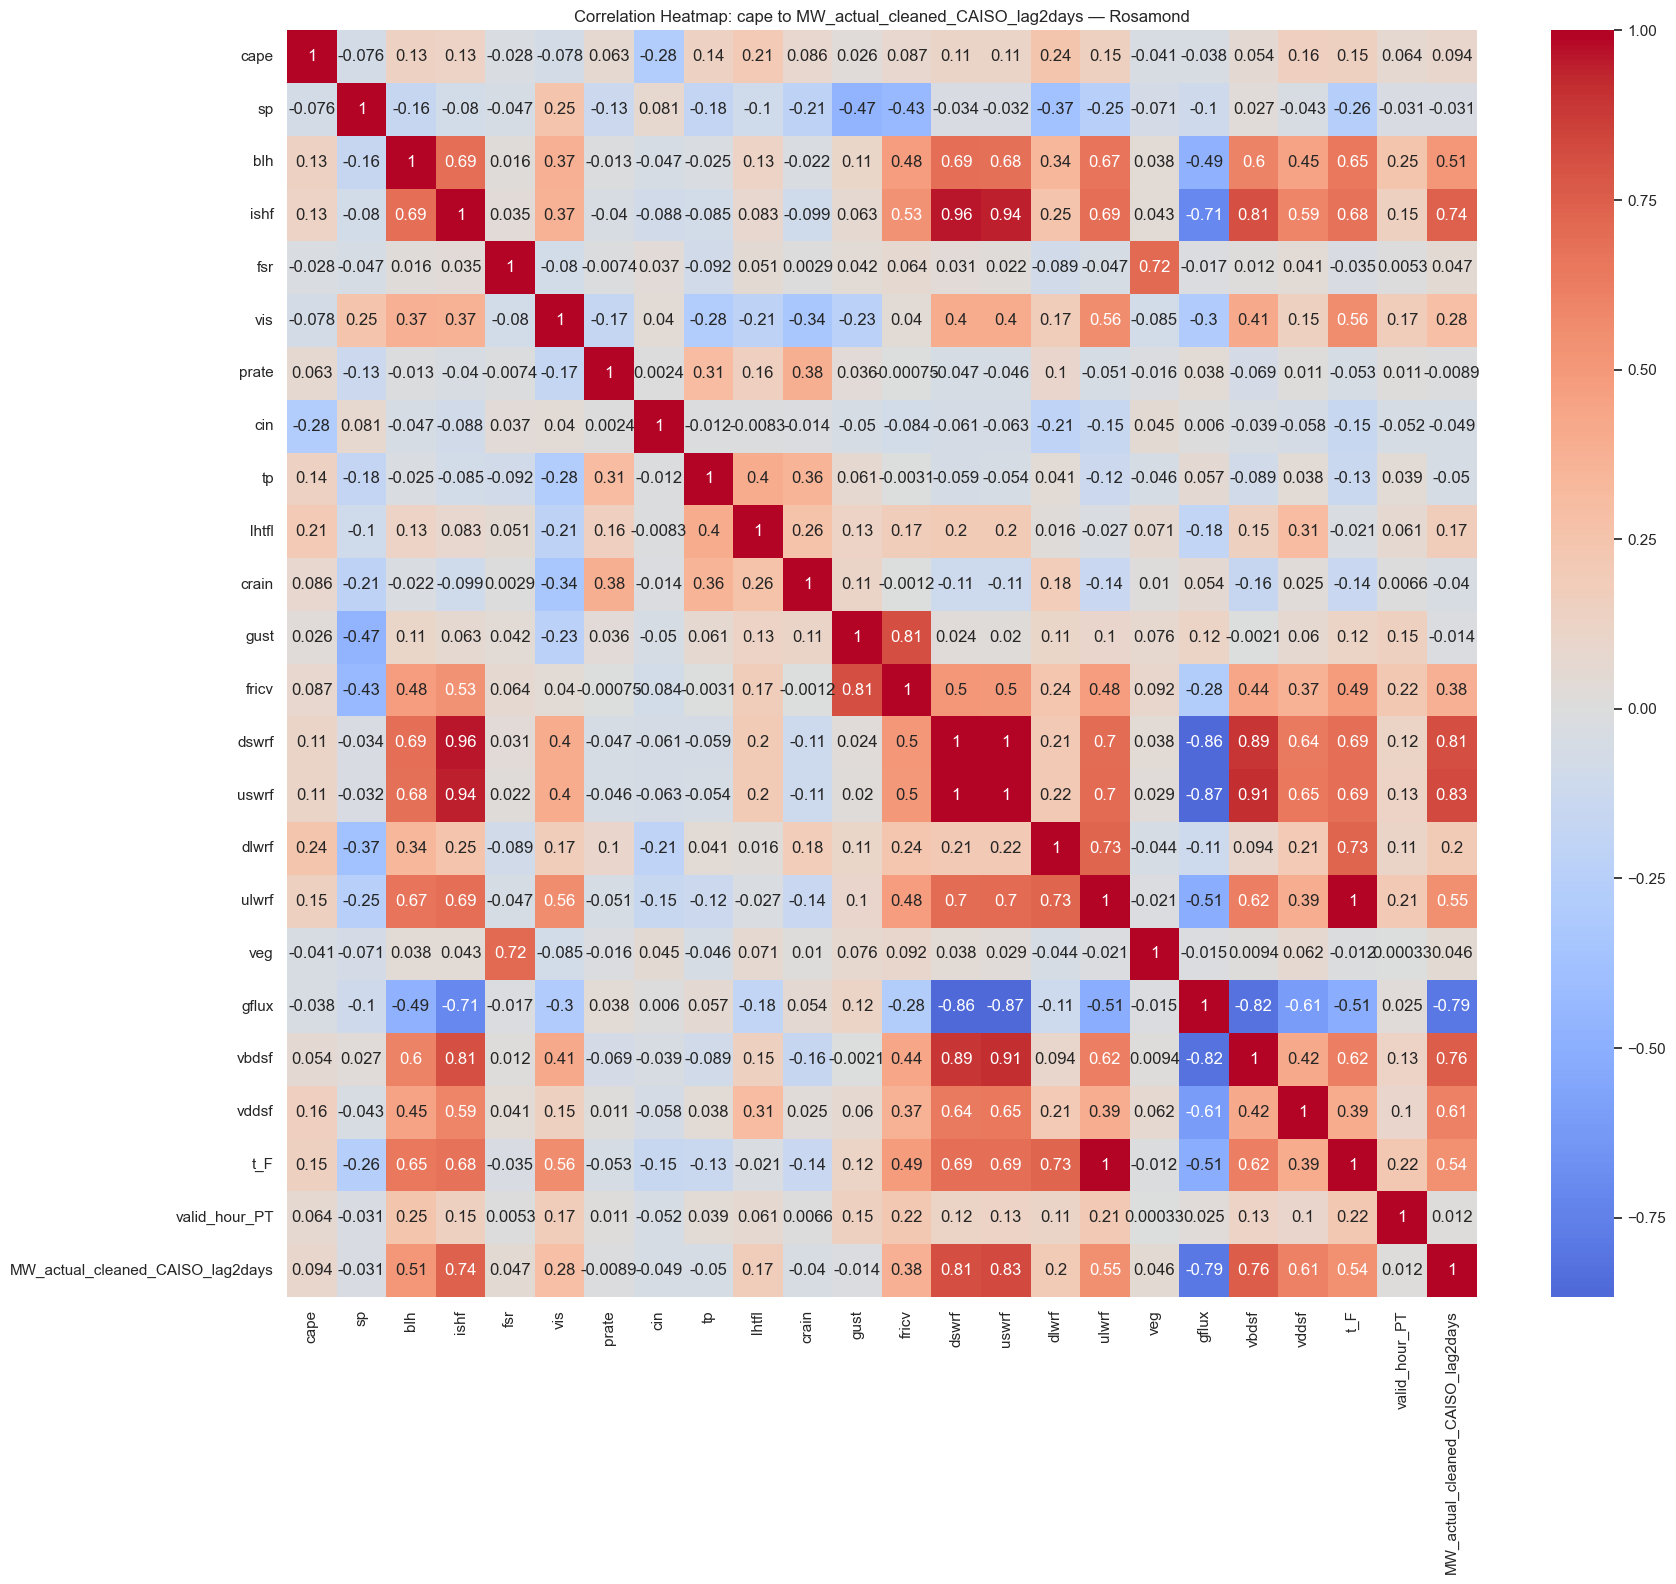

In [207]:
# Define the start and end of the column
start_col = "cape"
end_col = "MW_actual_cleaned_CAISO_lag2days"

# List of columns to exclude
columns_to_exclude = ["MW_actual_cleaned_CAISO", "MW_pred_cleaned_CAISO", "MW_error"]

# Loop through each unique location in the 'point_name' column
for loc in features['point_name'].unique():
    # Filter the dataset for the current location
    subset = features[features['point_name'] == loc]

    # Select the columns 
    cols_in_range = subset.loc[:, start_col:end_col]

    # Drop the excluded columns
    cols_in_range = cols_in_range.drop(columns=[col for col in columns_to_exclude if col in cols_in_range.columns])

    # Keep only numeric columns to ensure valid correlation computation
    numeric_subset = cols_in_range.select_dtypes(include='number')

    # Compute the correlation matrix
    corr = numeric_subset.corr()

    plt.figure(figsize=(18, 16))
    sns.heatmap(corr, cmap='coolwarm', center=0, annot=True)
    plt.title(f'Correlation Heatmap: {start_col} to {end_col} — {loc}')
    plt.tight_layout()
    plt.show()


Thoughts: 'ulwrf' and "t_F" have a perfect positive correlation. I'll remove ulwrf.

In [208]:
features = features.drop(columns = ['ulwrf'])

More thoughts: I also see four variables that are all highly correlated across all three locations (dswrf, uswrf, gflux, and vbdsf). I can perform PCA on these vars and only include PC1 if I want to do some further dimensionality reduction. The Random Forest and XGBoost models won't require this as they deal with correlated variables well, but it will be nice to have in the event that I test out some other models like NNs.

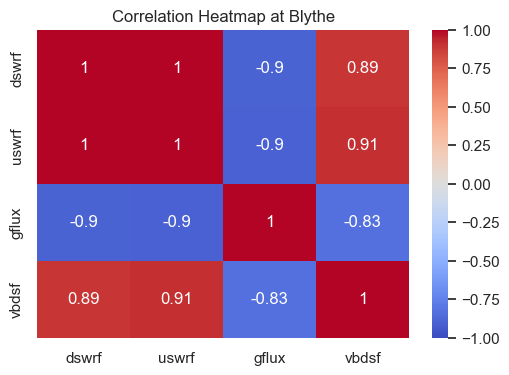

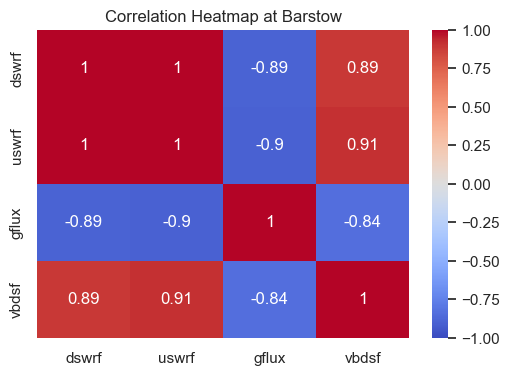

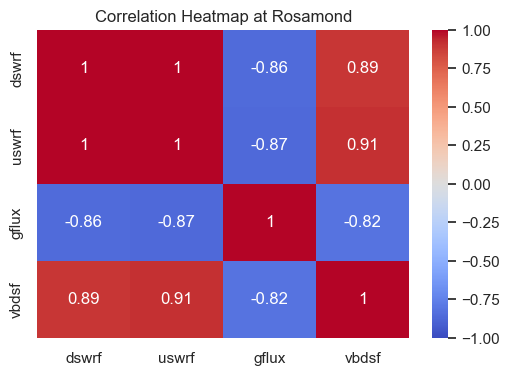

In [209]:
# Cols to look at
vars_to_check = ['dswrf', 'uswrf', 'gflux', 'vbdsf']

# Loop through each point_name
for point in features['point_name'].unique():
    subset = features[features['point_name'] == point][vars_to_check]
    
    plt.figure(figsize=(6, 4))
    sns.heatmap(subset.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(f'Correlation Heatmap at {point}')
    plt.show()


In [210]:
# Cols to look at
vars_to_check = ['dswrf', 'uswrf', 'gflux', 'vbdsf']

# Group by location and compute correlation matrix per group
for location, group in features.groupby('point_name'):
    # Drop rows with NaNs in the variables of interest
    subset = group[vars_to_check].dropna()

    # Make sure values are numeric
    subset = subset.apply(pd.to_numeric, errors='coerce')
    print(f"\nCorrelation matrix for location: {location}")
    print(subset.corr())



Correlation matrix for location: Barstow
          dswrf     uswrf     gflux     vbdsf
dswrf  1.000000  0.996872 -0.891680  0.887907
uswrf  0.996872  1.000000 -0.904901  0.910020
gflux -0.891680 -0.904901  1.000000 -0.839291
vbdsf  0.887907  0.910020 -0.839291  1.000000

Correlation matrix for location: Blythe
          dswrf     uswrf     gflux     vbdsf
dswrf  1.000000  0.997766 -0.895368  0.894839
uswrf  0.997766  1.000000 -0.900630  0.911748
gflux -0.895368 -0.900630  1.000000 -0.831413
vbdsf  0.894839  0.911748 -0.831413  1.000000

Correlation matrix for location: Rosamond
          dswrf     uswrf     gflux     vbdsf
dswrf  1.000000  0.996387 -0.856421  0.893782
uswrf  0.996387  1.000000 -0.866835  0.913097
gflux -0.856421 -0.866835  1.000000 -0.816815
vbdsf  0.893782  0.913097 -0.816815  1.000000


In [211]:
vars_to_check = ['dswrf', 'gflux', 'vbdsf']

# Standardize the four variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features[vars_to_check])

# Run PCA
pca = PCA(n_components=1)  # Get just the first principal component
first_pc = pca.fit_transform(X_scaled)

# Add PC1
features['solar_radiation_PC1'] = first_pc


Thoughts: Now I will look at rows that have missing values and decide how to handle them. There shouldn't be many at all.

In [212]:
# Select all possibly relevant columns
cols_to_check = features.loc[:, "cape":"MW_actual_cleaned_CAISO_lag2days"]

# Count how many of these columns have missing values
missing_cols = cols_to_check.columns[cols_to_check.isnull().any()]
num_missing_cols = len(missing_cols)

# Count how many rows have at least one missing value in this range
rows_with_missing = cols_to_check.isnull().any(axis=1)
num_rows_with_missing = rows_with_missing.sum()
total_rows = len(features)
percent_rows_with_missing = (num_rows_with_missing / total_rows) * 100

print(f"Number of columns with missing values: {num_missing_cols}")
print(f"Columns with missing values: {list(missing_cols)}\n")
print(f"Rows with ≥1 missing value in these columns: {num_rows_with_missing:,} / {total_rows:,} "
      f"({percent_rows_with_missing:.2f}%)")


Number of columns with missing values: 2
Columns with missing values: ['blh', 'MW_actual_cleaned_CAISO_lag2days']

Rows with ≥1 missing value in these columns: 147 / 60,396 (0.24%)


Thoughts: I really like the two day lag variable and don't see a reasonable way of imputing missing values given the pattern of missing values, so I'll just drop rows with missing values. If missing values were sporadic I would feel comfortable imputing, but I know that there are consecutive periods of time missing here at the beginning of the dataset with no idea what conditions were like for previous days. This should trim the dataset by a bit in the beginning and a few hours in the middle.

In [213]:
# Drop rows with missing values specifically in the 'MW_actual_cleaned_CAISO_lag2days' column
rf_data = features.dropna(subset=["MW_actual_cleaned_CAISO_lag2days"])

# Confirm the new shape
print(f"New shape after dropping: {rf_data.shape}")

New shape after dropping: (60252, 71)


In [214]:
cols_to_check = rf_data.loc[:, "cape":"MW_actual_cleaned_CAISO_lag2days"]

# Count how many of these columns have missing vals
missing_cols = cols_to_check.columns[cols_to_check.isnull().any()]
num_missing_cols = len(missing_cols)

# Count how many rows have at least one missing value
rows_with_missing = cols_to_check.isnull().any(axis=1)
num_rows_with_missing = rows_with_missing.sum()
total_rows = len(rf_data)
percent_rows_with_missing = (num_rows_with_missing / total_rows) * 100

print(f"Number of columns with missing values: {num_missing_cols}")
print(f"Columns with missing values: {list(missing_cols)}\n")
print(f"Rows with ≥1 missing value in these columns: {num_rows_with_missing:,} / {total_rows:,} "
      f"({percent_rows_with_missing:.2f}%)")


Number of columns with missing values: 1
Columns with missing values: ['blh']

Rows with ≥1 missing value in these columns: 3 / 60,252 (0.00%)


Thoughts: Given how few rows there are with this value missing I'll just drop these rows.

In [215]:
# Drop rows with missing values for blh
rf_data = rf_data.dropna(subset=["blh"])

# Confirm the new shape
print(f"New shape after dropping: {rf_data.shape}")

New shape after dropping: (60249, 71)


Thoughts: Let's take a look at a few of the hourly profiles of these variables before model building.

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Version

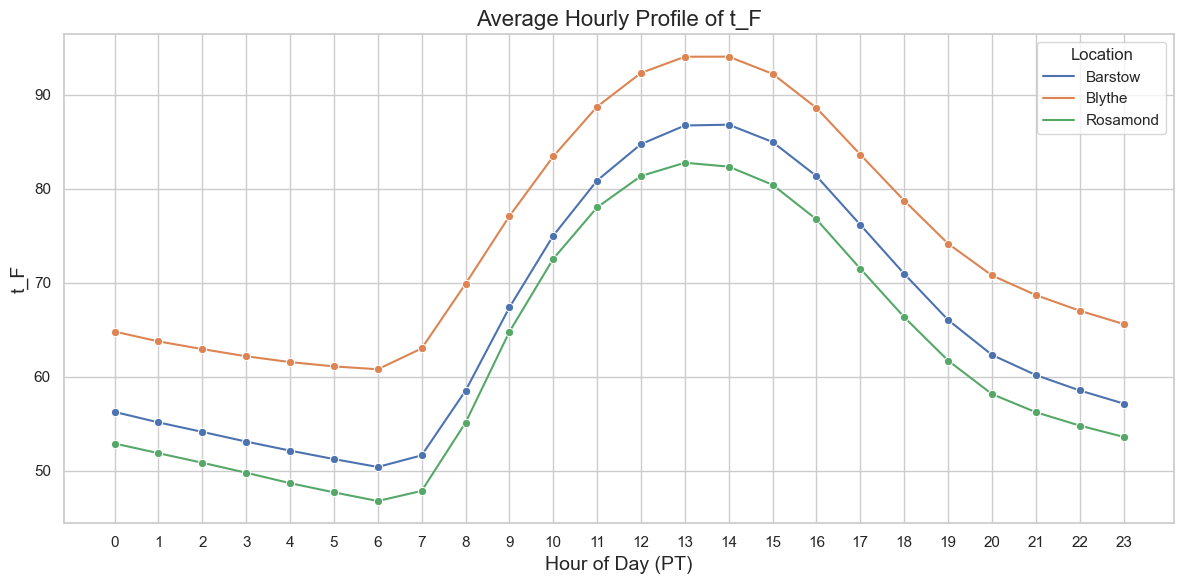

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Version

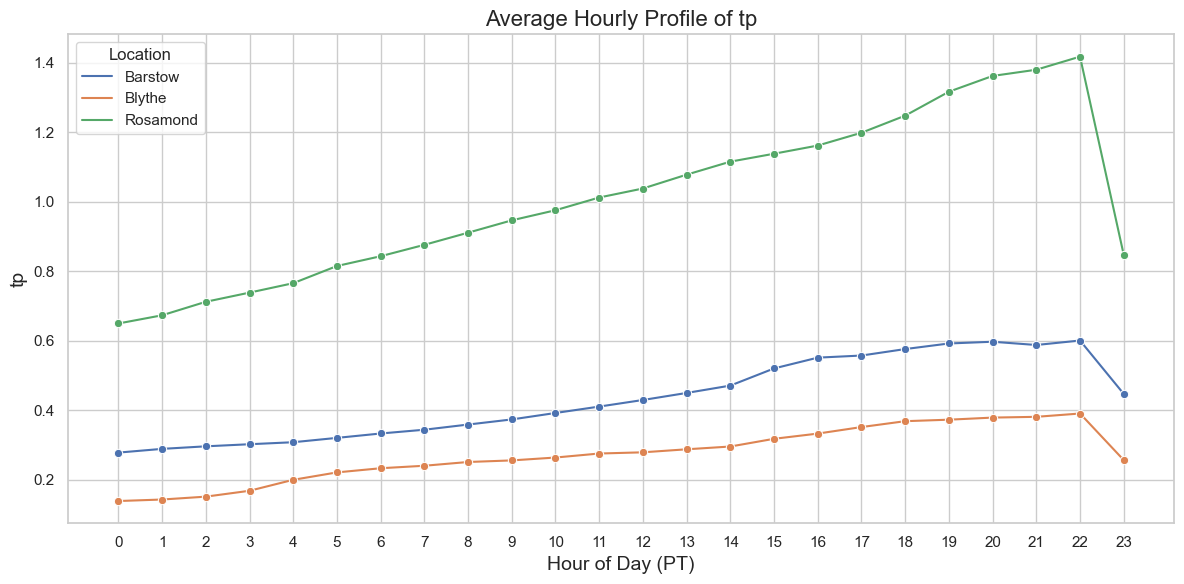

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Version

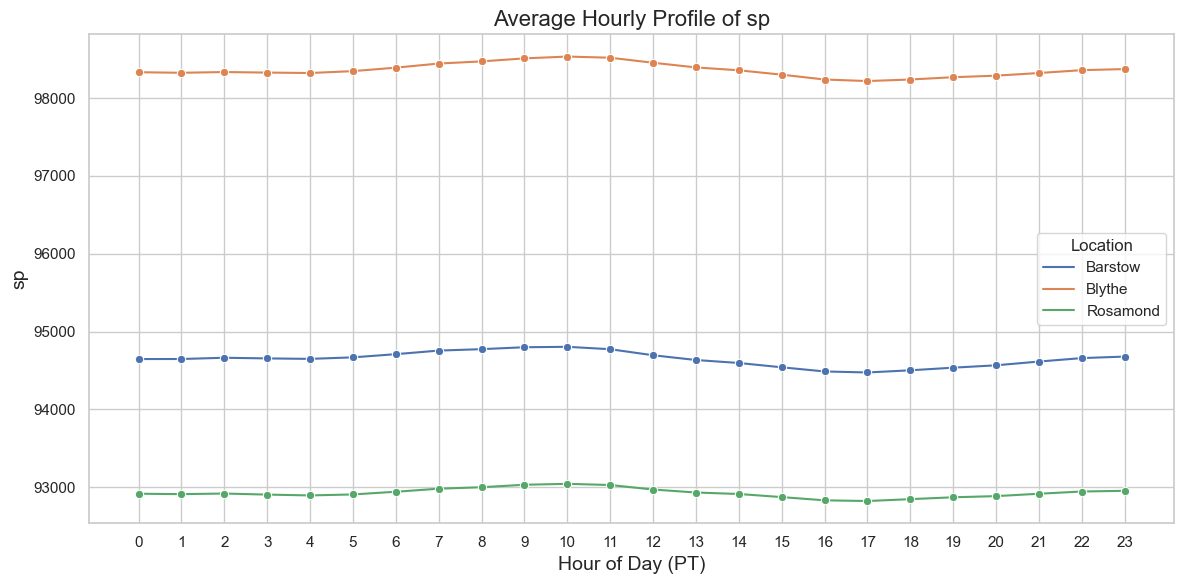

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Version

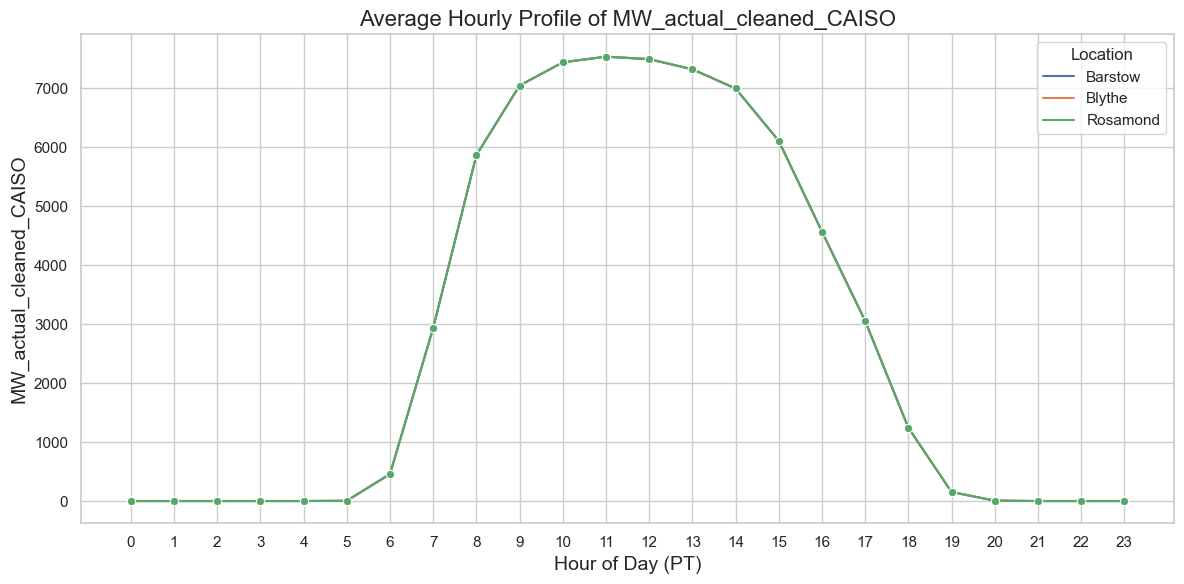

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Version

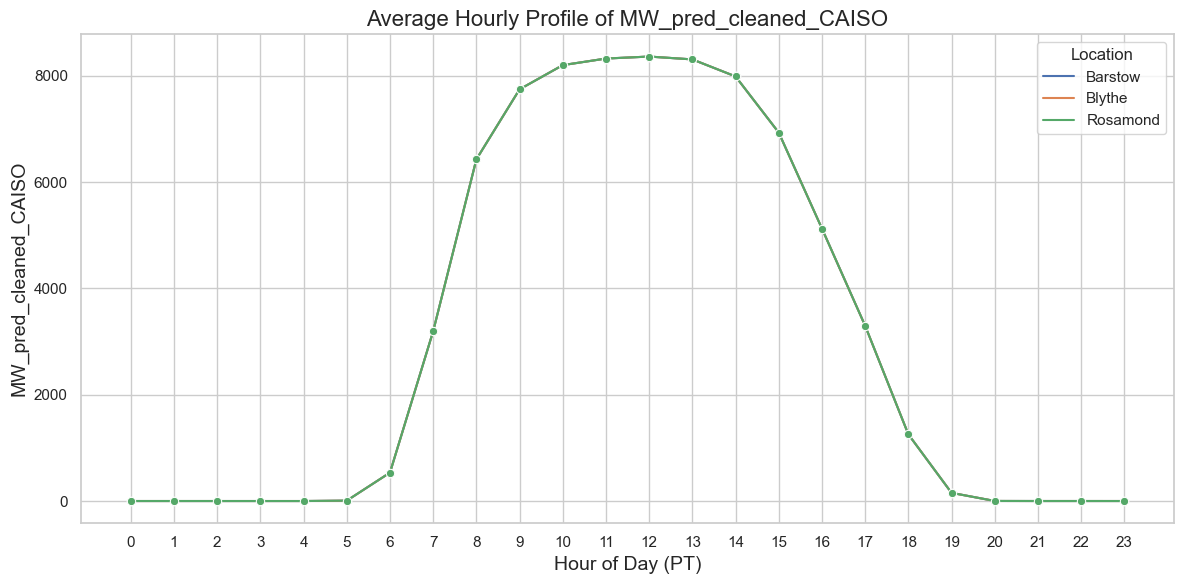

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Version

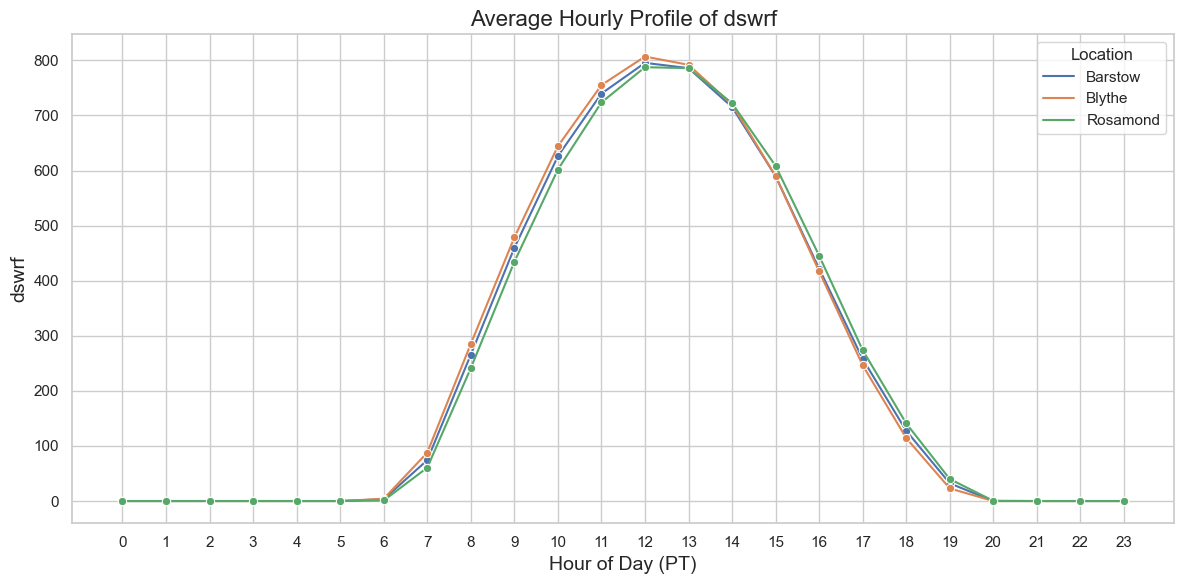

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Version

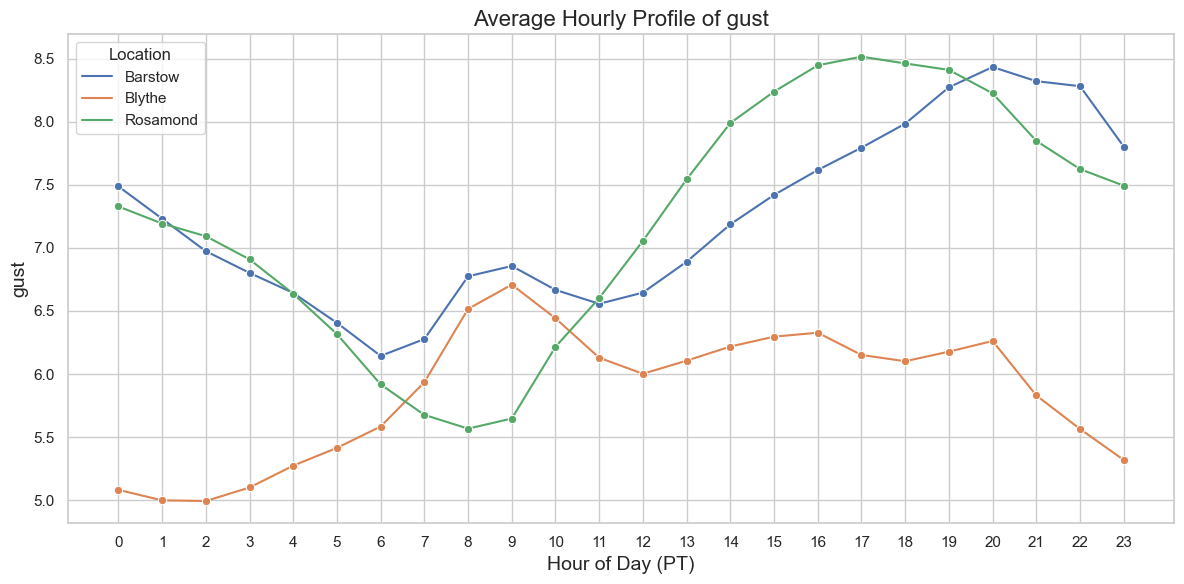

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Version

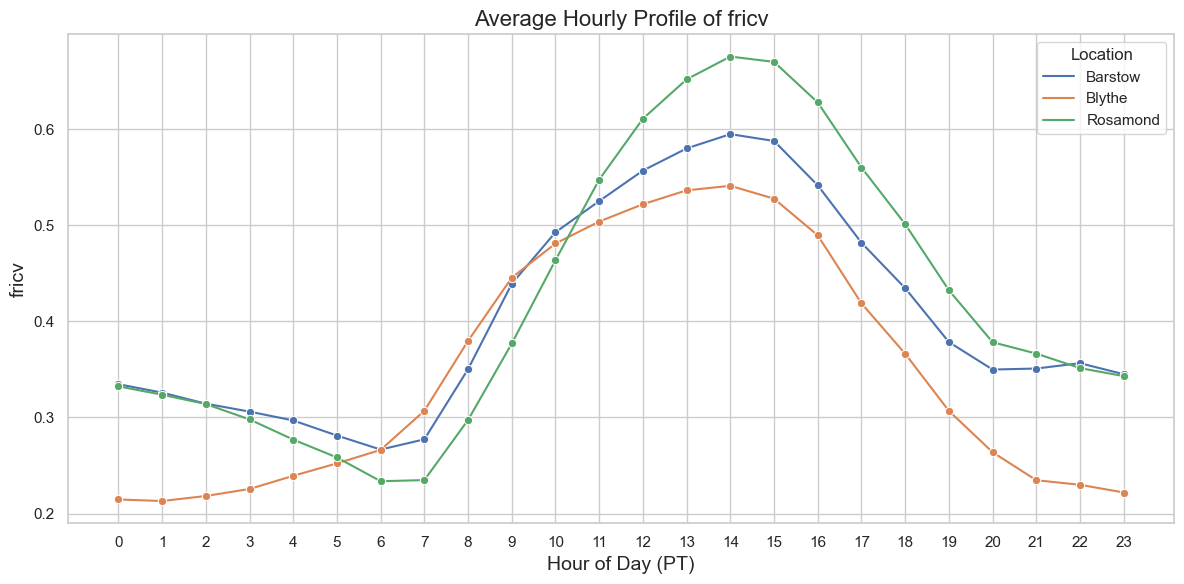

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Version

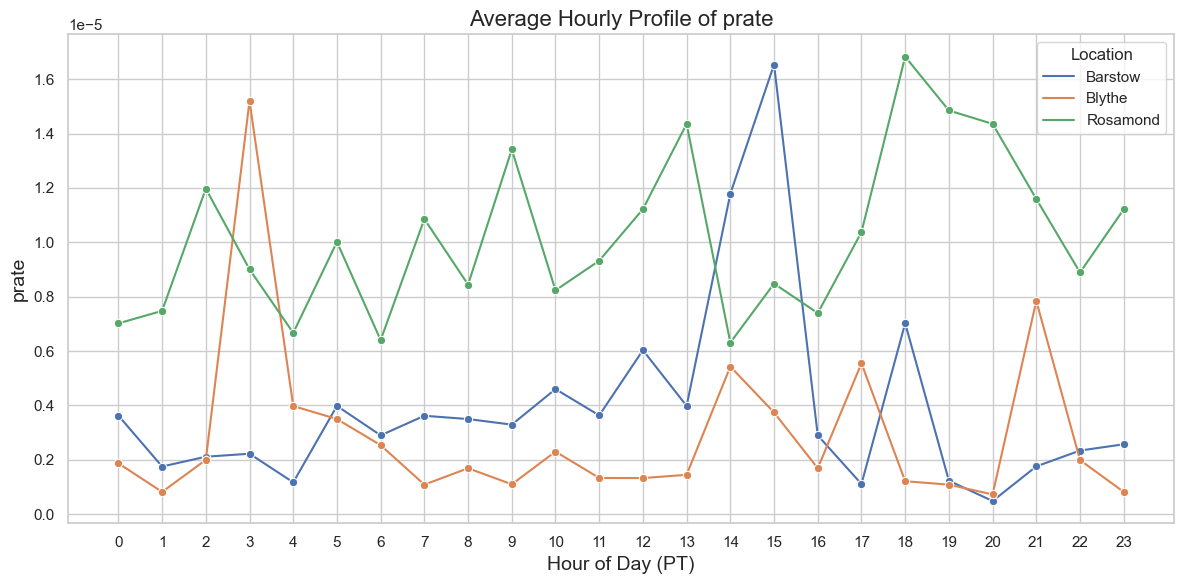

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Version

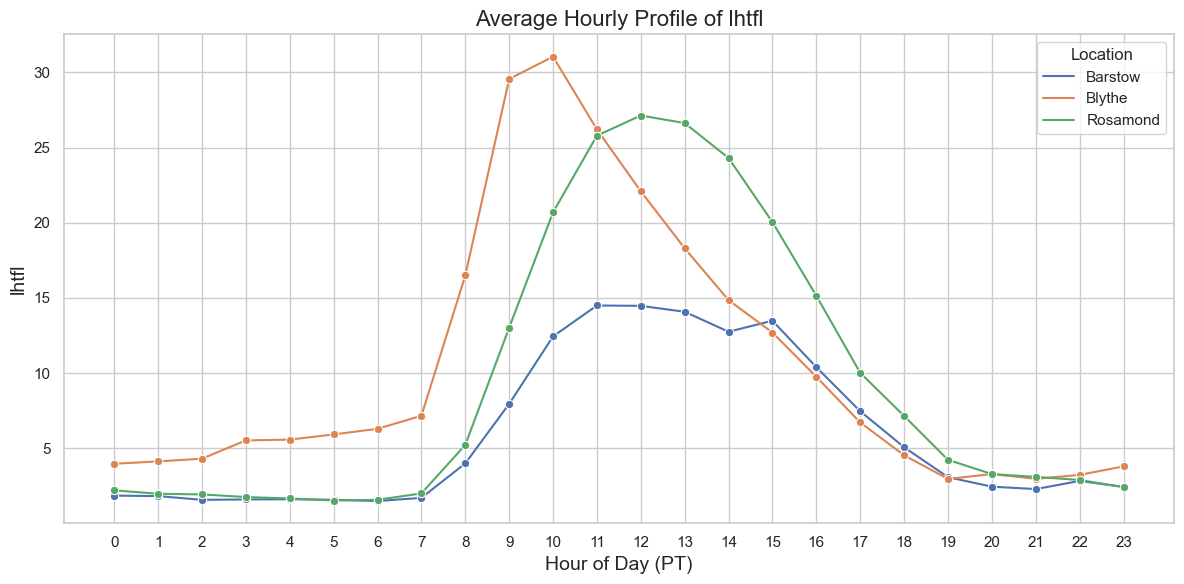

In [216]:
# Style
sns.set(style="whitegrid")

# List of vars to plot
variables = ['t_F', 'tp', 'sp', 'MW_actual_cleaned_CAISO', 'MW_pred_cleaned_CAISO', 'dswrf', 'gust', 'fricv', 'prate', 'lhtfl']

# Group by valid_hour_PT and point, then compute means for selected variables
hourly_avg = (
    rf_data.groupby(['valid_hour_PT', 'point_name'])[['t_F', 'tp', 'sp', 'MW_actual_cleaned_CAISO', 'MW_pred_cleaned_CAISO', 'dswrf', 'gust', 'fricv', 'prate', 'lhtfl']]
    .mean()
    .reset_index()
)

# Loop through each variable and plot
for var in variables:
    plt.figure(figsize=(12, 6))
    
    sns.lineplot(data=hourly_avg, x='valid_hour_PT', y=var, hue='point_name', marker='o')
    
    plt.title(f'Average Hourly Profile of {var}', fontsize=16)
    plt.xlabel('Hour of Day (PT)', fontsize=14)
    plt.ylabel(var, fontsize=14)
    plt.legend(title='Location')
    plt.xticks(range(0, 24))
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Thoughts: Most interesting thing from these visuals is that tp (total precipitation) drops sharply during the last hour of the day. I tried shifting this by an hour in either direction to see if data was aligned incorrectly, but that didn't appear to be the case. I will consider dropping if this appears to be an issue during model building, but I'd like to keep it as a sort of proxy for weather events & cloud coverage.

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_ke

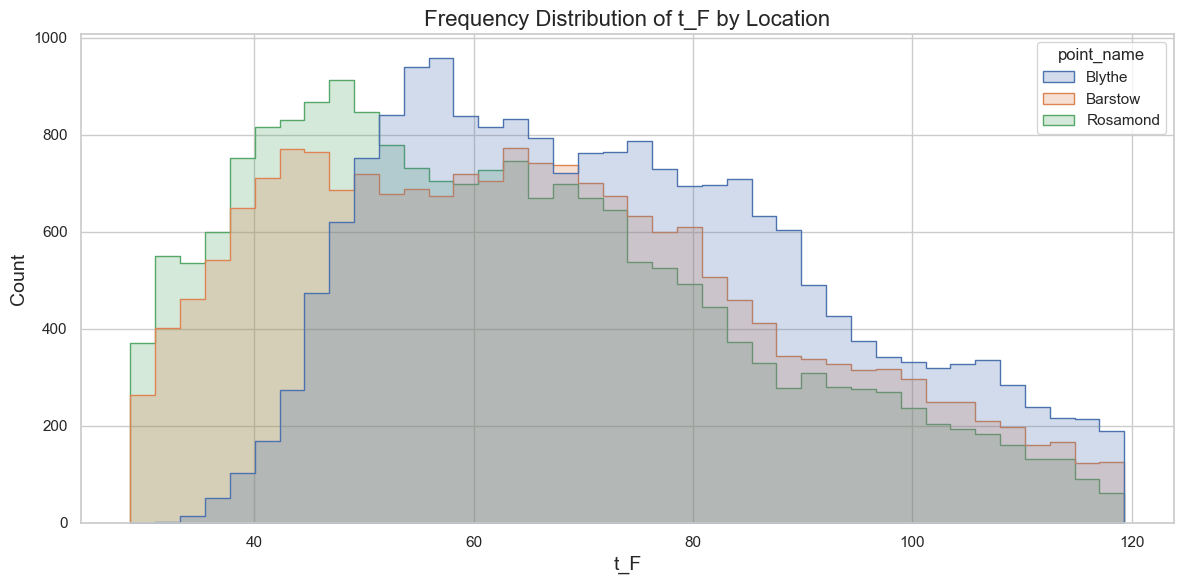

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_ke

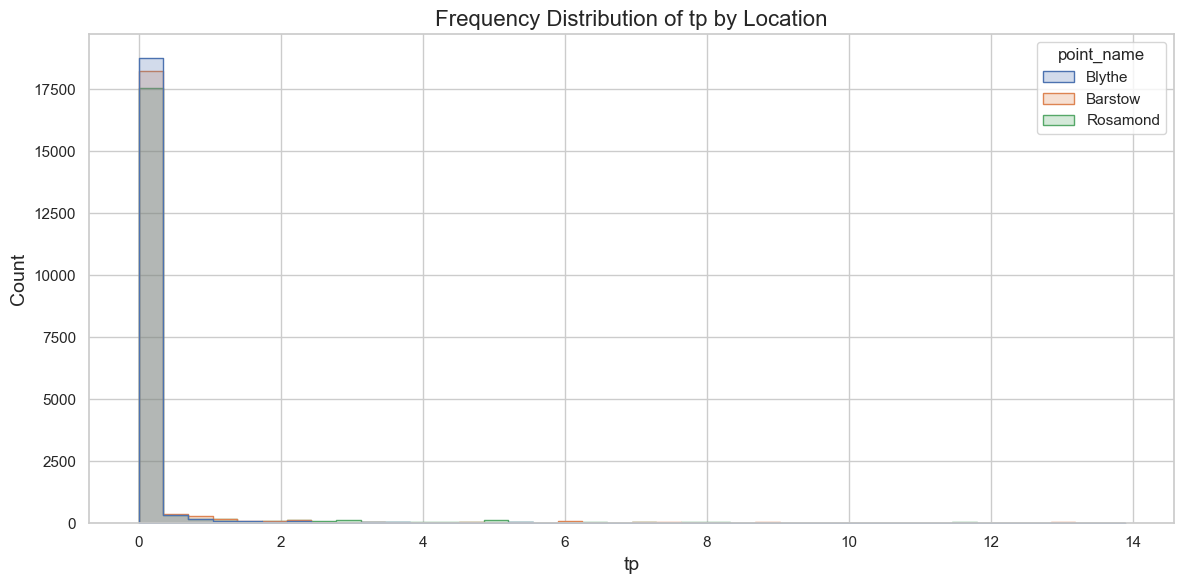

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_ke

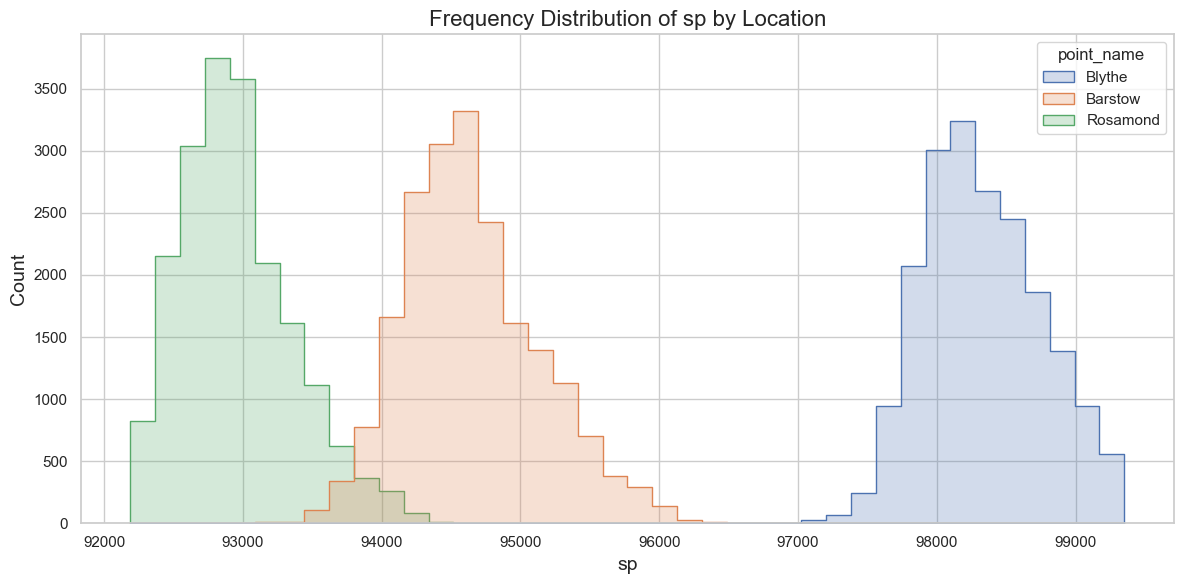

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_ke

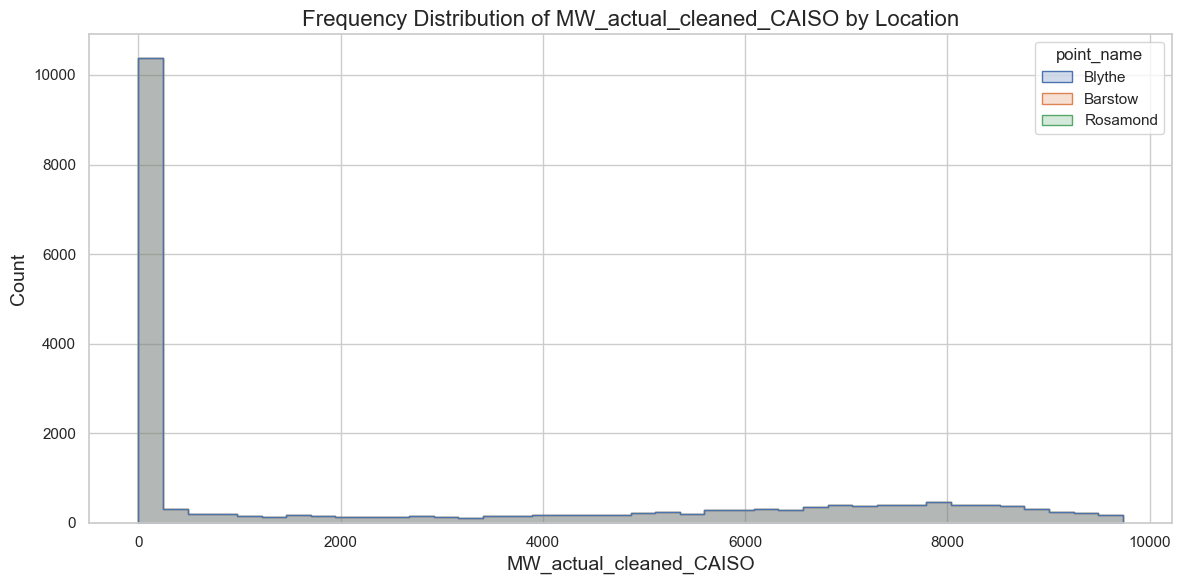

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_ke

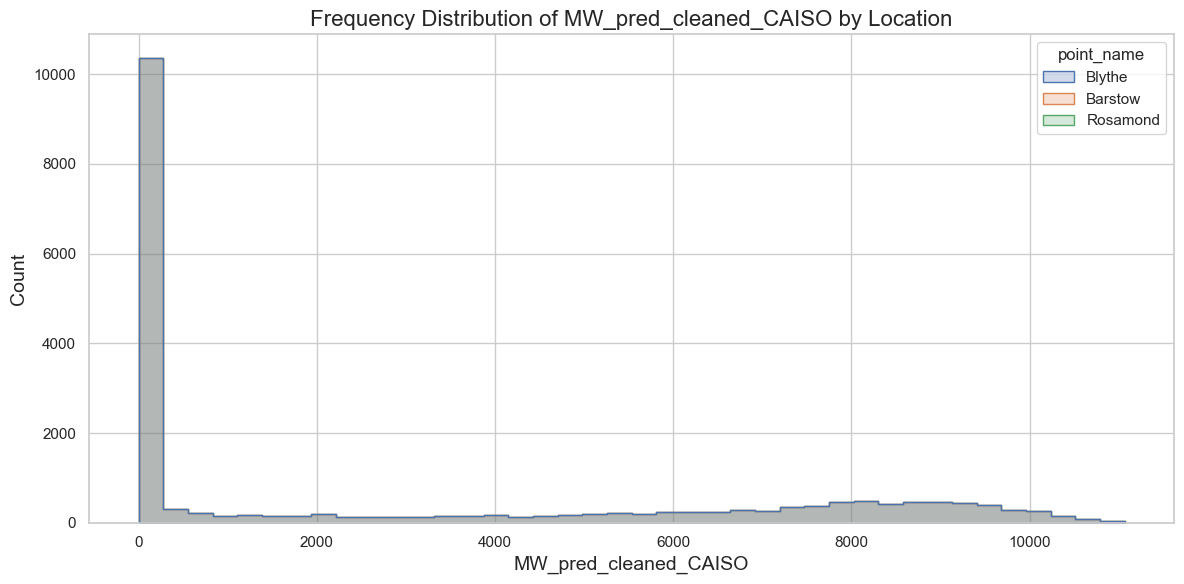

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_ke

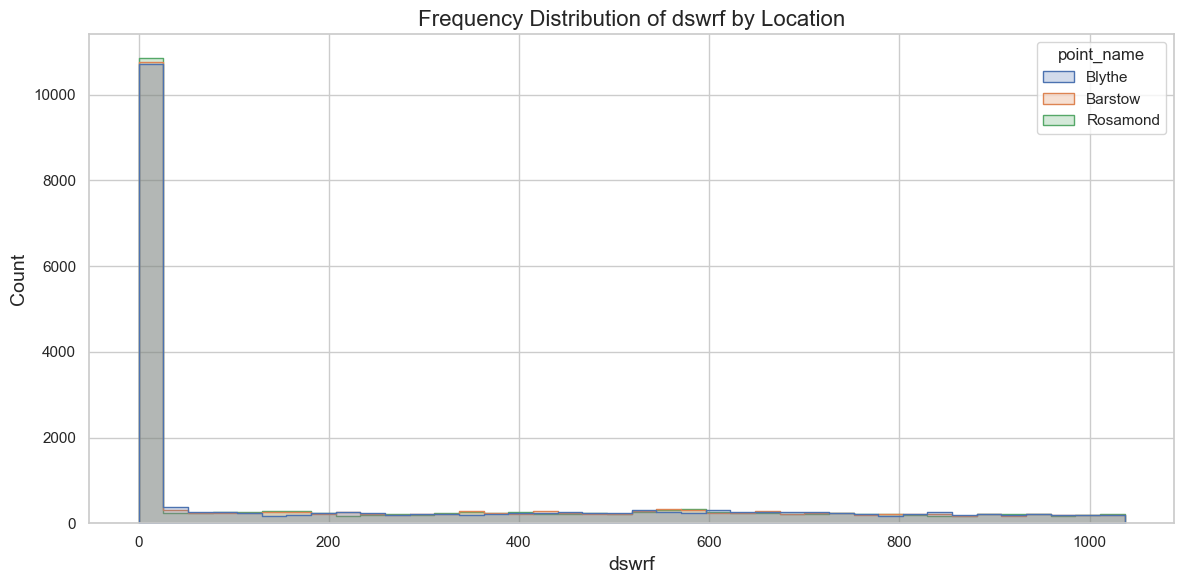

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_ke

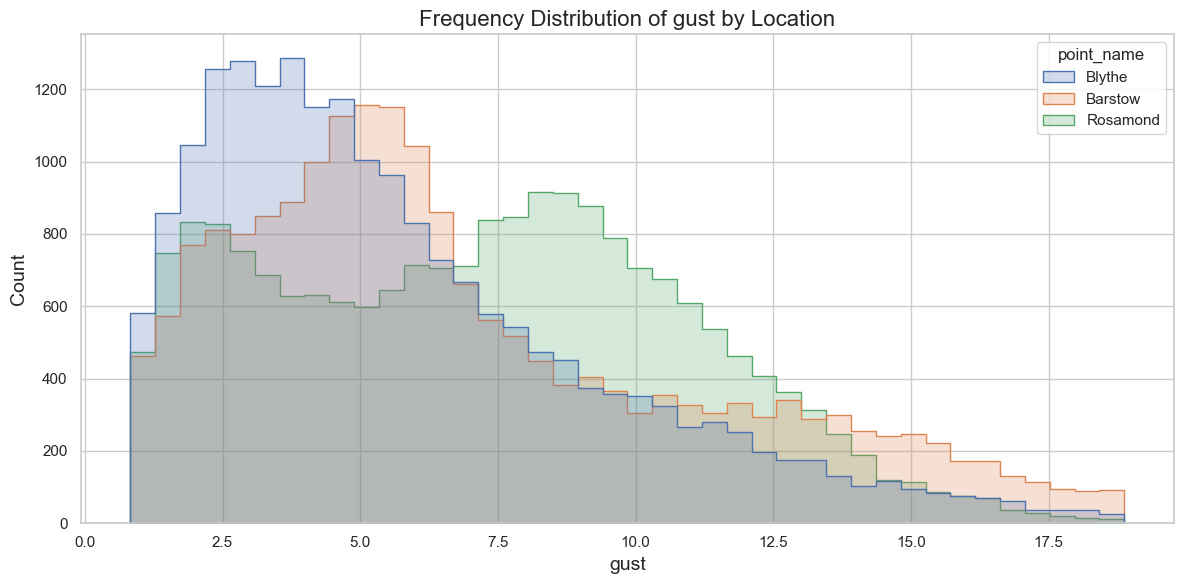

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_ke

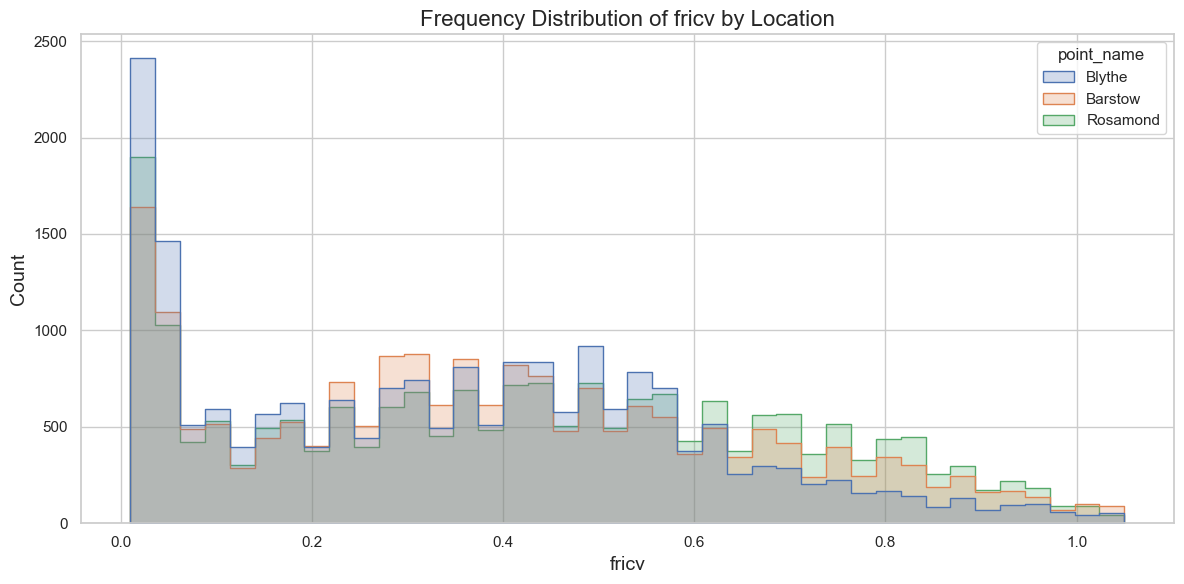

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_ke

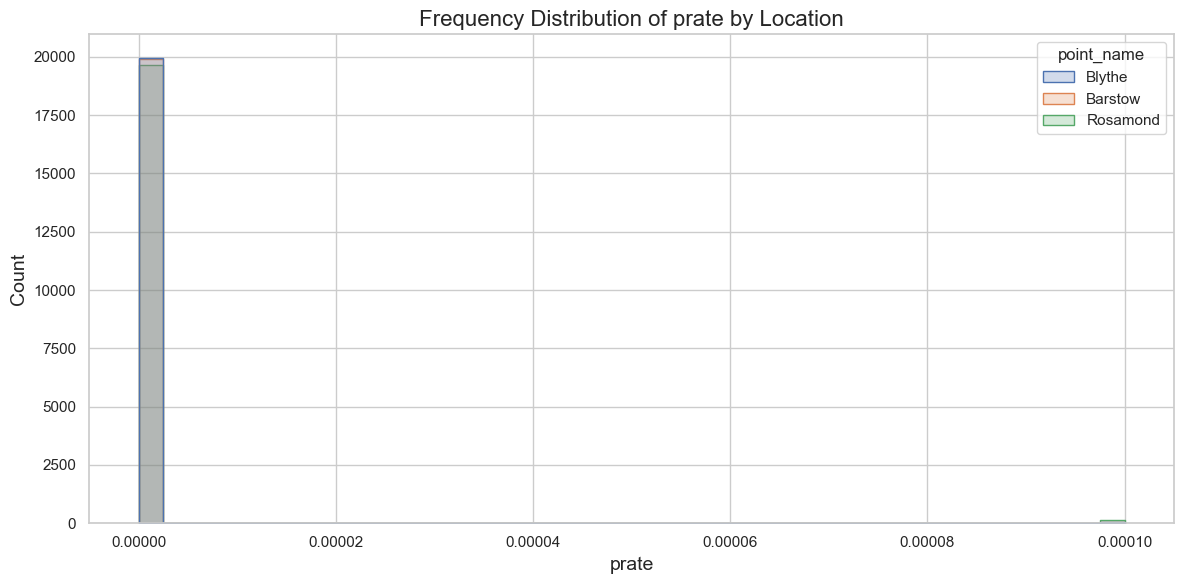

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_ke

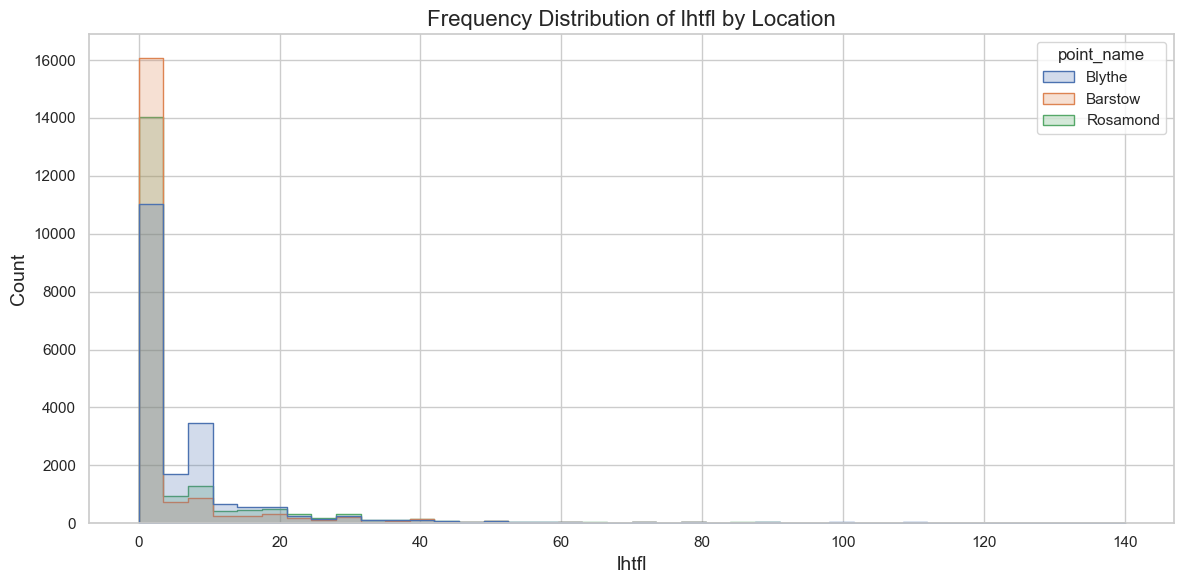

In [217]:
# Frequency Distributions

sns.set(style="whitegrid")

variables = ['t_F', 'tp', 'sp', 'MW_actual_cleaned_CAISO', 'MW_pred_cleaned_CAISO',
             'dswrf', 'gust', 'fricv', 'prate', 'lhtfl']

for var in variables:
    plt.figure(figsize=(12, 6))

    # Drop NaNs and get range between 1st and 99th percentiles to trim outliers
    data = rf_data[[var, 'point_name']].dropna().copy()
    data['point_name'] = data['point_name'].astype(str)  # Ensure consistent string type

    lower, upper = np.percentile(data[var], [1, 99])
    
    # Filter to trimmed data for better plotting
    trimmed_data = data[(data[var] >= lower) & (data[var] <= upper)]

    ax = sns.histplot(
        data=trimmed_data,
        x=var,
        hue='point_name',
        element='step',
        stat='count',
        common_norm=False,
        bins=40
    )

    plt.title(f'Frequency Distribution of {var} by Location', fontsize=16)
    plt.xlabel(var, fontsize=14)
    plt.ylabel('Count', fontsize=14)

    # Legend
    handles, labels = ax.get_legend_handles_labels()
    if handles and labels:
        plt.legend(handles=handles[1:], labels=labels[1:]) 

    plt.tight_layout()
    plt.show()


Thoughts: These distributions make sense and don't give cause for concern. MW values look the way that they do because of the overwhelming amount of overnight values that are concentrated in such a small range (0). This is similar with other radiation related variables. Prate is skewed by the lack of rainfall in SoCal and the fact that it is not raining far more often than it is, but this isn't reason to leave the variable out.

In [218]:
rf_data.to_csv("/Volumes/USB DISK/NewSP15/AllMergedNew/model_buildingv2.csv", index=False)

Start with code below for tomorrow! (Editing comment)

In [221]:
rf_data = pd.read_csv("/Volumes/USB DISK/NewSP15/AllMergedNew/model_buildingv2.csv")

### Model Building

In [220]:
# Double check columns
rf_data.columns

Index(['cape', 'sp', 'blh', 'ishf', 'fsr', 'vis', 'prate', 'cin', 'tp',
       'lhtfl', 'crain', 'gust', 'fricv', 'dswrf', 'uswrf', 'dlwrf', 'veg',
       'gflux', 'vbdsf', 'vddsf', 'valid_time_PT', 't_F', 'point_name',
       'valid_hour_PT', 'MW_actual_cleaned_CAISO', 'MW_pred_cleaned_CAISO',
       'MW_error', 'MW_actual_cleaned_CAISO_lag2days', 'siconc_avg',
       'cape_avg', 't_avg', 'sp_avg', 'blh_avg', 'lsm_avg', 'ishf_avg',
       'fsr_avg', 'vis_avg', 'prate_avg', 'sde_avg', 'cin_avg', 'orog_avg',
       'tp_avg', 'lhtfl_avg', 'hail_avg', 'crain_avg', 'cfrzr_avg',
       'cicep_avg', 'csnow_avg', 'cpofp_avg', 'snowc_avg', 'sdwe_avg',
       'gust_avg', 'fricv_avg', 'dswrf_avg', 'uswrf_avg', 'dlwrf_avg',
       'ulwrf_avg', 'bgrun_avg', 'ssrun_avg', 'veg_avg', 'gflux_avg',
       'cnwat_avg', 'frzr_avg', 'cfnsf_avg', 'vbdsf_avg', 'vddsf_avg',
       'lai_avg', 'is_dst', 'valid_month_PT', 'valid_year_PT',
       'solar_radiation_PC1'],
      dtype='object')

/var/folders/70/9yy_lf2j0fz2b3bn_9btzxj80000gn/T/ipykernel_16638/2447825662.py:2: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  rf_data['valid_time_PT'] = pd.to_datetime(rf_data['valid_time_PT'])
/var/folders/70/9yy_lf2j0fz2b3bn_9btzxj80000gn/T/ipykernel_16638/2447825662.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[col] = le.fit_transform(X_train[col])
/var/folders/70/9yy_lf2j0fz2b3bn_9btzxj80000gn/T/ipykernel_16638/2447825662.py:44: SettingWithCopyWarning: 
A


Cross-validation results:
   n_estimators     val_MAE    val_RMSE  train_R2    val_R2
0            50  454.182152  806.362565  0.996135  0.945424
1           100  451.167236  799.785024  0.996280  0.946365
2           200  449.764528  796.553811  0.996384  0.946780
3           300  449.106839  795.727758  0.996409  0.946866


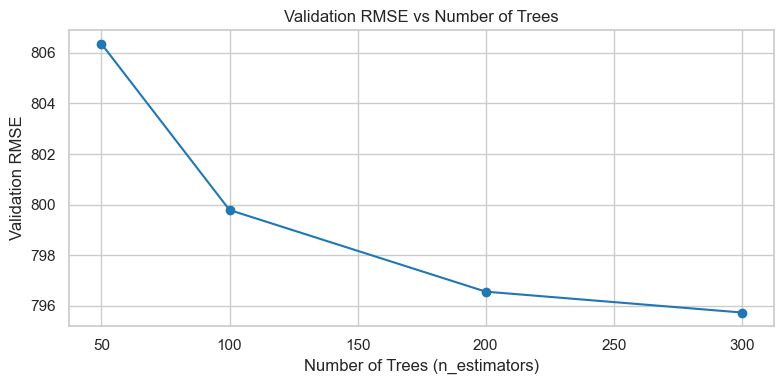

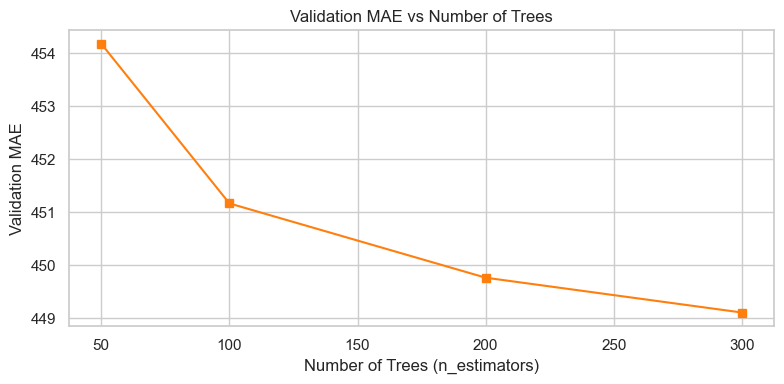


Random Forest - Test MAE: 519.02, RMSE: 963.86
Existing Predictions - Test MAE: 503.73, RMSE: 1029.46


In [222]:
# Ensure datetime column is in proper format
rf_data['valid_time_PT'] = pd.to_datetime(rf_data['valid_time_PT'])

# Sort chronologically and by location (keep this for consistent ordering)
rf_data = rf_data.sort_values(['valid_time_PT', 'point_name']).reset_index(drop=True)

# Get unique timestamps sorted
unique_times = rf_data['valid_time_PT'].drop_duplicates().sort_values()

# Define the split index for 80% of unique times
split_index = int(len(unique_times) * 0.8)

# Get the cutoff timestamp (the timestamp at the split index)
cutoff_time = unique_times.iloc[split_index]

# Split data by timestamp to keep all rows for each hour together
train_df = rf_data[rf_data['valid_time_PT'] < cutoff_time]
test_df = rf_data[rf_data['valid_time_PT'] >= cutoff_time]

# Identify feature columns
exclude_cols = ["valid_time_PT", "MW_actual_cleaned_CAISO", "MW_pred_cleaned_CAISO", "MW_error"]
cape_idx = rf_data.columns.get_loc("cape")
lag2_idx = rf_data.columns.get_loc("MW_actual_cleaned_CAISO_lag2days")
all_cols = rf_data.columns[cape_idx:lag2_idx + 1].tolist()
feature_cols = [col for col in all_cols if col not in exclude_cols]

# Target and benchmark columns
target_col = "MW_actual_cleaned_CAISO"
benchmark_col = "MW_pred_cleaned_CAISO"

# Extract features and target for train/test sets
X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]
y_pred_existing = test_df[benchmark_col]

# Identify categorical columns and apply label encoding (same as before)
categorical_cols = X_train.select_dtypes(include='object').columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])  
    label_encoders[col] = le


# TimeSeries cross-validation and model tuning. I'll use 5 splits
tscv = TimeSeriesSplit(n_splits=5)
n_estimators_list = [50, 100, 200, 300]

results = []

for n in n_estimators_list:
    fold_maes = []
    fold_rmses = []
    fold_train_scores = []
    fold_val_scores = []

    for train_idx, val_idx in tscv.split(X_train):
        X_t, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_t, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = RandomForestRegressor(n_estimators=n, random_state=42, n_jobs=-1)
        model.fit(X_t, y_t)

        y_val_pred = model.predict(X_val)
        y_train_pred = model.predict(X_t)

        fold_maes.append(mean_absolute_error(y_val, y_val_pred))
        fold_rmses.append(mean_squared_error(y_val, y_val_pred, squared=False))
        fold_train_scores.append(model.score(X_t, y_t))
        fold_val_scores.append(model.score(X_val, y_val))

    results.append({
        'n_estimators': n,
        'val_MAE': np.mean(fold_maes),
        'val_RMSE': np.mean(fold_rmses),
        'train_R2': np.mean(fold_train_scores),
        'val_R2': np.mean(fold_val_scores)
    })

results_df = pd.DataFrame(results)
print("\nCross-validation results:")
print(results_df)

# Plot RMSE vs number of trees
plt.figure(figsize=(8, 4))
plt.plot(results_df['n_estimators'], results_df['val_RMSE'], marker='o', color='tab:blue')
plt.title('Validation RMSE vs Number of Trees')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Validation RMSE')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot MAE vs number of trees
plt.figure(figsize=(8, 4))
plt.plot(results_df['n_estimators'], results_df['val_MAE'], marker='s', color='tab:orange')
plt.title('Validation MAE vs Number of Trees')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Validation MAE')
plt.grid(True)
plt.tight_layout()
plt.show()

# Final model on full training set with best tree count 
best_n = results_df.sort_values("val_RMSE").iloc[0]["n_estimators"]
final_model = RandomForestRegressor(n_estimators=int(best_n), random_state=42, n_jobs=-1)
final_model.fit(X_train, y_train)

y_pred_rf = final_model.predict(X_test)

# Evaluate on test set 
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf, squared=False)
mae_existing = mean_absolute_error(y_test, y_pred_existing)
rmse_existing = mean_squared_error(y_test, y_pred_existing, squared=False)

print(f"\nRandom Forest - Test MAE: {mae_rf:.2f}, RMSE: {rmse_rf:.2f}")
print(f"Existing Predictions - Test MAE: {mae_existing:.2f}, RMSE: {rmse_existing:.2f}")


Initial thoughts: Nice! I think this is a great start. Already beating existing predictions in RMSE and not far off for MAE. Let's start making some improvements to the model.

Up Next: The first thing I'd like to do is substitute in some of the weather variables that have been averaged over the course of an hour and see how performance changes.


Cross-validation results:
   n_estimators     val_MAE    val_RMSE  train_R2    val_R2
0            50  434.503554  775.687656  0.996285  0.949594
1           100  433.039124  771.984353  0.996458  0.950066
2           200  430.903064  768.774764  0.996558  0.950456
3           300  431.016238  768.901874  0.996584  0.950453


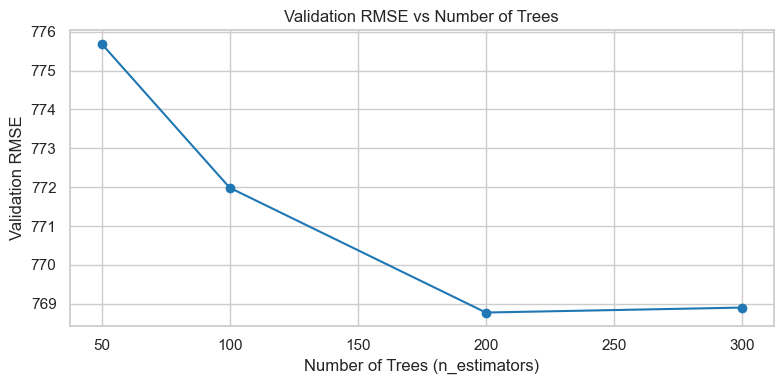

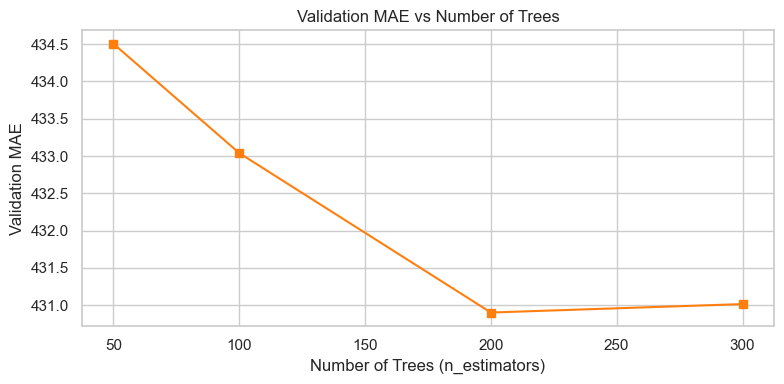


Random Forest - Test MAE: 506.64, RMSE: 945.20
Existing Predictions - Test MAE: 503.73, RMSE: 1029.46


In [224]:
# Convert 't_avg' from Kelvin to Fahrenheit (°F = (K - 273.15) * 9/5 + 32)
rf_data['t_avg_F'] = (rf_data['t_avg'] - 273.15) * 9/5 + 32

# Substitution mapping: Use these averaged features instead of their originals
feature_subs = {
    't_F': 't_avg_F',
    'sp': 'sp_avg',
    'dswrf': 'dswrf_avg',
    'uswrf': 'uswrf_avg',
    'dlwrf': 'dlwrf_avg',
    'ulwrf': 'ulwrf_avg',
    'gflux': 'gflux_avg',
    'lhtfl': 'lhtfl_avg',
    'fricv': 'fricv_avg',
    'gust': 'gust_avg'
}

# Define boundaries for relevant features
exclude_cols = ["valid_time_PT", "MW_actual_cleaned_CAISO", "MW_pred_cleaned_CAISO", "MW_error"]
cape_idx = rf_data.columns.get_loc("cape")
lag2_idx = rf_data.columns.get_loc("MW_actual_cleaned_CAISO_lag2days")
all_cols = rf_data.columns[cape_idx:lag2_idx + 1].tolist()

# Apply substitutions to feature list
feature_cols = []
for col in all_cols:
    if col in exclude_cols:
        continue
    elif col in feature_subs:
        feature_cols.append(feature_subs[col])
    else:
        feature_cols.append(col)

# Target variables
target_col = "MW_actual_cleaned_CAISO"
benchmark_col = "MW_pred_cleaned_CAISO"

# Sort chronologically and by location
rf_data = rf_data.sort_values(['valid_time_PT', 'point_name']).reset_index(drop=True)

# Get unique sorted timestamps
unique_times = rf_data['valid_time_PT'].drop_duplicates().sort_values()

# Find the split timestamp (80% mark)
split_time = unique_times.iloc[int(len(unique_times) * 0.8)]

# Split so that all rows for a timestamp are in the same set
train_df = rf_data[rf_data['valid_time_PT'] < split_time]
test_df = rf_data[rf_data['valid_time_PT'] >= split_time]

X_train = train_df[feature_cols].copy()
y_train = train_df[target_col]
X_test = test_df[feature_cols].copy()
y_test = test_df[target_col]
y_pred_existing = test_df[benchmark_col]

# Label encode any categorical columns
categorical_cols = X_train.select_dtypes(include='object').columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    label_encoders[col] = le

# TimeSeries cross-validation and model tuning
tscv = TimeSeriesSplit(n_splits=5)
n_estimators_list = [50, 100, 200, 300]
results = []

for n in n_estimators_list:
    fold_maes = []
    fold_rmses = []
    fold_train_scores = []
    fold_val_scores = []

    for train_idx, val_idx in tscv.split(X_train):
        X_t, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_t, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = RandomForestRegressor(n_estimators=n, random_state=42, n_jobs=-1)
        model.fit(X_t, y_t)

        y_val_pred = model.predict(X_val)
        y_train_pred = model.predict(X_t)

        fold_maes.append(mean_absolute_error(y_val, y_val_pred))
        fold_rmses.append(mean_squared_error(y_val, y_val_pred, squared=False))
        fold_train_scores.append(model.score(X_t, y_t))
        fold_val_scores.append(model.score(X_val, y_val))

    results.append({
        'n_estimators': n,
        'val_MAE': np.mean(fold_maes),
        'val_RMSE': np.mean(fold_rmses),
        'train_R2': np.mean(fold_train_scores),
        'val_R2': np.mean(fold_val_scores)
    })

results_df = pd.DataFrame(results)
print("\nCross-validation results:")
print(results_df)

# Plot RMSE vs number of trees
plt.figure(figsize=(8, 4))
plt.plot(results_df['n_estimators'], results_df['val_RMSE'], marker='o', color='tab:blue')
plt.title('Validation RMSE vs Number of Trees')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Validation RMSE')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot MAE vs number of trees
plt.figure(figsize=(8, 4))
plt.plot(results_df['n_estimators'], results_df['val_MAE'], marker='s', color='tab:orange')
plt.title('Validation MAE vs Number of Trees')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Validation MAE')
plt.grid(True)
plt.tight_layout()
plt.show()


# Final model on full training set with best tree count
best_n = results_df.sort_values("val_RMSE").iloc[0]["n_estimators"]
final_model = RandomForestRegressor(n_estimators=int(best_n), random_state=42, n_jobs=-1)
final_model.fit(X_train, y_train)

y_pred_rf = final_model.predict(X_test)

# Evaluate on test set
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf, squared=False)
mae_existing = mean_absolute_error(y_test, y_pred_existing)
rmse_existing = mean_squared_error(y_test, y_pred_existing, squared=False)

print(f"\nRandom Forest - Test MAE: {mae_rf:.2f}, RMSE: {rmse_rf:.2f}")
print(f"Existing Predictions - Test MAE: {mae_existing:.2f}, RMSE: {rmse_existing:.2f}")

Thoughts: Cool! The variable swaps definitely helped lower MAE and RMSE. And I'm already beating RMSE. Now I'll move on to XGBoost and see if that can solidify model performance. I don't see a concerning difference in average val_MAE & val_RMSE and Test MAE & Test RMSE, but that is something to keep an eye on for overfitting.

### XGBoost

Thoughts: Start by running a vanilla XGBoost model with averaged feature values that I found to be beneficial in the above RF models.

In [228]:
rf_data.head()

,cape,sp,blh,ishf,fsr,vis,prate,cin,tp,lhtfl,...,vddsf_avg,lai_avg,is_dst,valid_month_PT,valid_year_PT,solar_radiation_PC1,t_avg_F,point_name_Barstow,point_name_Blythe,point_name_Rosamond
0,0.0,95060.0,22.939545,-16.0,0.0866,83800.0,0.0,0.0,0.0,0.0,...,0.0,0.25,False,12,2021,1.285171,40.029035,True,False,False
1,0.0,98700.0,123.127045,-24.0,0.0650,90000.0,0.0,0.0,0.0,0.0,...,0.0,0.00,False,12,2021,1.200184,59.772785,False,True,False
2,0.0,93250.0,20.314545,-25.0,0.1003,62100.0,0.0,0.0,0.0,0.0,...,0.0,0.50,False,12,2021,1.200184,39.747785,False,False,True
3,0.0,95030.0,21.966574,-19.0,0.0866,81300.0,0.0,0.0,0.0,0.0,...,0.0,0.25,False,12,2021,1.200184,39.469649,True,False,False
4,0.0,98670.0,183.154070,-17.0,0.0650,90000.0,0.0,0.0,0.0,0.0,...,0.0,0.00,False,12,2021,1.285171,58.482149,False,True,False


In [230]:
# Substitution mapping
feature_subs = {
    't_F': 't_avg_F',
    'sp': 'sp_avg',
    'dswrf': 'dswrf_avg',
    'uswrf': 'uswrf_avg',
    'dlwrf': 'dlwrf_avg',
    'ulwrf': 'ulwrf_avg',
    'gflux': 'gflux_avg',
    'lhtfl': 'lhtfl_avg',
    'fricv': 'fricv_avg',
    'gust': 'gust_avg'
}

# Define boundaries for relevant features
exclude_cols = ["valid_time_PT", "MW_actual_cleaned_CAISO", "MW_pred_cleaned_CAISO", "MW_error"]
cape_idx = rf_data.columns.get_loc("cape")
lag2_idx = rf_data.columns.get_loc("MW_actual_cleaned_CAISO_lag2days")
all_cols = rf_data.columns[cape_idx:lag2_idx + 1].tolist()

# Apply substitutions to feature list
feature_cols = []
for col in all_cols:
    if col in exclude_cols:
        continue
    elif col in feature_subs:
        feature_cols.append(feature_subs[col])
    else:
        feature_cols.append(col)

# Add month, year, and new one-hot columns to feature list
feature_cols += ['valid_month_PT', 'valid_year_PT']
feature_cols += [col for col in rf_data.columns if col.startswith('point_name_')]

# Target variables
target_col = "MW_actual_cleaned_CAISO"
benchmark_col = "MW_pred_cleaned_CAISO"

# Train/Test Split 

# Get unique sorted timestamps
unique_times = rf_data['valid_time_PT'].unique()
split_time_index = int(len(unique_times) * 0.8)

# Get the actual split timestamp
train_times = unique_times[:split_time_index]
test_times = unique_times[split_time_index:]

# Train/test split by time (avoids leakage)
train_df = rf_data[rf_data['valid_time_PT'].isin(train_times)].copy()
test_df = rf_data[rf_data['valid_time_PT'].isin(test_times)].copy()

# Define features and targets
X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()
X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()
y_pred_existing = test_df[benchmark_col].copy()

# TimeSeriesSplit CV with Vanilla XGBoost
tscv = TimeSeriesSplit(n_splits=5)
n_estimators_list = [100, 200, 300]

results = []

for n in n_estimators_list:
    fold_maes = []
    fold_rmses = []
    fold_train_scores = []
    fold_val_scores = []

    for train_idx, val_idx in tscv.split(X_train):
        X_t, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_t, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = XGBRegressor(
            n_estimators=n,
            random_state=42,
            n_jobs=-1
        )  # Vanilla: no tuning
        model.fit(X_t, y_t, eval_set=[(X_val, y_val)], verbose=False)

        y_val_pred = model.predict(X_val)
        y_train_pred = model.predict(X_t)

        fold_maes.append(mean_absolute_error(y_val, y_val_pred))
        fold_rmses.append(mean_squared_error(y_val, y_val_pred, squared=False))
        fold_train_scores.append(model.score(X_t, y_t))
        fold_val_scores.append(model.score(X_val, y_val))

    results.append({
        'n_estimators': n,
        'val_MAE': np.mean(fold_maes),
        'val_RMSE': np.mean(fold_rmses),
        'train_R2': np.mean(fold_train_scores),
        'val_R2': np.mean(fold_val_scores)
    })

results_df = pd.DataFrame(results)
print("\nVanilla XGBoost CV Results:")
print(results_df)

# Train Final Model on Full Train Set
best_n = results_df.sort_values("val_RMSE").iloc[0]["n_estimators"]
final_model = XGBRegressor(
    n_estimators=int(best_n),
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_train, y_train)

# Test Evaluation 
y_pred_xgb = final_model.predict(X_test)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = mean_squared_error(y_test, y_pred_xgb, squared=False)

mae_existing = mean_absolute_error(y_test, y_pred_existing)
rmse_existing = mean_squared_error(y_test, y_pred_existing, squared=False)

print(f"\nVanilla XGBoost - Test MAE: {mae_xgb:.2f}, RMSE: {rmse_xgb:.2f}")
print(f"Existing Predictions - Test MAE: {mae_existing:.2f}, RMSE: {rmse_existing:.2f}")


Vanilla XGBoost CV Results:
   n_estimators     val_MAE    val_RMSE  train_R2    val_R2
0           100  446.624056  790.501674  0.994884  0.946079
1           200  474.357362  822.823829  0.997828  0.941670
2           300  477.867024  826.631635  0.998898  0.941134

Vanilla XGBoost - Test MAE: 545.94, RMSE: 1003.64
Existing Predictions - Test MAE: 503.73, RMSE: 1029.46


Thoughts: Not as good as I expected, but it was the Vanilla model. Beating the benchmark with RMSE but not MAE. Now do some hyperparameter tuning and optimize for MAE.

In [231]:
# Substitution mapping
feature_subs = {
    't_F': 't_avg_F',
    'sp': 'sp_avg',
    'dswrf': 'dswrf_avg',
    'uswrf': 'uswrf_avg',
    'dlwrf': 'dlwrf_avg',
    'ulwrf': 'ulwrf_avg',
    'gflux': 'gflux_avg',
    'lhtfl': 'lhtfl_avg',
    'fricv': 'fricv_avg',
    'gust': 'gust_avg'
}

# Define boundaries for relevant features
exclude_cols = ["valid_time_PT", "MW_actual_cleaned_CAISO", "MW_pred_cleaned_CAISO", "MW_error"]
cape_idx = rf_data.columns.get_loc("cape")
lag2_idx = rf_data.columns.get_loc("MW_actual_cleaned_CAISO_lag2days")
all_cols = rf_data.columns[cape_idx:lag2_idx + 1].tolist()

# Apply substitutions to feature list
feature_cols = []
for col in all_cols:
    if col in exclude_cols:
        continue
    elif col in feature_subs:
        feature_cols.append(feature_subs[col])
    else:
        feature_cols.append(col)

# Add month, year, and new one-hot columns to feature list
feature_cols += ['valid_month_PT', 'valid_year_PT']
feature_cols += [col for col in rf_data.columns if col.startswith('point_name_')]

# Target variables
target_col = "MW_actual_cleaned_CAISO"
benchmark_col = "MW_pred_cleaned_CAISO"

# Train/Test Split 

# Get unique sorted timestamps
unique_times = rf_data['valid_time_PT'].unique()
split_time_index = int(len(unique_times) * 0.8)

# Get the actual split timestamp
train_times = unique_times[:split_time_index]
test_times = unique_times[split_time_index:]

# Train/test split by time (avoids leakage)
train_df = rf_data[rf_data['valid_time_PT'].isin(train_times)].copy()
test_df = rf_data[rf_data['valid_time_PT'].isin(test_times)].copy()

# Define features and targets
X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()
X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()
y_pred_existing = test_df[benchmark_col].copy()

# TimeSeriesSplit CV and Hyperparameter Search
tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    "n_estimators": [100, 200, 250],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.6, 0.8],
    "colsample_bytree": [0.6, 0.8],
    "gamma": [0, 1],
    "min_child_weight": [1, 3]
}

xgb_base = XGBRegressor(objective='reg:absoluteerror', random_state=42, n_jobs=-1)

grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best RMSE (CV):", -grid.best_score_) # This should say MAE but I won't re-run the 30 min block just to change this output

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Best parameters: {'colsample_bytree': 0.6, 'gamma': 1, 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 250, 'subsample': 0.6}
Best RMSE (CV): 386.80923669812125


In [232]:
# Define optimal model
final_model = XGBRegressor(
    n_estimators= 250,  
    learning_rate= 0.1,
    max_depth= 4,
    subsample= 0.6,
    colsample_bytree= 0.6,
    gamma= 1,
    min_child_weight= 3,
    random_state= 42,
    n_jobs=-1
)

final_model.fit(X_train, y_train)

# Test Evaluation
y_pred_xgb = final_model.predict(X_test)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = mean_squared_error(y_test, y_pred_xgb, squared=False)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)

mae_existing = mean_absolute_error(y_test, y_pred_existing)
rmse_existing = mean_squared_error(y_test, y_pred_existing, squared=False)
mse_existing = mean_squared_error(y_test, y_pred_existing)

print(f"\nXGBoost - Test MAE: {mae_xgb:.2f}, RMSE: {rmse_xgb:.2f}, MSE: {mse_xgb:.2f}")
print(f"Existing Predictions - Test MAE: {mae_existing:.2f}, RMSE: {rmse_existing:.2f}, MSE: {mse_existing:.2f}")


XGBoost - Test MAE: 524.66, RMSE: 945.14, MSE: 893285.17
Existing Predictions - Test MAE: 503.73, RMSE: 1029.46, MSE: 1059795.98


In [233]:
rf_data.to_csv("/Volumes/USB DISK/NewSP15/AllMergedNew/model_buildingv3.csv", index=False)

### IMPORTANT NOTE
Now that I've shown how I began my model building process, I'm going to make the calculated decision to abbreviate some findings that I had in the middle of the this process, and provide those updates all at once. I will keep some code for certain changes, but I'm not going to include every single iteration of a random forest or XGBoost model that I trained and ran. This is done mainly in the interest of time, knowing that we'll only have 45 minutes to walk through this notebook, but also to keep the notebook a reasonable length and easy to navigate. Changes that were tried and deemed unsuccessful are therefore not included as they would not provide much content to discuss.

Thoughts: Much better Test MAE here but looks like it's coming at the cost of overfitting. Continue trying to improve the model. I'll model month and hour as cyclical using cosine and sine functions. As it stands at the moment, these variables are modeled in a linear fashion that could suggest hour 23 is "far away" from hour 0, and that month 12 is "far away" from month 1. These additions will help model the cyclical nature of how we observe time.

In [241]:
# ---- Model valid_month_PT as cyclical (1-12) ---- #
rf_data['valid_month_sin_cyclical'] = np.sin(2 * np.pi * rf_data['valid_month_PT'] / 12)
rf_data['valid_month_cos_cyclical'] = np.cos(2 * np.pi * rf_data['valid_month_PT'] / 12)

# ---- Model valid_hour_PT as cyclical (0-23) ---- #
rf_data['valid_hour_sin_cyclical'] = np.sin(2 * np.pi * rf_data['valid_hour_PT'] / 24)
rf_data['valid_hour_cos_cyclical'] = np.cos(2 * np.pi * rf_data['valid_hour_PT'] / 24)


Thoughts: Given my lack of domain knowledge heading into the project, this has been a learn as I go type of analysis. Something that just became obvious is the lack of importance of nighttime data. Actually, this data isn't "unimportant", it's probably detrimental to model training and performance by introducing noise.

Aside from the personal motivations for this project, the purpose of an analysis like this would be to get an accurate understanding of next-day solar energy generation to inform buying and selling actions. Solar generation does not occur overnight. As it stands, my model is predicting non-zero and negative values at night. There is no point in including these hours when I know with certainty what those values will be. I will now remove those hours and re-train some models. I will remove 'valid_hour_PT' values between 9 and 5 as the sun never rises or sets between those times at any point during the year. 

In [242]:
# Define the list of overnight hours to exclude
overnight_hours = [21, 22, 23, 0, 1, 2, 3, 4]

# Filter to only include rows where valid_hour_PT is NOT in the overnight list
daytime_hours = rf_data[~rf_data['valid_hour_PT'].isin(overnight_hours)].copy() # Remember: This var is hour start!

# check the result
print(f"Original rows: {len(rf_data)}")
print(f"Filtered (daytime) rows: {len(daytime_hours)}")


Original rows: 60249
Filtered (daytime) rows: 39735


In [ ]:
# Combine cyclical hour features into a single angle in radians
daytime_hours['valid_hour_angle'] = np.arctan2(
    daytime_hours['valid_hour_sin_cyclical'], 
    daytime_hours['valid_hour_cos_cyclical']
)

# Combine cyclical month features into a single angle in radians
daytime_hours['valid_month_angle'] = np.arctan2(
    daytime_hours['valid_month_sin_cyclical'], 
    daytime_hours['valid_month_cos_cyclical']
)


### Best Random Forest Model


Cross-validation results:
   n_estimators     val_MAE    val_RMSE  train_R2    val_R2
0            50  658.266751  961.984203  0.994469  0.915930
1           100  655.802384  957.407071  0.994694  0.916764
2           200  654.440574  953.762776  0.994827  0.917429
3           300  653.071581  951.574056  0.994855  0.917834
4           350  653.397443  952.281699  0.994863  0.917705
5           400  653.325798  952.117620  0.994881  0.917733


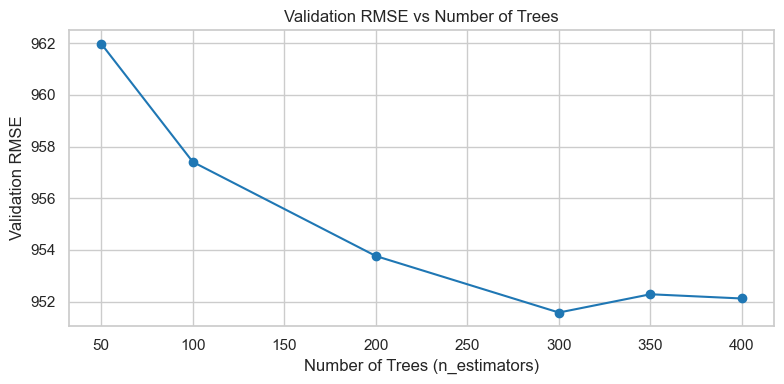

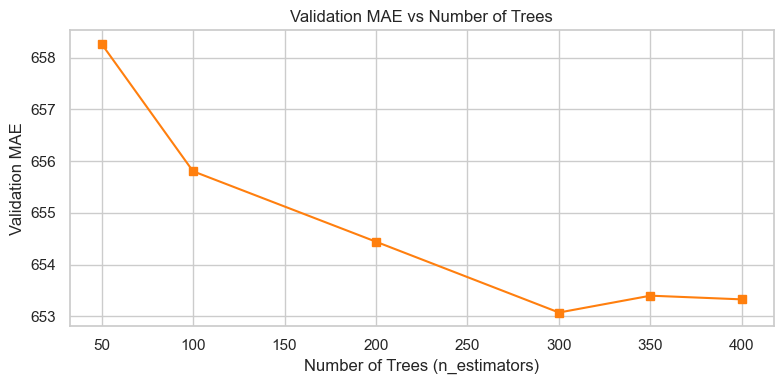


Random Forest - Test MAE: 769.52, RMSE: 1169.38
Existing Predictions - Test MAE: 763.86, RMSE: 1267.71


In [253]:
# Substitution mapping
feature_subs = {
    't_F': 't_avg_F',
    'sp': 'sp_avg',
    'dswrf': 'dswrf_avg',
    'uswrf': 'uswrf_avg',
    'dlwrf': 'dlwrf_avg',
    'ulwrf': 'ulwrf_avg',
    'gflux': 'gflux_avg',
    'lhtfl': 'lhtfl_avg',
    'fricv': 'fricv_avg',
    'gust': 'gust_avg'
}

# Define boundaries for relevant features
exclude_cols = ["valid_time_PT", "MW_actual_cleaned_CAISO", "MW_pred_cleaned_CAISO", "MW_error"]
cape_idx = daytime_hours.columns.get_loc("cape")
lag2_idx = daytime_hours.columns.get_loc("MW_actual_cleaned_CAISO_lag2days")
all_cols = daytime_hours.columns[cape_idx:lag2_idx + 1].tolist()

# Apply substitutions to feature list
feature_cols = []
for col in all_cols:
    if col in exclude_cols:
        continue
    elif col in feature_subs:
        feature_cols.append(feature_subs[col])
    else:
        feature_cols.append(col)

# Target variables
target_col = "MW_actual_cleaned_CAISO"
benchmark_col = "MW_pred_cleaned_CAISO"

# Get unique sorted timestamps
unique_times = daytime_hours['valid_time_PT'].drop_duplicates().sort_values()

# Find the split timestamp (80% mark)
split_time = unique_times.iloc[int(len(unique_times) * 0.8)]

# Split so that all rows for a timestamp are in the same set
train_df = daytime_hours[daytime_hours['valid_time_PT'] < split_time]
test_df = daytime_hours[daytime_hours['valid_time_PT'] >= split_time]

X_train = train_df[feature_cols].copy()
y_train = train_df[target_col]
X_test = test_df[feature_cols].copy()
y_test = test_df[target_col]
y_pred_existing = test_df[benchmark_col]

# TimeSeries cross-validation and model tuning
tscv = TimeSeriesSplit(n_splits=5)
n_estimators_list = [50, 100, 200, 300, 350, 400]
results = []

for n in n_estimators_list:
    fold_maes = []
    fold_rmses = []
    fold_train_scores = []
    fold_val_scores = []

    for train_idx, val_idx in tscv.split(X_train):
        X_t, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_t, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = RandomForestRegressor(n_estimators=n, random_state=42, n_jobs=-1)
        model.fit(X_t, y_t)

        y_val_pred = model.predict(X_val)
        y_train_pred = model.predict(X_t)

        fold_maes.append(mean_absolute_error(y_val, y_val_pred))
        fold_rmses.append(mean_squared_error(y_val, y_val_pred, squared=False))
        fold_train_scores.append(model.score(X_t, y_t))
        fold_val_scores.append(model.score(X_val, y_val))

    results.append({
        'n_estimators': n,
        'val_MAE': np.mean(fold_maes),
        'val_RMSE': np.mean(fold_rmses),
        'train_R2': np.mean(fold_train_scores),
        'val_R2': np.mean(fold_val_scores)
    })

results_df = pd.DataFrame(results)
print("\nCross-validation results:")
print(results_df)

# Plot RMSE vs number of trees
plt.figure(figsize=(8, 4))
plt.plot(results_df['n_estimators'], results_df['val_RMSE'], marker='o', color='tab:blue')
plt.title('Validation RMSE vs Number of Trees')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Validation RMSE')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot MAE vs number of trees
plt.figure(figsize=(8, 4))
plt.plot(results_df['n_estimators'], results_df['val_MAE'], marker='s', color='tab:orange')
plt.title('Validation MAE vs Number of Trees')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Validation MAE')
plt.grid(True)
plt.tight_layout()
plt.show()


# Final model on full training set with best tree count
best_n = results_df.sort_values("val_RMSE").iloc[0]["n_estimators"]
final_model = RandomForestRegressor(n_estimators=int(best_n), random_state=42, n_jobs=-1)
final_model.fit(X_train, y_train)

y_pred_rf = final_model.predict(X_test)

# Evaluate on test set
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf, squared=False)
mae_existing = mean_absolute_error(y_test, y_pred_existing)
rmse_existing = mean_squared_error(y_test, y_pred_existing, squared=False)

print(f"\nRandom Forest - Test MAE: {mae_rf:.2f}, RMSE: {rmse_rf:.2f}")
print(f"Existing Predictions - Test MAE: {mae_existing:.2f}, RMSE: {rmse_existing:.2f}")

Thoughts: After expanding n_estimators (based on omitted models), I wanted to use a walk-forward test evaluation approach. This will help me observe how my model behaves over time, and sees data that is further away (temporally) from the training data. Interestingly, the best random forest model was more similar to its initial model than the best XGBoost model was to its respective original model.

In [254]:
# ---- Walk-forward test evaluation ---- #
test_size = len(test_df)
window_size = test_size // 4  # 4 equal windows
results_rf = []

for i in range(4):
    start = i * window_size
    end = (i + 1) * window_size if i < 3 else test_size  

    X_window = X_test.iloc[start:end]
    y_window = y_test.iloc[start:end]
    benchmark_window = y_pred_existing.iloc[start:end]

    pred_rf = final_model.predict(X_window)

    mae_rf = mean_absolute_error(y_window, pred_rf)
    rmse_rf = mean_squared_error(y_window, pred_rf, squared=False)

    benchmark_mae = mean_absolute_error(y_window, benchmark_window)
    benchmark_rmse = mean_squared_error(y_window, benchmark_window, squared=False)

    results_rf.append({
        'Window': f'{i+1}',
        'Random Forest - MAE': mae_rf,
        'Benchmark - MAE': benchmark_mae,
        'Random Forest - RMSE': rmse_rf,
        'Benchmark - RMSE': benchmark_rmse
    })

results_rf_df = pd.DataFrame(results_rf)
print("\nWalk-forward Results (Random Forest):")
print(results_rf_df)

print("\nAverage Performance Across All Windows:")
print(results_rf_df.iloc[:, 1:].mean())



Walk-forward Results (Random Forest):
  Window  Random Forest - MAE  Benchmark - MAE  Random Forest - RMSE  \
0      1           587.455889       492.593729            978.095374   
1      2           682.262016       402.719595           1110.977656   
2      3           858.475308       940.776449           1281.845654   
3      4           949.623614      1218.674100           1278.787305   

   Benchmark - RMSE  
0        788.169203  
1        676.801229  
2       1469.445662  
3       1785.345994  

Average Performance Across All Windows:
Random Forest - MAE      769.454207
Benchmark - MAE          763.690968
Random Forest - RMSE    1162.426497
Benchmark - RMSE        1179.940522
dtype: float64


Thoughts: Overall model performance is comparable to the benchmark. Importantly, both MAE and RMSE increase significantly from window 1 to window 4 for both the model AND the benchmark. This leads me to believe that this trend isn't exclusively due to the model, but likely trends in the observed data as well (I'd guess seasonality plays a big part in this). I'd love to see how these metrics change with a larger dataset, but I have neither the time nor the computer space to accomplish that. 

### Best XGBoost Model

In [248]:
# Substitution mapping
feature_subs = {
    't_F': 't_avg_F',
    'sp': 'sp_avg',
    'dswrf': 'dswrf_avg',
    'uswrf': 'uswrf_avg',
    'dlwrf': 'dlwrf_avg',
    'ulwrf': 'ulwrf_avg',
    'gflux': 'gflux_avg',
    'lhtfl': 'lhtfl_avg',
    'fricv': 'fricv_avg',
    'gust': 'gust_avg'
}

# Define boundaries for relevant features
exclude_cols = ["valid_time_PT", "MW_actual_cleaned_CAISO", "MW_pred_cleaned_CAISO", "MW_error", 'valid_hour_PT', 'valid_month_PT']
cape_idx = daytime_hours.columns.get_loc("cape")
lag2_idx = daytime_hours.columns.get_loc("MW_actual_cleaned_CAISO_lag2days")
all_cols = daytime_hours.columns[cape_idx:lag2_idx + 1].tolist()

# Apply substitutions to feature list
feature_cols = []
for col in all_cols:
    if col in exclude_cols:
        continue
    elif col in feature_subs:
        feature_cols.append(feature_subs[col])
    else:
        feature_cols.append(col)

# Add month, year, and new one-hot columns to feature list
feature_cols += [col for col in daytime_hours.columns if col.startswith('point_name_')]
feature_cols += ['valid_hour_angle', 'valid_month_angle']

# Target variables
target_col = "MW_actual_cleaned_CAISO"
benchmark_col = "MW_pred_cleaned_CAISO"

# TRAIN/TEST SPLIT

# Get unique sorted timestamps
unique_times = daytime_hours['valid_time_PT'].drop_duplicates().sort_values()

# Find the split timestamp (80% mark)
split_time = unique_times.iloc[int(len(unique_times) * 0.8)]

# Split so that all rows for a timestamp are in the same set
train_df = daytime_hours[daytime_hours['valid_time_PT'] < split_time]
test_df = daytime_hours[daytime_hours['valid_time_PT'] >= split_time]

X_train_xgb = train_df[feature_cols].copy()
y_train_xgb = train_df[target_col]
X_test_xgb = test_df[feature_cols].copy()
y_test_xgb = test_df[target_col]
y_pred_existing = test_df[benchmark_col]

# Instantiate and fit XGBoost with specified parameters
xgb_model = XGBRegressor(
    objective='reg:absoluteerror',
    colsample_bytree=0.5,
    gamma=1,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=7,
    n_estimators=145,
    subsample=0.4,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_xgb, y_train_xgb)

# Predict and evaluate
y_pred = xgb_model.predict(X_test_xgb)

mae_model = mean_absolute_error(y_test_xgb, y_pred)
rmse_model = np.sqrt(mean_squared_error(y_test_xgb, y_pred))
mae_benchmark = mean_absolute_error(y_test_xgb, y_pred_existing)
rmse_benchmark = np.sqrt(mean_squared_error(y_test_xgb, y_pred_existing))

print(f"Model MAE: {mae_model:.2f}")
print(f"Model RMSE: {rmse_model:.2f}")
print(f"Benchmark MAE: {mae_benchmark:.2f}")
print(f"Benchmark RMSE: {rmse_benchmark:.2f}")


# ---- Walk-forward test evaluation ---- #
test_size = len(test_df)
window_size = test_size // 4  # 4 evaluation windows
results = []

for i in range(4):
    start = i * window_size
    end = (i + 1) * window_size if i < 3 else test_size 
    
    print(f"Window {i+1}: start={start}, end={end}, size={end - start}")

    X_window = X_test_xgb.iloc[start:end]
    y_window = y_test_xgb.iloc[start:end]
    benchmark_window = y_pred_existing.iloc[start:end]
    
    y_preds = xgb_model.predict(X_window)

    mae_xgb = mean_absolute_error(y_window, y_preds)

    rmse_xgb = np.sqrt(mean_squared_error(y_window, y_preds))
    
    benchmark_mae = mean_absolute_error(y_window, benchmark_window)

    benchmark_rmse = np.sqrt(mean_squared_error(y_window, benchmark_window))

    results.append({
        'Window': f'{i+1}',
        'MAE Model - MAE': mae_xgb,
        'Benchmark - MAE': benchmark_mae,
        'MAE Model - RMSE': rmse_xgb,
        'Benchmark - RMSE': benchmark_rmse,
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)
print(results_df)

# average across all windows
print("\nAverage Performance Across All Windows:")
print(results_df.iloc[:, 1:].mean())

Model MAE: 760.24
Model RMSE: 1119.15
Benchmark MAE: 763.86
Benchmark RMSE: 1267.71
Window 1: start=0, end=1986, size=1986
Window 2: start=1986, end=3972, size=1986
Window 3: start=3972, end=5958, size=1986
Window 4: start=5958, end=7947, size=1989
  Window  MAE Model - MAE  Benchmark - MAE  MAE Model - RMSE  Benchmark - RMSE
0      1       595.288832       492.593729        912.350974        788.169203
1      2       680.845417       402.719595       1037.240065        676.801229
2      3       798.896300       940.776449       1180.970382       1469.445662
3      4       965.620058      1218.674100       1306.292013       1785.345994

Average Performance Across All Windows:
MAE Model - MAE      760.162652
Benchmark - MAE      763.690968
MAE Model - RMSE    1109.213359
Benchmark - RMSE    1179.940522
dtype: float64


In [252]:
# Predictions
ytrain_pred = xgb_model.predict(X_train_xgb)
ytest_pred = xgb_model.predict(X_test_xgb)

# Training performance
train_mae = mean_absolute_error(y_train_xgb, ytrain_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_xgb, ytrain_pred))

# Test performance
test_mae = mean_absolute_error(y_test_xgb, ytest_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_xgb, ytest_pred))

# Print results
print("\n--- XGBoost Model Performance ---")
print(f"Train MAE: {train_mae:.3f}")
print(f"Train RMSE: {train_rmse:.3f}")
print(f"Test MAE:  {test_mae:.3f}")
print(f"Test RMSE: {test_rmse:.3f}")

print(f"\nMAE Overfitting Ratio (Test / Train): {test_mae / train_mae:.2f}")
print(f"RMSE Overfitting Ratio (Test / Train): {test_rmse / train_rmse:.2f}")



--- XGBoost Model Performance ---
Train MAE: 536.680
Train RMSE: 841.259
Test MAE:  760.240
Test RMSE: 1119.154

MAE Overfitting Ratio (Test / Train): 1.42
RMSE Overfitting Ratio (Test / Train): 1.33


The above is the best XGBoost model that I obtained during this project, but I'm sure that it can be further improved. While my model is currently beating benchmark predictions for both MAE and RMSE, it is not by a significant margin, and not in each window. I'm also still concerned about overfitting. However, I think this serves as a respectable final model for a personal project. 

In [274]:
time_col = 'valid_time_PT'  

# Get total test size and calculate window size
test_size = len(test_df)
window_size = test_size // 4  # 4 evaluation windows

# Loop to print window lengths and time spans
for i in range(4):
    start_idx = i * window_size
    end_idx = (i + 1) * window_size if i < 3 else test_size

    window_df = test_df.iloc[start_idx:end_idx]
    window_start_time = window_df[time_col].iloc[0]
    window_end_time = window_df[time_col].iloc[-1]
    
    print(f"Window {i+1}:")
    print(f"  Size: {end_idx - start_idx} rows")
    print(f"  Time span: {window_start_time} to {window_end_time}\n")

Window 1:
  Size: 1986 rows
  Time span: 2023-11-07 17:00:00-08:00 to 2023-12-22 08:00:00-08:00

Window 2:
  Size: 1986 rows
  Time span: 2023-12-22 09:00:00-08:00 to 2024-02-04 15:00:00-08:00

Window 3:
  Size: 1986 rows
  Time span: 2024-02-04 16:00:00-08:00 to 2024-03-20 10:00:00-07:00

Window 4:
  Size: 1989 rows
  Time span: 2024-03-20 11:00:00-07:00 to 2024-05-03 20:00:00-07:00



Thoughts: As I will discuss later, possibly the biggest issue I have with this analysis is that I don't have sufficient data to do an 80/20 (or anywhere close) train/test split while leaving out an entire calendar year for testing. As it stands, I don't have summer months in my test set.

Thoughts: I'll use the best models from RF and XGBoost and examine their performance and errors. But first, I wanted to quickly show the end of my training set and the beginning of my testing set to demonstrate that there was no data leakage between the two.

In [255]:
train_df[['valid_time_PT']].tail()

,valid_time_PT
48166,2023-11-07 15:00:00-08:00
48167,2023-11-07 15:00:00-08:00
48168,2023-11-07 16:00:00-08:00
48169,2023-11-07 16:00:00-08:00
48170,2023-11-07 16:00:00-08:00


In [256]:
test_df[['valid_time_PT']].head()

,valid_time_PT
48171,2023-11-07 17:00:00-08:00
48172,2023-11-07 17:00:00-08:00
48173,2023-11-07 17:00:00-08:00
48174,2023-11-07 18:00:00-08:00
48175,2023-11-07 18:00:00-08:00


### Performance Visualizations
Using the best RF and XGBoost models above.

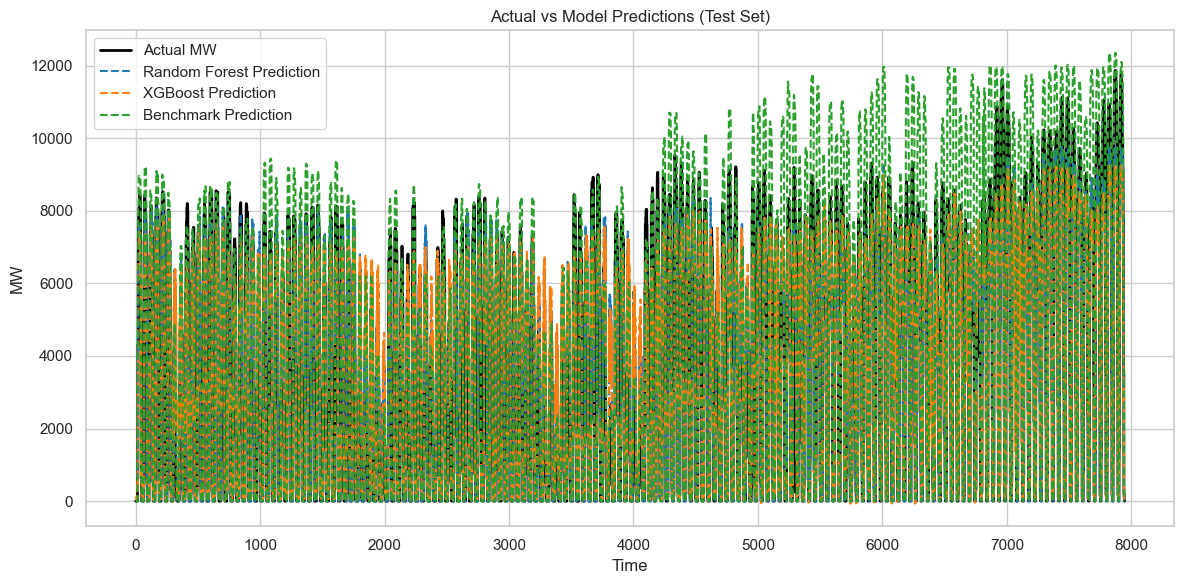

In [258]:
plt.figure(figsize=(12, 6))

plt.plot(y_test.values, label='Actual MW', color='black', linewidth=2)
plt.plot(y_pred_rf, label='Random Forest Prediction', linestyle='--', color='tab:blue')
plt.plot(ytest_pred, label='XGBoost Prediction', linestyle='--', color='tab:orange')
plt.plot(y_pred_existing.values, label='Benchmark Prediction', linestyle='--', color='tab:green')

plt.title('Actual vs Model Predictions (Test Set)')
plt.xlabel('Time')
plt.ylabel('MW')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Thoughts: Hah! This is an absolutely heinous visual. I can still see some basic trends (like benchmark's tendency to overshoot actuals, and XGBoost's tendency to undershoot actuals), so I will keep it, but we can do better.

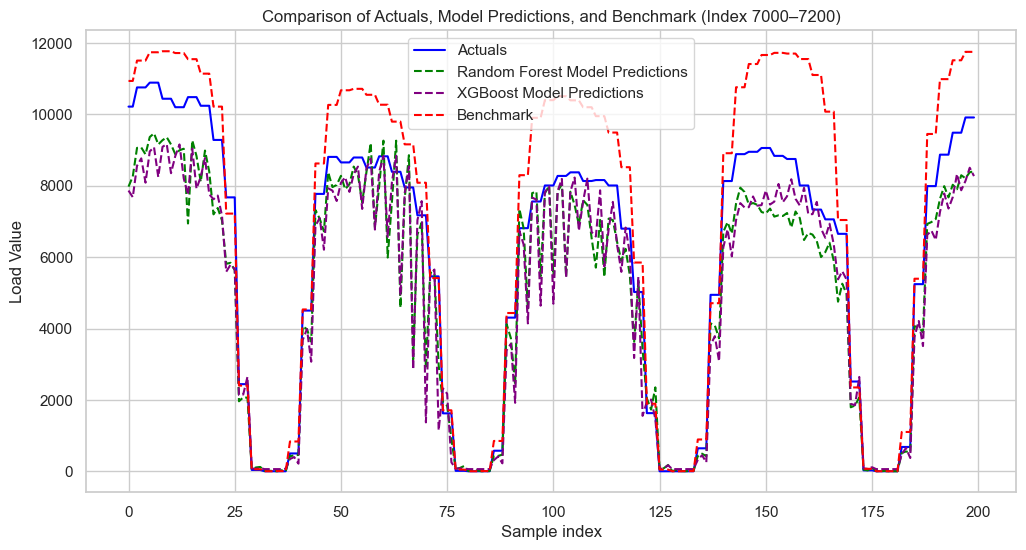

In [259]:
# Sample for visualization: 200 values starting at specified
start_index = 7000 # I changed this from the original
sample_size = 200
end_index = start_index + sample_size
indices = range(sample_size)  # x-axis range

plt.figure(figsize=(12, 6))

# Plot actuals
plt.plot(indices, y_test.values[start_index:end_index], label="Actuals", color="blue")

# Plot Random Forest model predictions
plt.plot(indices, y_pred_rf[start_index:end_index], label="Random Forest Model Predictions", color="green", linestyle="--")

# Plot XGBoost predictions
plt.plot(indices, ytest_pred[start_index:end_index], label="XGBoost Model Predictions", color="purple", linestyle="--")

# Plot benchmark
plt.plot(indices, y_pred_existing.values[start_index:end_index], label="Benchmark", color="red", linestyle="--")

plt.title("Comparison of Actuals, Model Predictions, and Benchmark (Index 7000–7200)")
plt.xlabel("Sample index")
plt.ylabel("Load Value")
plt.legend()
plt.show()


In [260]:
# Combine full-length arrays into a DataFrame
full_comparison_df = pd.DataFrame({
    'Actuals': y_test.values,
    'Random Forest Predictions': y_pred_rf,
    'XGBoost Predictions': ytest_pred,
    'Benchmark Predictions': y_pred_existing.values
})

# Show the first and last 10 values
print("First 10 values:")
print(full_comparison_df.head(20))

print("\nLast 10 values:")
print(full_comparison_df.tail(10))


First 10 values:
       Actuals  Random Forest Predictions  XGBoost Predictions  \
0      0.00000                   2.037747           132.096344   
1      0.00000                   0.599846           132.096344   
2      0.00000                   1.535799           132.096344   
3      0.00000                   1.154394            59.713299   
4      0.00000                   1.044020            59.713299   
5      0.00000                   1.073484            59.713299   
6      0.00000                   0.010783            59.713299   
7      0.00000                   2.564216            59.713299   
8      0.00000                   2.070824            59.713299   
9      0.00000                   0.408862            59.713299   
10     0.00000                   2.466625            59.713299   
11     0.00000                   0.292271            59.713299   
12     0.00000                   0.138587            59.713299   
13     0.00000                   0.349434            59.713

Thought: Try to average predictions across the three locations and have only one prediction per hour. Could even weight this by solar farm capacity of the three centroids if I really want, but I'm likely not diving back into more CAISO analysis for that right now.

In [261]:
# Make a copy of the dataframe
df = full_comparison_df.copy()

# Reshape by grouping every 3 rows
avg_df = pd.DataFrame({
    'Actuals': df['Actuals'].groupby(df.index // 3).first(), 
    'Benchmark': df['Benchmark Predictions'].groupby(df.index // 3).first(),
    'RF_Avg_Prediction': df['Random Forest Predictions'].groupby(df.index // 3).mean(),
    'XGB_Avg_Prediction': df['XGBoost Predictions'].groupby(df.index // 3).mean()
})

# Evaluate performance

print("MAE (Random Forest):", mean_absolute_error(avg_df['Actuals'], avg_df['RF_Avg_Prediction']))
print("RMSE (Random Forest):", np.sqrt(mean_squared_error(avg_df['Actuals'], avg_df['RF_Avg_Prediction'])))
print()

print("MAE (XGBoost):", mean_absolute_error(avg_df['Actuals'], avg_df['XGB_Avg_Prediction']))
print("RMSE (XGBoost):", np.sqrt(mean_squared_error(avg_df['Actuals'], avg_df['XGB_Avg_Prediction'])))
print()

print("MAE (Benchmark):", mean_absolute_error(avg_df['Actuals'], avg_df['Benchmark']))
print("RMSE (Benchmark):", np.sqrt(mean_squared_error(avg_df['Actuals'], avg_df['Benchmark'])))


MAE (Random Forest): 738.6947853175748
RMSE (Random Forest): 1102.7441916747305

MAE (XGBoost): 735.4521278014084
RMSE (XGBoost): 1057.0155697480561

MAE (Benchmark): 763.8627249943376
RMSE (Benchmark): 1267.7133669556688


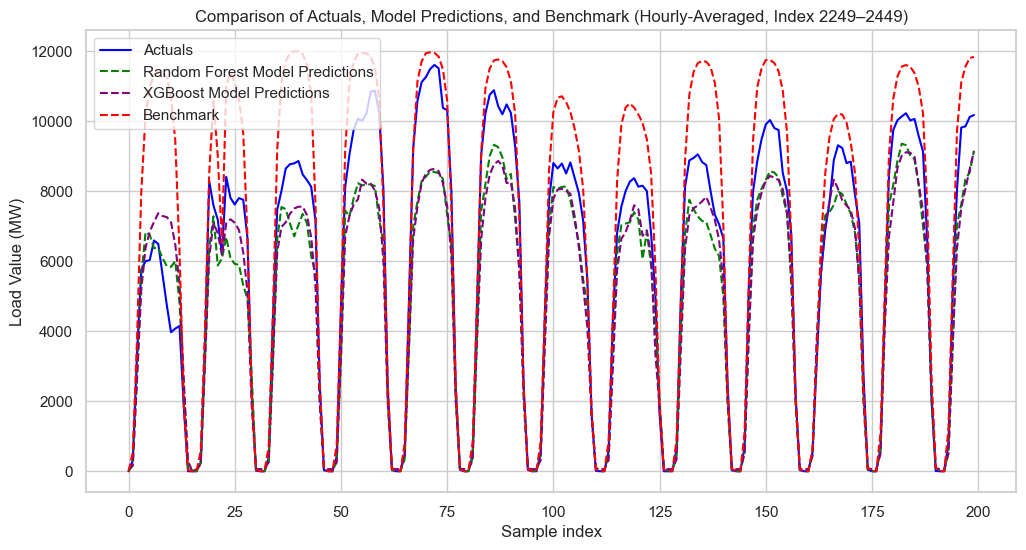

In [262]:
# Sample for visualization: 200 values starting at specified index
start_index = 2249
sample_size = 200
end_index = start_index + sample_size
indices = range(sample_size)  # x-axis range for plotting

plt.figure(figsize=(12, 6))

# Plot Actuals
plt.plot(indices, avg_df['Actuals'].iloc[start_index:end_index], label="Actuals", color="blue")

# Plot Random Forest averaged predictions
plt.plot(indices, avg_df['RF_Avg_Prediction'].iloc[start_index:end_index], label="Random Forest Model Predictions", color="green", linestyle="--")

# Plot XGBoost averaged predictions
plt.plot(indices, avg_df['XGB_Avg_Prediction'].iloc[start_index:end_index], label="XGBoost Model Predictions", color="purple", linestyle="--")

# Plot Benchmark predictions
plt.plot(indices, avg_df['Benchmark'].iloc[start_index:end_index], label="Benchmark", color="red", linestyle="--")

plt.title("Comparison of Actuals, Model Predictions, and Benchmark (Hourly-Averaged, Index 2249–2449)")
plt.xlabel("Sample index")
plt.ylabel("Load Value (MW)")
plt.legend()
plt.show()


In [263]:
# Make a copy of dataframe
df = full_comparison_df.copy()

# Reshape by grouping every 3 rows
avg_df = pd.DataFrame({
    'Actuals': df['Actuals'].groupby(df.index // 3).first(), 
    'Benchmark': df['Benchmark Predictions'].groupby(df.index // 3).first(),
    'RF_Avg_Prediction': df['Random Forest Predictions'].groupby(df.index // 3).mean(),
    'XGB_Avg_Prediction': df['XGBoost Predictions'].groupby(df.index // 3).mean()
})

# Evaluate performance

print("=== Averaged Predictions ===")
print("MAE (Random Forest):", mean_absolute_error(avg_df['Actuals'], avg_df['RF_Avg_Prediction']))
print("RMSE (Random Forest):", np.sqrt(mean_squared_error(avg_df['Actuals'], avg_df['RF_Avg_Prediction'])))
print()

print("MAE (XGBoost):", mean_absolute_error(avg_df['Actuals'], avg_df['XGB_Avg_Prediction']))
print("RMSE (XGBoost):", np.sqrt(mean_squared_error(avg_df['Actuals'], avg_df['XGB_Avg_Prediction'])))
print()

print("MAE (Benchmark):", mean_absolute_error(avg_df['Actuals'], avg_df['Benchmark']))
print("RMSE (Benchmark):", np.sqrt(mean_squared_error(avg_df['Actuals'], avg_df['Benchmark'])))
print()

# Evaluate on full (pre-averaged) data
print("=== Original (Pre-Averaged) Predictions ===")
print("MAE (Random Forest):", mean_absolute_error(df['Actuals'], df['Random Forest Predictions']))
print("RMSE (Random Forest):", np.sqrt(mean_squared_error(df['Actuals'], df['Random Forest Predictions'])))
print()

print("MAE (XGBoost):", mean_absolute_error(df['Actuals'], df['XGBoost Predictions']))
print("RMSE (XGBoost):", np.sqrt(mean_squared_error(df['Actuals'], df['XGBoost Predictions'])))
print()

print("MAE (Benchmark):", mean_absolute_error(df['Actuals'], df['Benchmark Predictions']))
print("RMSE (Benchmark):", np.sqrt(mean_squared_error(df['Actuals'], df['Benchmark Predictions'])))


=== Averaged Predictions ===
MAE (Random Forest): 738.6947853175748
RMSE (Random Forest): 1102.7441916747305

MAE (XGBoost): 735.4521278014084
RMSE (XGBoost): 1057.0155697480561

MAE (Benchmark): 763.8627249943376
RMSE (Benchmark): 1267.7133669556688

=== Original (Pre-Averaged) Predictions ===
MAE (Random Forest): 769.522220739604
RMSE (Random Forest): 1169.377161104371

MAE (XGBoost): 760.2402121851117
RMSE (XGBoost): 1119.154452865237

MAE (Benchmark): 763.8627249943374
RMSE (Benchmark): 1267.7133669556688


Thoughts: Nice! As expected, this leaves the benchmark values unchanged and improves both error metrics for random forest and XGBoost. 

### Variable importance and further error visuals

##### Random Forest

In [267]:

importances = final_model.feature_importances_
feature_names = X_train.columns

# Create a sorted DataFrame
importance_df_rf = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df_rf.head(10))  # Top 10 features


                             Feature  Importance
13                         dswrf_avg    0.912966
22  MW_actual_cleaned_CAISO_lag2days    0.016921
20                           t_avg_F    0.015122
19                             vddsf    0.008315
18                             vbdsf    0.005720
15                         dlwrf_avg    0.004330
2                                blh    0.003895
1                             sp_avg    0.003552
11                          gust_avg    0.003538
14                         uswrf_avg    0.003314


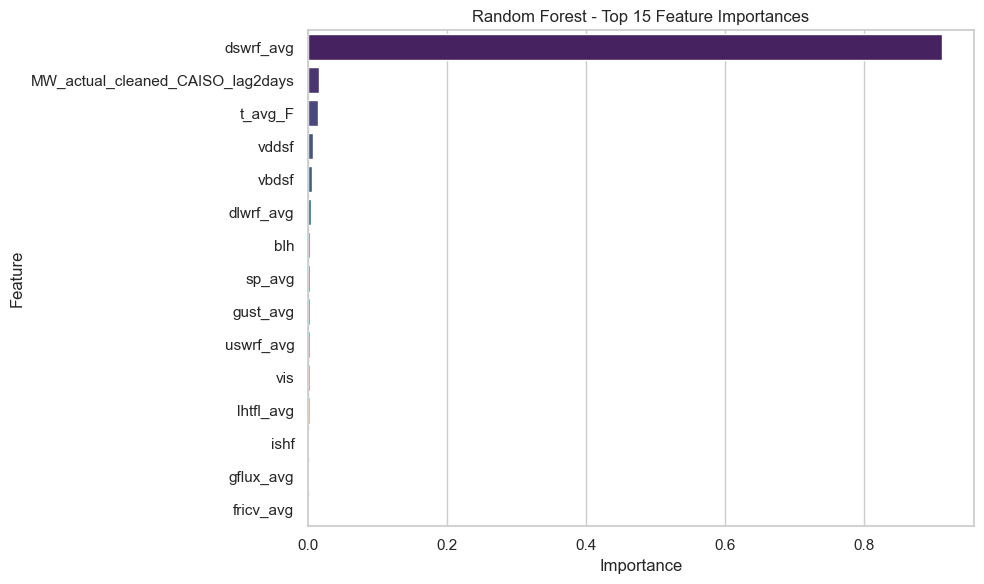

In [268]:
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df_rf.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Random Forest - Top 15 Feature Importances')
plt.tight_layout()
plt.show()


Thoughts: Wow.

##### XGBoost

In [265]:
xgbimportances = xgb_model.feature_importances_
feature_names = X_train_xgb.columns

# Create a sorted DataFrame
xgbimportance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgbimportances
}).sort_values(by='Importance', ascending=False)

print(xgbimportance_df.head(10))  # Top 10 features

                             Feature  Importance
13                         dswrf_avg    0.202575
14                         uswrf_avg    0.163092
19                             vddsf    0.150474
17                         gflux_avg    0.133353
18                             vbdsf    0.069432
3                               ishf    0.063616
21  MW_actual_cleaned_CAISO_lag2days    0.044758
25                  valid_hour_angle    0.041219
20                           t_avg_F    0.022447
8                                 tp    0.012082


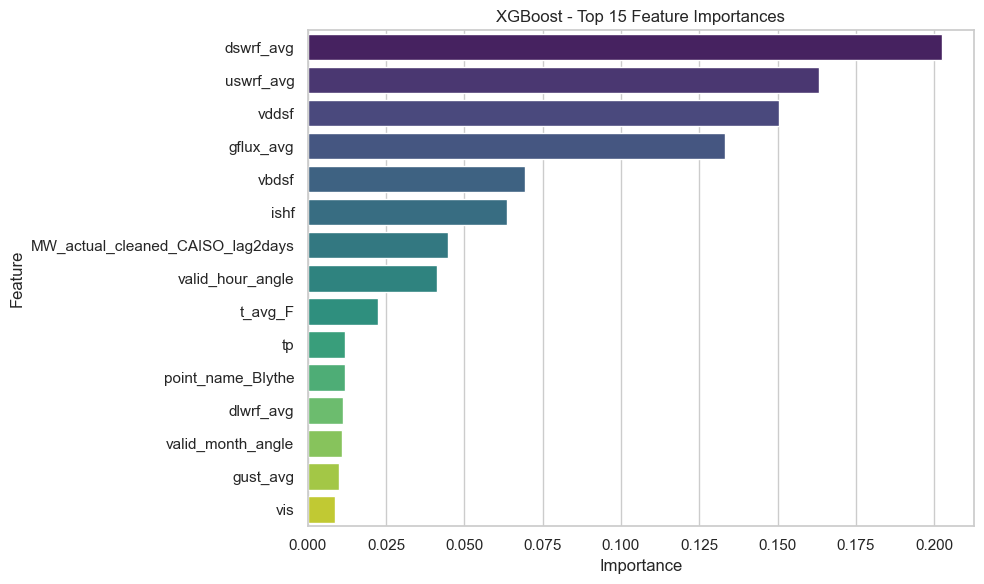

In [266]:
plt.figure(figsize=(10, 6))
sns.barplot(data=xgbimportance_df.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('XGBoost - Top 15 Feature Importances')
plt.tight_layout()
plt.show()


Thoughts: Much more reasonable than RF.

##### Error visuals

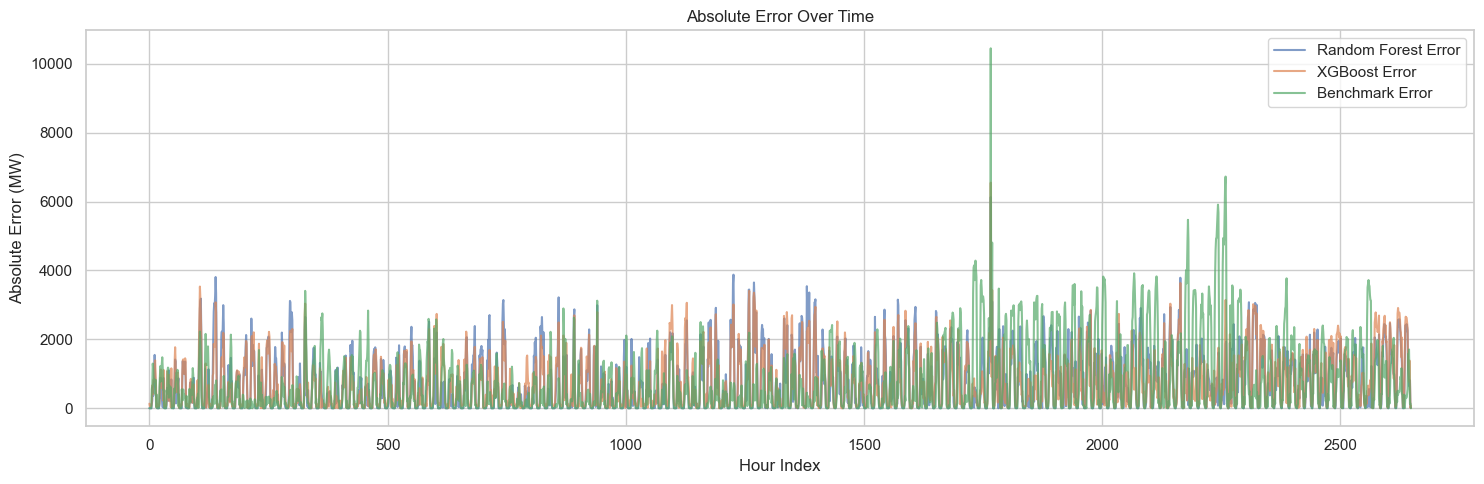

In [269]:
# Calculate absolute errors
avg_df['RF_Error'] = np.abs(avg_df['Actuals'] - avg_df['RF_Avg_Prediction'])
avg_df['XGB_Error'] = np.abs(avg_df['Actuals'] - avg_df['XGB_Avg_Prediction'])
avg_df['Benchmark_Error'] = np.abs(avg_df['Actuals'] - avg_df['Benchmark'])

# Plot
plt.figure(figsize=(15, 5))
plt.plot(avg_df['RF_Error'], label='Random Forest Error', alpha=0.7)
plt.plot(avg_df['XGB_Error'], label='XGBoost Error', alpha=0.7)
plt.plot(avg_df['Benchmark_Error'], label='Benchmark Error', alpha=0.7)
plt.title('Absolute Error Over Time')
plt.xlabel('Hour Index')
plt.ylabel('Absolute Error (MW)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


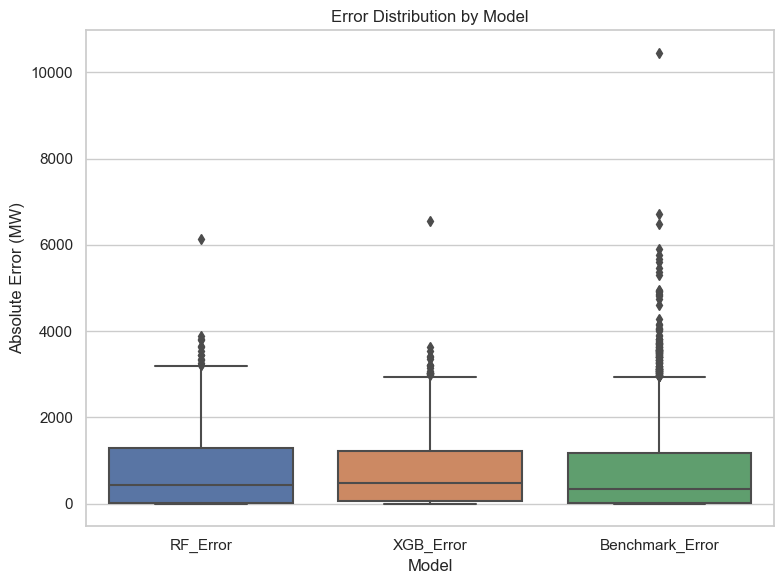

In [270]:
# Melt into long format
melted_errors = avg_df[['RF_Error', 'XGB_Error', 'Benchmark_Error']].melt(var_name='Model', value_name='Absolute Error')

# Plot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Model', y='Absolute Error', data=melted_errors)
plt.title('Error Distribution by Model')
plt.ylabel('Absolute Error (MW)')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


Thoughts: I want to zoom in on that super large error from the first graph, which surely corresponds to the largest outliers in the second graph. I will try to put datetime values back in that dataset and reverse engineer the limited amount of data to see exactly when this occurred.

In [272]:
# Pull one timestamp per hour (every 3 rows)
hourly_timestamps = test_df['valid_time_PT'].iloc[::3].reset_index(drop=True)

# Add to avg_df
avg_df = avg_df.reset_index(drop=True)
avg_df['valid_time_PT'] = hourly_timestamps


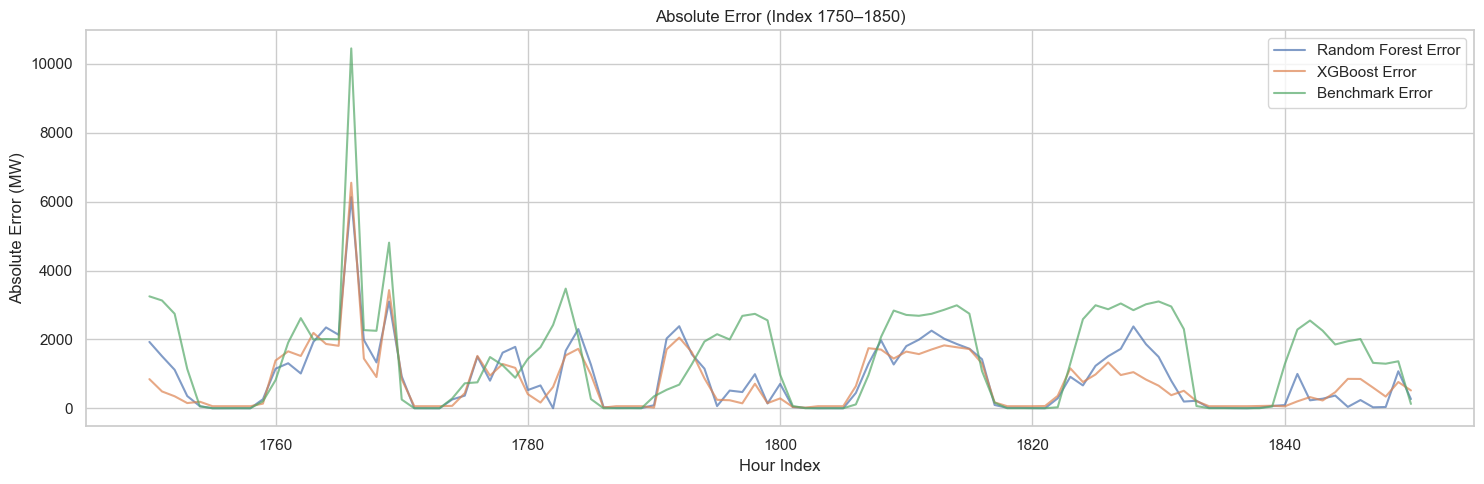

Datetime range for index 1750–1850:
2024-03-04 13:00:00-08:00 to 2024-03-10 18:00:00-07:00


In [273]:
# Slice the range
subset = avg_df.loc[1750:1850]

# Plot the absolute errors in that window
plt.figure(figsize=(15, 5))
plt.plot(subset['RF_Error'], label='Random Forest Error', alpha=0.7)
plt.plot(subset['XGB_Error'], label='XGBoost Error', alpha=0.7)
plt.plot(subset['Benchmark_Error'], label='Benchmark Error', alpha=0.7)
plt.title('Absolute Error (Index 1750–1850)')
plt.xlabel('Hour Index')
plt.ylabel('Absolute Error (MW)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print the time window
print("Datetime range for index 1750–1850:")
print(subset['valid_time_PT'].iloc[0], "to", subset['valid_time_PT'].iloc[-1])


Thoughts: Nice! This worked. I checked on the CAISO API dashboard and this large error occurs at 2pm PT on March 5th, 2024. Unfortunately, this isn't as cool as I had hoped for. It looks like actual values were suspiciously low for solar and wind energy at this hour, and I couldn't find evidence of any extreme weather events happening on that day. Selfishly, I was hoping this would be a cool instance of something like a solar eclipse, which benchmark and XGBoost/RF models didn't account for, but that is not the case. There was a solar eclipse visible in SoCal on April 8th of 2024 but unfortunately I did not find any interesting errors during that day. 

:(

### Thoughts & Moving Forward

My final thought is that this was a beneficial learning experience where I produced a reasonable pair of predictive models, all things considered. As I anticipated at the beginning of this project, it looks like solar energy generation is predictable by an overwhelmingly small subset of features that are related to sunlight and time of day. My best performing random forest and XGBoost models both had downward shortwave radiation flux as the most important feature in their respective feature matrices, and the random forest was almost entirely reliant on this feature. My XGBoost model had a much more even spread of features important to predictions, but was still dominated by features related to types of radiation and time. Further models would certainly trim the feature matrix even more and attempt to add a variable that is a direct indication of cloud coverage. On top of this, the most obvious next step if I were to continue improving on these models would be to collect and incorporate more data. As things stand, my 80/20 train test split only allows for about 7 months to be held out for testing (November - May). In an ideal situation, I would have sufficient data to hold out and test an entire year. The logical approach to this problem is to download more data, but I do not have the computer space to accomplish this, or the time to do this. I'm happy with where this project went and confident that I'd be in a great spot to make further improvements if I had professional incentives to push this to production.

Regarding the specific months missing from the testing set, I believe adding summer data could provide an opportunity for my models to perform even better. While Southern California has a relatively stable climate year-round compared to other regions, it still experiences seasonal changes in sunlight duration and solar angle that clearly impact solar energy generation. In the walk-forward evaluation, we observed that RMSE and MAE increased for both my models and the benchmark predictions as the testing windows progressed toward the warmer, summer months (and, admittedly, as we got further from the training data). This shift appears to benefit my models. Benchmark predictions were increasingly prone to larger errors, which was especially apparent in the later testing windows. This trend was visible in the evaluation visuals and supported by the fact that my models consistently outperformed the benchmark on RMSE. The more difficult metric to beat was MAE, which reflects the average absolute magnitude of errors. While this was harder to beat the benchmark on, I still accomplished the goal, but had to be particularly careful about overfitting.

Biggest drivers of model performance outside of individual features (in no particular order):

1. Using weather forecasts from three important locations in the SP15 region of SoCal. I think representing three different locations within the region allowed for a thoughtful way to measure solar energy generation for the entire area and ultimately allowed me to capture patterns across geographically unique locations. Additional model building would likely result in me assigning different weights to these locations for their hourly predictions based on production capacity of the given centroids that these points came from.

2. Averaging predictions across sites for each hour. This helped lower MAE and RMSE for both the RF and XGBoost model when compared to having three predictions for each hour.

3. Averaging hourly forecasts for weather variables over the same time span for which they were predicting solar energy generation. We saw during random forest model building that this contributed to better performing models.

4. Removal of overnight hours during model training and testing. This could have been refined even further to incorporate specific sunrise and sunset times throughout the year at each location, but my blanket removal of the 9pm-5am hours worked well. In hindsight this decision probably should have been made earlier, but my lack of experience with solar data and the fact that the CAISO API produced predictions for these hours, kept me from doing so until I had already started building models. The logic behind this decision was obvious: Solar panels do not and can not generate energy at night from solar radiation, as moonlight (which is just a reflection of sunlight) is far too weak to generate energy in a solar panel. Keeping these hours in the dataset would just introduce potentially detrimental noise, and ultimately hurt model performance.

5. Hyperparameter tuning. While this can certainly improve model performance relative to the vanilla models, I want to explicitly state that this was a tough task to accomplish on an 8 year-old macbook pro. My machine limited the scope of my gridsearch, and I certainly could be leaving some meat on the bone in this department.

6. Modeling hour and month in a cyclical way with only one variable! This version of the project omitted where I attempted to add hour and month as sin and cos transformations, but that I tried this as well, and this is what prompted me to create the "..._angle" variables.

The goal of this project was to explore a new area of data that I wasn’t very familiar with, using whatever data was available, while also improving my skills in time series forecasting. This project also provided an opportunity to practice pulling data from CAISO's API. I'm confident that I accomplished these goals and learned a good bit. Given my intentional lack of domain knowledge, there was a huge emphasis on learning. In the absence of academic and professional incentives, I wanted to prioritize technical growth over things like model performance and efficiency during the model building process. I didn't go into this project with a narrow scope of expectations, and I didn't initially navigate the data as comfortably as I might in some other situations. I did, however, quickly become familiar with the data and benefitted from brief struggles and mistakes that came as a direct result of my lack of knowledge in certain areas. I think these minor difficulties helped reinforce previously unfamiliar concepts surrounding solar energy generation, as well as strategies for working with time-series data in a meaningful way. I'm looking forward to using what I learned in this exploration in my next project!


# Variable definitions and abbreviations

#### Limited to variables that were in final models

In [275]:
data = [
    ["t_F", "Temperature", "Fahrenheit"],
    ["cape", "Convective Available Potential Energy", "J/kg"],
    ["sp", "Surface Pressure", "Pa"],
    ["blh", "Boundary Layer Height", "m"],
    ["ishf", "Shortwave Radiation Flux (incoming solar radiation)", "W/m²"],
    ["fsr", "Fraction of Sunlight Reaching the Surface", "%"],
    ["vis", "Visibility", "m"],
    ["prate", "Precipitation Rate", "kg/(m²·s)"],
    ["cin", "Convective Inhibition", "J/kg"],
    ["tp", "Total Precipitation", "mm"],
    ["lhtfl", "Latent Heat Net Flux", "W/m²"],
    ["crain", "Categorical Rain", "0 or 1"],
    ["gust", "Wind Gust", "m/s"],
    ["fricv", "Frictional Velocity", "m/s"],
    ["dswrf", "Downward Short Wave Radiation Flux", "W/m²"],
    ["uswrf", "Upward Short Wave Radiation Flux", "W/m²"],
    ["dlwrf", "Downward Long Wave Radiation Flux", "W/m²"],
    ["veg", "Vegetation", "%"],
    ["gflux", "Ground Heat Flux", "W/m²"],
    ["vbdsf", "Visible Beam Downward Solar Flux", "W/m²"],
    ["vddsf", "Visible Diffuse Downward Solar Flux", "W/m²"],
    ["valid_hour_PT", "Valid Hour of Observation", "PT"],
    ["MW_actual_cleaned_CAISO", "Solar Energy Generated in SP15 Region (Hourly, Cleaned)", "MW"],
    ["MW_pred_cleaned_CAISO", "CAISO Predicted Solar Energy Generation in SP15 Region (Hourly)", "MW"],
    ["MW_actual_cleaned_CAISO_lag2days", "2 Day Lag of MW_actual_cleaned_CAISO", "MW"],
    ["valid_month_PT", "Valid Month of Observation", "Month"],
    ["valid_year_PT", "Valid Year of Observation", "Year"],
    ["valid_month_sin_cyclical", "Cyclical Encoding of Month Using Sine", "[-1,1]"],
    ["valid_month_cos_cyclical", "Cyclical Encoding of Month Using Cosine", "[-1,1]"],
    ["valid_hour_sin_cyclical", "Cyclical Encoding of Hour Using Sine", "[-1,1]"],
    ["valid_hour_cos_cyclical", "Cyclical Encoding of Hour Using Cosine", "[-1,1]"],
    ["valid_hour_angle", "Angle Representation of Hour on a 24-Hour Clock", "Radians [0, 2π]"],
    ["valid_month_angle", "Angle Representation of Month on a 12-Month Cycle", "Radians [0, 2π]"]
]

df = pd.DataFrame(data, columns=["Variable", "Description", "Units"])
pd.set_option("display.max_colwidth", None)
print(df)


                            Variable  \
0                                t_F   
1                               cape   
2                                 sp   
3                                blh   
4                               ishf   
5                                fsr   
6                                vis   
7                              prate   
8                                cin   
9                                 tp   
10                             lhtfl   
11                             crain   
12                              gust   
13                             fricv   
14                             dswrf   
15                             uswrf   
16                             dlwrf   
17                               veg   
18                             gflux   
19                             vbdsf   
20                             vddsf   
21                     valid_hour_PT   
22           MW_actual_cleaned_CAISO   
23             MW_pred_cleaned_CAISO   


In [276]:
print(tabulate(df, headers='keys', tablefmt='github', showindex=False))


| Variable                         | Description                                                     | Units           |
|----------------------------------|-----------------------------------------------------------------|-----------------|
| t_F                              | Temperature                                                     | Fahrenheit      |
| cape                             | Convective Available Potential Energy                           | J/kg            |
| sp                               | Surface Pressure                                                | Pa              |
| blh                              | Boundary Layer Height                                           | m               |
| ishf                             | Shortwave Radiation Flux (incoming solar radiation)             | W/m²            |
| fsr                              | Fraction of Sunlight Reaching the Surface                       | %               |
| vis                           